<a href="https://colab.research.google.com/github/Bungaacnty/DataScience/blob/main/Indonesia's_Labour_Efficiency_Risking_SDGs_Failure_by_2030%3F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Final Project - Startup Campuss MSIB 7

## Introduction Team Kawal Inovasi:
- Ahmad Fahim Nashikhul Umam
- Bunga Cintya Dewi
- Khanif Saputra
- Muhammad Rakha Ramadhan
- Nur Hasanah
- Thirza Safira Maharani

# 0. Import Module/Package

In [ ]:
# Library untuk regression dan clustering

!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 703.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/1

In [ ]:
# Library Forecasting

!pip install statsforecast
!pip install mlforecast
!pip install neuralforecast
!pip install hierarchicalforecast
!pip install utilsforecast

from neuralforecast.auto import NHITS, BiTCN
from neuralforecast.core import NeuralForecast
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
from neuralforecast.losses.pytorch import MQLoss

  Using cached neuralforecast-3.0.1-py3-none-any.whl.metadata (14 kB)
  Using cached pytorch_lightning-2.5.1.post0-py3-none-any.whl.metadata (20 kB)
  Using cached ray-2.46.0-cp311-cp311-manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached torchmetrics-1.7.1-py3-none-any.whl.metadata (21 kB)
  Using cached lightning_utilities-0.14.3-py3-none-any.whl.metadata (5.6 kB)
  Using cached tensorboardX-2.6.2.2-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux201

In [ ]:
# Melakukan import semua modul yang akan digunakan

!pip install window-ops
import pandas as pd
from scipy import stats
import numpy as np
from numpy import interp
import matplotlib.pyplot as plt
import seaborn as sns

from mlforecast import MLForecast
from sklearn.ensemble import RandomForestRegressor
from window_ops.rolling import rolling_mean

from pycaret.regression import *
from sklearn.utils import resample
from sklearn.impute import SimpleImputer

**Code Explanation:**
- Mengimport library Pandas dan memberikannya alias sebagai 'pd' agar mamudahkan dalam menulis syntax. Pandas digunakan untuk memanipulasi dan menganalisis data, khususnya dengan data dalam bentu tabel seperti DataFrame.
- Mengimport modul Stats dari library SciPy. Stats berfungsi untuk melakukan berbagai perhitungan statistik.
- Mengimport library NumPy dan memberikannya alias sebagai 'np' agar mamudahkan dalam menulis syntax. NumPy digunakan untuk mendukung operasi matematika dan fungsi numerik.
- Mengimport modul Pyplot dari library Matplotlib dan memberikannya alias sebagai 'plt' agar mamudahkan dalam menulis syntax. Pyplot digunakan untuk membuat visualisasi data sederhana.
- Mengimport library Seaborn dan memberikannya alias sebagai 'sns' agar mamudahkan dalam menulis syntax. Seaborn digunakan untuk visualisasi data yang lebih menarik

**Insight:**
- Library pycaret digunakan untuk menyederhanakan alur kerja Machine Learning
- Dengan Library dan Module yang telah diimport dapat digunakan untuk proses selanjutnya. Misalnya untuk memahami bagaimana data didistribusikan, apa hubungan antar variabel, tren apa yang ada dalam dataset, serta visualisasi yang akan memberikan gambaran yang dapat dipahami oleh orang awam.

# 1. Business Understanding

Memprediksi efisiensi tenaga kerja (pendapatan pajak per tenaga kerja) berdasarkan variabel jumlah tenaga kerja, usia produktif, dan produktivitas ekonomi dalam suatu negara.

## 1.1. Background

Efisiensi tenaga kerja merupakan indikator penting yang menunjukkan seberapa efektif sumber daya manusia digunakan untuk menghasilkan pendapatan dalam suatu negara. Dalam penelitian ini, pendapatan pajak per tenaga kerja menjadi salah satu parameter yang dapat mencerminkan efisiensi tersebut. Memahami faktor-faktor yang memengaruhi efisiensi tenaga kerja adalah kunci bagi pengambilan keputusan dan perumusan kebijakan yang lebih baik. Harapannya, analisis efisiensi tenaga kerja ini akan menghasilkan solusi untuk mencapai Indonesia Emas mendatang dari segi pendapatan tenaga kerja rakyat Indonesia.

## 1.2. Goals

Memahami korelasi antar variabel, membuat prediksi dan mengidentifikasi variabel penting sehingga membantu mengambil keputusan kebijakan untuk negara berkembang (contoh: jika usia produktif terbukti memiliki pengaruh besar, maka investasi dalam pelatihan dan pendidikan bisa menjadi kebijakan yang tepat untuk meningkatkan produktivitas).

## 1.3. Limitation

Dalam project ini, kami men-state beberapa limitasi seperti:
1. Data diambil dari website https://data-explorer.oecd.org/vis?df[ds]=DisseminateFinalDMZ&df[id]=DSD_GG%40DF_GREEN_GROWTH&df[ag]=OECD.ENV.EPI&dq=.A...&pd=%2C&to[TIME_PERIOD]=false&vw=tb.

2. Data yang diambil merupakan data tahunan negara Indonesia, Singapura, Jepang, Korea Selatan, Saudi Arabia, dan China (People's Republic Of) dalam rentan waktu periode 1990-2022.

3. Data yang digunakan terdapat tambahan dari web lain https://www.populationpyramid.net/population-density/japan/2022/#google_vignette.

# 2. Data Preparation

## 2.1. Data Understanding

In [ ]:
# Membaca Dataset Assignment 2 Kompi 6 - DataFinPro
df = pd.read_csv('/content/DataFinPro_KawalInovasi_Kompi6.csv')
df.head()

,TIME_PERIOD,Reference area,Population with access to improved to sanitation,Access to drinking water and sewage treatment,Welfare costs of premature mortalities from exposure to residential radon,Forest resources,Welfare costs of premature mortalities from exposure to ambient ozone,Welfare costs of premature mortalities from exposure to ambient PM2.5,"Population, ages 65 and above",Population exposed to more than 35 micrograms/m3,...,CO2 emissions from air transport per unit of GDP,CO2 emissions from air transport per capita,Coal support,Consumption of biomass,Demand-based GHG productivity relative to disposable income,GHG Productivity,"Population, ages 15-64 (Percentage of population)",Real GDP (Index),Real GDP per capita (US dollars per person. PPP converted),Energy intensity per capita (Tonnes of oil equivalent per person)
0,1990,Saudi Arabia,NaN,NaN,0.00,NaN,0.10,2.71,2.52,97.7,...,NaN,NaN,NaN,13.63,NaN,NaN,57.16,77.51,41130.14,3.57
1,1991,Saudi Arabia,NaN,NaN,0.00,NaN,0.09,2.99,2.51,NaN,...,NaN,NaN,NaN,14.14,NaN,NaN,57.49,89.14,45783.05,4.03
2,1992,Saudi Arabia,NaN,NaN,0.00,NaN,0.09,3.26,2.50,NaN,...,NaN,NaN,NaN,16.52,NaN,NaN,57.84,92.69,46203.80,4.45
3,1993,Saudi Arabia,NaN,NaN,0.01,NaN,0.09,3.54,2.50,NaN,...,NaN,NaN,NaN,13.11,NaN,NaN,58.34,91.43,44340.64,4.50
4,1994,Saudi Arabia,NaN,NaN,0.01,NaN,0.09,3.80,2.51,NaN,...,NaN,NaN,NaN,15.04,NaN,NaN,59.07,91.94,43483.92,4.61


Code Explanation:
- df adalah variabel yang digunakan untuk menyimpan DataFrame. pd.read_csv dalah fungsi dari library pandas yang digunkan untuk membaca file dengan format csv dan mengonversinya dalam dataFrame.
- df.head() berfungsi untuk menampilkan 5 baris teratas atau pertama dari DataFrame df.

Insight:
Berdasarkan data yang kami gunakan terdapat beberapa parameter seperti:
1. TIME_PERIOD: Parameter untuk menjelaskan terkait data waktu (tahun).
2. Reference area: Parameter untuk menjelaskan terkait wilayah (negara).
3. Population with access to improved to sanitation: Parameter untuk menjelaskan terkait persentase populasi yang menggunakan fasilitas sanitasi yang memadai dan fasilitas cuci tangan dasar.
4. Access to drinking water and sewage treatment: Parameter untuk menjelaskan ketersediaan air bersih dan aman untuk kebutuhan sehari-hari serta proses mengolah air limbah agar aman sebelum dilepaskan kembali ke lingkungan.
5. Welfare costs of premature mortalities from exposure to residential radon: Parameter untuk menjelaskan biaya kesejahteraan akibat kematian dini yang disebabkan oleh paparan radon di rumah dibandingkan dengan GDP dalam bentuk poin persentase dari ekivalen GDP.
6. Forest resources: Parameter untuk menjelaskan sumber daya hutan mencakup berbagai jenis produk dan jasa yang diperoleh dari hutan.
7. Welfare costs of premature mortalities from exposure to ambient ozone: Parameter untuk menjelaskan biaya kesejahteraan akibat kematian dini akibat paparan ozon ambien dibandingkan dengan GDP dalam bentuk poin persentase dari ekivalen GDP.
8. Welfare costs of premature mortalities from exposure to ambient PM2.5: Parameter untuk menjelaskan biaya kesejahteraan akibat kematian dini yang disebabkan oleh paparan risiko lingkungan dibandingkan dengan GDP dalam bentuk poin persentase dari ekivalen GDP.
9. Population, ages 65 and above: Parameter untuk menjelaskan populasi disajikan berdasarkan kelompok umur 65+ tahun, sebagai persentase dari total populasi.
10. Population exposed to more than 35 micrograms/m3: Parameter untuk menjelaskan proporsi orang yang tinggal di daerah dengan konsentrasi tahunan yang melebihi nilai Target Sementara WHO sebesar 35 mikrogram per meter kubik.
11. Economic context: Parameter yang dapat digunakan untuk menjelaskan berbagai aspek ekonomi suatu negara.
12. Population density (Inhabitants per square kilometre): Parameter yang menjelaskan tentang kepadatan populasi adalah jumlah penduduk per kilometer persegi dari total luas negara (orang/km²).
13. Conversion of non-water topermanent water surface: Parameter yang menjelaskan mengenai konversi dari area yang tidak berair menjadi air permanen mengukur seberapa banyak lahan yang terendam sejak tahun 1984, dinyatakan sebagai persentase dari air permanen.
14. Total fertility rate: Parameter untuk menjelaskan jumlah kelahiran hidup per wanita.
15. Terrestrial protected area: Parameter untuk menjelaskan area terlindungi darat dinyatakan sebagai persentase dari total luas lahan.
16. Residential electricity price: Parameter untuk menjelaskan rata-rata tahunan dari harga untuk pengguna akhir di rumah tangga.
17. Conversion of seasonal water to permanent water surface: Parameter untuk mengukur seberapa banyak air permanen yang bertambah akibat perubahan dari air musiman.
18. Demand-based GHG emissions: Parameter untuk menjelaskan mengenai emisi gas rumah kaca (GRK) berbasis permintaan dinyatakan dalam juta metrik ton. Emisi ini mencakup emisi GRK/GHG dari pembakaran bahan bakar dan sumber non-pembakaran bahan bakar.
19. Seasonal surface water: Parameter untuk menjelaskan air permukaan musiman dinyatakan sebagai persentase dari total luas negara. Air permukaan musiman didefinisikan sebagai area yang tergenang air selama 1 hingga 11 bulan dalam tahun referensi.
20. Production-based GHG emissions: Parameter untuk menjelaskan mengenai emisi gas rumah kaca (GRK) berbasis produksi dinyatakan dalam juta metrik ton.
21. Labour tax revenue (Percentage of tax revenue): Parameter untuk menjelaskan pendapatan pajak tenaga kerja dinyatakan sebagai persentase dari total pendapatan pajak.
22. Production-based GHG intensity, energy-related GHG per capita: Parameter untuk menjelaskan
23. Population, ages 0-14: Parameter untuk menjelaskan populasi disajikan berdasarkan kelompok umur 0-14 tahun, sebagai persentase dari total populasi.
24. Demand-based CO2 intensity energy-related CO2 per capita: Parameter untuk menjelaskan terkait intensitas CO2 berbasis permintaan dinyatakan sebagai emisi CO2 per kapita (ton/orang). Emisi berbasis permintaan mencerminkan CO2 yang dihasilkan dari penggunaan energi selama berbagai tahap produksi barang dan jasa yang dikonsumsi dalam permintaan domestik akhir, terlepas dari di mana tahap produksi tersebut terjadi.
25. Exposure to climate-related hazards: Parameter untuk menjelaskan terkait paparan terhadap bahaya terkait iklim merujuk pada risiko atau ancaman yang dihadapi individu, komunitas, atau ekosistem akibat perubahan iklim dan fenomena cuaca ekstrem.
26. Energy consumption (Percentage of energy consumption): Parameter untuk menjelaskan tentang konsumsi energi di industri dinyatakan sebagai bagian dari total konsumsi energi (%). Konsumsi akhir sebagian besar mencerminkan pengiriman kepada konsumen. Ini tidak termasuk energi yang digunakan untuk proses transformasi dan untuk penggunaan sendiri oleh industri penghasil energi.
27. Demand-based GHG productivity, GDP per unit of energy-related GHG emissions: Parameter untuk menjelaskan produktivitas GHG berbasis permintaan diperkirakan sebagai PDB yang dihasilkan per unit emisi GHG (USD/kg)
28. Permanent surface water: Parameter untuk menjelaskan terkait air permukaan permanen dinyatakan sebagai persentase dari total luas negara. Air permukaan permanen didefinisikan sebagai area yang tergenang air setiap bulan dalam tahun referensi.
29. ODA targeting environmental protection activities: Parameter untuk menjelaskan terkait bantuan Pembangunan Resmi (Official Development Assistance/ODA) yang dialokasikan untuk kegiatan perlindungan lingkungan dinyatakan sebagai persentase dari total ODA yang dapat dialokasikan untuk sektor tersebut.
30. Social context: Parameter untuk menjelaskan terkait populasi.
31. Environmental and resource productivity: Parameter yang merujuk pada efisiensi penggunaan sumber daya alam dan dampak lingkungan dari kegiatan ekonomi.
32. Industry electricity price: Harga listrik untuk sektor industri. Ini mencerminkan biaya energi yang dikeluarkan oleh industri dan dapat mempengaruhi profitabilitas serta daya saing.
33. Net migration: Selisih antara jumlah migran yang masuk dan keluar dari suatu negara dalam periode tertentu. Ini berpengaruh pada populasi, tenaga kerja, dan dinamika sosial.
34. Life expectancy at birth: Rata-rata umur yang diharapkan untuk lahir pada suatu tahun tertentu. Ini adalah indikator kesehatan masyarakat dan kualitas hidup.
35. Production-based CO2 productivity, GDP per unit of energy-related CO2 emissions: Mengukur berapa banyak produk domestik bruto (GDP) yang dihasilkan per unit emisi CO2 yang dihasilkan dari proses produksi. Ini menunjukkan efisiensi ekonomi dalam hal emisi karbon.
36. Demand-based CO2 productivity, GDP per unit of energy-related CO2 emissions: Mirip dengan yang di atas, tetapi mengukur efisiensi berdasarkan permintaan energi. Ini juga menunjukkan seberapa baik ekonomi menghasilkan output dengan mempertimbangkan emisi yang terkait dengan permintaan.
37. Production-based GHG productivity, GDP per unit of energy-related GHG emissions: Mengukur GDP yang dihasilkan per unit emisi gas rumah kaca (GHG) yang dihasilkan dari proses produksi. Ini membantu dalam mengevaluasi dampak lingkungan dari pertumbuhan ekonomi.
38. Energy productivity, GDP per unit of TES: Mengukur berapa banyak GDP yang dihasilkan per unit total pasokan energi. Ini menunjukkan seberapa efisien energi digunakan dalam ekonomi: Harga akhir yang dibayar oleh konsumen untuk diesel. Ini mempengaruhi biaya transportasi dan industri yang menggunakan diesel.
39. Diesel end-user price: Harga akhir yang dibayar oleh konsumen untuk diesel. Ini mempengaruhi biaya transportasi dan industri yang menggunakan diesel.
40. Petrol end-user price: Harga akhir yang dibayar oleh konsumen untuk bensin. Ini juga berdampak pada biaya transportasi dan mobilitas
41. Environment related taxes revenue: Pendapatan yang diperoleh pemerintah dari pajak yang berkaitan dengan lingkungan, seperti pajak emisi. Ini dapat digunakan untuk mendanai program lingkungan.
42. Nominal exchange rate: Tingkat pertukaran mata uang antara dua negara tanpa mempertimbangkan inflasi. Ini mempengaruhi perdagangan internasional dan investasi.
43. Purchasing power parity: Kondisi di mana dua mata uang memiliki daya beli yang sama. Ini digunakan untuk membandingkan standar hidup di berbagai negara.
44. Mortality from exposure to ambient PM2.5: Jumlah kematian yang disebabkan oleh paparan partikel halus (PM2.5) di udara. Ini adalah indikator penting untuk kesehatan masyarakat dan kualitas udara.
45. Production-based CO2 intensity, energy-related CO2 per capita: Mengukur emisi CO2 yang dihasilkan per kapita dari energi. Ini membantu menilai dampak individu terhadap lingkungan.
46. Production-based CO2 emissions: Jumlah total emisi CO2 yang dihasilkan dari proses produksi di suatu negara. Ini adalah indikator penting untuk memahami kontribusi negara terhadap perubahan iklim.
47. Road transport related tax revenue: Pendapatan yang diperoleh pemerintah dari pajak yang terkait dengan transportasi jalan, seperti pajak bahan bakar. Ini digunakan untuk perawatan infrastruktur.
48. Demand-based CO2 emissions: Emisi CO2 yang dihasilkan berdasarkan permintaan energi. Ini memberikan gambaran tentang dampak penggunaan energi terhadap lingkungan.
49. Adjustment for pollution abatement: Penyesuaian yang dilakukan untuk mengukur upaya pengurangan pencemaran. Ini penting untuk menilai efektivitas kebijakan lingkungan.
50. CO2 emissions from air transport per unit of GDP: Mengukur emisi CO2 yang dihasilkan dari transportasi udara per unit GDP. Ini memberikan gambaran tentang dampak sektor transportasi udara terhadap perubahan iklim.
51. CO2 emissions from air transport per capita: Emisi CO2 yang dihasilkan dari transportasi udara per orang. Ini menunjukkan kontribusi individu terhadap emisi dari sektor ini.
52. Coal support: Dukungan kebijakan atau subsidi yang diberikan untuk produksi dan penggunaan batubara. Ini dapat mempengaruhi transisi energi dan emisi karbon.
53. Consumption of biomass: Jumlah biomassa yang digunakan sebagai sumber energi. Ini penting untuk menilai kontribusi energi terbarukan dalam campuran energi.
54. Demand-based GHG productivity relative to disposable income: Mengukur produktivitas gas rumah kaca berdasarkan permintaan dibandingkan dengan pendapatan yang tersedia. Ini menunjukkan efisiensi ekonomi dalam konteks kesejahteraan individu.
55. GHG Productivity: Mengukur GDP yang dihasilkan per unit emisi gas rumah kaca. Ini mencerminkan seberapa efisien ekonomi beroperasi dalam hal dampak lingkungan.
56. Population, ages 15-64 (Percentage of population): Persentase populasi yang berada dalam rentang usia produktif (15-64 tahun). Ini penting untuk perencanaan tenaga kerja dan kebijakan sosial.
57. Real GDP (Index): Indeks yang menunjukkan pertumbuhan ekonomi yang disesuaikan dengan inflasi. Ini memberikan gambaran tentang kesehatan ekonomi.
58. Real GDP per capita (US dollars per person. PPP converted): Mengukur GDP per orang dengan mempertimbangkan daya beli. Ini penting untuk membandingkan standar hidup antar negara.
59. Energy intensity per capita (Tonnes of oil equivalent per person): Mengukur penggunaan energi per orang. Ini membantu dalam menilai efisiensi penggunaan energi dalam populasi.

In [ ]:
# Menampilkan ringkasan informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 59 columns):
 #   Column                                                                           Non-Null Count  Dtype  
---  ------                                                                           --------------  -----  
 0   TIME_PERIOD                                                                      198 non-null    int64  
 1   Reference area                                                                   198 non-null    object 
 2   Population with access to improved to sanitation                                 105 non-null    float64
 3   Access to drinking water and sewage treatment                                    0 non-null      float64
 4   Welfare costs of premature mortalities from exposure to residential radon        180 non-null    float64
 5   Forest resources                                                                 0 non-null      float64
 6   Welfare co

**Insight:**
Dataset tersebut memiliki 57 tipe data float, 1 tipe data integer yakni kolom TIME_PERIODE, dan 1 tipe data objek yakni kolom Reference Area.

## 2.2. Data Cleaning

### 2.2.1. Check Missing Values

In [ ]:
# Memeriksa jumlah missing value setiap kolom
df.isna().sum()

,0
TIME_PERIOD,0
Reference area,0
Population with access to improved to sanitation,93
Access to drinking water and sewage treatment,198
Welfare costs of premature mortalities from exposure to residential radon,18
Forest resources,198
Welfare costs of premature mortalities from exposure to ambient ozone,18
Welfare costs of premature mortalities from exposure to ambient PM2.5,18
"Population, ages 65 and above",6
Population exposed to more than 35 micrograms/m3,114


**Insight:** Terdapat kolom yang memiliki data null, mari kita cek seberapa banyak data null nya dengan menggunakan perintah isnull().sum()

In [ ]:
# To check how much data is Null
df.isnull().sum()

,0
TIME_PERIOD,0
Reference area,0
Population with access to improved to sanitation,93
Access to drinking water and sewage treatment,198
Welfare costs of premature mortalities from exposure to residential radon,18
Forest resources,198
Welfare costs of premature mortalities from exposure to ambient ozone,18
Welfare costs of premature mortalities from exposure to ambient PM2.5,18
"Population, ages 65 and above",6
Population exposed to more than 35 micrograms/m3,114


**Insight:** Untuk mengecek seberapa banyak data yang bernilai Null

In [ ]:
# Dropna by Rows (Axis = 0)
df.dropna(
    axis=0,          # Drop by row
    how='all',       # Dihapus untuk jika semua data adalah NaN
    inplace=True     # Terupdate
)

df.dropna(
    axis=1,          # Drop by column
    how='all',       # Dihapus untuk jika semua data adalah NaN
    inplace=True     # Terupdate
)

df

,TIME_PERIOD,Reference area,Population with access to improved to sanitation,Welfare costs of premature mortalities from exposure to residential radon,Welfare costs of premature mortalities from exposure to ambient ozone,Welfare costs of premature mortalities from exposure to ambient PM2.5,"Population, ages 65 and above",Population exposed to more than 35 micrograms/m3,Population density (Inhabitants per square kilometre),Conversion of non-water topermanent water surface,...,Adjustment for pollution abatement,CO2 emissions from air transport per unit of GDP,CO2 emissions from air transport per capita,Coal support,Consumption of biomass,Demand-based GHG productivity relative to disposable income,"Population, ages 15-64 (Percentage of population)",Real GDP (Index),Real GDP per capita (US dollars per person. PPP converted),Energy intensity per capita (Tonnes of oil equivalent per person)
0,1990,Saudi Arabia,NaN,0.00,0.10,2.71,2.52,97.7,7.55,NaN,...,NaN,NaN,NaN,NaN,13.63,NaN,57.16,77.51,41130.14,3.57
1,1991,Saudi Arabia,NaN,0.00,0.09,2.99,2.51,NaN,7.80,NaN,...,-1.62,NaN,NaN,NaN,14.14,NaN,57.49,89.14,45783.05,4.03
2,1992,Saudi Arabia,NaN,0.00,0.09,3.26,2.50,NaN,8.40,NaN,...,-1.63,NaN,NaN,NaN,16.52,NaN,57.84,92.69,46203.80,4.45
3,1993,Saudi Arabia,NaN,0.01,0.09,3.54,2.50,NaN,8.26,NaN,...,-1.11,NaN,NaN,NaN,13.11,NaN,58.34,91.43,44340.64,4.50
4,1994,Saudi Arabia,NaN,0.01,0.09,3.80,2.51,NaN,8.47,NaN,...,-0.67,NaN,NaN,NaN,15.04,NaN,59.07,91.94,43483.92,4.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,2018,China (People’s Republic of),64.0,0.21,0.71,10.43,10.30,NaN,148.71,NaN,...,NaN,4.71,71.59,30.46,14.81,NaN,73.21,487.11,15206.37,2.27
194,2019,China (People’s Republic of),68.0,0.21,0.70,10.71,10.73,NaN,149.35,NaN,...,NaN,4.94,79.31,35.31,14.42,NaN,72.97,516.87,16066.44,2.36
195,2020,China (People’s Republic of),70.0,NaN,NaN,NaN,11.19,NaN,149.93,NaN,...,NaN,3.51,57.33,40.85,NaN,NaN,72.80,527.18,16323.76,2.43
196,2021,China (People’s Republic of),NaN,NaN,NaN,NaN,11.62,NaN,150.44,NaN,...,NaN,3.55,62.25,42.76,NaN,NaN,72.76,568.24,17535.56,NaN


**Code Explanation:**



*   **axis=1:** Menunjukkan operasi dilakukan pada baris & kolom (columns).
*   **how='all':** Kolom hanya akan dihapus jika semua nilai di kolom tersebut adalah NaN.
*   **inplace=True:** Perubahan diterapkan langsung pada DataFrame asli df tanpa membuat salinan baru.




**Insight**:

Kode ini secara efektif membersihkan dataset dengan menghapus baris dan kolom yang tidak memiliki data berguna, sehingga meningkatkan kualitas data dan mengurangi risiko kesalahan dalam analisis
Dan membersihkan dataset dari baris atau kolom yang tidak memiliki informasi sama sekali (hanya berisi nilai NaN).

In [ ]:
df.fillna(0,inplace=True)
df

,TIME_PERIOD,Reference area,Population with access to improved to sanitation,Welfare costs of premature mortalities from exposure to residential radon,Welfare costs of premature mortalities from exposure to ambient ozone,Welfare costs of premature mortalities from exposure to ambient PM2.5,"Population, ages 65 and above",Population exposed to more than 35 micrograms/m3,Population density (Inhabitants per square kilometre),Conversion of non-water topermanent water surface,...,Adjustment for pollution abatement,CO2 emissions from air transport per unit of GDP,CO2 emissions from air transport per capita,Coal support,Consumption of biomass,Demand-based GHG productivity relative to disposable income,"Population, ages 15-64 (Percentage of population)",Real GDP (Index),Real GDP per capita (US dollars per person. PPP converted),Energy intensity per capita (Tonnes of oil equivalent per person)
0,1990,Saudi Arabia,0.0,0.00,0.10,2.71,2.52,97.7,7.55,0.0,...,0.00,0.00,0.00,0.00,13.63,0.0,57.16,77.51,41130.14,3.57
1,1991,Saudi Arabia,0.0,0.00,0.09,2.99,2.51,0.0,7.80,0.0,...,-1.62,0.00,0.00,0.00,14.14,0.0,57.49,89.14,45783.05,4.03
2,1992,Saudi Arabia,0.0,0.00,0.09,3.26,2.50,0.0,8.40,0.0,...,-1.63,0.00,0.00,0.00,16.52,0.0,57.84,92.69,46203.80,4.45
3,1993,Saudi Arabia,0.0,0.01,0.09,3.54,2.50,0.0,8.26,0.0,...,-1.11,0.00,0.00,0.00,13.11,0.0,58.34,91.43,44340.64,4.50
4,1994,Saudi Arabia,0.0,0.01,0.09,3.80,2.51,0.0,8.47,0.0,...,-0.67,0.00,0.00,0.00,15.04,0.0,59.07,91.94,43483.92,4.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,2018,China (People’s Republic of),64.0,0.21,0.71,10.43,10.30,0.0,148.71,0.0,...,0.00,4.71,71.59,30.46,14.81,0.0,73.21,487.11,15206.37,2.27
194,2019,China (People’s Republic of),68.0,0.21,0.70,10.71,10.73,0.0,149.35,0.0,...,0.00,4.94,79.31,35.31,14.42,0.0,72.97,516.87,16066.44,2.36
195,2020,China (People’s Republic of),70.0,0.00,0.00,0.00,11.19,0.0,149.93,0.0,...,0.00,3.51,57.33,40.85,0.00,0.0,72.80,527.18,16323.76,2.43
196,2021,China (People’s Republic of),0.0,0.00,0.00,0.00,11.62,0.0,150.44,0.0,...,0.00,3.55,62.25,42.76,0.00,0.0,72.76,568.24,17535.56,0.00


**Insight:** mengganti semua nilai NaN menjadi 0, kode ini menghilangkan missing values dalam dataset dengan pendekatan yang sederhana.

### 2.2.2. Check Duplicated Data

In [ ]:
# Memeriksa jumlah data duplikat
df.duplicated().sum()

0

**Insight**: Tidak terdapat duplikasi data

### 2.2.3. Check Outlier Data

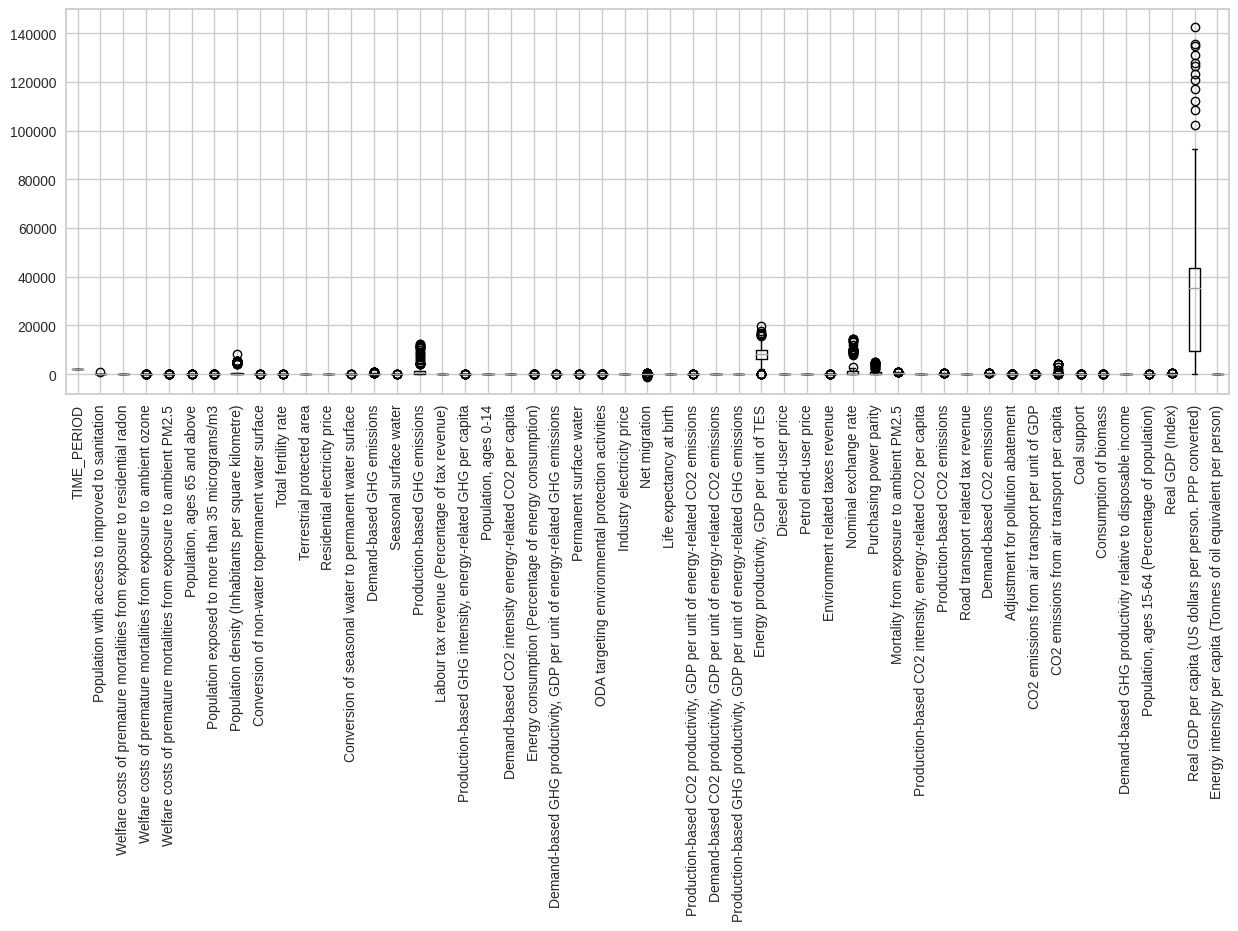

In [ ]:
# Memeriksa outlier data

plt.figure(figsize=(15,5))
df.boxplot()
plt.xticks(rotation=90)
plt.show()

**Code Explanation:**
- plt.figure(figsize=(15,5)) digunakan untuk mengatur ukuran gambar yang akan ditampilkan, yakni dengan ukuran panjangnya adalah 15 dan lebarnya 5.
- df.boxplot() berfungsi untuk membuat boxplot dari DataFrame df.
- plt.xticks(rotation=90) untuk memutar label pada sumbu x sebesar 90 derajat, agar lebih mudah dibaca.
- plt.show() menampilkan plot yang telah dibuat.


**Insight:**
- Parameter yang memiliki outlier paling banyak adalah Real GDP per capita (US dollars per person. PPP converted),
- Tidak perlu mengatasi outlier pada variabel tersebut, sebab data tersebut mencerminkan perbedaan dan kondisi perekonomian antar negara. Tentu negara-negara yang sudah maju mengalami pertumbuhan ekonomi yanh pesat sehingga memiliki nilai GDP per capita yang sangat tinggi. Menghapus / handling data akan mengakibatkan hilangnya informasi tentang perkembangan ekonomi tiap negara

### 2.2.4. Check Imbalance Data

Sebelum memeriksa imbalance data, akan diperiksa terlebih dahulu tipe data dari setiap kolom. Berikutnya, akan diperiksa keseimbangan jumlah data dari kolom yang merupakan object atau boolean.

In [ ]:
df.dtypes

,0
TIME_PERIOD,int64
Reference area,object
Population with access to improved to sanitation,float64
Welfare costs of premature mortalities from exposure to residential radon,float64
Welfare costs of premature mortalities from exposure to ambient ozone,float64
Welfare costs of premature mortalities from exposure to ambient PM2.5,float64
"Population, ages 65 and above",float64
Population exposed to more than 35 micrograms/m3,float64
Population density (Inhabitants per square kilometre),float64
Conversion of non-water topermanent water surface,float64


**Code Explanation:**

df.dtypes merupakan kode yang dapat digunakan untuk menampilkan tipe data dari setiap kolom dalam data frame df.

**Insight:**

Dari output yang diperoleh, dapat diketahui bahwa sebagian besar tipe data kolom merupakan float64 yang merupakan bilangan desimal, namun kolom Reference area memiliki tipe data object karena isinya merupakan teks/string dari sebuah nama negara.


Selanjutnya, akan diperiksa jumlah data dari setiap negara pada kolom Reference area karena Reference area merupakan satu-satunya kolom yang tipe datanya berupa object.


In [ ]:
df['Reference area'].value_counts()

,count
Reference area,
Saudi Arabia,33
Indonesia,33
Japan,33
Korea,33
Singapore,33
China (People’s Republic of),33


**Code Explanation:**

df['Reference area'].value_counts()  merupakan kode yang dapat digunakan untuk menghitung jumlah kemunculan setiap nilai unik dalam kolom Reference are dari Data Frame (df).

**Insight:**

Data sudah balance karena setiap negara memiliki jumlah data yang sama yaitu sebanyak 33 data setiap negara.

### 2.2.5. Check Anomaly Data - Negative Value

In [ ]:
df1 = df.copy()
df1.drop(columns=['Reference area','TIME_PERIOD'], inplace = True)
df1.head()

,Population with access to improved to sanitation,Welfare costs of premature mortalities from exposure to residential radon,Welfare costs of premature mortalities from exposure to ambient ozone,Welfare costs of premature mortalities from exposure to ambient PM2.5,"Population, ages 65 and above",Population exposed to more than 35 micrograms/m3,Population density (Inhabitants per square kilometre),Conversion of non-water topermanent water surface,Total fertility rate,Terrestrial protected area,...,Adjustment for pollution abatement,CO2 emissions from air transport per unit of GDP,CO2 emissions from air transport per capita,Coal support,Consumption of biomass,Demand-based GHG productivity relative to disposable income,"Population, ages 15-64 (Percentage of population)",Real GDP (Index),Real GDP per capita (US dollars per person. PPP converted),Energy intensity per capita (Tonnes of oil equivalent per person)
0,0.0,0.00,0.10,2.71,2.52,97.7,7.55,0.0,5.83,3.25,...,0.00,0.0,0.0,0.0,13.63,0.0,57.16,77.51,41130.14,3.57
1,0.0,0.00,0.09,2.99,2.51,0.0,7.80,0.0,5.66,0.00,...,-1.62,0.0,0.0,0.0,14.14,0.0,57.49,89.14,45783.05,4.03
2,0.0,0.00,0.09,3.26,2.50,0.0,8.40,0.0,5.49,0.00,...,-1.63,0.0,0.0,0.0,16.52,0.0,57.84,92.69,46203.80,4.45
3,0.0,0.01,0.09,3.54,2.50,0.0,8.26,0.0,5.32,0.00,...,-1.11,0.0,0.0,0.0,13.11,0.0,58.34,91.43,44340.64,4.50
4,0.0,0.01,0.09,3.80,2.51,0.0,8.47,0.0,5.14,0.00,...,-0.67,0.0,0.0,0.0,15.04,0.0,59.07,91.94,43483.92,4.61


In [ ]:
df1.dtypes[df1.dtypes == 'object']

,0


In [ ]:
df1.columns[(df1 < 0).any()]

Index(['Net migration', 'Adjustment for pollution abatement'], dtype='object')

**Insight:**
Terdapat anomali data pada kolom Net migration, Adjustment for pollution abatement karena memiliki data yang bernilai negatif

### 2.2.6. Feature Encoding

Berdasarkan data yang kami gunakan hanya terdapat kolom "Reference Area" saja yang merupakan data kategori yang memiliki makna intrinsik sebagai label bukan sebagai nilai numerik sehingga pada data yang kami gunakan tidak memerlukan "Feature Encoding"

### 2.2.7. Data Filtering

In [ ]:
DatasetFinal = df[['Reference area','TIME_PERIOD','Labour tax revenue (Percentage of tax revenue)','Population density (Inhabitants per square kilometre)','Population, ages 15-64 (Percentage of population)','Real GDP (Index)','Real GDP per capita (US dollars per person. PPP converted)','Energy consumption (Percentage of energy consumption)','Energy intensity per capita (Tonnes of oil equivalent per person)']]
DatasetFinal

,Reference area,TIME_PERIOD,Labour tax revenue (Percentage of tax revenue),Population density (Inhabitants per square kilometre),"Population, ages 15-64 (Percentage of population)",Real GDP (Index),Real GDP per capita (US dollars per person. PPP converted),Energy consumption (Percentage of energy consumption),Energy intensity per capita (Tonnes of oil equivalent per person)
0,Saudi Arabia,1990,0.00,7.55,57.16,77.51,41130.14,27.60,3.57
1,Saudi Arabia,1991,0.00,7.80,57.49,89.14,45783.05,26.72,4.03
2,Saudi Arabia,1992,0.00,8.40,57.84,92.69,46203.80,27.14,4.45
3,Saudi Arabia,1993,0.00,8.26,58.34,91.43,44340.64,25.66,4.50
4,Saudi Arabia,1994,0.00,8.47,59.07,91.94,43483.92,28.28,4.61
...,...,...,...,...,...,...,...,...,...
193,China (People’s Republic of),2018,1.51,148.71,73.21,487.11,15206.37,48.84,2.27
194,China (People’s Republic of),2019,32.30,149.35,72.97,516.87,16066.44,48.60,2.36
195,China (People’s Republic of),2020,29.87,149.93,72.80,527.18,16323.76,49.17,2.43
196,China (People’s Republic of),2021,0.00,150.44,72.76,568.24,17535.56,0.00,0.00


**Code & Explanation:**


*   DatasetFinal = df[['Reference area','TIME_PERIOD','Labour tax revenue (Percentage of tax revenue)','Population density (Inhabitants per square kilometre)','Population, ages 15-64 (Percentage of population)','Real GDP (Index)','Real GDP per capita (US dollars per person. PPP converted)','Energy consumption (Percentage of energy consumption)','Energy intensity per capita (Tonnes of oil equivalent per person)']] -> Membentuk data frame baru dengan nama DatasetFinal dengan kolom-kolom yang ditentukan

**Insight:**

Terbentuk datasetfinal untuk memudahkan analisis.


*   Labour tax revenue -> Pendapatan pajak per tenaga kerja
*   Population, ages 15-64 -> Usia produktif suatu negara
*   Population density -> kepadatan penduduk (untuk mengetahui perbandingan kepadatan penduduk dengan usia produktif)
*   Real GDP -> Nilai total dari semua barang dan jasa yang diproduksi dalam suatu negara selama periode waktu tertentu.
*   Real GDP per capita -> Ukuran ekonomi yang mengindikasikan rata-rata output atau pendapatan ekonomi per orang, disesuaikan dengan inflasi.
*   Energy consumption -> Merujuk pada jumlah energi yang digunakan oleh individu, rumah tangga, industri, atau negara dalam periode tertentu. Ini bisa berupa listrik, bahan bakar fosil, atau sumber energi terbarukan.
*   Energy intensity per capita -> Ukuran yang menunjukkan jumlah energi yang digunakan per orang dalam suatu populasi











### 2.2.8. Data Transformation

In [ ]:
ReplaceName = {
    'Labour tax revenue (Percentage of tax revenue)': 'Labour tax revenue',
    'Population density (Inhabitants per square kilometre)': 'Population density',
    'Population, ages 15-64 (Percentage of population)' : 'Population, ages 15-64',
    'Real GDP (Index)' : 'Real GDP',
    'Real GDP per capita (US dollars per person. PPP converted)': 'Real GDP per capita',
    'Energy consumption (Percentage of energy consumption)': 'Energy consumption',
    'Energy intensity per capita (Tonnes of oil equivalent per person)': 'Energy intensity per capita'
}
# Rename column names
DatasetFinal.rename(
    columns=ReplaceName,
    inplace=True
)
DatasetFinal.head()

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita
0,Saudi Arabia,1990,0.0,7.55,57.16,77.51,41130.14,27.60,3.57
1,Saudi Arabia,1991,0.0,7.80,57.49,89.14,45783.05,26.72,4.03
2,Saudi Arabia,1992,0.0,8.40,57.84,92.69,46203.80,27.14,4.45
3,Saudi Arabia,1993,0.0,8.26,58.34,91.43,44340.64,25.66,4.50
4,Saudi Arabia,1994,0.0,8.47,59.07,91.94,43483.92,28.28,4.61


**Code&Explanation**



*   ReplaceName = {
    'Labour tax revenue (Percentage of tax revenue)': 'Labour tax revenue',
    'Population density (Inhabitants per square kilometre)': 'Population density',
    'Population, ages 15-64 (Percentage of population)' : 'Population, ages 15-64',
    'Real GDP (Index)' : 'Real GDP',
    'Real GDP per capita (US dollars per person. PPP converted)': 'Real GDP per capita',
    'Energy consumption (Percentage of energy consumption)': 'Energy consumption',
    'Energy intensity per capita (Tonnes of oil equivalent per person)': 'Energy intensity per capita'
} -> Membentuk dictionary bernama ReplaceName dengan isi 'Nama kolom lama' : 'Nama kolom baru'
*   DatasetFinal.rename(
    columns=ReplaceName,
    inplace=True
) -> Melakukan perubahan langsung pada DatasetFinal berdasarkan dictionary Replac

**Insight:**

Dengan perubahan nama kolom yang dibentuk, diharapkan dapat memudahkan dalam tahap analisis berikutnya.

# 3. Exploratory Data Analysis

In [ ]:
# Memfilter data untuk Indonesia
DatasetIndo = DatasetFinal[DatasetFinal['Reference area'] == 'Indonesia']
DatasetSG = DatasetFinal[DatasetFinal['Reference area'] == 'Singapore']
DatasetJPN = DatasetFinal[DatasetFinal['Reference area'] == 'Japan']
DatasetKor = DatasetFinal[DatasetFinal['Reference area'] == 'Korea']
DatasetArab = DatasetFinal[DatasetFinal['Reference area'] == 'Saudi Arabia']
DatasetChina = DatasetFinal[DatasetFinal['Reference area'] == 'China (People’s Republic of)']

*  Memfilter data pernegara




> DatasetIndo = DatasetFinal[DatasetFinal['Reference area'] == 'Indonesia']


Mengelompokkan data pada DatasetFinal berdasarkan label pada Reference area, pada kode ini label yang diminta adalah Indonesia, ini artinya data dikelompokkan berdasarkan negara Indonesia. Hal yang sama dilakukan pada negara Singapore, Korea, Japan, Saudi Arabia, dan China.





## 3.1. Elaborasi Features dan Tipe Data (Nominal, Ordinal, Numerical)

In [ ]:
# Memilih kolom-kolom yang bertipe object dan category
nominal_columns = DatasetFinal.select_dtypes(include=['object', 'category']).columns

# Menampilkan kolom-kolom tersebut
print(nominal_columns)

Index(['Reference area'], dtype='object')


Code Explanation :
Kode ini memilih kolom yang bertipe data 'object' atau 'category' yaitu kolom dengan data nominal ('object' atau 'category'). Kemudian menampilkan hasilnya dengan perintah print.

Insight : Berdasarkan output tersebut diketahui kolom Reference area  merupakan kolom dengan data nominal dari DataFrame DatasetFinal.

In [ ]:
# Memilih kolom-kolom yang bertipe category dan ordered
ordinal_columns = [col for col in DatasetFinal.select_dtypes(include=['category']).columns if DatasetFinal[col].cat.ordered]

# Menampilkan kolom-kolom yang bertipe ordinal
print(ordinal_columns)

[]


Code Explanation : Kode ini memilih kolom bertipe kategori yang bersifat ordinal (memiliki urutan) dari DataFrame DatasetFinal. Kolom-kolom ordinal ini dipilih berdasarkan apakah kategorinya terurut (ordered). Kemudian hasilnya di tampilkan dengan perintah print.

Insight : Berdasarkan output tersebut diketahui bahwa tidak ada kolom dengan data ordinal pada DataFrame DatasetFinal.

In [ ]:
# Memilih kolom yang bertipe data numerik (int atau float)
numerical_columns = DatasetFinal.select_dtypes(include=['number']).columns

# Menampilkan kolom-kolom tersebut
print(numerical_columns)

Index(['TIME_PERIOD', 'Labour tax revenue', 'Population density',
       'Population, ages 15-64', 'Real GDP', 'Real GDP per capita',
       'Energy consumption', 'Energy intensity per capita'],
      dtype='object')


Code Explanation : Kode ini memilih kolom-kolom yang bertipe data numerik (baik int maupun float) dari DataFrame DatasetFinal. Kemudian menampilkan hasilnya dengan perintah print.

Insight :  Berdasarkan output tersebut diketahui kolom TIME_PERIOD', 'Labour tax revenue', 'Population density', 'Population, ages 15-64', 'Real GDP', 'Real GDP per capita', 'Energy consumption', 'Energy intensity per capita' merupakan kolom yang bertipe data numerik dari DataFrame DatasetFinal.

## 3.2. Mean, Median, Modus

Menjelaskan kondisi dan perbedaan penggunaan mean, median, dan modus.

In [ ]:
# Nilai Mean, Median, dan Modus Labour tax revenue di 6 Negara Asia

# Mencari Mean
mean_value = DatasetFinal['Labour tax revenue'].mean()
print(f"Mean: {mean_value}")

# Mencari Median
median_value = DatasetFinal['Labour tax revenue'].median()
print(f"Median: {median_value}")

# Mencari Modus
mode_value = DatasetFinal['Labour tax revenue'].mode()
print(f"Modus: {mode_value}")

Mean: 18.698535353535352
Median: 12.655
Modus: 0    0.0
Name: Labour tax revenue, dtype: float64


**Code Explanation:**

*   import pandas as pd: Mengimpor library Pandas untuk manipulasi data.
*   DatasetFinal = pd.read_csv('path/to/your/dataset.csv'): Membaca dataset CSV ke dalam DataFrame Pandas. Ganti 'path/to/your/dataset.csv' dengan path sebenarnya ke file CSV Anda.
*   Menggunakan fungsi .mean() untuk menghitung nilai rata-rata dari kolom Labour tax revenue
*   Menggunakan fungsi .median() untuk menemukan nilai tengah dari data dalam kolom Labour tax revenue.
*   Menggunakan fungsi .mode() untuk menemukan nilai yang paling sering muncul dalam kolom Labour tax revenue.



**Insight:**

*   Mean memberikan nilai rata-rata kontribusi Labour tax revenue, tetapi bisa terpengaruh oleh nilai ekstrem (outliers).
Median adalah ukuran yang lebih stabil untuk melihat nilai tengah karena tidak terpengaruh oleh outlier.
*   Modus memberikan informasi tentang nilai yang paling sering muncul, yang dapat membantu mengidentifikasi tren atau pola dominan dalam data.


In [ ]:
# Nilai Mean, Median, dan Modus Population density di 6 Negara Asia

# Mencari Mean
mean_value = DatasetFinal['Population density'].mean()
print(f"Mean: {mean_value}")

# Mencari Median
median_value = DatasetFinal['Population density'].median()
print(f"Median: {median_value}")

# Mencari Modus
mode_value = DatasetFinal['Population density'].mode()
print(f"Modus: {mode_value}")

Mean: 1020.802424242424
Median: 150.185
Modus: 0    0.0
Name: Population density, dtype: float64


**Code Explanation:**


*   Menggunakan fungsi .mean() untuk menghitung nilai rata-rata dari kolom Population density
*   Menggunakan fungsi .median() untuk menemukan nilai tengah dari data dalam kolom Population density
*   Menggunakan fungsi .mode() untuk menemukan nilai yang paling sering muncul dalam kolom Population density






**Insight:**


*   Mean memberikan nilai rata-rata kontribusi Population density, tetapi bisa terpengaruh oleh nilai ekstrem (outliers).
*   Median adalah ukuran yang lebih stabil untuk melihat nilai tengah karena tidak terpengaruh oleh outlier.
*   Modus memberikan informasi tentang nilai yang paling sering muncul, yang dapat membantu mengidentifikasi tren atau pola dominan dalam data.

In [ ]:
# Nilai Mean, Median, dan Modus Population, ages 15-64 di 6 Negara Asia

# Mencari Mean
mean_value = DatasetFinal['Population, ages 15-64'].mean()
print(f"Mean: {mean_value}")

# Mencari Median
median_value = DatasetFinal['Population, ages 15-64'].median()
print(f"Median: {median_value}")

# Mencari Modus
mode_value = DatasetFinal['Population, ages 15-64'].mode()
print(f"Modus: {mode_value}")

Mean: 68.98621212121212
Median: 71.845
Modus: 0    0.0
Name: Population, ages 15-64, dtype: float64


**Code Explanation:**


*   Menggunakan fungsi .mean() untuk menghitung nilai rata-rata dari kolom Population, ages 15-64
*   Menggunakan fungsi .median() untuk menemukan nilai tengah dari data dalam kolom Population, ages 15-64
*   Menggunakan fungsi .mode() untuk menemukan nilai populasi usia 15-64 tahun yang paling sering muncul dalam dataset.





**Insight:**


*   Mean memberikan nilai rata-rata kontribusi Population, ages 15-64, tetapi bisa terpengaruh oleh nilai ekstrem (outliers).
*   Median adalah ukuran yang lebih stabil untuk melihat nilai tengah karena tidak terpengaruh oleh outlier.
*   Modus memberikan informasi tentang nilai yang paling sering muncul, yang dapat membantu mengidentifikasi tren atau pola dominan dalam data.

In [ ]:
# Nilai Mean, Median, dan Modus Real GDP di 6 Negara Asia

# Mencari Mean
mean_value = DatasetFinal['Real GDP'].mean()
print(f"Mean: {mean_value}")

# Mencari Median
median_value = DatasetFinal['Real GDP'].median()
print(f"Median: {median_value}")

# Mencari Modus
mode_value = DatasetFinal['Real GDP'].mode()
print(f"Modus: {mode_value}")

Mean: 143.06580808080807
Median: 111.91
Modus: 0      0.0
1    100.0
Name: Real GDP, dtype: float64


**Code Explanation:**


*   Menggunakan fungsi .mean() untuk menghitung nilai rata-rata dari kolom Real GDP
*   Menggunakan fungsi .median() untuk menemukan nilai tengah dari data dalam kolom Real GDP
*   Menggunakan fungsi .mode() untuk menemukan nilai yang paling sering muncul dalam kolom Real GDP





**Insight:**


*   Mean memberikan nilai rata-rata kontribusi Real GDP, tetapi bisa terpengaruh oleh nilai ekstrem (outliers).
*   Median adalah ukuran yang lebih stabil untuk melihat nilai tengah karena tidak terpengaruh oleh outlier.
*   Modus memberikan informasi tentang nilai yang paling sering muncul, yang dapat membantu mengidentifikasi tren atau pola dominan dalam data.

In [ ]:
# Nilai Mean, Median, dan Modus Real GDP per capita di 6 Negara Asia

# Mencari Mean
mean_value = DatasetFinal['Real GDP per capita'].mean()
print(f"Mean: {mean_value}")

# Mencari Median
median_value = DatasetFinal['Real GDP per capita'].median()
print(f"Median: {median_value}")

# Mencari Modus
mode_value = DatasetFinal['Real GDP per capita'].mode()
print(f"Modus: {mode_value}")

Mean: 34426.59671717172
Median: 35546.285
Modus: 0    0.0
Name: Real GDP per capita, dtype: float64


**Code Explanation:**


*   Menggunakan fungsi .mean() untuk menghitung nilai rata-rata dari kolom Real GDP per capita.

*   Menggunakan fungsi .median() untuk menemukan nilai tengah dari data dalam kolom Real GDP per capita.

*   Menggunakan fungsi .mode() untuk menemukan nilai yang paling sering muncul dalam kolom Real GDP per capita.






**Insight:**

Analisis ini membantu memahami distribusi dan pola dari pendapatan per kapita di negara-negara tersebut:
*   Mean menggambarkan pendapatan rata-rata per kapita di 6 negara Asia.
*   Median menunjukkan nilai tengah dari pendapatan per kapita, yang kurang dipengaruhi oleh outlier.
*   Modus mengidentifikasi nilai pendapatan per kapita yang paling sering muncul, yang dapat mengungkapkan pola dominan dalam data.

In [ ]:
# Nilai Mean, Median, dan Modus Energy consumption di 6 Negara Asia

# Mencari Mean
mean_value = DatasetFinal['Energy consumption'].mean()
print(f"Mean: {mean_value}")

# Mencari Median
median_value = DatasetFinal['Energy consumption'].median()
print(f"Median: {median_value}")

# Mencari Modus
mode_value = DatasetFinal['Energy consumption'].mode()
print(f"Modus: {mode_value}")

Mean: 29.024090909090912
Median: 28.884999999999998
Modus: 0    0.0
Name: Energy consumption, dtype: float64


**Code Explanation:**


*   Menggunakan fungsi .mean() menghitung rata-rata konsumsi energi. Mean memberikan gambaran umum tentang tingkat konsumsi energi secara keseluruhan.

*   Menggunakan fungsi .median() menghitung nilai tengah dari konsumsi energi. Median lebih tahan terhadap outlier dan menunjukkan nilai yang lebih representatif di tengah data.

*   Menggunakan fungsi .mode() mencari nilai yang paling sering muncul dalam data konsumsi energi. Modus memberikan informasi tentang nilai konsumsi yang paling umum.





**Insight:**

Analisis ini membantu memahami distribusi dan pola dari Energy consumption di negara-negara tersebut:
*   Mean menggambarkan Energy consumption di 6 negara Asia.
*   Median menunjukkan nilai tengah dari pendapatan per kapita, yang kurang dipengaruhi oleh outlier.
*   Modus mengidentifikasi nilai pendapatan per kapita yang paling sering muncul, yang dapat mengungkapkan pola dominan dalam data.

In [ ]:
# Nilai Mean, Median, dan Modus Energy intensity per capita di 6 Negara Asia

# Mencari Mean
mean_value = DatasetFinal['Energy intensity per capita'].mean()
print(f"Mean: {mean_value}")

# Mencari Median
median_value = DatasetFinal['Energy intensity per capita'].median()
print(f"Median: {median_value}")

# Mencari Modus
mode_value = DatasetFinal['Energy intensity per capita'].mode()
print(f"Modus: {mode_value}")

Mean: 3.5943939393939397
Median: 3.775
Modus: 0    0.0
Name: Energy intensity per capita, dtype: float64


**Code Explanation:**


*   Menghitung rata-rata (mean) dari kolom Energy intensity per capita dalam DataFrame DatasetFinal.

*   Menghitung nilai median dari kolom Energy intensity per capita. Median adalah nilai tengah ketika data diurutkan..

*   Menghitung modus dari kolom Energy intensity per capita. Modus adalah nilai yang paling sering muncul dalam dataset.





**Insight:**

Analisis ini membantu memahami distribusi dan pola dari Energy intensity per capita di negara-negara tersebut:
*   Mean memberikan informasi tentang rata-rata intensitas energi per kapita di antara negara-negara tersebut.
*   Median memberi tahu kita nilai tengah, yang berguna untuk memahami distribusi data, terutama jika ada outlier.
*   Modus menunjukkan nilai yang paling sering muncul, yang bisa menjadi indikator pola konsumsi energi di negara-negara tersebut.

In [ ]:
# Berikut kita cari data mean, median dam modus pada DatasetIndo
# Mencari Mean dari DatasetIndo pada kolom Labour Tax Revenue nya
mean_value = DatasetIndo['Labour tax revenue'].mean()
print(f"Mean: {mean_value}")

# Mencari Median dari DatasetIndo pada kolom Labour Tax Revenue nya
median_value = DatasetIndo['Labour tax revenue'].median()
print(f"Median: {median_value}")

# Mencari Modus dari DatasetIndo pada kolom Labour Tax Revenue nya
mode_value = DatasetIndo['Labour tax revenue'].mode()
print(f"Modus: {mode_value}")

Mean: 7.537878787878788
Median: 8.35
Modus: 0    0.0
Name: Labour tax revenue, dtype: float64


**Code Explanation:**

*   Menghitung rata-rata (mean) dari kolom Labour tax revenue dalam DataFrame DatasetIndo.
*   Menghitung nilai median (nilai tengah) dari kolom Labour tax revenue.
*   Menggunakan fungsi .mode() untuk menemukan nilai yang paling sering muncul dalam kolom Labour tax revenue.






**Insight:**


*   Mean memberikan nilai rata-rata kontribusi Labour tax revenue, tetapi bisa terpengaruh oleh nilai ekstrem (outliers).
*   Median adalah ukuran yang lebih stabil untuk melihat nilai tengah karena tidak terpengaruh oleh outlier. Berfungsi untuk mengidentifikasi pusat distribusi data, terutama jika terdapat outlier yang bisa mempengaruhi mean.
*   Menghitung modus (nilai yang sering muncul) dari kolom Labour tax revenue. Ini untuk menunjukkan nilai yang paling umum terjadi dalam pendapatan pajak tenaga kerja di Indonesia.


In [ ]:
# Mencari Mean dari DatasetIndo pada kolom Population density nya
mean_value = DatasetIndo['Population density'].mean()
print(f"Mean: {mean_value}")

# Mencari Median dari DatasetIndo pada kolom Population density nya
median_value = DatasetIndo['Population density'].median()
print(f"Median: {median_value}")

# Mencari Modus dari DatasetIndo pada kolom Population density nya
mode_value = DatasetIndo['Population density'].mode()
print(f"Modus: {mode_value}")

Mean: 115.56090909090909
Median: 118.42
Modus: 0       0.00
1      94.93
2      96.60
3      98.25
4      99.87
5     101.48
6     103.06
7     104.61
8     106.14
9     107.66
10    109.17
11    110.69
12    112.21
13    113.74
14    115.29
15    116.85
16    118.42
17    120.00
18    121.60
19    123.22
20    124.87
21    126.55
22    128.27
23    130.02
24    131.77
25    133.51
26    133.57
27    135.09
28    136.35
29    137.81
30    139.24
31    140.65
32    142.02
Name: Population density, dtype: float64


**Code Explanation:**


*   Menghitung nilai rata-rata (mean) dari kolom Population density dalam DataFrame DatasetIndo. Menunjukkan rata-rata kepadatan penduduk di Indonesia, yang diperoleh dengan membagi total kepadatan penduduk dengan jumlah data.
*   Menghitung nilai median dari kolom Population density. Nilai tengah dari data kepadatan penduduk saat diurutkan. Median berguna untuk menunjukkan titik tengah dari distribusi data, terutama jika ada outlier yang dapat mempengaruhi rata-rata.
*   Menghitung modus dari kolom Population density. Nilai yang paling sering muncul dalam dataset. Ini menunjukkan tingkat kepadatan penduduk yang paling umum atau paling sering terjadi di Indonesia.






**Insight:**


*   Mean memberikan gambaran tentang kepadatan penduduk rata-rata di seluruh wilayah Indonesia. Jika mean cukup tinggi atau rendah, itu bisa menunjukkan distribusi yang merata atau adanya wilayah-wilayah dengan kepadatan tinggi yang mempengaruhi rata-rata.
*   Median lebih tahan terhadap nilai ekstrem (outlier) dan memberikan nilai tengah yang lebih representatif dari distribusi kepadatan penduduk. Ini membantu kita memahami distribusi populasi dengan lebih jelas.
*   Modus menunjukkan nilai kepadatan penduduk yang paling sering terjadi, yang dapat membantu mengidentifikasi wilayah dengan tingkat kepadatan penduduk yang paling umum atau dominan.

In [ ]:
# Mencari Mean dari DatasetIndo pada kolom Population, ages 15-64 nya
mean_value = DatasetIndo['Population, ages 15-64'].mean()
print(f"Mean: {mean_value}")

# Mencari Median dari DatasetIndo pada kolom Population, ages 15-64 nya
median_value = DatasetIndo['Population, ages 15-64'].median()
print(f"Median: {median_value}")

# Mencari Modus dari DatasetIndo pada kolom Population, ages 15-64 nya
mode_value = DatasetIndo['Population, ages 15-64'].mode()
print(f"Modus: {mode_value}")

Mean: 64.7439393939394
Median: 67.33
Modus: 0      0.00
1     61.75
2     62.22
3     62.69
4     63.16
5     63.63
6     64.08
7     64.52
8     64.93
9     65.33
10    65.73
11    66.08
12    66.36
13    66.62
14    66.87
15    67.12
16    67.33
17    67.51
18    67.67
19    67.80
20    67.94
21    68.09
22    68.24
23    68.39
24    68.55
25    68.71
26    68.86
27    69.02
28    69.17
29    69.32
30    69.46
31    69.61
32    69.79
Name: Population, ages 15-64, dtype: float64


**Code Explanation:**




*   Menghitung rata-rata (mean) dari kolom Population, ages 15-64 dalam DataFrame DatasetIndo. Menunjukkan rata-rata jumlah penduduk berusia 15-64 tahun di Indonesia, yang memberikan gambaran umum tentang populasi usia produktif.
*   Menghitung nilai median dari kolom Population, ages 15-64. Nilai tengah dari data populasi usia 15-64 tahun ketika diurutkan.
Modus:
*   Menghitung modus dari kolom Population, ages 15-64. Nilai yang paling sering muncul dalam dataset, menunjukkan jumlah populasi usia 15-64 tahun yang paling umum terjadi.










**Insight:**




*   Mean memberikan informasi tentang rata-rata populasi usia 15-64 tahun, yang merupakan kelompok usia produktif. Data ini penting untuk analisis tenaga kerja dan perencanaan ekonomi.
*   Median membantu memahami distribusi populasi usia 15-64 tahun dengan lebih baik, terutama jika ada wilayah dengan populasi yang sangat besar atau sangat kecil.
*   Modus menunjukkan nilai populasi usia 15-64 tahun yang paling sering terjadi, yang dapat digunakan untuk mengidentifikasi ukuran populasi yang paling umum dalam kelompok usia ini di Indonesia.

In [ ]:
# Mencari Mean dari DatasetIndo pada kolom Real GDP nya
mean_value = DatasetIndo['Real GDP'].mean()
print(f"Mean: {mean_value}")

# Mencari Median dari DatasetIndo pada kolom Real GDP nya
median_value = DatasetIndo['Real GDP'].median()
print(f"Median: {median_value}")

# Mencari Modus dari DatasetIndo pada kolom Real GDP nya
mode_value = DatasetIndo['Real GDP'].mode()
print(f"Modus: {mode_value}")

Mean: 146.06636363636363
Median: 125.98
Modus: 0       0.00
1      68.38
2      73.15
3      77.95
4      82.85
5      89.10
6      94.56
7      95.31
8      96.43
9     100.00
10    103.64
11    103.96
12    108.31
13    108.85
14    113.48
15    119.19
16    125.98
17    132.91
18    141.34
19    149.84
20    156.89
21    166.89
22    177.19
23    187.87
24    198.31
25    208.24
26    218.40
27    229.39
28    241.02
29    253.49
30    260.72
31    266.21
32    270.34
Name: Real GDP, dtype: float64


**Code Explanation:**

*   Menghitung nilai rata-rata (mean) dari kolom 'Real GDP' dalam dataset DatasetIndo. Mean memberikan gambaran umum tentang kondisi ekonomi rata-rata Indonesia.
*   Menghitung nilai tengah (median) dari 'Real GDP'. Memberikan informasi tentang pusat distribusi data, yang lebih andal daripada mean jika terdapat outlier yang besar.
*   Menggunakan fungsi .mode() untuk menemukan nilai yang paling sering muncul dalam kolom Real GDP. Hal ini menunjukkan nilai PDB riil yang paling umum atau sering terjadi di Indonesia.












**Insight:**

*   Mean memberikan gambaran umum tentang nilai rata-rata PDB riil di Indonesia, yang bisa digunakan untuk memahami kesehatan ekonomi negara secara keseluruhan.
*   Median lebih stabil terhadap outlier dan memberikan nilai tengah yang lebih akurat dari distribusi PDB riil, membantu dalam mengidentifikasi posisi sentral dari data.
*   Modus menunjukkan nilai PDB riil yang paling sering muncul, yang dapat menjadi indikator tentang tingkat pertumbuhan ekonomi yang sering dicapai.

In [ ]:
# Mencari Mean dari DatasetIndo pada kolom Real GDP per capita nya
mean_value = DatasetIndo['Real GDP per capita'].mean()
print(f"Mean: {mean_value}")

# Mencari Median dari DatasetIndo pada kolom Real GDP per capita nya
median_value = DatasetIndo['Real GDP per capita'].median()
print(f"Median: {median_value}")

# Mencari Modus dari DatasetIndo pada kolom Real GDP per capita nya
mode_value = DatasetIndo['Real GDP per capita'].mode()
print(f"Modus: {mode_value}")

Mean: 7509.375757575758
Median: 6749.22
Modus: 0         0.00
1      4569.76
2      4804.33
3      5033.48
4      5263.12
5      5538.80
6      5570.46
7      5572.54
8      5731.67
9      5859.79
10     5936.01
11     6040.89
12     6244.87
13     6305.09
14     6471.61
15     6506.22
16     6749.22
17     7026.44
18     7374.00
19     7714.68
20     7970.75
21     8366.42
22     8763.69
23     9167.38
24     9547.96
25     9895.42
26    10359.28
27    10758.24
28    11180.01
29    11633.59
30    11723.71
31    12038.35
32    12091.62
Name: Real GDP per capita, dtype: float64


**Code Explanation:**




*   Menggunakan fungsi .mean() untuk menghitung nilai rata-rata dari kolom Real GDP per capita. Menunjukkan rata-rata Produk Domestik Bruto (PDB) riil per kapita di Indonesia, yang mengukur rata-rata pendapatan per orang dan memberikan gambaran umum tentang kesejahteraan ekonomi rata-rata warga negara.
*   Menggunakan fungsi .median() untuk menemukan nilai tengah dari data dalam kolom Real GDP per capita. Untuk menentukan nilai pusat dari distribusi, terutama jika ada perbedaan ekstrem atau outlier dalam data.
*   Menggunakan fungsi .mode() untuk menemukan nilai yang paling sering muncul dalam kolom Real GDP per capita. Ini menunjukkan nilai PDB riil per kapita yang paling umum atau sering terjadi di Indonesia.












**Insight:**


Analisis ini membantu memahami distribusi dan pola dari pendapatan per kapita di Indonesia:
*   Mean memberikan gambaran tentang rata-rata pendapatan per kapita di Indonesia, yang merupakan indikator penting untuk memahami kesejahteraan ekonomi rata-rata penduduk.
*   Median lebih tahan terhadap nilai ekstrim dan memberikan informasi yang lebih andal tentang kesejahteraan penduduk dibandingkan dengan rata-rata, terutama dalam distribusi yang tidak merata.
*   Modus menunjukkan nilai PDB riil per kapita yang paling sering terjadi, yang dapat memberikan indikasi tentang kondisi ekonomi yang paling umum di Indonesia.

In [ ]:
# Mencari Mean dari DatasetIndo pada kolom Energy consumption nya
mean_value = DatasetIndo['Energy consumption'].mean()
print(f"Mean: {mean_value}")

# Mencari Median dari DatasetIndo pada kolom Energy consumption nya
median_value = DatasetIndo['Energy consumption'].median()
print(f"Median: {median_value}")

# Mencari Modus dari DatasetIndo pada kolom Energy consumption nya
mode_value = DatasetIndo['Energy consumption'].mode()
print(f"Modus: {mode_value}")

Mean: 26.060000000000002
Median: 26.75
Modus: 0    0.0
Name: Energy consumption, dtype: float64


**Code Explanation:**

*   Menggunakan fungsi .mean() untuk menghitung nilai rata-rata dari kolom Energy consumption. Menunjukkan rata-rata konsumsi energi di Indonesia, yang memberikan gambaran umum tentang seberapa banyak energi yang digunakan secara keseluruhan.memberikan gambaran umum tentang kesejahteraan ekonomi rata-rata warga negara.
*   Menggunakan fungsi .median() untuk menemukan nilai tengah dari data dalam kolom Energy consumption.  Ini membantu untuk memahami nilai pusat dari distribusi, terutama jika ada perbedaan ekstrem atau outlier yang dapat memengaruhi rata-rata.
*   Menggunakan fungsi .mode() untuk menemukan nilai yang paling sering muncul dalam kolom Energy consumption. Menunjukkan jumlah konsumsi energi yang paling umum atau sering terjadi di Indonesia.

**Insight:**

*  Mean memberikan gambaran tentang konsumsi energi rata-rata di Indonesia. Ini penting untuk memahami tingkat konsumsi energi secara keseluruhan di negara tersebut.
*  Median membantu melihat titik tengah dari distribusi konsumsi energi, yang lebih stabil dalam menghadapi nilai ekstrem dibandingkan dengan rata-rata.
*  Modus menunjukkan nilai konsumsi energi yang paling sering terjadi, yang dapat digunakan untuk mengidentifikasi pola konsumsi energi yang paling umum di Indonesia.

In [ ]:
# Mencari Mean dari DatasetIndo pada kolom Energy intensity per capita nya
mean_value = DatasetIndo['Energy intensity per capita'].mean()
print(f"Mean: {mean_value}")

# Mencari Median dari DatasetIndo pada kolom Energy intensity per capita nya
median_value = DatasetIndo['Energy intensity per capita'].median()
print(f"Median: {median_value}")

# Mencari Modus dari DatasetIndo pada kolom Energy intensity per capita nya
mode_value = DatasetIndo['Energy intensity per capita'].mode()
print(f"Modus: {mode_value}")

Mean: 0.7057575757575757
Median: 0.78
Modus: 0    0.79
Name: Energy intensity per capita, dtype: float64


**Code Explanation:**

*   Menggunakan fungsi .mean() untuk menghitung nilai rata-rata dari kolom Energy intensity per capita. Menunjukkan rata-rata intensitas energi per kapita di Indonesia, yang mengukur jumlah energi yang dikonsumsi per orang dalam populasi.
*   Menggunakan fungsi .median() untuk menemukan nilai tengah dari data dalam kolom Energy intensity per capita.  Untuk menunjukkan pusat distribusi data, terutama jika terdapat nilai ekstrem (outlier) yang dapat mempengaruhi mean.
*   Menggunakan fungsi .mode() untuk menemukan nilai yang paling sering muncul dalam kolom Energy intensity per capita. Menunjukkan nilai intensitas energi per kapita yang paling umum terjadi di Indonesia.

**Insight:**

*  Mean memberikan gambaran tentang seberapa banyak energi rata-rata yang dikonsumsi per orang di Indonesia, yang dapat membantu menilai efisiensi penggunaan energi dalam populasi.
*  Median memberikan informasi yang lebih stabil tentang nilai tengah dari distribusi intensitas energi per kapita, yang penting untuk menghindari distorsi akibat outlier atau nilai ekstrem.
*  Modus menunjukkan nilai intensitas energi per kapita yang paling sering terjadi, yang bisa menjadi indikator tentang tingkat konsumsi energi yang paling umum dalam populasi.

## 3.3. Statistical Five Summaries

Menemukan dan mendeskripsikan statistical five summaries.

In [ ]:
# Menggunakan describe untuk mendapatkan summary statistik
five_summary = DatasetFinal['Labour tax revenue'].describe()

# Output dari describe()
print(five_summary)

count    198.000000
mean      18.698535
std       20.838534
min        0.000000
25%        0.000000
50%       12.655000
75%       32.635000
max       60.930000
Name: Labour tax revenue, dtype: float64


In [ ]:
# Mendapatkan five-number summary secara manual
min_value = DatasetFinal['Labour tax revenue'].min()
q1 = DatasetFinal['Labour tax revenue'].quantile(0.25)
median = DatasetFinal['Labour tax revenue'].median()
q3 = DatasetFinal['Labour tax revenue'].quantile(0.75)
max_value = DatasetFinal['Labour tax revenue'].max()

# Output five-number summary
print(f"Min: {min_value}")
print(f"Q1: {q1}")
print(f"Median: {median}")
print(f"Q3: {q3}")
print(f"Max: {max_value}")


Min: 0.0
Q1: 0.0
Median: 12.655
Q3: 32.635
Max: 60.93


**Code Explanation:**
describe() memberikan ringkasan **statistik** deskriptif dari kolom Labour tax revenue, termasuk:

*   count: Jumlah data yang tersedia.
*   mean: Nilai rata-rata.
*   std: Standar deviasi, yang menunjukkan seberapa tersebar data.
*   min, 25%, 50%, 75%, max: Nilai minimum, kuartil pertama (Q1), median, kuartil ketiga (Q3), dan maksimum.

Kode ini menghitung **five-number summary** secara manual, yang terdiri dari:
*   min_value: Nilai minimum dalam dataset.
*   q1: Kuartil pertama (nilai di bawah 25% data).
*   median: Median (nilai tengah dari dataset).
*   q3: Kuartil ketiga (nilai di bawah 75% data).
*   max_value: Nilai maksimum dalam dataset.


---



**Insight:**
1.  Menggunakan metode **describe()** untuk memberikan ringkasan statistik lengkap dari kolom Labour tax revenue. Ini mencakup nilai-nilai seperti mean, standar deviasi, nilai minimum, maksimum, serta kuartil (25%, 50%, dan 75%).
2. Secara manual menghitung five-number summary dari kolom Labour tax revenue, yang terdiri dari nilai minimum, kuartil pertama (Q1), median, kuartil ketiga (Q3), dan nilai maksimum. Five-number summary ini lebih fokus pada memberikan informasi tentang rentang data, posisi tengah, serta potensi outlier, yang bisa lebih mudah diinterpretasi daripada statistik seperti mean dan standar deviasi.

In [ ]:
# Menggunakan describe untuk mendapatkan summary statistik
five_summary = DatasetFinal['Population density'].describe()

# Output dari describe()
print(five_summary)

count     198.000000
mean     1020.802424
std      1841.933483
min         0.000000
25%       115.680000
50%       150.185000
75%       483.320000
max      8276.580000
Name: Population density, dtype: float64


In [ ]:
# Mendapatkan five-number summary secara manual
min_value = DatasetFinal['Population density'].min()
q1 = DatasetFinal['Population density'].quantile(0.25)
median = DatasetFinal['Population density'].median()
q3 = DatasetFinal['Population density'].quantile(0.75)
max_value = DatasetFinal['Population density'].max()

# Output five-number summary
print(f"Min: {min_value}")
print(f"Q1: {q1}")
print(f"Median: {median}")
print(f"Q3: {q3}")
print(f"Max: {max_value}")


Min: 0.0
Q1: 115.68
Median: 150.185
Q3: 483.32000000000005
Max: 8276.58


Labour tax revenue (Percentage of tax revenue) - Five-Number Summary:
{'Minimum': 0.0, 'Q1 (Kuartil 1)': 0.0, 'Median': 12.655, 'Q3 (Kuartil 3)': 32.635, 'Maximum': 60.93}


Population density (Inhabitants per square kilometre) - Five-Number Summary:
{'Minimum': 0.0, 'Q1 (Kuartil 1)': 115.68, 'Median': 150.185, 'Q3 (Kuartil 3)': 483.32000000000005, 'Maximum': 8276.58}


Real GDP (Index) - Five-Number Summary:
{'Minimum': 0.0, 'Q1 (Kuartil 1)': 92.2575, 'Median': 111.91, 'Q3 (Kuartil 3)': 178.8575, 'Maximum': 568.24}


Real GDP per capita (US dollars per person. PPP converted) - Five-Number Summary:
{'Minimum': 0.0, 'Q1 (Kuartil 1)': 9262.525, 'Median': 35546.285, 'Q3 (Kuartil 3)': 43407.18, 'Maximum': 142761.5}


Energy consumption (Percentage of energy consumption) - Five-Number Summary:
{'Minimum': 0.0, 'Q1 (Kuartil 1)': 26.1325, 'Median': 28.884999999999998, 'Q3 (Kuartil 3)': 33.3925, 'Maximum': 56.17}


Energy intensity per capita (Tonnes of oil equivalent per person) - Five-Number

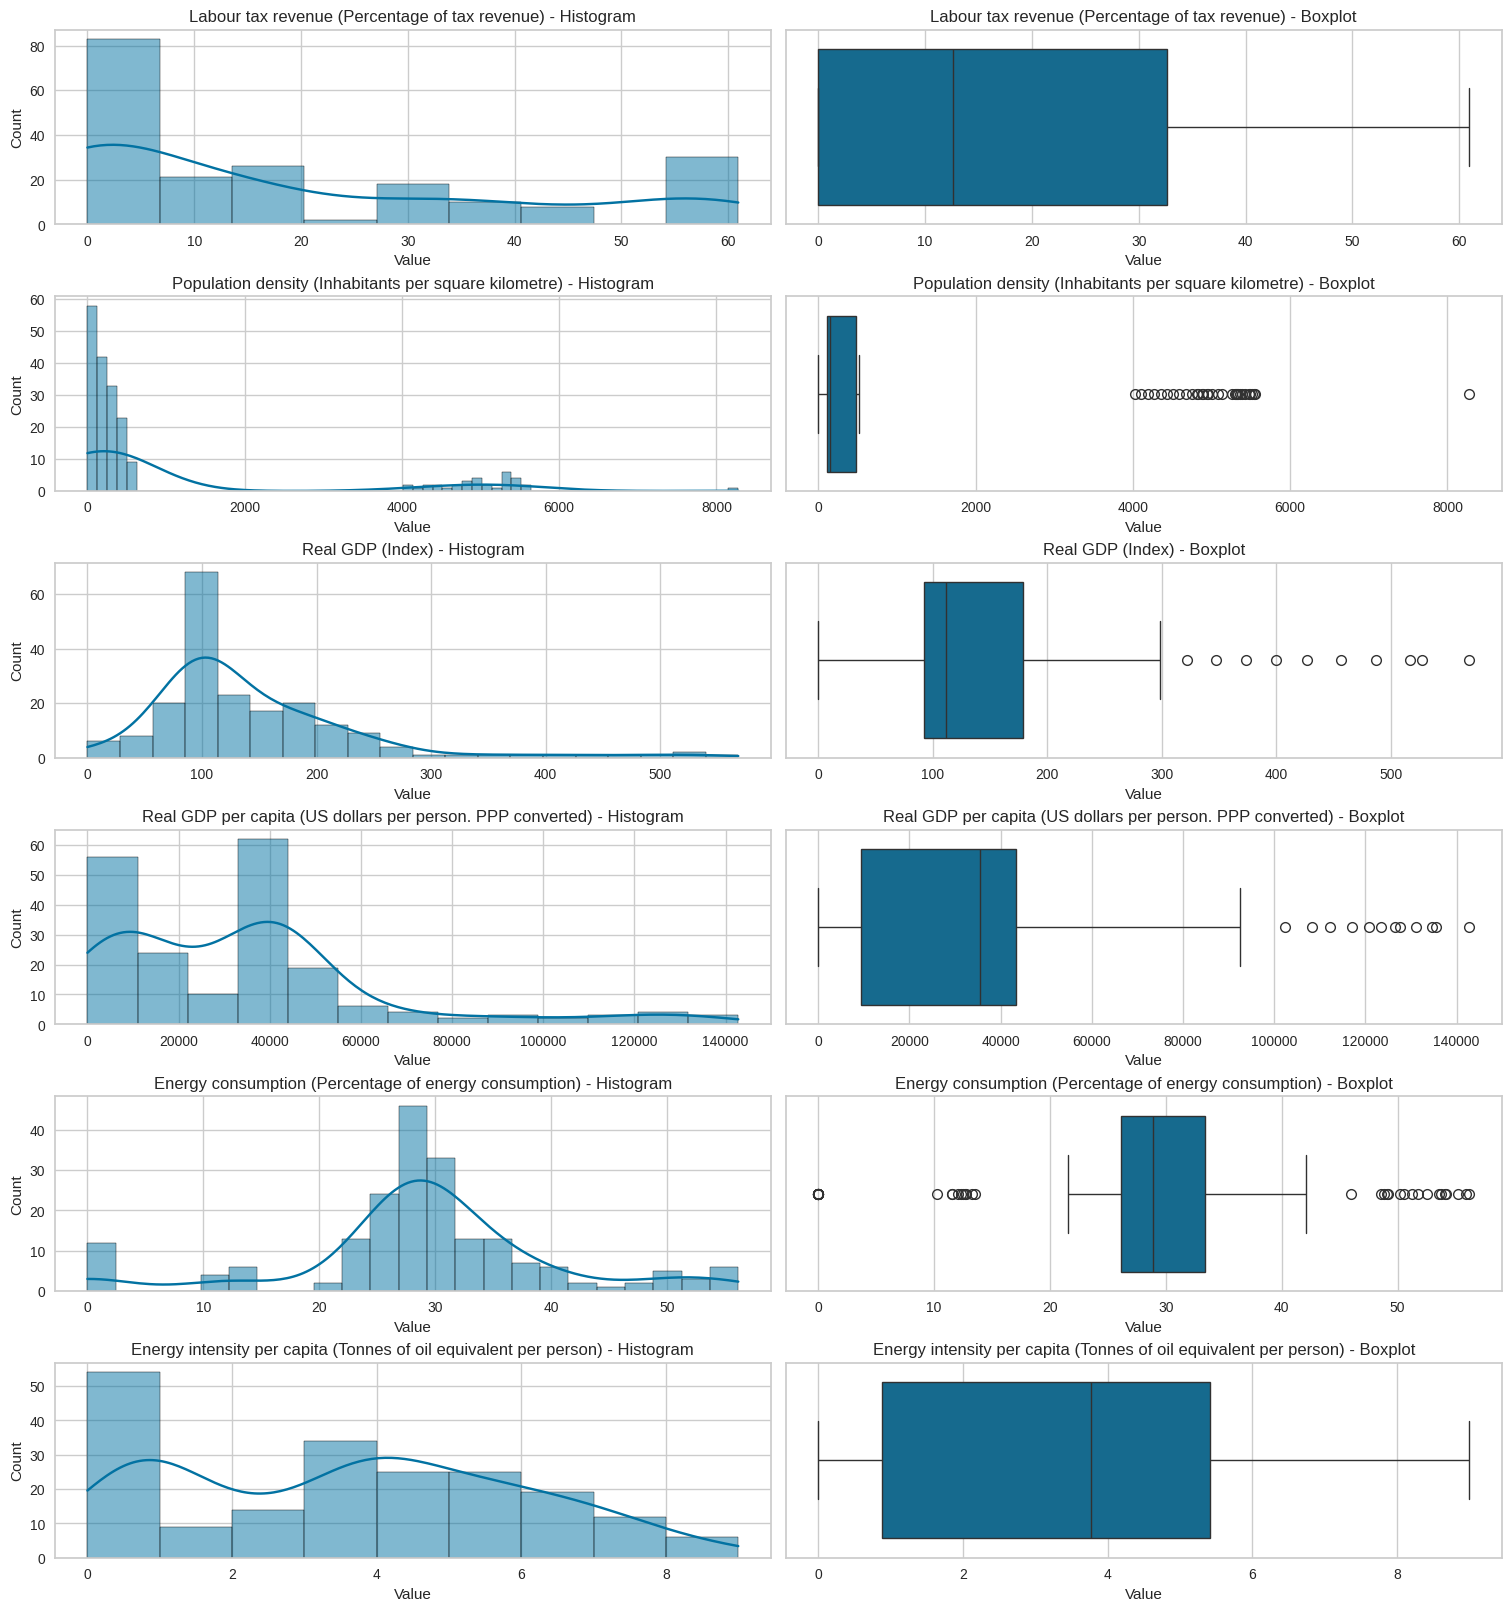

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Kolom target yang akan dianalisis (menggunakan contoh yang diberikan)
target_col = [
    'Labour tax revenue (Percentage of tax revenue)',
    'Population density (Inhabitants per square kilometre)',
    'Real GDP (Index)',
    'Real GDP per capita (US dollars per person. PPP converted)',
    'Energy consumption (Percentage of energy consumption)',
    'Energy intensity per capita (Tonnes of oil equivalent per person)'
]

# Fungsi untuk menghitung five-number summary
def five_number_summary(data):
    summary = {
        'Minimum': np.min(data),
        'Q1 (Kuartil 1)': np.percentile(data, 25),
        'Median': np.median(data),
        'Q3 (Kuartil 3)': np.percentile(data, 75),
        'Maximum': np.max(data)
    }
    return summary

# Membuat visualisasi histogram dan boxplot untuk setiap kolom
fig, axes = plt.subplots(len(target_col), 2, figsize=(15, 16), constrained_layout=True)

for i, col in enumerate(target_col):
    # Menghitung five-number summary
    summary = five_number_summary(df[col])

    # Membuat histogram dengan kde (estimasi kepadatan kernel)
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} - Histogram')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Count')

    # Membuat boxplot untuk visualisasi five-number summary
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} - Boxplot')
    axes[i, 1].set_xlabel('Value')

    # Menampilkan five-number summary di output (bisa diubah sesuai kebutuhan)
    print(f"{col} - Five-Number Summary:")
    print(summary)
    print("\n")

plt.show()


Five Summaries

In [ ]:
# Mendapatkan five-number summary secara manual
min_value = DatasetFinal['Population density'].min()
q1 = DatasetFinal['Population density'].quantile(0.25)
median = DatasetFinal['Population density'].median()
q3 = DatasetFinal['Population density'].quantile(0.75)
max_value = DatasetFinal['Population density'].max()

# Output five-number summary
print(f"Min: {min_value}")
print(f"Q1: {q1}")
print(f"Median: {median}")
print(f"Q3: {q3}")
print(f"Max: {max_value}")


Min: 0.0
Q1: 115.68
Median: 150.185
Q3: 483.32000000000005
Max: 8276.58


**Code Explanation:**

describe() memberikan ringkasan **statistik** dari kolom Population density:

*   count: Jumlah data yang tersedia.
*   mean: Nilai rata-rata dalam data.
*   std: Standar deviasi, yang menunjukkan seberapa tersebar data.
*   min, 25%, 50%, 75%, max: Nilai minimum, kuartil pertama (Q1), median, kuartil ketiga (Q3), dan maksimum.

Kode ini menghitung **five-number summary** secara manual, yang terdiri dari:

*   min_value: Nilai minimum dalam dataset.
*   q1: Kuartil pertama (nilai di bawah 25% data).
*   median: Median (nilai tengah dari dataset).
*   q3: Kuartil ketiga (nilai di bawah 75% data).
*   max_value: Nilai maksimum dalam dataset.


---



**Insight:**
1.  Statistik Ringkas: Menggunakan describe() memberikan gambaran umum yang cepat dan lengkap mengenai kolom 'Population density'. Ini penting untuk penjajakan awal data dan untuk mengidentifikasi potensi masalah dalam dataset.
2. Five-Number Summary:
Q1, Median, Q3: Memberikan wawasan tentang lokasi data dan sebaran. Contohnya:
Jika Q1 dan Q3 memiliki selisih yang besar, ini menandakan adanya varian yang besar atau distribusi yang lebar dalam kepadatan populasi.
Median menunjukkan titik tengah, yang berguna untuk memahami bagaimana populasi terdistribusi di sekitar nilai tersebut.
3. Outlier: Analisis lima angka juga dapat membantu dalam mengevaluasi nilai ekstrem yang mungkin berpengaruh dalam analisis lebih lanjut.

In [ ]:
# Menggunakan describe untuk mendapatkan summary statistik
five_summary = DatasetFinal['Population, ages 15-64'].describe()

# Output dari describe()
print(five_summary)

count    198.000000
mean      68.986212
std       13.171602
min        0.000000
25%       67.980000
50%       71.845000
75%       74.552500
max       80.140000
Name: Population, ages 15-64, dtype: float64


In [ ]:
# Mendapatkan five-number summary secara manual
min_value = DatasetFinal['Population, ages 15-64'].min()
q1 = DatasetFinal['Population, ages 15-64'].quantile(0.25)
median = DatasetFinal['Population, ages 15-64'].median()
q3 = DatasetFinal['Population, ages 15-64'].quantile(0.75)
max_value = DatasetFinal['Population, ages 15-64'].max()

# Output five-number summary
print(f"Min: {min_value}")
print(f"Q1: {q1}")
print(f"Median: {median}")
print(f"Q3: {q3}")
print(f"Max: {max_value}")

Min: 0.0
Q1: 67.98
Median: 71.845
Q3: 74.5525
Max: 80.14


**Code Explanation:**

describe() memberikan ringkasan **statistik** dari kolom Population, ages 15-64:

*   count: Jumlah data non-missing.
*   mean: Nilai rata-rata.
*   std: Standar deviasi, yang menunjukkan seberapa tersebar data.
*   min, 25%, 50%, 75%, max: Nilai minimum, kuartil pertama (Q1), median, kuartil ketiga (Q3), dan maksimum.

Kode ini menghitung **five-number summary** secara manual, yang terdiri dari:

*   min_value: Nilai minimum dalam dataset.
*   q1: Kuartil pertama (nilai di bawah 25% data).
*   median: Median (nilai tengah dari dataset).
*   q3: Kuartil ketiga (nilai di bawah 75% data).
*   max_value: Nilai maksimum dalam dataset.


---



**Insight:**
1.  Min dan Max menunjukkan rentang penuh dari populasi usia 15-64 tahun, yang mengindikasikan variasi di antara wilayah dengan populasi yang paling sedikit dan paling banyak dalam kelompok usia tersebut.
2. Q1 (kuartil pertama) dan Q3 (kuartil ketiga) membantu mengidentifikasi seberapa besar populasi dalam kelompok usia ini tersebar di bawah 25% dan di atas 75% dari distribusi.
3. Median adalah titik tengah dari populasi usia 15-64 tahun, yang memberikan informasi yang lebih stabil tentang distribusi data, terutama jika ada nilai ekstrem dalam data.


In [ ]:
# Menggunakan describe untuk mendapatkan summary statistik
five_summary = DatasetFinal['Real GDP'].describe()

# Output dari describe()
print(five_summary)

count    198.000000
mean     143.065808
std       91.971998
min        0.000000
25%       92.257500
50%      111.910000
75%      178.857500
max      568.240000
Name: Real GDP, dtype: float64


In [ ]:
# Mendapatkan five-number summary secara manual
min_value = DatasetFinal['Real GDP'].min()
q1 = DatasetFinal['Real GDP'].quantile(0.25)
median = DatasetFinal['Real GDP'].median()
q3 = DatasetFinal['Real GDP'].quantile(0.75)
max_value = DatasetFinal['Real GDP'].max()

# Output five-number summary
print(f"Min: {min_value}")
print(f"Q1: {q1}")
print(f"Median: {median}")
print(f"Q3: {q3}")
print(f"Max: {max_value}")

Min: 0.0
Q1: 92.2575
Median: 111.91
Q3: 178.8575
Max: 568.24


**Code Explanation:**


describe() memberikan ringkasan **statistik** dari kolom Real GDP:


*   count: Jumlah data yang tidak kosong dalam kolom.
*   mean: Rata-rata dari data Real GDP.
*   std: Standar deviasi, yang menunjukkan seberapa tersebar data.
*   min, 25%, 50%, 75%, max: Nilai minimum, kuartil pertama (Q1), median, kuartil ketiga (Q3), dan maksimum.


Kode ini menghitung **five-number summary** secara manual, yang terdiri dari:


*   min_value: Nilai minimum dalam dataset.
*   q1: Kuartil pertama (nilai di bawah 25% data).
*   median: Median (nilai tengah dari dataset).
*   q3: Kuartil ketiga (nilai di bawah 75% data).
*   max_value: Nilai maksimum dalam dataset.




---






**Insight:**
1.  Untuk mendapatkan ringkasan statistik yang lengkap, mencakup mean dan standar deviasi, yang memberikan wawasan tentang distribusi data Real GDP.
2. Lebih fokus pada five-number summary, yang memberikan informasi penting tentang posisi relatif data dan rentang nilai, yang sangat berguna untuk mengidentifikasi distribusi, pusat, dan outlier dengan lebih mudah.


In [ ]:
# Menggunakan describe untuk mendapatkan summary statistik
five_summary = DatasetFinal['Real GDP per capita'].describe()

# Output dari describe()
print(five_summary)

count       198.000000
mean      34426.596717
std       30556.854701
min           0.000000
25%        9262.525000
50%       35546.285000
75%       43407.180000
max      142761.500000
Name: Real GDP per capita, dtype: float64


In [ ]:
# Mendapatkan five-number summary secara manual
min_value = DatasetFinal['Real GDP per capita'].min()
q1 = DatasetFinal['Real GDP per capita'].quantile(0.25)
median = DatasetFinal['Real GDP per capita'].median()
q3 = DatasetFinal['Real GDP per capita'].quantile(0.75)
max_value = DatasetFinal['Real GDP per capita'].max()

# Output five-number summary
print(f"Min: {min_value}")
print(f"Q1: {q1}")
print(f"Median: {median}")
print(f"Q3: {q3}")
print(f"Max: {max_value}")

Min: 0.0
Q1: 9262.525
Median: 35546.285
Q3: 43407.18
Max: 142761.5


**Code Explanation:**


describe() memberikan ringkasan **statistik** dari kolom Real GDP per capita:


*   **DatasetFinal['Real GDP per capita'].describe():**
Menghitung dan mengembalikan ringkasan statistik untuk kolom "Real GDP per capita". Ini mencakup jumlah, rata-rata, standar deviasi, nilai minimum, kuartil (Q1 dan Q3), dan maksimum.
Hasil tersebut disimpan dalam variabel five_summary.
*   **Print(five_summary):**
Mencetak hasil ringkasan statistik yang telah dihitung, memberikan pandangan umum mengenai data.


Kode ini menghitung **five-number summary** secara manual, yang terdiri dari:


*   min_value: Nilai minimum dalam dataset.
*   q1: Kuartil pertama (nilai di bawah 25% data).
*   median: Median (nilai tengah dari dataset).
*   q3: Kuartil ketiga (nilai di bawah 75% data).
*   max_value: Nilai maksimum dalam dataset.




---






**Insight:**
1.  Untuk menganalisis data "Real GDP per capita" dalam dataset. Dengan menggunakan metode describe(), kita memperoleh ringkasan statistik deskriptif dengan cepat.
2. Untuk five-number summary memberikan gambaran lebih mendetail tentang distribusi dan karakteristik data, yang berguna untuk memahami performa ekonomi per kapita.

In [ ]:
# Menggunakan describe untuk mendapatkan summary statistik
five_summary = DatasetFinal['Energy consumption'].describe()

# Output dari describe()
print(five_summary)

count    198.000000
mean      29.024091
std       11.293255
min        0.000000
25%       26.132500
50%       28.885000
75%       33.392500
max       56.170000
Name: Energy consumption, dtype: float64


In [ ]:
# Mendapatkan five-number summary secara manual
min_value = DatasetFinal['Energy consumption'].min()
q1 = DatasetFinal['Energy consumption'].quantile(0.25)
median = DatasetFinal['Energy consumption'].median()
q3 = DatasetFinal['Energy consumption'].quantile(0.75)
max_value = DatasetFinal['Energy consumption'].max()

# Output five-number summary
print(f"Min: {min_value}")
print(f"Q1: {q1}")
print(f"Median: {median}")
print(f"Q3: {q3}")
print(f"Max: {max_value}")

Min: 0.0
Q1: 26.1325
Median: 28.884999999999998
Q3: 33.3925
Max: 56.17


**Code Explanation:**


describe() memberikan ringkasan **statistik** dari kolom Energy consumption:

*   count: Jumlah data yang tidak kosong dalam kolom.
*   mean: Rata-rata dari data.
*   std: Standar deviasi, yang menunjukkan seberapa tersebar data.
*   min, 25%, 50%, 75%, max: Nilai minimum, kuartil pertama (Q1), median, kuartil ketiga (Q3), dan maksimum.

Kode ini menghitung **five-number summary** secara manual, yang terdiri dari:


*   min_value: Nilai minimum dalam dataset.
*   q1: Kuartil pertama (nilai di bawah 25% data).
*   median: Median (nilai tengah dari dataset).
*   q3: Kuartil ketiga (nilai di bawah 75% data).
*   max_value: Nilai maksimum dalam dataset.



---






**Insight:**
1.  Untuk menganalisis data konsumsi energi dalam dataset. Melalui metode describe(), kita bisa mendapatkan ringkasan statistik secara cepat
2. Untuk five-number summary memberi wawasan lebih dalam mengenai distribusi data. Ini penting untuk memahami pola konsumsi energi dalam konteks ekonomi dan lingkungan.

In [ ]:
# Menggunakan describe untuk mendapatkan summary statistik
five_summary = DatasetFinal['Energy intensity per capita'].describe()

# Output dari describe()
print(five_summary)

count    198.000000
mean       3.594394
std        2.390150
min        0.000000
25%        0.882500
50%        3.775000
75%        5.410000
max        9.000000
Name: Energy intensity per capita, dtype: float64


In [ ]:
# Mendapatkan five-number summary secara manual
min_value = DatasetFinal['Energy intensity per capita'].min()
q1 = DatasetFinal['Energy intensity per capita'].quantile(0.25)
median = DatasetFinal['Energy intensity per capita'].median()
q3 = DatasetFinal['Energy intensity per capita'].quantile(0.75)
max_value = DatasetFinal['Energy intensity per capita'].max()

# Output five-number summary
print(f"Min: {min_value}")
print(f"Q1: {q1}")
print(f"Median: {median}")
print(f"Q3: {q3}")
print(f"Max: {max_value}")

Min: 0.0
Q1: 0.8825000000000001
Median: 3.775
Q3: 5.41
Max: 9.0


**Code Explanation:**


describe() memberikan ringkasan **statistik** dari kolom Energy intensity per capita:

*   count: Jumlah data yang tidak kosong dalam kolom.
*   mean: Rata-rata dari data.
*   std: Standar deviasi, yang menunjukkan seberapa tersebar data.
*   min, 25%, 50%, 75%, max: Nilai minimum, kuartil pertama (Q1), median, kuartil ketiga (Q3), dan maksimum.

Kode ini menghitung **five-number summary** secara manual, yang terdiri dari:


*   min_value: Nilai minimum dalam dataset.
*   q1: Kuartil pertama (nilai di bawah 25% data).
*   median: Median (nilai tengah dari dataset).
*   q3: Kuartil ketiga (nilai di bawah 75% data).
*   max_value: Nilai maksimum dalam dataset.



---






**Insight:**
1.  Untuk menganalisis data "Energy intensity per capita". Dengan menggunakan metode describe(), kita dapat memperoleh ringkasan statistik secara langsung dan efisien.
2. Untuk five-number summary memberikan informasi yang lebih detail tentang distribusi energi per kapita, yang berguna untuk memahami efisiensi energi di berbagai populasi atau negara.

In [ ]:
# Menggunakan describe untuk mendapatkan summary statistik
five_summary = DatasetFinal['Population density'].describe()

# Output dari describe()
print(five_summary)

count     198.000000
mean     1020.802424
std      1841.933483
min         0.000000
25%       115.680000
50%       150.185000
75%       483.320000
max      8276.580000
Name: Population density, dtype: float64


**Code Explanation:**
describe() memberikan ringkasan **statistik** deskriptif dari kolom Labour tax revenue, termasuk:

*   count: Jumlah data yang tersedia.
*   mean: Nilai rata-rata.
*   std: Standar deviasi, yang menunjukkan seberapa tersebar data.
*   min, 25%, 50%, 75%, max: Nilai minimum, kuartil pertama (Q1), median, kuartil ketiga (Q3), dan maksimum.

Kode ini menghitung **five-number summary** secara manual, yang terdiri dari:
*   min_value: Nilai minimum dalam dataset.
*   q1: Kuartil pertama (nilai di bawah 25% data).
*   median: Median (nilai tengah dari dataset).
*   q3: Kuartil ketiga (nilai di bawah 75% data).
*   max_value: Nilai maksimum dalam dataset.


---



**Insight:**
1.  Menggunakan metode **describe()** untuk memberikan ringkasan statistik lengkap dari kolom Labour tax revenue. Ini mencakup nilai-nilai seperti mean, standar deviasi, nilai minimum, maksimum, serta kuartil (25%, 50%, dan 75%).
2. Secara manual menghitung five-number summary dari kolom Labour tax revenue, yang terdiri dari nilai minimum, kuartil pertama (Q1), median, kuartil ketiga (Q3), dan nilai maksimum. Five-number summary ini lebih fokus pada memberikan informasi tentang rentang data, posisi tengah, serta potensi outlier, yang bisa lebih mudah diinterpretasi daripada statistik seperti mean dan standar deviasi.

## 3.4. Data Statistics

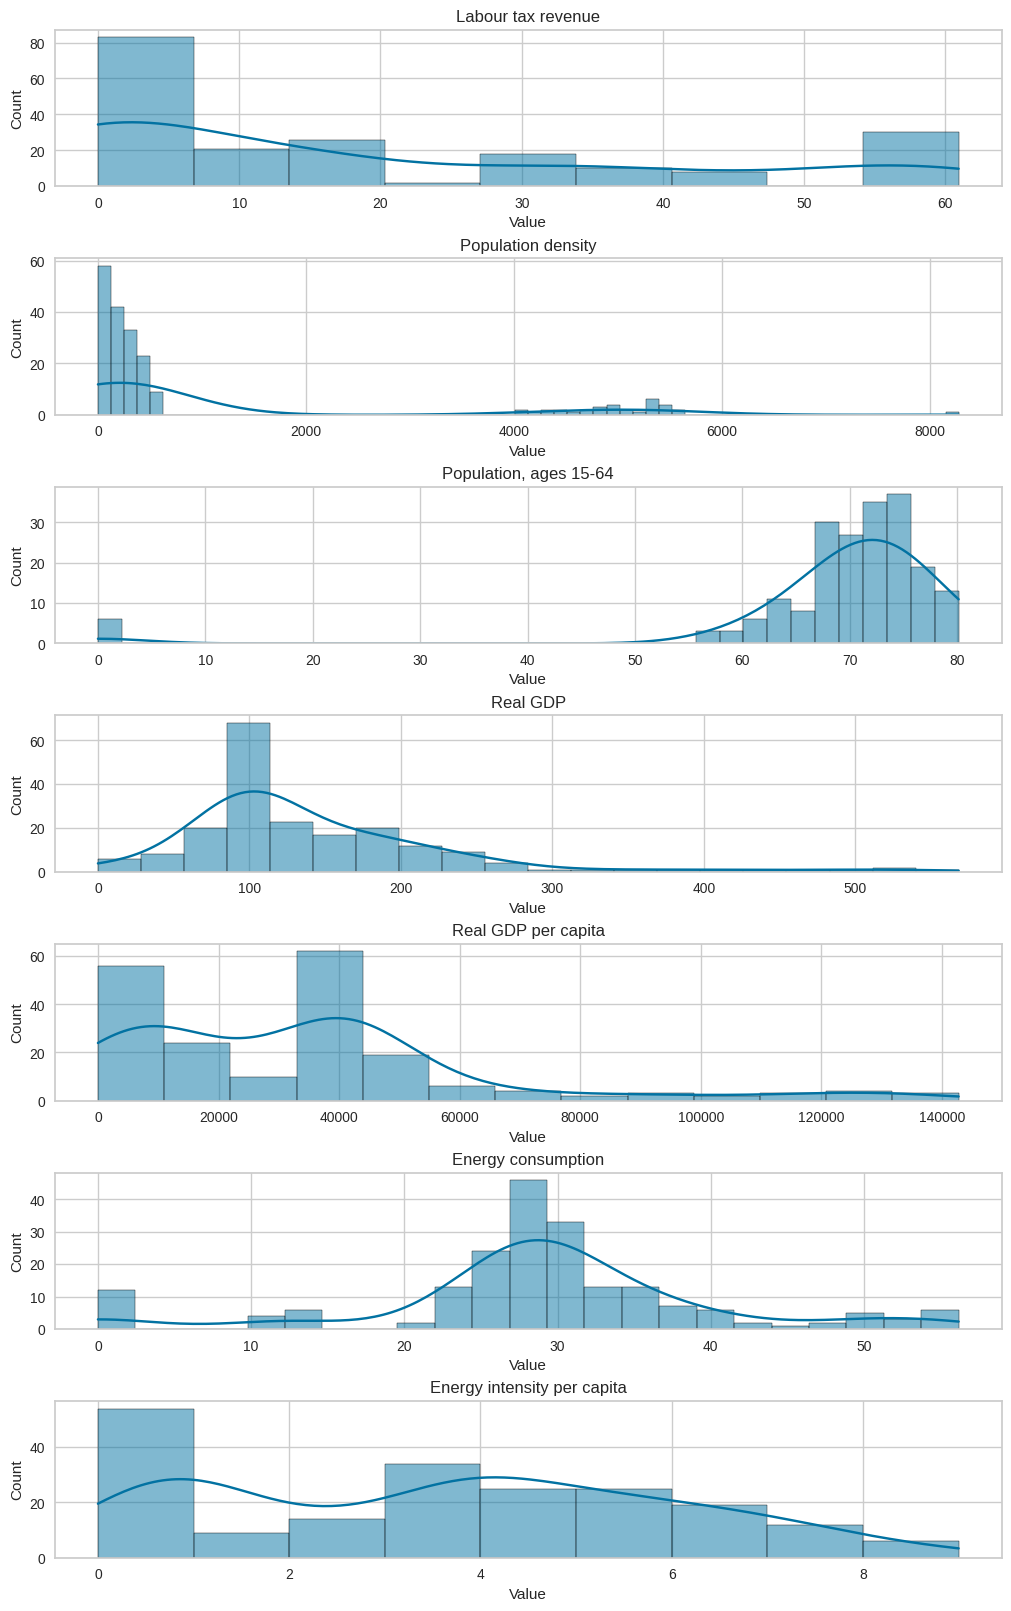

In [ ]:
# Kolom target yang ingin dianalisis (contoh diambil dari data numerik yang relevan)
target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
]

# Membuat visualisasi histogram untuk setiap kolom
fig, ax = plt.subplots(
    len(target_col), 1,  # Membagi image menjadi 5 rows and 1 column
    figsize=(10, 16),    # Ukuran gambar
    constrained_layout=True
)

for i, col in enumerate(target_col):
    sns.histplot(DatasetFinal[col], kde=True, ax=ax[i])  # Membuat grafik distribusi
    ax[i].set_title(col)       # Menambahkan judul
    ax[i].set_xlabel('Value')  # Menambahkan label di sumbu x-axis
    ax[i].set_ylabel('Count')  # Menambahkan label di sumbu y-axis

plt.show()


**Code Explanation:**
- target_col berisi nama-nama kolom dari dataset yang ingin dianalisis. Kolom-kolom tersebut merupakan data numerik yang relevan yang nantinya akan dianalisis lebih lanjut.
- plt.subplots digunakan untuk membuat figure dan subplots.
- len(target_col), 1 yang akan dibuat satu figure dengan jumlah baris sesuai dengan jumlah kolom pada target_col yakni 7 baris dan 1 kolom
- figsize=(10, 16) berfungsi untuk mengatur ukuran gambar.
- constrained_layout=True berfungsi untuk memastikan layout subplot agar tidak saling tumpang tindih
- enumerate(target_col) digunakan untuk mendapatkan indeks i dan nama kolom col pada daftar target_col.
- sns.histplot  merupakan fungsi dari Seaborn yang digunakan untuk membuat histogram.
- DatasetFinal[col] akan mengambil data dari kolom yang sesuai dari dataset DatasetFinal.
- kde=True akan menambahkan kurva densitas inti (Kernel Density Estimate) ke histogram.
- ax=ax[i] berfungsi untuk menentukan subplot mana yang akan digunakan untuk histogram tersebut.
- ax[i].set_title(col) untuk menambahkan judul
- ax[i].set_xlabel('Value') menambahkan label pada sumbu x
- ax[i].set_ylabel('Count') menambahkan label pada sumbu y untuk setiap subplot sesuai dengan kolom yang sedang dianalisis.
- plt.show berfungsi untuk menampilkan plot yang telah dibuat.

**Insight:**
Berdasarkan hasil plot distribusi normal, didapatkan bahwa:
1. Data Labour tax revenue menunjukkan distribusi yang cenderung positive skewness.
2. Data Population density menunjukkan distribusi yang cenderung positive skewness.
3. Data Population, ages 14-64 menunjukkan distribusi yang cenderung negative skewness.
4. Data Real GDP menunjukkan distribusi yang cenderung positive skewness.
5. Data Real GDP per capita menunjukkan distribusi yang cenderung positive skewness.
6. Data Energy consumption menunjukkan distribusi normal.
7. Data Energy intensity per capita menunjukkan distribusi yang cenderung positive skewness.

### 3.4.1. Distribusi Data

Mendeskripsikan distribusi data.

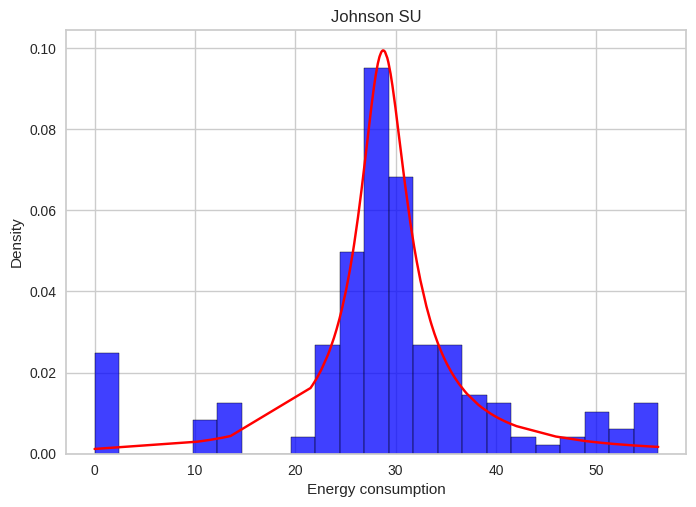

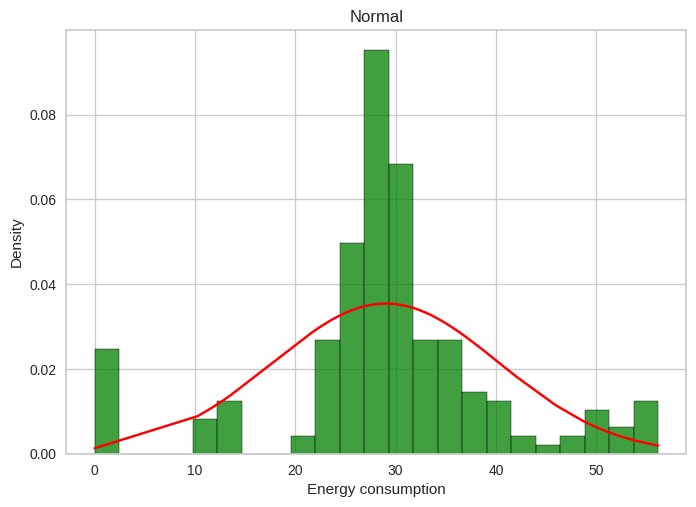

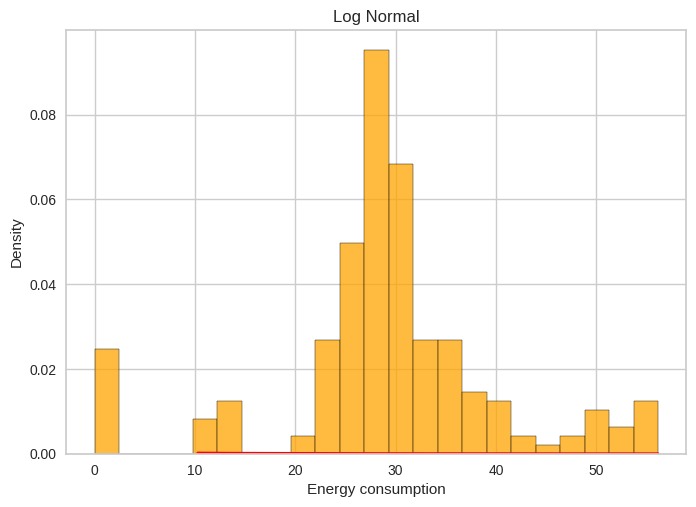

In [ ]:
# Memastikan variabel y diambil dari kolom 'Energy consumption'
y = DatasetFinal['Energy consumption']

# Plot distribusi dengan fitting Johnson SU
plt.figure(1)
plt.title('Johnson SU')
sns.histplot(y, stat='density', color='blue', kde=False)
sns.lineplot(x=sorted(y), y=stats.johnsonsu.pdf(sorted(y), *stats.johnsonsu.fit(y)), color='red')

# Plot distribusi dengan fitting Normal
plt.figure(2)
plt.title('Normal')
sns.histplot(y, stat='density', color='green', kde=False)
sns.lineplot(x=sorted(y), y=stats.norm.pdf(sorted(y), *stats.norm.fit(y)), color='red')

# Plot distribusi dengan fitting Log Normal
plt.figure(3)
plt.title('Log Normal')
sns.histplot(y, stat='density', color='orange', kde=False)
sns.lineplot(x=sorted(y), y=stats.lognorm.pdf(sorted(y), *stats.lognorm.fit(y)), color='red')

# Menampilkan plot
plt.show()

**Code Explanation:**
- Variabel y berisi data dari kolom Energy consumption dari dataset DatasetFinal.
- plt.figure(1) adalah fungsi yang membuat figure atau jendela baru.
- plt.title('Johnson SU') digunakan untuk memberikan judul pada plot.
- sns.histplot(y, stat='density', color='blue', kde=False) berfungsi untuk memplot histogram dari data y.
- stat='density' memastikan bahwa histogram mewakili perkiraan kepadatan probabilitas (bukan jumlah frekuensi).
- color='blue' memberi warna biru untuk histogram.
- sns.lineplot(x=sorted(y), y=stats.johnsonsu.pdf(sorted(y), *stats.johnsonsu.fit(y)), color='red') berfungsi untuk memplot kurva distribusi teoretis Johnson SU yang akan difit ke data y.
- stats.johnsonsu.pdf(...) menghitung fungsi kepadatan probabilitas (PDF) dari distribusi Johnson SU untuk menghasilkan kurva yang sesuai dengan data.
- color='red' memberi warna merah untuk kurva fitting Johnson SU.
- sorted(y) berfungsi untuk mengurutkan data y sehingga sumbu x teratur.
- stats.johnsonsu.fit(y) menghasilkan parameter distribusi Johnson SU yang paling cocok untuk data y.
- sns.lineplot(x=sorted(y), y=stats.norm.pdf(sorted(y), *stats.norm.fit(y)), color='red') berfungsi untuk memplot kurva distribusi normal (Gaussian) yang difit ke data.
- stats.norm.pdf(...) menghitung PDF untuk distribusi normal yang sesuai.
- stats.norm.fit(y) berfungsi untuk menghitung parameter distribusi normal (mean dan standar deviasi) untuk data y.
- sns.lineplot(x=sorted(y), y=stats.lognorm.pdf(sorted(y), *stats.lognorm.fit(y)), color='red') memplot kurva distribusi log-normal yang difit ke data.
- stats.lognorm.pdf(...) menghitung PDF untuk distribusi log-normal.
- stats.lognorm.fit(y) menghitung parameter distribusi log-normal untuk data y.

**Insight:**
Distribusi Johnson SU lebih sesuai digunakan sebab data Energy consumption memiliki karakteristik distribusi yang kompleks dan asimetris, sehingga mungkin memerlukan metode pemodelan yang lebih fleksibel.

## 3.5. Univariate Analysis

In [ ]:
# Memfilter data untuk Indonesia
DatasetIndo = DatasetFinal[DatasetFinal['Reference area'] == 'Indonesia']
DatasetSG = DatasetFinal[DatasetFinal['Reference area'] == 'Singapore']
DatasetJPN = DatasetFinal[DatasetFinal['Reference area'] == 'Japan']
DatasetKor = DatasetFinal[DatasetFinal['Reference area'] == 'Korea']
DatasetArab = DatasetFinal[DatasetFinal['Reference area'] == 'Saudi Arabia']
DatasetChina = DatasetFinal[DatasetFinal['Reference area'] == 'China (People’s Republic of)']

# Mengubah kolom 'TIME_PERIOD' menjadi tipe integer
DatasetIndo['TIME_PERIOD'] = DatasetIndo['TIME_PERIOD'].astype(int)
DatasetSG['TIME_PERIOD'] = DatasetSG['TIME_PERIOD'].astype(int)
DatasetJPN['TIME_PERIOD'] = DatasetJPN['TIME_PERIOD'].astype(int)
DatasetKor['TIME_PERIOD'] = DatasetKor['TIME_PERIOD'].astype(int)
DatasetArab['TIME_PERIOD'] = DatasetArab['TIME_PERIOD'].astype(int)
DatasetChina['TIME_PERIOD'] = DatasetChina['TIME_PERIOD'].astype(int)

DatasetIndo.set_index('TIME_PERIOD',inplace=True)
DatasetSG.set_index('TIME_PERIOD',inplace=True)
DatasetJPN.set_index('TIME_PERIOD',inplace=True)
DatasetKor.set_index('TIME_PERIOD',inplace=True)
DatasetArab.set_index('TIME_PERIOD',inplace=True)
DatasetChina.set_index('TIME_PERIOD',inplace=True)

**Code & Explanation:**






*  Memfilter data pernegara




> DatasetIndo = DatasetFinal[DatasetFinal['Reference area'] == 'Indonesia']


Mengelompokkan data pada DatasetFinal berdasarkan label pada Reference area, pada kode ini label yang diminta adalah Indonesia, ini artinya data dikelompokkan berdasarkan negara Indonesia. Hal yang sama dilakukan pada negara Singapore, Korea, Japan, Saudi Arabia, dan China.








*  Mengubah kolom 'TIME_PERIOD' menjadi tipe integer








> DatasetIndo['TIME_PERIOD'] = DatasetIndo['TIME_PERIOD'].astype(int)


Mengubah tipe data dalam kolom TIME_PERIOD pada DatasetIndo menjadi sebuah integer (bilangan bulat)


> DatasetIndo.set_index('TIME_PERIOD',inplace=True)


Mengatur kolom TIME_PERIOD dari DatasetIndo menjadi sebuah indeks








**Insight:**


Data sudah berhasil dikelompokkan berdasarkan negara untuk memudahkan analisis pernegara yang akan dilakukan selanjutnya. Pengubahan kolom TIME_PERIOD menjadi indeks akan memudahkan dalam melakukan analisis satu variabel yang bergantung kepada tahun atau TIME_PERIOD.


### 3.5.1. Mengetahui Perkembangan Kepadatan Penduduk di Setiap Negara Berdasarkan Tahun


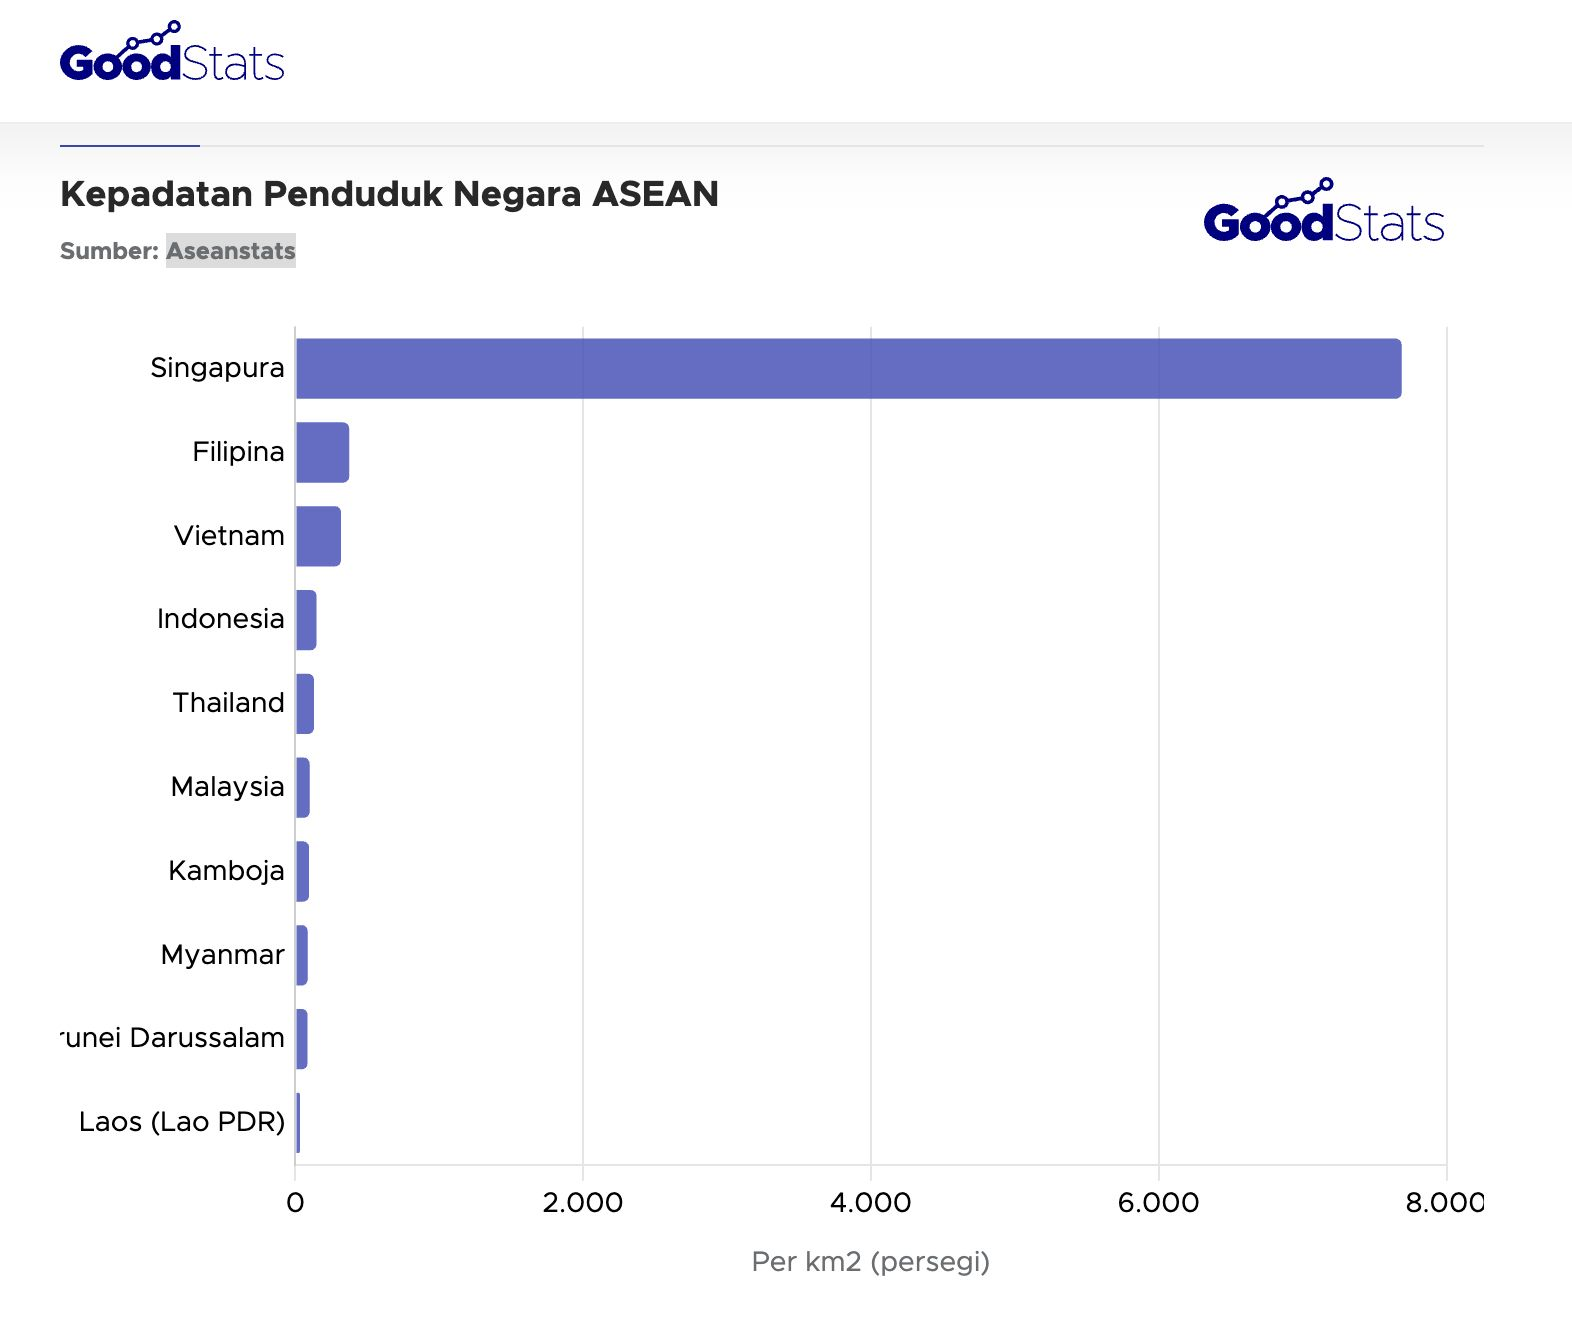Berdasarkan data kepadatan penduduk ASEAN yang dialansir oleh Aseanstats pada website [GoodStats](https://data.goodstats.id/statistic/kepadatan-penduduk-negara-negara-asean-indonesia-masuk-5-besar-ukCyd), negara Singapura merupakan negara dengan kepadatan penduduk tertinggi di ASEAN. Sehingga, pada analisis ini, pembentukan grafik kepadatan penduduk Singapura akan dipisah dengan 5 negara lainnya untuk memudahkan pembacaan dan pemahaman dari grafik kepadatan penduduk.

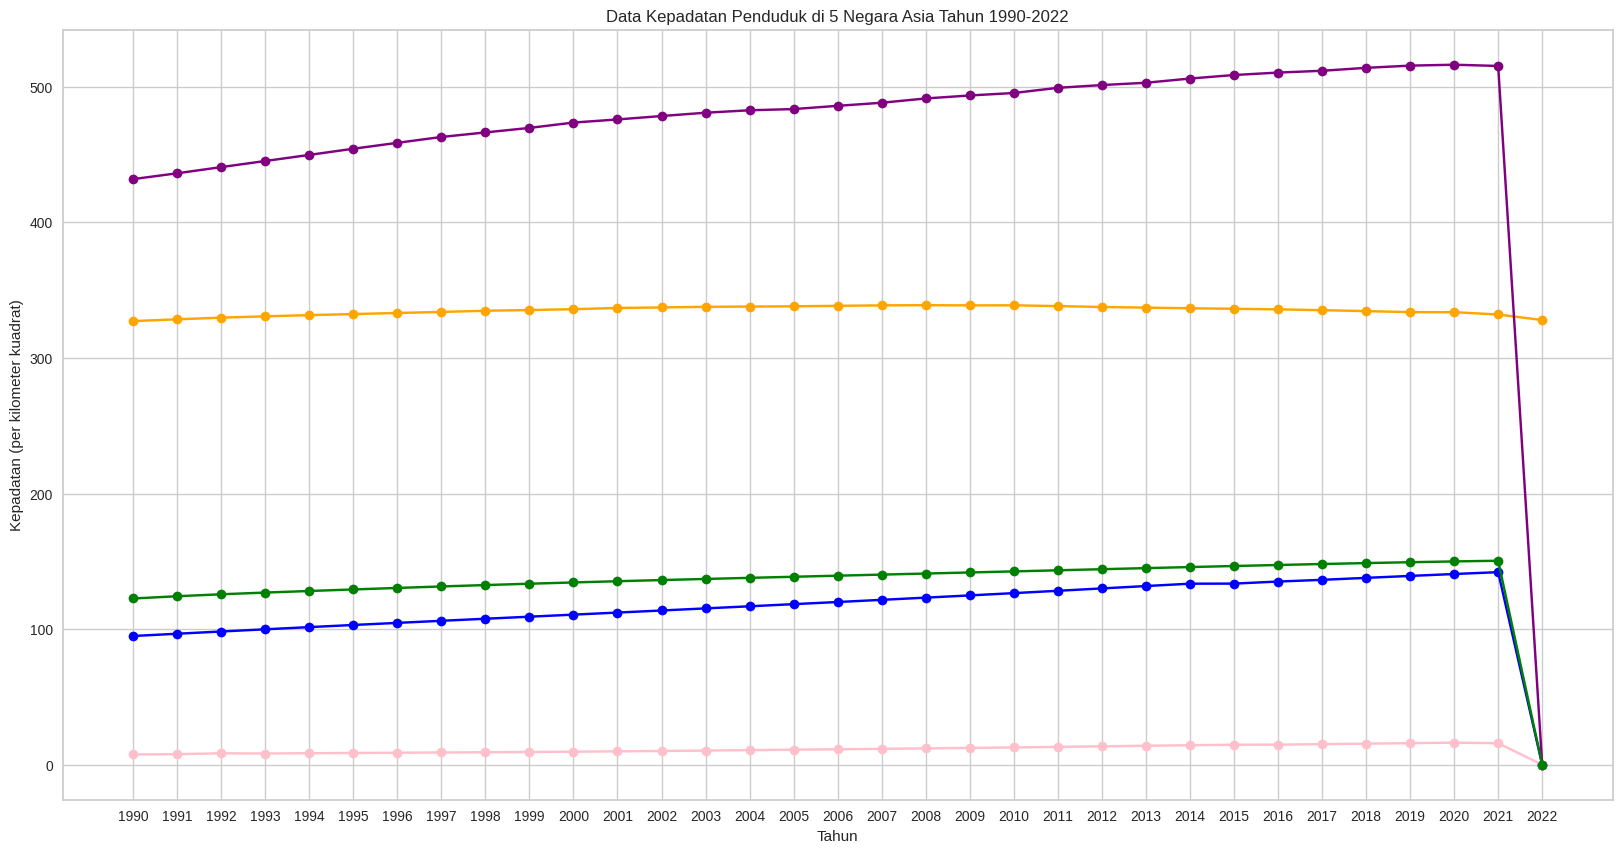

In [ ]:
# Kepadatan Penduduk di 5 Negara Asia

plt.figure(figsize=(20, 10)) # Ukuran Canvas (Panjang x Lebar)


plt.plot(DatasetIndo.index, DatasetIndo['Population density'], label='Indonesia',color='blue',marker='o')
plt.plot(DatasetJPN.index, DatasetJPN['Population density'],label='Jepang',color='orange',marker='o')
plt.plot(DatasetKor.index, DatasetKor['Population density'],label='Korea Selatan',color='purple',marker='o')
plt.plot(DatasetArab.index, DatasetArab['Population density'],label='Saudi Arabia',color='pink',marker='o')
plt.plot(DatasetChina.index, DatasetChina['Population density'],label='China',color='green',marker='o')


plt.title('Data Kepadatan Penduduk di 5 Negara Asia Tahun 1990-2022')  # To add title
plt.xticks(ticks=DatasetIndo.index, labels=DatasetIndo.index)  # To change the x label name
plt.xlabel('Tahun')  # To add xlabel
plt.ylabel('Kepadatan (per kilometer kuadrat)')   # To add ylabel
plt.show()

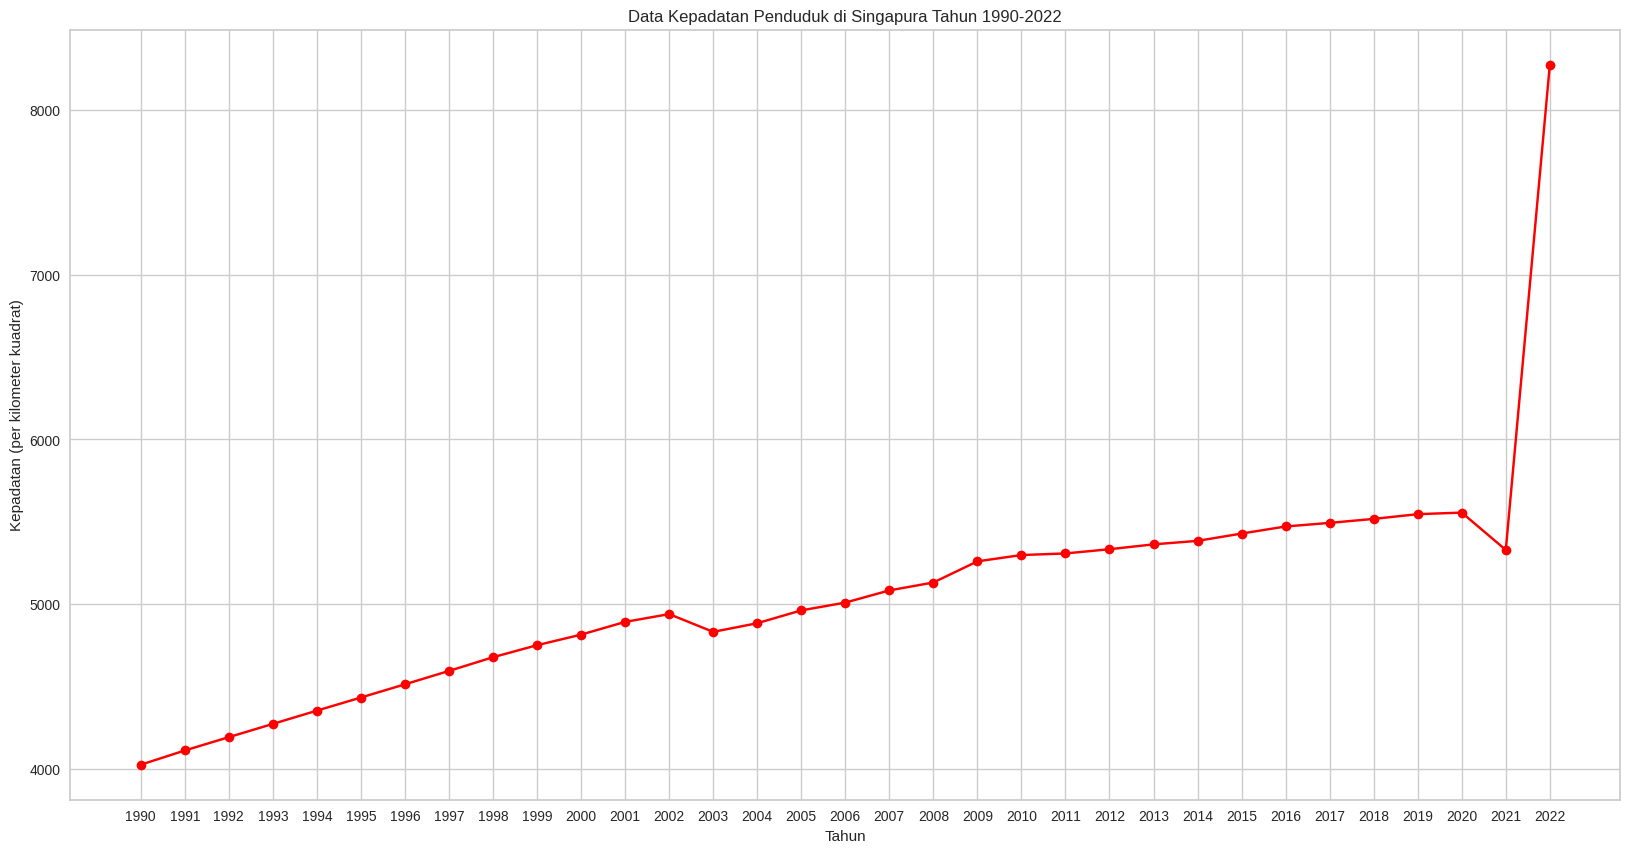

In [ ]:
# Kepadatan Penduduk di Negara Singapura

plt.figure(figsize=(20, 10)) # Ukuran Canvas (Panjang x Lebar)


plt.plot(DatasetSG.index, DatasetSG['Population density'], label='Singapura',color='red',marker='o')

plt.title('Data Kepadatan Penduduk di Singapura Tahun 1990-2022')  # To add title
plt.xticks(ticks=DatasetIndo.index, labels=DatasetIndo.index)  # To change the x label name
plt.xlabel('Tahun')  # To add xlabel
plt.ylabel('Kepadatan (per kilometer kuadrat)')   # To add ylabel
plt.show()

**Code&Explanation:**






*  plt.figure(figsize=(20, 10)) -> Mengatur ukuran kanvas dengan ukuran 20 x 10 inchi
*  plt.plot(DatasetSG.index, DatasetSG['Population density'], label='Singapura',color='red',marker='o') -> Membentuk plot kepadatan penduduk dari kolom Population density yang diambil dari DatasetSG yang merupakan kepadatan penduduk negara Singapura dengan warna merah dan marker o
*  plt.title('Data Kepadatan Penduduk di Singapura Tahun 1990-2022') -> Menuliskan judul grafik 'Data Kepadatan Penduduk di Singapura Tahun 1990-2022'
*  plt.xticks(ticks=DatasetSG.index, labels=DatasetSG.index)  -> Menyesuaikan tanda-tanda sumbu x pada grafik
*  plt.xlabel('Tahun') -> Memberi nama sumbu x sebagai 'Tahun'
*  plt.ylabel('Kepadatan (per kilometer kuadrat)')  -> Memberi nama sumbu y sebagai 'Kepadatan (per kilometer kuadrat)'
*  plt.show() -> Kode untuk menampilkan grafik


**Insight:**


Dilihat dari grafik yang terbentuk, Indonesia menempati posisi negara ke-5 dengan kepadatan penduduk tertinggi.
Ini artinya, kondisi geografis di Indonesia masih bisa dikatakan baik untuk memiliki ruang per kilometer persegi apabila dibandingkan 4 Negara Asia lainnya.
















### 3.5.2. Mengetahui Perkembangan Pendapatan Pajak Tenaga Kerja  di Setiap Negara Berdasarkan Tahun


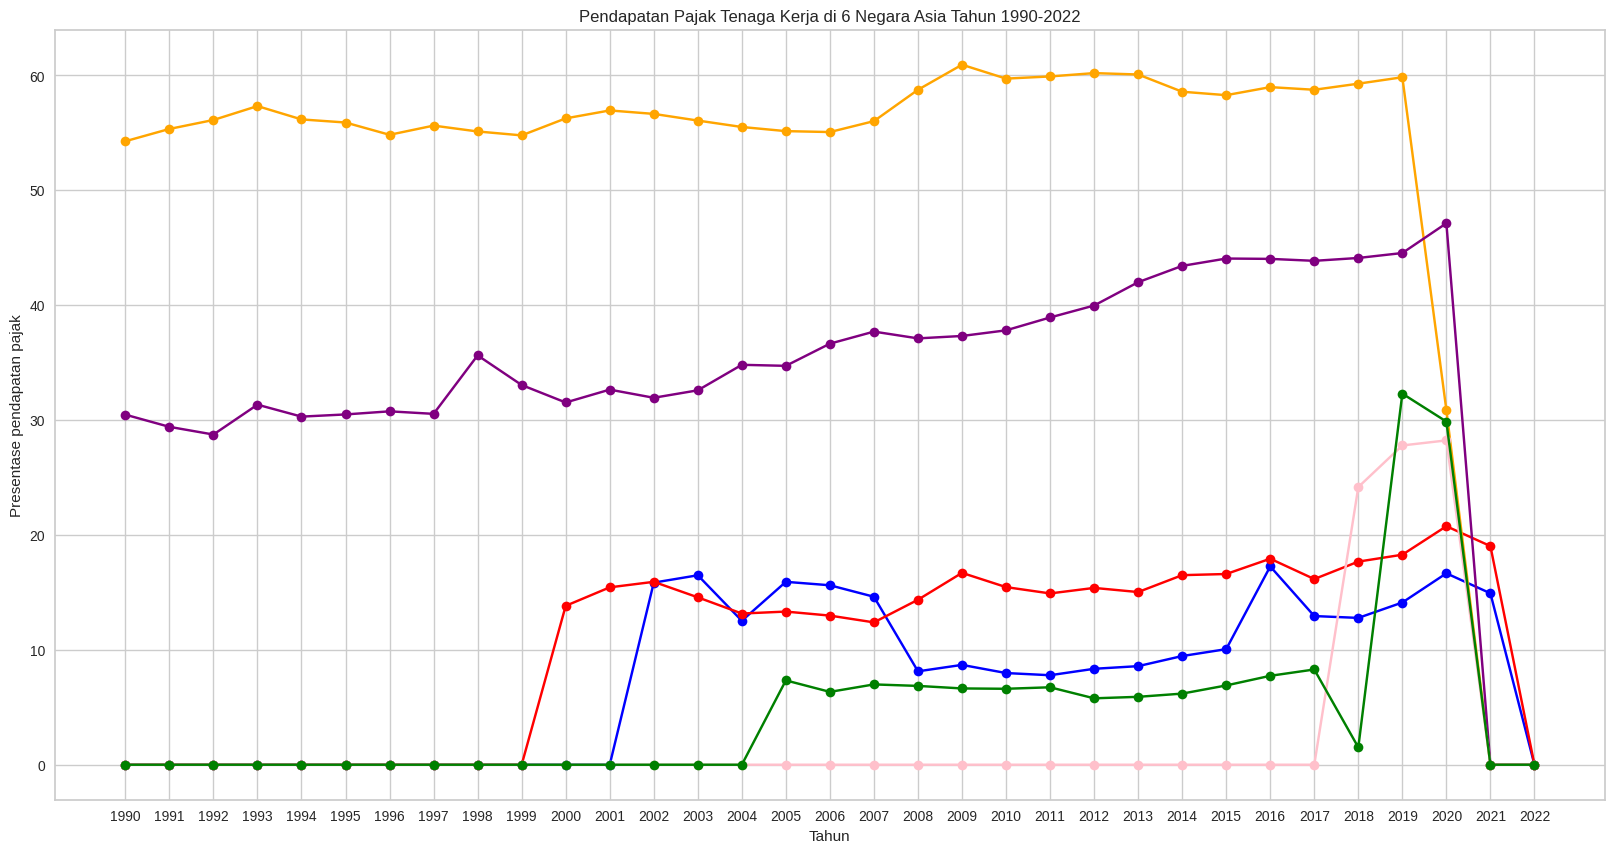

In [ ]:
# Kepadatan Penduduk di 5 Negara Asia

plt.figure(figsize=(20, 10)) # Ukuran Canvas (Panjang x Lebar)


plt.plot(DatasetIndo.index, DatasetIndo['Labour tax revenue'], label='Indonesia',color='blue',marker='o')
plt.plot(DatasetSG.index, DatasetSG['Labour tax revenue'], label='Singapura',color='red',marker='o')
plt.plot(DatasetJPN.index, DatasetJPN['Labour tax revenue'],label='Jepang',color='orange',marker='o')
plt.plot(DatasetKor.index, DatasetKor['Labour tax revenue'],label='Korea Selatan',color='purple',marker='o')
plt.plot(DatasetArab.index, DatasetArab['Labour tax revenue'],label='Saudi Arabia',color='pink',marker='o')
plt.plot(DatasetChina.index, DatasetChina['Labour tax revenue'],label='China',color='green',marker='o')


plt.title('Pendapatan Pajak Tenaga Kerja di 6 Negara Asia Tahun 1990-2022')  # To add title
plt.xticks(ticks=DatasetIndo.index, labels=DatasetIndo.index)  # To change the x label name
plt.xlabel('Tahun')  # To add xlabel
plt.ylabel('Presentase pendapatan pajak')   # To add ylabel
plt.show()

**Code&Explanation:**

*  plt.figure(figsize=(20, 10)) -> Mengatur ukuran kanvas dengan ukuran 20 x 10 inchi
*  plt.plot(DatasetSG.index, DatasetSG['Labour tax revenue'], label='Singapura',color='red',marker='o') -> Membentuk plot kepadatan penduduk dari kolom Labour tax revenue yang diambil dari DatasetSG yang merupakan pajak pendapatan tenaga kerja di negara Singapura dengan warna merah dan marker o
*  plt.title('Pendapatan Pajak Tenaga Kerja di 6 Negara Asia Tahun 1990-2022') -> Menuliskan judul grafik 'Data Kepadatan Penduduk di Singapura Tahun 1990-2022'
*  plt.xticks(ticks=DatasetSG.index, labels=DatasetSG.index)  -> Menyesuaikan tanda-tanda sumbu x pada grafik
*  plt.xlabel('Tahun') -> Memberi nama sumbu x sebagai 'Tahun'
*  plt.ylabel('Presentase pendapatan pajak')  -> Memberi nama sumbu y sebagai 'Presentase pendapatan pajak'
*  plt.show() -> Kode untuk menampilkan grafik


**Insight:**


Dilihat dari grafik yang terbentuk, Indonesia memiliki kondisi pendapatan pajak tenaga kerja yang berfluktuatif. Pada tahun 2020, negara Indonesia menempati posisi pendapatan pajak tenaga kerja terendah apabila dibandingkan dengan 5 Negara Asia lainnya.

## 3.6. Bivariate Analysis

Hubungan antara Pendapatan Pajak Tenaga Kerja dengan Kepadatan Penduduk di Indonesia

Setelah mengetahui masing-masing perkembangan dari pendapatan tenaga kerja dan kepadatan penduduk di Indonesia berdasarkan tahun, selanjutnya akan dianalisis hubungan antara pendapatan pajak tenaga kerja dan kepadatan penduduk di negara Indonesia.

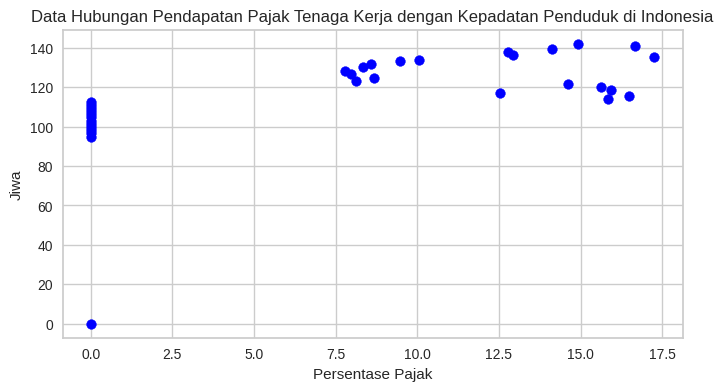

In [ ]:
# Scatter Plot
plt.figure(figsize=(8, 4))
plt.scatter(DatasetIndo['Labour tax revenue'], DatasetIndo['Population density'], color='blue')
plt.title('Data Hubungan Pendapatan Pajak Tenaga Kerja dengan Kepadatan Penduduk di Indonesia')
plt.xlabel('Persentase Pajak')
plt.ylabel('Jiwa')
plt.grid(True)
plt.show()

**Code & Explanation:**


*   plt.figure(figsize=(8, 4))-> Mengatur ukuran kanvas sebesar 8x4 inchi
*   plt.scatter(DatasetIndo['Labour tax revenue'], DatasetIndo['Population density'], color='blue') -> Membentuk scatter plot dari DatasetIndo yang terdiri dari kolom Labour tax revenue dan Population density, plot dibentuk menggunakan warna biru
*   plt.title('Data Hubungan Pendapatan Pajak Tenaga Kerja dengan Kepadatan Penduduk di Indonesia') -> Menulis judul grafik 'Data Hubungan Pendapatan Pajak Tenaga Kerja dengan Kepadatan Penduduk di Indonesia'
*   plt.xlabel('Persentase Pajak') -> Menuliskan judul sumbu x sebagai 'Persentase Pajak'
*   plt.ylabel('Jiwa') -> Menuliskan judul sumbu y sebagai 'Jiwa'
*   plt.grid(True) -> Menampilkan grid pada grafik

**Insight:**

Dari grafik yang disajikan, Persentase pajak tenaga kerja tampaknya tidak memiliki korelasi langsung yang signifikan terhadap perubahan kepadatan penduduk.
Sebagian besar titik terkonsentrasi pada kisaran kepadatan penduduk yang sama, meskipun persentase pajak berbeda-beda.
Sehingga untuk melakukan analisis lebih lanjut, akan dibentuk Bivariate Heatmap Correlation untuk melihat hubungan antara dua variabel.






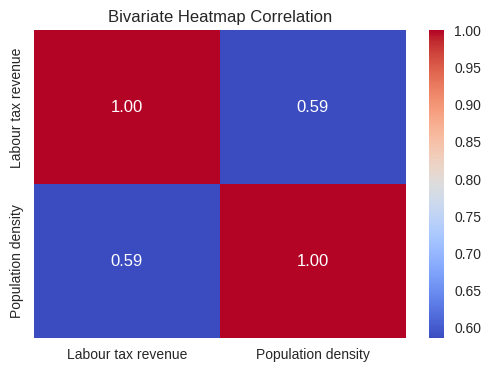

In [ ]:
# Re-calculate the correlation
correlation_taxpopulation = DatasetIndo[['Labour tax revenue', 'Population density']].corr()

# Plotting the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_taxpopulation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Bivariate Heatmap Correlation')
plt.show()

**Code & Explanation:**


*   correlation_taxpopulation = DatasetIndo[['Labour tax revenue', 'Population density']].corr() -> Menghitung korelasi antara Labour tax revenue dan Population density yang diperoleh dari DatasetIndo
*   plt.figure(figsize=(6, 4)) -> Mengatur ukuran kanvas 6x4 inchi
*   sns.heatmap(correlation_taxpopulation, annot=True, cmap='coolwarm', fmt='.2f') -> Membentuk heatmap dari data correlation_taxpopulation yang sudah didefinisikan sebelumnya, menambahkan anotasi angka pada sel heatmap, skema warna yang digunakan adalah coolwarm, dan format angka yang digunakan adalah 2 digit di belakang koma.
*   plt.title('Bivariate Heatmap Correlation') -> Menuliskan judul heatmap sebagai Bivariate Heatmap Correlation

**Insight:**

Hubungan antara pajak pendapatan tenaga kerja dan kepadatan penduduk di Indonesia memiliki nilai korelasi sebesar 0.59, artinya kedua variabel memiliki hubungan cukup kuat berbanding lurus.





## 3.7. Multivariate Analysis

Setelah diketahui bahwa variabel pajak pendapatan tenaga kerja dan kepadatan penduduk di Indonesia memiliki korelasi sebesar 0.59, berikutnya akan diperiksa hubungan pajak pendapatan tenaga kerja dengan variabel lainnya, dan akan diperiksa juga pada ke-5 Negara di Asia lainnya sebagai perbandingan.

### 3.7.1. Indonesia

Text(0.5, 1.0, 'Indonesia Labour Tax Revenue Heatmap Correlation')

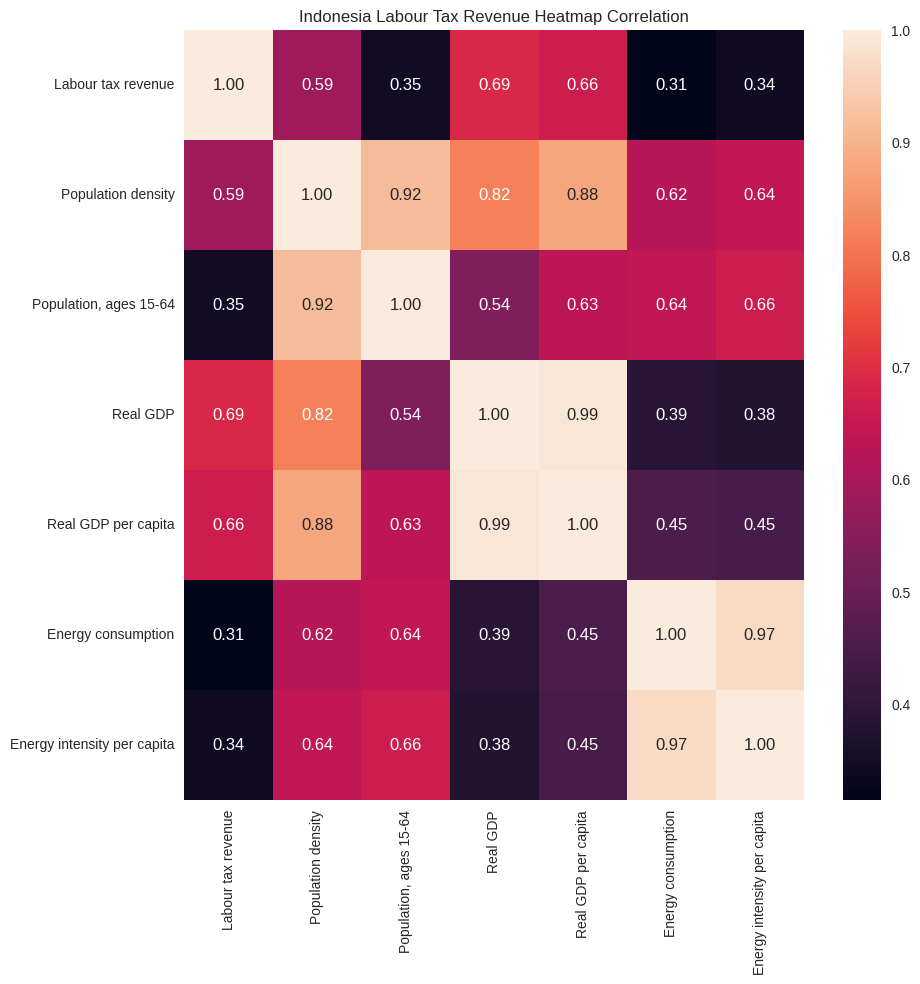

In [ ]:
target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

corr = DatasetIndo[target_col].corr()  # To calculate correlation matrix
sns.heatmap(corr, annot=True, fmt=".2f", ax=ax) # To create the correlation matrix image
ax.set_title(f'Indonesia Labour Tax Revenue Heatmap Correlation')  # To add title

**Code & Explanation:**




*   target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
] -> Mendefinisikan kolom-kolom yang akan digunakan pada target_col
*   fig, ax = plt.subplots(1, 1, figsize=(10, 10)) -> Mengatur ukuran kanvas 10x10 inchi
*   corr = DatasetIndo[target_col].corr() -> Menghitung korelasi antara kolom-kolom yang ada di target_col yang diperoleh dari DatasetIndo
*   sns.heatmap(correlation_taxpopulation, annot=True, cmap='coolwarm', fmt='.2f') -> Membentuk heatmap dari data correlation_taxpopulation yang sudah didefinisikan sebelumnya, menambahkan anotasi angka pada sel heatmap, skema warna yang digunakan adalah coolwarm, dan format angka yang digunakan adalah 2 digit di belakang koma.
*   ax.set_title(f'Indonesia Labour Tax Revenue Heatmap Correlation') -> Menuliskan judul heatmap sebagai 'Indonesia Labour Tax Revenue Heatmap Correlation'

**Insight:**

Dari heatmap yang terbentuk, dapat dilihat bahwa pada negara Indonesia, variabel yang paling mempengaruhi variabel labour tax revenue adalah Real GDP dengan nilai korelasi sebesar 0.69.

### 3.7.2. Singapura

Text(0.5, 1.0, 'Singapore Labour Tax Revenue Heatmap Correlation')

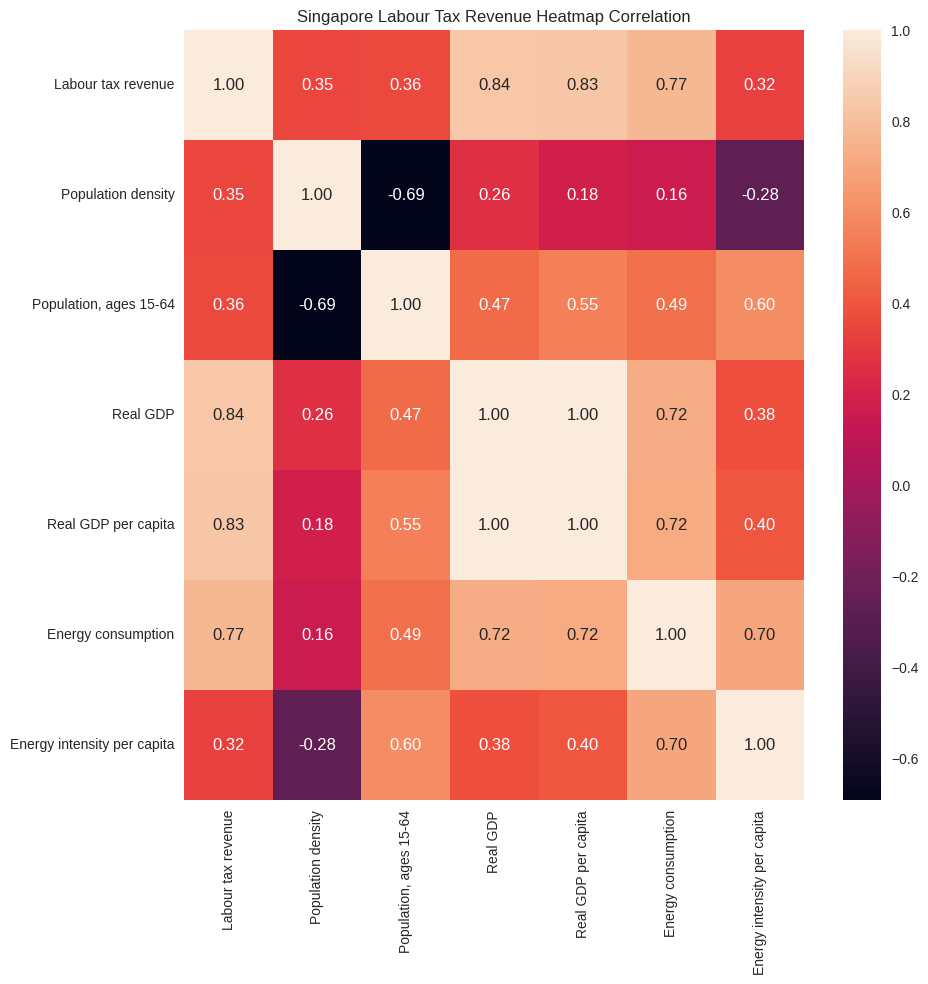

In [ ]:
target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

corr = DatasetSG[target_col].corr()  # To calculate correlation matrix
sns.heatmap(corr, annot=True, fmt=".2f", ax=ax) # To create the correlation matrix image
ax.set_title(f'Singapore Labour Tax Revenue Heatmap Correlation')  # To add title

**Code & Explanation:**




*   target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
] -> Mendefinisikan kolom-kolom yang akan digunakan pada target_col
*   fig, ax = plt.subplots(1, 1, figsize=(10, 10)) -> Mengatur ukuran kanvas 10x10 inchi
*   corr = DatasetSG[target_col].corr() -> Menghitung korelasi antara kolom-kolom yang ada di target_col yang diperoleh dari DatasetSG
*   sns.heatmap(correlation_taxpopulation, annot=True, cmap='coolwarm', fmt='.2f') -> Membentuk heatmap dari data correlation_taxpopulation yang sudah didefinisikan sebelumnya, menambahkan anotasi angka pada sel heatmap, skema warna yang digunakan adalah coolwarm, dan format angka yang digunakan adalah 2 digit di belakang koma.
*   ax.set_title(f'Singapore Labour Tax Revenue Heatmap Correlation') -> Menuliskan judul heatmap sebagai 'Singapore Labour Tax Revenue Heatmap Correlation'

**Insight:**

Dari heatmap yang terbentuk, dapat dilihat bahwa pada negara Singapore, variabel yang paling mempengaruhi variabel labour tax revenue adalah Real GDP dengan nilai korelasi sebesar 0.84.

### 3.7.3. Jepang

Text(0.5, 1.0, 'Japan Labour Tax Revenue Heatmap Correlation')

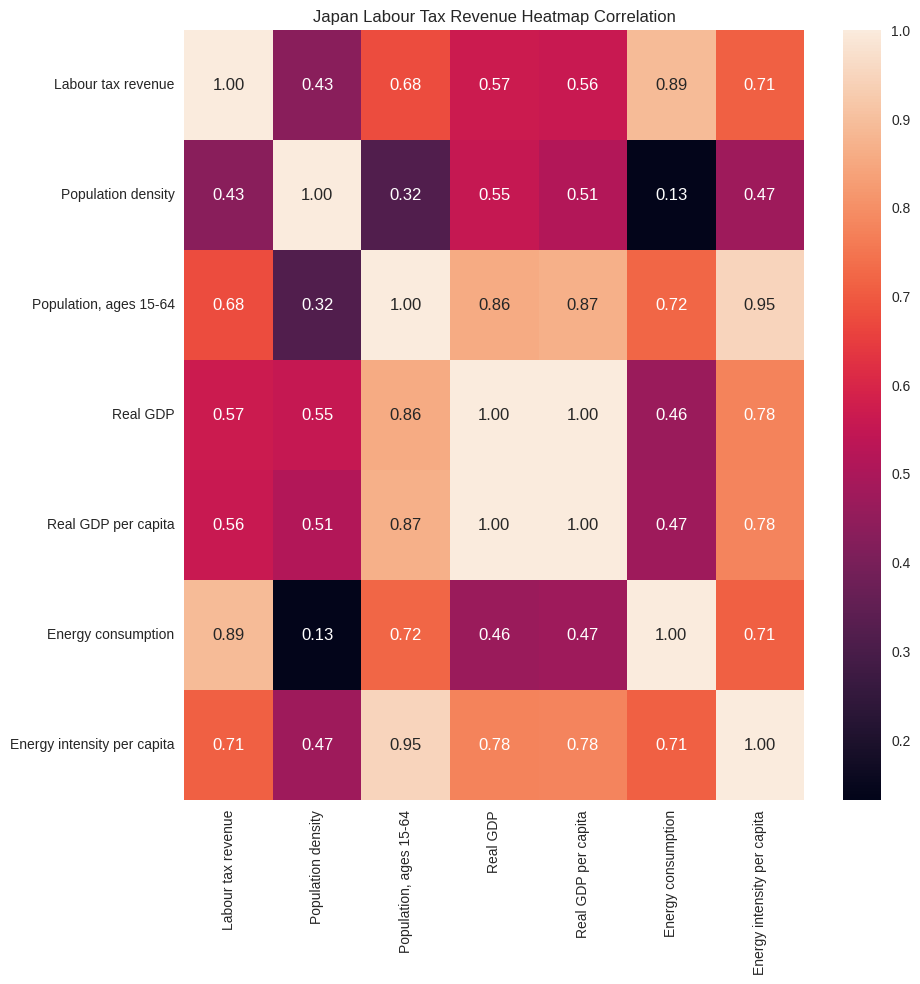

In [ ]:
target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

corr = DatasetJPN[target_col].corr()  # To calculate correlation matrix
sns.heatmap(corr, annot=True, fmt=".2f", ax=ax) # To create the correlation matrix image
ax.set_title(f'Japan Labour Tax Revenue Heatmap Correlation')  # To add title

**Code & Explanation:**




*   target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
] -> Mendefinisikan kolom-kolom yang akan digunakan pada target_col
*   fig, ax = plt.subplots(1, 1, figsize=(10, 10)) -> Mengatur ukuran kanvas 10x10 inchi
*   corr = DatasetJPN[target_col].corr() -> Menghitung korelasi antara kolom-kolom yang ada di target_col yang diperoleh dari DatasetJPN
*   sns.heatmap(correlation_taxpopulation, annot=True, cmap='coolwarm', fmt='.2f') -> Membentuk heatmap dari data correlation_taxpopulation yang sudah didefinisikan sebelumnya, menambahkan anotasi angka pada sel heatmap, skema warna yang digunakan adalah coolwarm, dan format angka yang digunakan adalah 2 digit di belakang koma.
*   ax.set_title(f'Japan Labour Tax Revenue Heatmap Correlation') -> Menuliskan judul heatmap sebagai 'Japan Labour Tax Revenue Heatmap Correlation'

**Insight:**

Dari heatmap yang terbentuk, dapat dilihat bahwa pada negara Jepang, variabel yang paling mempengaruhi variabel labour tax revenue adalah Populations, age 15-64 dengan nilai korelasi sebesar 0.68.

### 3.7.4. Korea

Text(0.5, 1.0, 'Korea Labour Tax Revenue Heatmap Correlation')

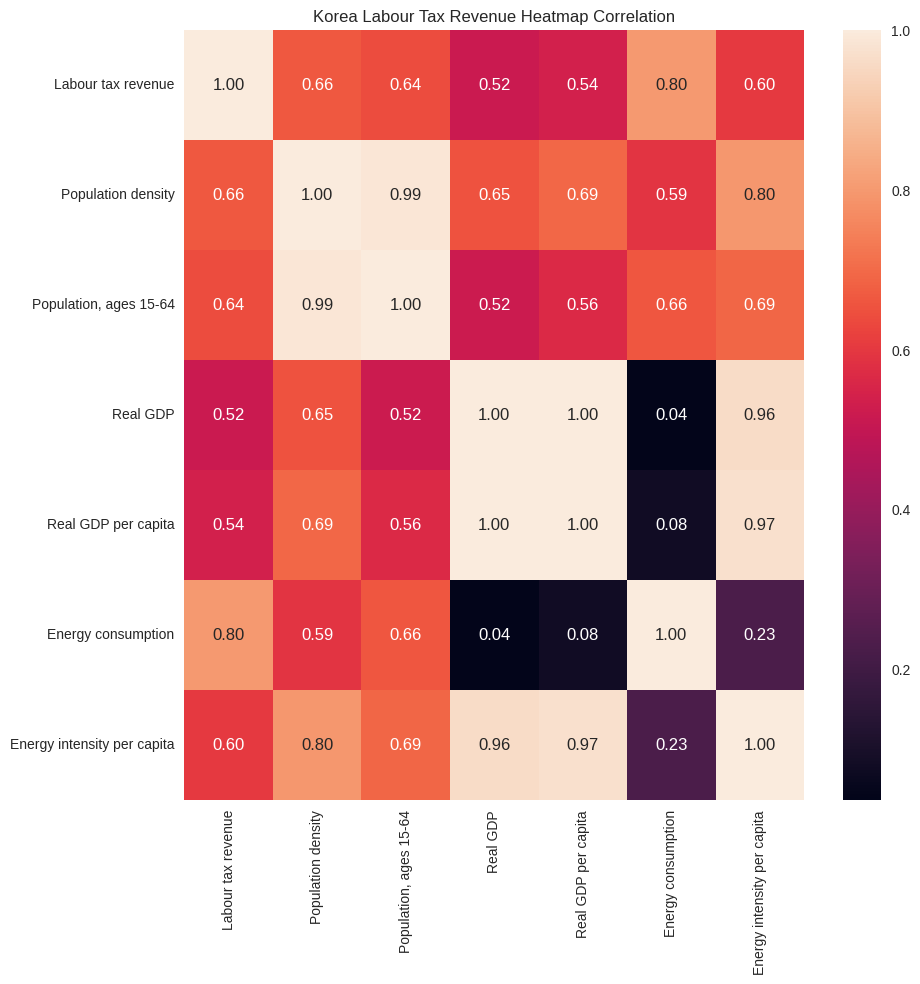

In [ ]:
target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

corr = DatasetKor[target_col].corr()  # To calculate correlation matrix
sns.heatmap(corr, annot=True, fmt=".2f", ax=ax) # To create the correlation matrix image
ax.set_title(f'Korea Labour Tax Revenue Heatmap Correlation')  # To add title

**Code & Explanation:**




*   target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
] -> Mendefinisikan kolom-kolom yang akan digunakan pada target_col
*   fig, ax = plt.subplots(1, 1, figsize=(10, 10)) -> Mengatur ukuran kanvas 10x10 inchi
*   corr = DatasetKor[target_col].corr() -> Menghitung korelasi antara kolom-kolom yang ada di target_col yang diperoleh dari DatasetKor
*   sns.heatmap(correlation_taxpopulation, annot=True, cmap='coolwarm', fmt='.2f') -> Membentuk heatmap dari data correlation_taxpopulation yang sudah didefinisikan sebelumnya, menambahkan anotasi angka pada sel heatmap, skema warna yang digunakan adalah coolwarm, dan format angka yang digunakan adalah 2 digit di belakang koma.
*   ax.set_title(f'Korea Labour Tax Revenue Heatmap Correlation') -> Menuliskan judul heatmap sebagai 'Korea Labour Tax Revenue Heatmap Correlation'

**Insight:**

Dari heatmap yang terbentuk, dapat dilihat bahwa pada negara Korea, variabel yang paling mempengaruhi variabel labour tax revenue adalah Energy consumption dengan nilai korelasi sebesar 0.80.

### 3.7.5. Saudi Arabia

Text(0.5, 1.0, 'Saudi Arabia Labour Tax Revenue Heatmap Correlation')

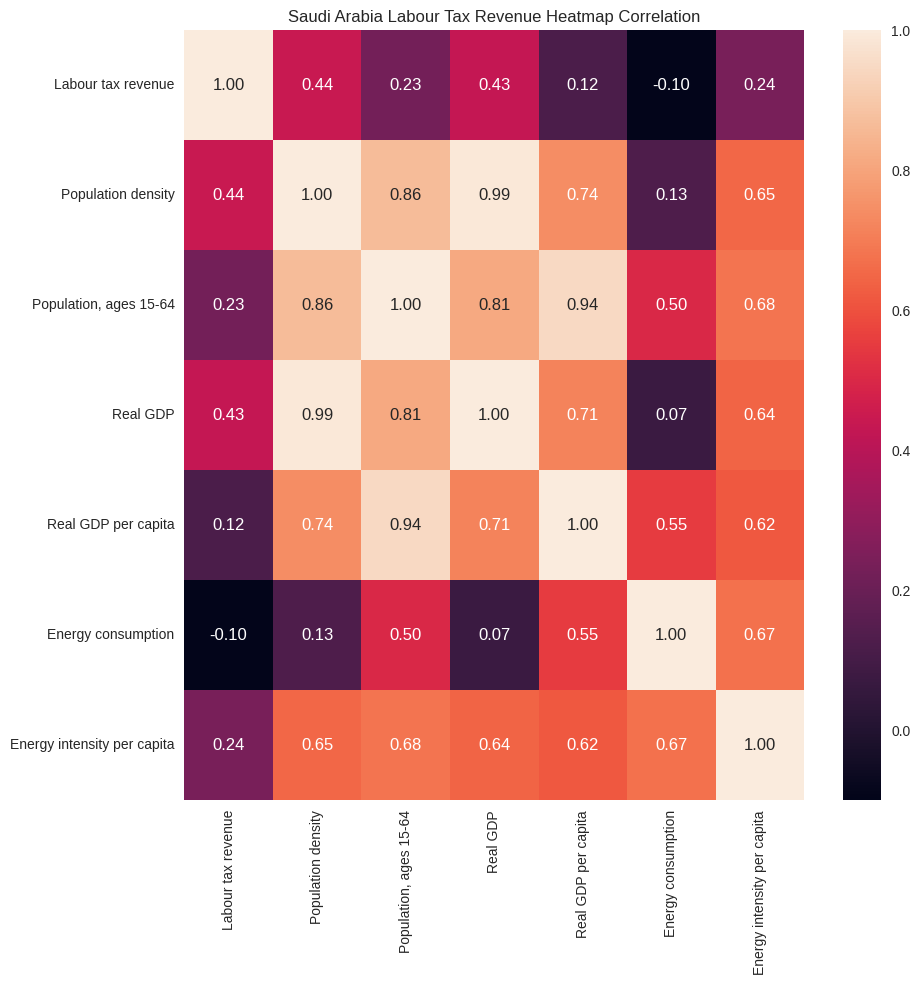

In [ ]:
target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

corr = DatasetArab[target_col].corr()  # To calculate correlation matrix
sns.heatmap(corr, annot=True, fmt=".2f", ax=ax) # To create the correlation matrix image
ax.set_title(f'Saudi Arabia Labour Tax Revenue Heatmap Correlation')  # To add title

**Code & Explanation:**




*   target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
] -> Mendefinisikan kolom-kolom yang akan digunakan pada target_col
*   fig, ax = plt.subplots(1, 1, figsize=(10, 10)) -> Mengatur ukuran kanvas 10x10 inchi
*   corr = DatasetArab[target_col].corr() -> Menghitung korelasi antara kolom-kolom yang ada di target_col yang diperoleh dari DatasetArab
*   sns.heatmap(correlation_taxpopulation, annot=True, cmap='coolwarm', fmt='.2f') -> Membentuk heatmap dari data correlation_taxpopulation yang sudah didefinisikan sebelumnya, menambahkan anotasi angka pada sel heatmap, skema warna yang digunakan adalah coolwarm, dan format angka yang digunakan adalah 2 digit di belakang koma.
*   ax.set_title(f'Saudi Arabia Labour Tax Revenue Heatmap Correlation') -> Menuliskan judul heatmap sebagai 'Saudi Arabia Labour Tax Revenue Heatmap Correlation'

**Insight:**

Dari heatmap yang terbentuk, dapat dilihat bahwa pada negara Saudi Arabia, variabel yang paling mempengaruhi variabel labour tax revenue adalah Population density dengan nilai korelasi sebesar 0.44.

### 3.7.6. China

Text(0.5, 1.0, 'China Labour Tax Revenue Heatmap Correlation')

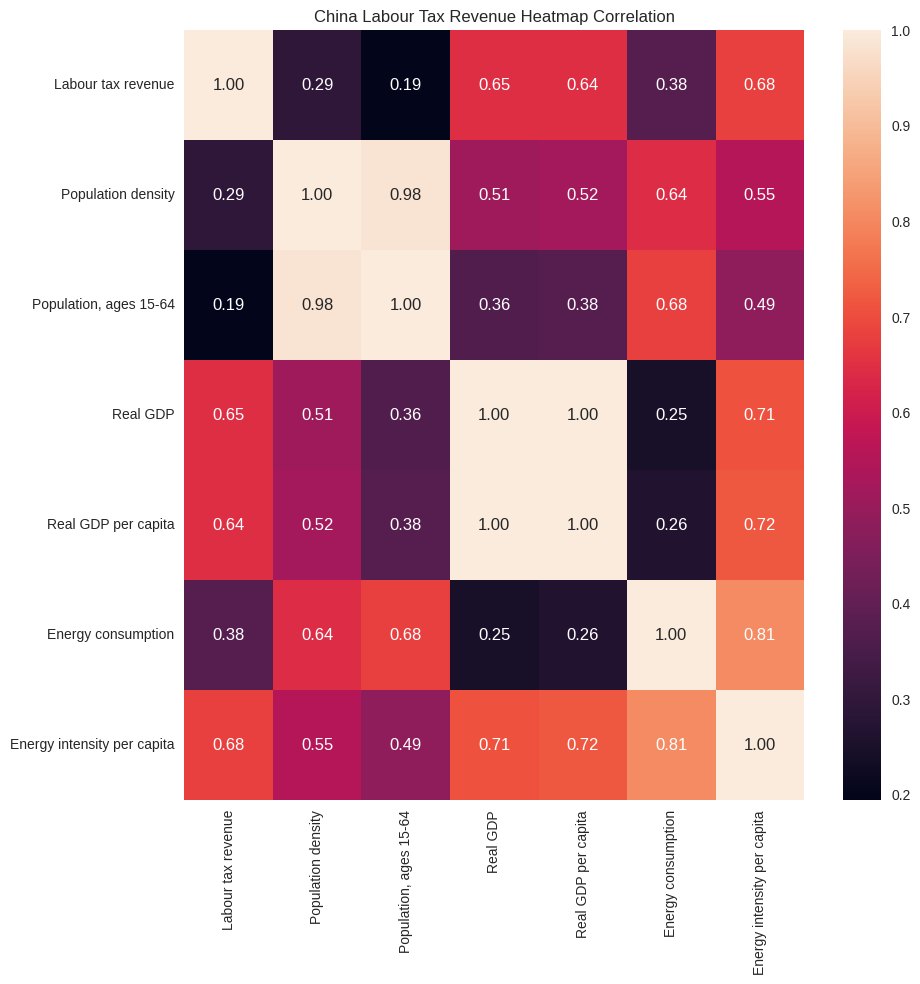

In [ ]:
target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

corr = DatasetChina[target_col].corr()  # To calculate correlation matrix
sns.heatmap(corr, annot=True, fmt=".2f", ax=ax) # To create the correlation matrix image
ax.set_title(f'China Labour Tax Revenue Heatmap Correlation')  # To add title

**Code & Explanation:**




*   target_col = [
    'Labour tax revenue',
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita'
] -> Mendefinisikan kolom-kolom yang akan digunakan pada target_col
*   fig, ax = plt.subplots(1, 1, figsize=(10, 10)) -> Mengatur ukuran kanvas 10x10 inchi
*   corr = DatasetChina[target_col].corr() -> Menghitung korelasi antara kolom-kolom yang ada di target_col yang diperoleh dari DatasetChina
*   sns.heatmap(correlation_taxpopulation, annot=True, cmap='coolwarm', fmt='.2f') -> Membentuk heatmap dari data correlation_taxpopulation yang sudah didefinisikan sebelumnya, menambahkan anotasi angka pada sel heatmap, skema warna yang digunakan adalah coolwarm, dan format angka yang digunakan adalah 2 digit di belakang koma.
*   ax.set_title(f'China Labour Tax Revenue Heatmap Correlation') -> Menuliskan judul heatmap sebagai 'China Labour Tax Revenue Heatmap Correlation'

**Insight:**

Dari heatmap yang terbentuk, dapat dilihat bahwa pada negara China, variabel yang paling mempengaruhi variabel labour tax revenue adalah Energy intensity per capita dengan nilai korelasi sebesar 0.68.

## 3.8. Feature Engineering

### 3.8.1. Feature Emissions Efficiency
Menghitung GHG Productivity relatif terhadap Real GDP per capita. Untuk mengetahui seberapa besar Real GDP per capita suatu negara berkontribusi terhadap emisi per kapita dalam populasi padat.

In [ ]:
# Menghitung GHG Productivity relatif terhadap Real GDP per capita
DatasetFinal.loc[:,'Emissions Efficiency'] = DatasetFinal['Real GDP per capita'] * DatasetFinal['Population density'] / 100
DatasetFinal.loc[:, 'Emissions Efficiency'] = DatasetFinal['Real GDP per capita'].fillna(0)
DatasetFinal

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency
0,Saudi Arabia,1990,0.00,7.55,57.16,77.51,41130.14,27.60,3.57,41130.14
1,Saudi Arabia,1991,0.00,7.80,57.49,89.14,45783.05,26.72,4.03,45783.05
2,Saudi Arabia,1992,0.00,8.40,57.84,92.69,46203.80,27.14,4.45,46203.80
3,Saudi Arabia,1993,0.00,8.26,58.34,91.43,44340.64,25.66,4.50,44340.64
4,Saudi Arabia,1994,0.00,8.47,59.07,91.94,43483.92,28.28,4.61,43483.92
...,...,...,...,...,...,...,...,...,...,...
193,China (People’s Republic of),2018,1.51,148.71,73.21,487.11,15206.37,48.84,2.27,15206.37
194,China (People’s Republic of),2019,32.30,149.35,72.97,516.87,16066.44,48.60,2.36,16066.44
195,China (People’s Republic of),2020,29.87,149.93,72.80,527.18,16323.76,49.17,2.43,16323.76
196,China (People’s Republic of),2021,0.00,150.44,72.76,568.24,17535.56,0.00,0.00,17535.56


Code Explanation : Kode tersebut menghitung Emissions Efficiency dengan mengalikan Real GDP per capita dan Population density kemudian dibagi 100 untuk mengukur efisiensi emisi suatu negara berdasarkan output ekonominya dan kepadatan populasinya. Kemudian untuk menangani kemungkinan adanya nilai yang hilang (NaN) dalam kolom Real GDP per capita dengan menggantinya menjadi 0 menggunakan fungsi .fillna(0).

Insight : Diperoleh output yang menampilkan DataFrame yang sudah terupdate dengan tambahan Feature baru yaitu Emissions Efficiency, kolom ini menunjukkan produktivitas ekonomi suatu negara relatif terhadap emisi gas rumah kaca (GHG). Negara dengan Emissions Efficiency tinggi menunjukkan bahwa mereka mampu menghasilkan lebih banyak output ekonomi per kapita dibandingkan jumlah emisi yang dihasilkan. Sebaliknya, nilai rendah dapat mengindikasikan kurangnya efisiensi dalam pengelolaan emisi GHG dibandingkan dengan tingkat produktivitas ekonomi negara tersebut.

### 3.8.2. Feature Labour Tax Efficiency
Menghitung pendapatan pajak per tenaga kerja berdasarkan populasi usia produktif. Untuk mengetahui kontribusi tenaga kerja terhadap pendapatan pajak negara.

In [ ]:
# Pendapatan pajak per tenaga kerja dengan .loc untuk menghindari SettingWithCopyWarning
DatasetFinal.loc[:, 'Labour Tax Efficiency'] = DatasetFinal['Labour tax revenue'] / DatasetFinal['Population, ages 15-64']
DatasetFinal.loc[:, 'Labour Tax Efficiency'] = DatasetFinal['Labour Tax Efficiency'].fillna(0)

DatasetFinal


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency
0,Saudi Arabia,1990,0.00,7.55,57.16,77.51,41130.14,27.60,3.57,41130.14,0.000000
1,Saudi Arabia,1991,0.00,7.80,57.49,89.14,45783.05,26.72,4.03,45783.05,0.000000
2,Saudi Arabia,1992,0.00,8.40,57.84,92.69,46203.80,27.14,4.45,46203.80,0.000000
3,Saudi Arabia,1993,0.00,8.26,58.34,91.43,44340.64,25.66,4.50,44340.64,0.000000
4,Saudi Arabia,1994,0.00,8.47,59.07,91.94,43483.92,28.28,4.61,43483.92,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
193,China (People’s Republic of),2018,1.51,148.71,73.21,487.11,15206.37,48.84,2.27,15206.37,0.020626
194,China (People’s Republic of),2019,32.30,149.35,72.97,516.87,16066.44,48.60,2.36,16066.44,0.442648
195,China (People’s Republic of),2020,29.87,149.93,72.80,527.18,16323.76,49.17,2.43,16323.76,0.410302
196,China (People’s Republic of),2021,0.00,150.44,72.76,568.24,17535.56,0.00,0.00,17535.56,0.000000


Code Explanation : Kode tersebut menghitung Labour Tax Efficiency dengan membagi pendapatan pajak tenaga kerja (Labour tax revenue) dengan jumlah populasi usia produktif (15-64 tahun) dalam dataset. Dengan menggunakan .loc[ ], kode ini menghindari masalah SettingWithCopyWarning yang bisa terjadi saat memodifikasi DataFrame. Untuk menangani masalah nilai yang hilang pada Labour Tax Efficiency diatasi dengan mengganti NaN menjadi 0 menggunakan .fillna(0).

Insight : Dengan menggunakan code di atas didapatkan output yang menampilkan Feature baru yang dibuat yaitu Labour Tax Efficiency. Kolom ini menunjukkan seberapa efektif negara mengumpulkan pendapatan pajak dari tenaga kerja berdasarkan populasi usia produktif. Negara dengan nilai tinggi menunjukkan bahwa proporsi pendapatan pajak tenaga kerja dibandingkan populasi usia kerja sangat efisien. Ini bisa digunakan untuk membandingkan kebijakan perpajakan antarnegara dan menilai keseimbangan antara beban pajak dan kontribusi tenaga kerja.

### 3.8.3. Feature Economic Productivity
Menghitung produktivitas ekonomi berdasarkan populasi usia produktif. Untuk mengetahui kontribusi tenaga kerja terhadap GDP.

In [ ]:
# Mengukur produktivitas ekonomi berdasarkan populasi usia produktif
DatasetFinal.loc[:, 'Economic Productivity'] = DatasetFinal['Real GDP per capita'] * DatasetFinal['Population, ages 15-64']
DatasetFinal.loc[:, 'Economic Productivity'] = DatasetFinal['Economic Productivity'].fillna(0)

DatasetFinal

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
0,Saudi Arabia,1990,0.00,7.55,57.16,77.51,41130.14,27.60,3.57,41130.14,0.000000,2.350999e+06
1,Saudi Arabia,1991,0.00,7.80,57.49,89.14,45783.05,26.72,4.03,45783.05,0.000000,2.632068e+06
2,Saudi Arabia,1992,0.00,8.40,57.84,92.69,46203.80,27.14,4.45,46203.80,0.000000,2.672428e+06
3,Saudi Arabia,1993,0.00,8.26,58.34,91.43,44340.64,25.66,4.50,44340.64,0.000000,2.586833e+06
4,Saudi Arabia,1994,0.00,8.47,59.07,91.94,43483.92,28.28,4.61,43483.92,0.000000,2.568595e+06
...,...,...,...,...,...,...,...,...,...,...,...,...
193,China (People’s Republic of),2018,1.51,148.71,73.21,487.11,15206.37,48.84,2.27,15206.37,0.020626,1.113258e+06
194,China (People’s Republic of),2019,32.30,149.35,72.97,516.87,16066.44,48.60,2.36,16066.44,0.442648,1.172368e+06
195,China (People’s Republic of),2020,29.87,149.93,72.80,527.18,16323.76,49.17,2.43,16323.76,0.410302,1.188370e+06
196,China (People’s Republic of),2021,0.00,150.44,72.76,568.24,17535.56,0.00,0.00,17535.56,0.000000,1.275887e+06


Code Explanation : Kode ini menghitung Economic Productivity dengan mengalikan Real GDP per capita dengan jumlah populasi usia produktif (15-64 tahun) dalam dataset. Perhitungan ini menggunakan .loc[ ] untuk menghindari potensi masalah SettingWithCopyWarning. Setelah perhitungan, nilai yang hilang atau NaN di kolom Economic Productivity diganti dengan 0 menggunakan .fillna(0).


Insight : Berdasarkan kode tersebut didapatkan Output yang menunjukkan Feature baru yang dibuat yaitu Economic Productivity. Kolom ini menggambarkan total kontribusi ekonomi dari populasi usia produktif suatu negara. Dengan mengalikan data GDP per kapita dan populasi usia produktif kolom ini menunjukkan potensi produktivitas ekonomi suatu negara. Negara dengan Economic Productivity tinggi berarti memiliki kontribusi ekonomi yang besar dari populasi usia produktifnya. Sedangkan negara dengan nilai rendah memiliki makna sebaliknya yang berarti  memiliki kontribusi ekonomi yang rendah dari populasi usia produktifnya.

# 4. Modelling

In [ ]:
# Memfilter data untuk Indonesia
DatasetIndo = DatasetFinal[DatasetFinal['Reference area'] == 'Indonesia']
DatasetSG = DatasetFinal[DatasetFinal['Reference area'] == 'Singapore']
DatasetJPN = DatasetFinal[DatasetFinal['Reference area'] == 'Japan']
DatasetKor = DatasetFinal[DatasetFinal['Reference area'] == 'Korea']
DatasetArab = DatasetFinal[DatasetFinal['Reference area'] == 'Saudi Arabia']
DatasetChina = DatasetFinal[DatasetFinal['Reference area'] == 'China (People’s Republic of)']

## 4.1. Supervised Learning - Regression

In [ ]:
DatasetFinal.replace(0, np.nan, inplace=True)
DatasetIndo.replace(0, np.nan, inplace=True)

In [ ]:
DatasetIndo

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
33,Indonesia,1990,NaN,94.93,61.75,68.38,4569.76,22.03,0.54,4569.76,NaN,282182.6800
34,Indonesia,1991,NaN,96.60,62.22,73.15,4804.33,21.52,0.56,4804.33,NaN,298925.4126
35,Indonesia,1992,NaN,98.25,62.69,77.95,5033.48,21.72,0.57,5033.48,NaN,315548.8612
36,Indonesia,1993,NaN,99.87,63.16,82.85,5263.12,22.20,0.62,5263.12,NaN,332418.6592
37,Indonesia,1994,NaN,101.48,63.63,89.10,5570.46,23.74,0.61,5570.46,NaN,354448.3698
38,Indonesia,1995,NaN,103.06,64.08,96.43,5936.01,25.77,0.66,5936.01,NaN,380379.5208
39,Indonesia,1996,NaN,104.61,64.52,103.96,6305.09,24.67,0.68,6305.09,NaN,406804.4068
40,Indonesia,1997,NaN,106.14,64.93,108.85,6506.22,25.44,0.69,6506.22,NaN,422448.8646
41,Indonesia,1998,NaN,107.66,65.33,94.56,5572.54,24.56,0.67,5572.54,NaN,364054.0382
42,Indonesia,1999,NaN,109.17,65.73,95.31,5538.80,26.92,0.69,5538.80,NaN,364065.3240


**Code Explanation:**
* **DatasetFinal.replace(0, np.nan, inplace=True)
DatasetIndo.replace(0, np.nan, inplace=True)** = Kode ini menggantikan semua nilai 0 dalam dataset DatasetFinal dan DatasetIndo dengan NaN (Not a Number) secara permanen (karena inplace=True). Nilai 0 sering kali dianggap sebagai data tidak valid atau data hilang dalam beberapa konteks, sehingga menggantinya dengan NaN memudahkan penanganan saat melakukan analisis atau pemrosesan data lebih lanjut.
* **DatasetIndo** =  Kode ini menampilkan isi dari dataset DatasetIndo, yang sekarang sudah memiliki nilai 0 diganti dengan NaN.



---



**Insight:**
* Mengganti nilai 0 dengan NaN bisa berguna ketika 0 dianggap sebagai nilai yang tidak valid atau tidak berarti dalam konteks data, seperti pada kolom yang seharusnya tidak memiliki nol (misalnya, pengukuran yang tidak pernah tercatat).
* Menampilkan DatasetIndo setelah penggantian 0 dengan NaN memungkinkan pengguna untuk memverifikasi bahwa penggantian telah dilakukan dengan benar dan untuk melihat bagaimana data sudah bersih dari nilai yang mungkin tidak diinginkan.



### 4.1.1. Indonesia

#### a) Labour tax revenue

In [ ]:
# Data Training Labour tax revenue (Data tanpa NaN)
train_data= DatasetIndo.dropna(subset=['Labour tax revenue'])
X = train_data.iloc[:, 7].values
Y = train_data.iloc[:, 8].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data['Energy consumption'] = list(X.flatten())
train_data['Energy intensity per capita'] = list(Y.flatten())

display(train_data)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
45,Indonesia,2002,15.85,113.74,66.62,108.31,6040.89,24.270000,0.760000,6040.89,0.237917,402444.0918
46,Indonesia,2003,16.49,115.29,66.87,113.48,6244.87,26.250000,0.750000,6244.87,0.246598,417594.4569
47,Indonesia,2004,12.53,116.85,67.12,119.19,6471.61,26.940000,0.790000,6471.61,0.186681,434374.4632
48,Indonesia,2005,15.92,118.42,67.33,125.98,6749.22,26.750000,0.790000,6749.22,0.236447,454424.9826
49,Indonesia,2006,15.62,120.00,67.51,132.91,7026.44,32.110000,0.800000,7026.44,0.231373,474354.9644
50,Indonesia,2007,14.62,121.60,67.67,141.34,7374.00,31.320000,0.780000,7374.00,0.216048,498998.5800
51,Indonesia,2008,8.13,123.22,67.80,149.84,7714.68,29.160000,0.790000,7714.68,0.119912,523055.3040
52,Indonesia,2009,8.69,124.87,67.94,156.89,7970.75,30.430000,0.820000,7970.75,0.127907,541532.7550
53,Indonesia,2010,7.98,126.55,68.09,166.89,8366.42,33.080000,0.840000,8366.42,0.117198,569669.5378
54,Indonesia,2011,7.79,128.27,68.24,177.19,8763.69,33.570000,0.850000,8763.69,0.114156,598034.2056


**Code Explanation:**
* **train_data= DatasetIndo.dropna(subset=['Labour tax revenue']) X = train_data.iloc[:, 7].values
Y = train_data.iloc[:, 8].values** = Dataset DatasetIndo dibersihkan dari baris yang memiliki NaN dalam kolom Labour tax revenue. Kemudian, kolom ke-7 disimpan dalam variabel X, dan kolom ke-8 disimpan dalam variabel Y.
* **imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))
imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))
X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))** = digunakan untuk menggantikan nilai NaN dalam variabel X dan Y dengan nilai rata-rata (mean). Imputer ini dipasang dan diterapkan ke masing-masing variabel, mengisi data yang hilang dengan rata-rata.
* **train_data['Energy consumption'] = list(X.flatten())
train_data['Energy intensity per capita'] = list(Y.flatten())** =  Nilai X (yang sudah diproses) ditetapkan kembali ke kolom 'Energy consumption', dan nilai Y ditetapkan ke kolom 'Energy intensity per capita'. Data ini sekarang siap digunakan untuk analisis lebih lanjut.
* **display(train_data)** = menampilkan dataset train_data yang telah diperbarui, di mana kolom yang diproses telah diperbaiki dari NaN menggunakan strategi mean.


---

**Insight:**
* Proses ini penting untuk memastikan bahwa data yang digunakan untuk pelatihan model tidak memiliki nilai yang hilang pada Labour tax revenue, sehingga analisis dan pembelajaran mesin dapat dilakukan dengan baik.
* Dengan menghapus NaN, data menjadi lebih bersih dan siap untuk analisis, yang sangat penting dalam ma[link text](https://)chine learning karena nilai yang hilang dapat merusak model.
* Penggunaan SimpleImputer memastikan data lengkap dan siap untuk pemodelan. Ini mencegah masalah yang timbul akibat nilai hilang.
* Mengisi nilai hilang dengan rata-rata adalah teknik umum dalam preprocessing data, membantu menjaga integritas dataset.

--------
**Referensi**
1. Scikit-learn Documentation on SimpleImputer
2. Data preprocessing techniques in machine learning emphasize the importance of handling missing values properly.

In [ ]:
# Mengganti nilai NaN pada Labour tax revenue dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetIndo_cleaned = DatasetIndo.copy()  # Membuat salinan dari DatasetIndo

DatasetIndo_cleaned['Labour tax revenue'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data = DatasetIndo_cleaned[DatasetIndo_cleaned['Labour tax revenue'] == 0].copy()

display(test_data)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
33,Indonesia,1990,0.0,94.93,61.75,68.38,4569.76,22.03,0.54,4569.76,NaN,282182.6800
34,Indonesia,1991,0.0,96.60,62.22,73.15,4804.33,21.52,0.56,4804.33,NaN,298925.4126
35,Indonesia,1992,0.0,98.25,62.69,77.95,5033.48,21.72,0.57,5033.48,NaN,315548.8612
36,Indonesia,1993,0.0,99.87,63.16,82.85,5263.12,22.20,0.62,5263.12,NaN,332418.6592
37,Indonesia,1994,0.0,101.48,63.63,89.10,5570.46,23.74,0.61,5570.46,NaN,354448.3698
38,Indonesia,1995,0.0,103.06,64.08,96.43,5936.01,25.77,0.66,5936.01,NaN,380379.5208
39,Indonesia,1996,0.0,104.61,64.52,103.96,6305.09,24.67,0.68,6305.09,NaN,406804.4068
40,Indonesia,1997,0.0,106.14,64.93,108.85,6506.22,25.44,0.69,6506.22,NaN,422448.8646
41,Indonesia,1998,0.0,107.66,65.33,94.56,5572.54,24.56,0.67,5572.54,NaN,364054.0382
42,Indonesia,1999,0.0,109.17,65.73,95.31,5538.80,26.92,0.69,5538.80,NaN,364065.3240


**Code Explanation:**
* **DatasetIndo_cleaned = DatasetIndo.copy()** = Kode ini membuat salinan dari dataset asli DatasetIndo untuk menghindari perubahan langsung pada data asli. Ini penting saat memanipulasi data agar data mentah tetap terjaga.
* **DatasetIndo_cleaned['Labour tax revenue'].fillna(0, inplace=True)** =  Kode ini menggantikan semua nilai NaN dalam kolom 'Labour tax revenue' dengan 0, menggunakan metode fillna(). Opsi inplace=True memastikan perubahan dilakukan langsung pada DataFrame DatasetIndo_cleaned tanpa membuat salinan baru.
* **test_data = DatasetIndo_cleaned[DatasetIndo_cleaned['Labour tax revenue'] == 0].copy()** = Kode ini memfilter dataset DatasetIndo_cleaned untuk mengambil baris-baris di mana nilai Labour tax revenue adalah 0. Hasil filter tersebut disimpan dalam test_data sebagai salinan. Ini membantu mengidentifikasi data yang tidak memiliki nilai pajak tenaga kerja (Labour tax revenue = 0).
* **display(test_data)** = Kode ini menampilkan DataFrame test_data yang berisi data di mana Labour tax revenue bernilai 0 setelah penggantian nilai NaN.


---

**Insight:**
* Mengganti NaN dengan 0: Ini merupakan metode umum untuk penanganan nilai hilang, tetapi perlu dicatat bahwa mengganti NaN dengan 0 bisa berisiko karena 0 mungkin memiliki makna yang berbeda dalam konteks data. Dalam beberapa kasus, 0 mungkin tidak mencerminkan keadaan yang sebenarnya.
* Memisahkan Data: Membuat test_data dari entri di mana Labour tax revenue adalah 0 memungkinkan analisis lebih lanjut terhadap baris yang sebelumnya tidak dapat dianalisis karena adanya nilai hilang. Ini bisa membantu dalam memahami karakteristik dari data yang memiliki Labour tax revenue yang diisi.

---

**Referensi**
1. DataFrame.copy() - Pandas documentation
2. fillna() method - Pandas documentation
3. Conditional Selection using DataFrame - Pandas documentation

In [ ]:
# Kolom Labour tax revenue

import pandas as pd

# Mengambil target
target_regression_1 = train_data['Labour tax revenue']

# Memfilter DatasetFinal untuk Indonesia dan memilih kolom yang relevan
input_regression_1 = train_data[
    train_data['Reference area'] == 'Indonesia'
][[
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
    'Labour Tax Efficiency'
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression = pd.concat([input_regression_1.reset_index(drop=True), target_regression_1.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression)


,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Labour tax revenue
0,113.74,66.62,108.31,6040.89,24.270000,0.760000,6040.89,0.237917,15.85
1,115.29,66.87,113.48,6244.87,26.250000,0.750000,6244.87,0.246598,16.49
2,116.85,67.12,119.19,6471.61,26.940000,0.790000,6471.61,0.186681,12.53
3,118.42,67.33,125.98,6749.22,26.750000,0.790000,6749.22,0.236447,15.92
4,120.00,67.51,132.91,7026.44,32.110000,0.800000,7026.44,0.231373,15.62
5,121.60,67.67,141.34,7374.00,31.320000,0.780000,7374.00,0.216048,14.62
6,123.22,67.80,149.84,7714.68,29.160000,0.790000,7714.68,0.119912,8.13
7,124.87,67.94,156.89,7970.75,30.430000,0.820000,7970.75,0.127907,8.69
8,126.55,68.09,166.89,8366.42,33.080000,0.840000,8366.42,0.117198,7.98
9,128.27,68.24,177.19,8763.69,33.570000,0.850000,8763.69,0.114156,7.79


Alasan kenapa memilih input tersebut untuk modelling:
1. Population density: Kepadatan penduduk berpengaruh terhadap potensi pendapatan pajak tenaga kerja karena lebih banyak penduduk berarti lebih banyak orang yang bekerja dan lebih banyak bisnis.
2. Population, ages 15-64: Rentang usia ini dianggap sebagai kelompok usia produktif yang memiliki potensi terbesar untuk bekerja dan menghasilkan pendapatan, yang berkorelasi langsung dengan penerimaan pajak tenaga kerja.
3. Real GDP dan Real GDP per capita: Produk Domestik Bruto (PDB) dan PDB per kapita mencerminkan ukuran dan kesehatan ekonomi suatu negara, yang bisa mempengaruhi kapasitas pemerintah untuk memungut pajak tenaga kerja.
4. Energy consumption dan Energy intensity per capita: Konsumsi energi bisa menjadi indikator aktivitas ekonomi, karena sektor industri dan komersial sering menggunakan energi dalam jumlah besar.
5. Emissions Efficiency: Efisiensi emisi dapat menunjukkan seberapa baik suatu negara mengelola sumber dayanya, yang mungkin juga berkaitan dengan efisiensi tenaga kerja dan penghasilan pajak dari sektor tenaga kerja.
6. Labour Tax Efficiency: Efisiensi dalam pemungutan pajak tenaga kerja langsung terkait dengan target 'Labour tax revenue', karena ini mengukur seberapa efektif sistem pajak dalam mengumpulkan pendapatan dari tenaga kerja.
7. Economic Productivity: Produktivitas ekonomi adalah indikator seberapa efisien tenaga kerja digunakan dalam menghasilkan output ekonomi, yang dapat berdampak pada penghasilan pajak dari tenaga kerja.

In [ ]:
# Setup Labour tax revenue

from pycaret.regression import *

DatasetRegression = train_data  # Salin dataset
DatasetRegression['Labour tax revenue'] = target_regression_1  # Tambah kolom target
DatasetRegression.dropna(inplace=True)  # Hapus NaN
DatasetRegression.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

s = setup(
    data=DatasetRegression,  # Dataset untuk training
    target='Labour tax revenue',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Labour tax revenue
2,Target type,Regression
3,Original data shape,"(20, 9)"
4,Transformed data shape,"(20, 9)"
5,Transformed train set shape,"(16, 9)"
6,Transformed test set shape,"(4, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**



*   **from pycaret.regression import** Mengimpor semua fungsi dari modul regression dalam library PyCaret, yang dirancang untuk mempermudah proses pemodelan regresi.
*   **DatasetRegression = DatasetFinal[all_column_regression]
DatasetRegression.dropna(inplace=True)** Membuat subset dari dataset utama (DatasetFinal) yang hanya berisi kolom-kolom yang relevan untuk analisis regresi, yang ditentukan dalam variabel all_column_regression.
* **dropna(inplace=True)**: Menghapus semua baris yang memiliki nilai kosong (missing values) dari dataset. Penggunaan inplace=True memastikan perubahan diterapkan langsung pada dataset tanpa membuat salinan baru.
* **setup()**: Fungsi utama dalam PyCaret yang digunakan untuk menginisialisasi lingkungan modeling.



**Insight:**

Kode ini menggunakan PyCaret untuk mempersiapkan data dan menginisialisasi lingkungan modeling untuk prediksi regresi. Data yang digunakan difokuskan pada kolom tertentu yang relevan, dengan target prediksi adalah "Labour tax revenue." Proses ini juga mencakup pembersihan data dengan menghapus nilai kosong dan melakukan normalisasi agar data lebih mudah dianalisis. Tujuannya adalah untuk membuat model prediktif yang optimal menggunakan 90% data untuk pelatihan.

In [ ]:
# Compare Models OOP API Labour tax revenue
best = s.compare_models()  # Menggunakan API OOP untuk membandingkan berbagai model yang tersedia, menilai performanya, dan mengidentifikasi model terbaik untuk prediksi 'Labour tax revenue'.

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.0352,0.0024,0.0443,0.9991,0.0030,0.0027,1.8640
br,Bayesian Ridge,0.0348,0.0023,0.0436,0.9991,0.0029,0.0027,0.0360
huber,Huber Regressor,0.0325,0.0018,0.0397,0.9988,0.0029,0.0026,0.0660
par,Passive Aggressive Regressor,0.0653,0.0084,0.0794,0.9961,0.0060,0.0054,0.0360
omp,Orthogonal Matching Pursuit,0.1848,0.0568,0.2182,0.9861,0.0139,0.0135,0.0340
ridge,Ridge Regression,0.3227,0.1563,0.3726,0.7862,0.0278,0.0276,0.0320
et,Extra Trees Regressor,0.5138,0.4968,0.5833,0.5082,0.0432,0.0426,0.1340
gbr,Gradient Boosting Regressor,0.6742,0.9504,0.7693,0.3073,0.0559,0.0553,0.0960
xgboost,Extreme Gradient Boosting,1.1285,2.7755,1.3710,0.2772,0.0999,0.0876,0.0740
dt,Decision Tree Regressor,0.9022,2.0262,1.0252,0.1485,0.0739,0.0726,0.0660


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **s.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Huber Regressor yang memiliki nilai MAE, MSE, RMSE, RMSLE, dan MAPE terkecil.

In [ ]:
best = s.create_model('huber', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model Huber memiliki nilai yang paling kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Labour tax revenue
s.evaluate_model(best)   # Mengevaluasi performa model terbaik yang telah dilatih sebelumnya pada data yang sesuai.

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek s. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi revenue pajak tenaga kerja di Indonesia. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve. Kesimpulannya ini mengarah pada underfitting, karena model tidak belajar cukup baik dari data meskipun tidak menunjukkan gejala overfitting (di mana training score jauh lebih tinggi daripada cross-validation score). Baik training score maupun cross-validation score mendekati 0 dan tetap rendah meskipun jumlah data bertambah. Ini menunjukkan bahwa model Linear Regression tidak mampu mempelajari pola secara optimal

In [ ]:
# Predict Labour tax revenue
DatasetTest = s.predict_model(best)    # Menggunakan model terbaik untuk melakukan prediksi pada dataset pengujian dan menyimpan hasilnya ke dalam DatasetTest.
DatasetTest                            # Menampilkan hasil prediksi yang dihasilkan oleh model.

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,0.0604,0.0067,0.0817,0.9954,0.0046,0.0037


,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Labour tax revenue,prediction_label
59,135.089996,69.019997,229.389999,10758.240234,27.820000,0.81,10758.240234,0.250072,17.26,17.105151
50,121.599998,67.669998,141.339996,7374.000000,31.320000,0.78,7374.000000,0.216048,14.62,14.581444
49,120.000000,67.510002,132.910004,7026.439941,32.110001,0.80,7026.439941,0.231373,15.62,15.602427
62,139.240005,69.459999,266.209991,12091.620117,35.900002,0.91,12091.620117,0.203282,14.12,14.089351


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Labour tax revenue di negara Indonesia.

In [ ]:
# OOP API
predictions = s.predict_model(best, data=test_data)   # Mengambil pendekatan OOP untuk mendapatkan prediksi dari model terbaik menggunakan data spesifik (test_data).
predictions                                           # Menampilkan output prediksi khusus berdasarkan data yang diberikan.

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,10.5980,112.6653,10.6144,0.0000,2.4501,nan


,Reference area,TIME_PERIOD,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Labour tax revenue,prediction_label
33,Indonesia,1990,94.930000,61.750000,68.379997,4569.759766,22.030001,0.54,4569.759766,NaN,282182.68750,0.0,9.697424
34,Indonesia,1991,96.599998,62.220001,73.150002,4804.330078,21.520000,0.56,4804.330078,NaN,298925.40625,0.0,9.842450
35,Indonesia,1992,98.250000,62.689999,77.949997,5033.479980,21.719999,0.57,5033.479980,NaN,315548.87500,0.0,9.986475
36,Indonesia,1993,99.870003,63.160000,82.849998,5263.120117,22.200001,0.62,5263.120117,NaN,332418.65625,0.0,10.144738
37,Indonesia,1994,101.480003,63.630001,89.099998,5570.459961,23.740000,0.61,5570.459961,NaN,354448.37500,0.0,10.273657
38,Indonesia,1995,103.059998,64.080002,96.430000,5936.009766,25.770000,0.66,5936.009766,NaN,380379.53125,0.0,10.406410
39,Indonesia,1996,104.610001,64.519997,103.959999,6305.089844,24.670000,0.68,6305.089844,NaN,406804.40625,0.0,10.533270
40,Indonesia,1997,106.139999,64.930000,108.849998,6506.220215,25.440001,0.69,6506.220215,NaN,422448.87500,0.0,10.665994
41,Indonesia,1998,107.660004,65.330002,94.559998,5572.540039,24.559999,0.67,5572.540039,NaN,364054.03125,0.0,10.933801
42,Indonesia,1999,109.169998,65.730003,95.309998,5538.799805,26.920000,0.69,5538.799805,NaN,364065.31250,0.0,11.090708


**Code Explanation:**
- **s.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Labour tax revenue yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 9-11 sedangkan data aktual bernilai 7-17.

In [ ]:
# Mengisi nilai NaN pada 'Labour tax revenue' di DatasetIndo dengan prediksi yang dihasilkan
DatasetIndo['Labour tax revenue'] = DatasetIndo['Labour tax revenue'].fillna(predictions['prediction_label'])  # Memperbarui kolom 'Labour tax revenue' dengan nilai prediksi jika ditemukan nilai hilang.
display(DatasetIndo)   # Menampilkan DatasetIndo yang telah diperbarui untuk memverifikasi apakah pengisian berhasil.


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
33,Indonesia,1990,9.697424,94.93,61.75,68.38,4569.76,22.03,0.54,4569.76,NaN,282182.6800
34,Indonesia,1991,9.842450,96.60,62.22,73.15,4804.33,21.52,0.56,4804.33,NaN,298925.4126
35,Indonesia,1992,9.986475,98.25,62.69,77.95,5033.48,21.72,0.57,5033.48,NaN,315548.8612
36,Indonesia,1993,10.144738,99.87,63.16,82.85,5263.12,22.20,0.62,5263.12,NaN,332418.6592
37,Indonesia,1994,10.273657,101.48,63.63,89.10,5570.46,23.74,0.61,5570.46,NaN,354448.3698
38,Indonesia,1995,10.406410,103.06,64.08,96.43,5936.01,25.77,0.66,5936.01,NaN,380379.5208
39,Indonesia,1996,10.533270,104.61,64.52,103.96,6305.09,24.67,0.68,6305.09,NaN,406804.4068
40,Indonesia,1997,10.665994,106.14,64.93,108.85,6506.22,25.44,0.69,6506.22,NaN,422448.8646
41,Indonesia,1998,10.933801,107.66,65.33,94.56,5572.54,24.56,0.67,5572.54,NaN,364054.0382
42,Indonesia,1999,11.090708,109.17,65.73,95.31,5538.80,26.92,0.69,5538.80,NaN,364065.3240


**Code Explanation:**
- **DatasetIndo['Labour tax revenue']** Ini adalah kolom Labour tax revenue dari dataset DatasetIndo. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['Label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Labour tax revenue. Nilai pengisi berasal dari kolom Label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Labour tax revenue yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Labour tax revenue yang sebelumnya banyak berisi data kosong, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### b) Real GDP

In [ ]:
# Data Training Real GDP (Data tanpa NaN)
train_data_gdp_indo= DatasetIndo.dropna(subset=['Real GDP'])
X = train_data_gdp_indo.iloc[:, 7].values
Y = train_data_gdp_indo.iloc[:, 8].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_gdp_indo['Energy consumption'] = list(X.flatten())
train_data_gdp_indo['Energy intensity per capita'] = list(Y.flatten())

display(train_data_gdp_indo)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
33,Indonesia,1990,9.697424,94.93,61.75,68.38,4569.76,22.03000,0.54000,4569.76,NaN,282182.6800
34,Indonesia,1991,9.842450,96.60,62.22,73.15,4804.33,21.52000,0.56000,4804.33,NaN,298925.4126
35,Indonesia,1992,9.986475,98.25,62.69,77.95,5033.48,21.72000,0.57000,5033.48,NaN,315548.8612
36,Indonesia,1993,10.144738,99.87,63.16,82.85,5263.12,22.20000,0.62000,5263.12,NaN,332418.6592
37,Indonesia,1994,10.273657,101.48,63.63,89.10,5570.46,23.74000,0.61000,5570.46,NaN,354448.3698
38,Indonesia,1995,10.406410,103.06,64.08,96.43,5936.01,25.77000,0.66000,5936.01,NaN,380379.5208
39,Indonesia,1996,10.533270,104.61,64.52,103.96,6305.09,24.67000,0.68000,6305.09,NaN,406804.4068
40,Indonesia,1997,10.665994,106.14,64.93,108.85,6506.22,25.44000,0.69000,6506.22,NaN,422448.8646
41,Indonesia,1998,10.933801,107.66,65.33,94.56,5572.54,24.56000,0.67000,5572.54,NaN,364054.0382
42,Indonesia,1999,11.090708,109.17,65.73,95.31,5538.80,26.92000,0.69000,5538.80,NaN,364065.3240


**Code Explanation:**
* **Penghapusan Nilai NaN: DatasetIndo.dropna(subset=['Real GDP'])** digunakan untuk menghapus semua baris yang memiliki nilai NaN pada kolom Real GDP. Ini memastikan hanya data valid yang digunakan untuk training.
* **Pemisahan Fitur dan Target**: Nilai dari kolom ke-7 dan ke-8 disimpan dalam variabel X (fitur) dan Y (target). Ini sering kali merupakan langkah awal dalam proses pelatihan model.
* **Penggunaan Imputer: SimpleImputer** digunakan untuk mengganti nilai NaN yang mungkin tersisa dalam X dan Y dengan rata-rata kolom. Ini penting untuk memastikan integritas data sebelum digunakan dalam model.
* **Menambahkan Kolom Baru**: Setelah imputasi, hasilnya ditambahkan ke DataFrame **train_data_gdp_indo** sebagai kolom baru (**Energy consumption** dan **Energy intensity per capita**).
* **Menampilkan DataFrame**: **display(train_data_gdp_indo)** menunjukkan DataFrame yang telah diperbaharui, memungkinkan analisis lebih lanjut.

---

**Insight:**
* Penanganan Data Hilang: Menghapus NaN dan menggunakan imputasi adalah langkah penting dalam preprocessing, memastikan model dapat belajar dari data yang optimal tanpa gangguan dari nilai yang hilang.
* Pentingnya Rata-rata: Meski menggunakan rata-rata adalah metode yang umum, ini mungkin tidak selalu sesuai untuk semua jenis data; terkadang perlu dipertimbangkan metode imputasi lain yang lebih cocok.


In [ ]:
# Mengganti nilai NaN pada Real GDP dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetIndo_cleaned = DatasetIndo.copy()  # Membuat salinan dari DatasetIndo

DatasetIndo_cleaned['Real GDP'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_gdp_indo = DatasetIndo_cleaned[DatasetIndo_cleaned['Real GDP'] == 0].copy()

display(test_data_gdp_indo)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
65,Indonesia,2022,11.689065,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* **Salinan DataFrame: DatasetIndo.copy()** membuat salinan dari DataFrame DatasetIndo untuk memastikan bahwa perubahan yang dilakukan tidak mempengaruhi dataset asli.
* **Mengganti NaN: fillna(0, inplace=True)** mengisi semua nilai NaN di kolom Real GDP dengan 0, sehingga semua data yang hilang dapat diisi dengan nilai default.
* **Memfilter Data: DatasetIndo_cleaned[DatasetIndo_cleaned['Real GDP'] == 0].copy()** menghasilkan DataFrame baru yang hanya berisi baris-baris di mana Real GDP adalah 0.
* **Menampilkan Data: display(test_data_gdp_indo)** menampilkan DataFrame yang berisi data yang dihasilkan dari filter sebelumnya.

---

**Insight:**
* **Mengganti NaN dengan 0**: Ini adalah teknik yang umum digunakan untuk menangani nilai yang hilang, tetapi penggunaan 0 sebagai pengganti bisa menyesatkan. Dalam konteks ekonomi, 0 mungkin tidak mencerminkan kondisi nyata, sehingga harus berhati-hati saat menggunakan metode ini.
* **Analisis Data**: Dengan memfilter data untuk mendapatkan entri di mana Real GDP adalah 0, kita bisa melakukan analisis lebih lanjut terhadap data yang dianggap terluka atau tidak terukur, membantu mengidentifikasi pola atau masalah.


In [ ]:
# Kolom Real GDP

import pandas as pd

# Mengambil target
target_regression_2 = train_data_gdp_indo['Real GDP']

# Memfilter DatasetFinal untuk Indonesia dan memilih kolom yang relevan
input_regression_2 = train_data_gdp_indo[
    train_data_gdp_indo['Reference area'] == 'Indonesia'
][[
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression2 = pd.concat([input_regression_2.reset_index(drop=True), target_regression_2.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression2)


,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Real GDP
0,4569.76,22.03000,0.54000,4569.76,68.38
1,4804.33,21.52000,0.56000,4804.33,73.15
2,5033.48,21.72000,0.57000,5033.48,77.95
3,5263.12,22.20000,0.62000,5263.12,82.85
4,5570.46,23.74000,0.61000,5570.46,89.10
5,5936.01,25.77000,0.66000,5936.01,96.43
6,6305.09,24.67000,0.68000,6305.09,103.96
7,6506.22,25.44000,0.69000,6506.22,108.85
8,5572.54,24.56000,0.67000,5572.54,94.56
9,5538.80,26.92000,0.69000,5538.80,95.31


**Code Explanation:**
* Mengambil Target: Kode ini mulai dengan memperoleh kolom **Real GDP** dari **train_data_gdp_indo**, yang menjadi target variabel dalam analisis regresi.
* Memfilter Data: Data kemudian difilter untuk hanya menyertakan entri yang relevan untuk Indonesia dan memilih kolom-kolom penting yang akan digunakan sebagai fitur input dalam model regresi.
* Menggabungkan Data: Dengan menggunakan **pd.concat()**, input fitur dan target yang telah dipersiapkan digabungkan menjadi satu DataFrame, memungkinkan untuk analisis lebih lanjut.
* Menampilkan Hasil: Akhirnya, DataFrame gabungan ditampilkan agar kita dapat memverifikasi dan melihat data yang telah disiapkan untuk analisis atau pemodelan.

---

**Insight:**
* Pemilihan Kolom Relevan: Memfilter kolom secara hati-hati memastikan bahwa hanya data yang dibutuhkan untuk analisis yang digunakan, meningkatkan fokus dan efisiensi model.
* Pentingnya Variabel Target: Memisahkan variabel target dari input fitur adalah praktik yang baik dalam analisis data, karena ini membantu dalam pembentukan model yang jelas dan terstruktur.
* Gabungan Data untuk Analisis: Dengan menggabungkan input dan target, kita dapat dengan mudah melakukan analisis regresi atau eksplorasi yang lebih lanjut untuk memahami hubungan antar variabel.



In [ ]:
# Setup Real GDP

from pycaret.regression import *

DatasetRegression2 = train_data_gdp_indo  # Salin dataset
DatasetRegression2['Real GDP'] = target_regression_2  # Tambah kolom target
DatasetRegression2.dropna(inplace=True)  # Hapus NaN
DatasetRegression2.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

t = setup(
    data=DatasetRegression2,  # Dataset untuk training
    target='Real GDP',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Real GDP
2,Target type,Regression
3,Original data shape,"(20, 9)"
4,Transformed data shape,"(20, 9)"
5,Transformed train set shape,"(16, 9)"
6,Transformed test set shape,"(4, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* **Impor Modul:** Mengimpor modul dari **pycaret.regression**, yang menyediakan alat untuk membangun dan mengevaluasi model regresi dengan cara yang sederhana.
* **Dataset:**

    **DatasetRegression2 = train_data_gdp_indo**: Menggunakan dataset yang telah ditentukan untuk analisis.
    **DatasetRegression2['Real GDP'] = target_regression_2**: Menambahkan kolom target 'Real GDP' ke dalam dataset.
* **Pengolahan Data:**

    **DatasetRegression2.dropna(inplace=True)**: Menghapus baris yang memiliki nilai NaN untuk memastikan dataset bersih sebelum pelatihan.
    **DatasetRegression2.drop(['TIME_PERIOD', 'Reference area', 'Economic Productivity'], axis=1, inplace=True)**: Menghapus kolom-kolom yang dianggap tidak relevan dengan analisis model.
* **Setup Model:**

    **setup(data=DatasetRegression2, target='Real GDP', ...)**: Mengonfigurasi lingkungan pengaturan untuk pemodelan regresi.
    **session_id=123**: Menetapkan ID sesi untuk memastikan hasil yang konsisten saat menjalankan model.
    **fold=5**: Mengatur jumlah lipatan untuk validasi silang menjadi 5, membantu dalam evaluasi model.
    **normalize=True**: Menyatakan bahwa data harus dinormalisasi, yang sering kali membantu dalam konvergensi model.
    **train_size=0.8**: Mengalokasikan 80% dari dataset untuk pelatihan, sisanya untuk pengujian.

---

**Insight:**
* Penghapusan Data yang Hilang: Menghapus nilai NaN adalah langkah penting dalam preprocessing data untuk memastikan bahwa model tidak terganggu oleh nilai yang tidak valid.
* Fokus Pada Fitur yang Relevan: Mengeliminasi kolom yang tidak diperlukan berkontribusi pada efisiensi model dan mencegah overfitting.
* Menggunakan PyCaret: Dengan memanfaatkan PyCaret, proses pengembangan model regresi menjadi lebih cepat dan sederhana, memungkinkan pengguna untuk fokus pada analisis hasil.


In [ ]:
# Menampilkan DatasetRegression2 (Real GDP)
DatasetRegression2  # Menyajikan data yang akan digunakan untuk analisis dan model regresi, memungkinkan pengguna untuk memeriksa struktur dan isinya.

,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency
45,15.85,113.74,66.62,108.31,6040.89,24.27000,0.76000,6040.89,0.237917
46,16.49,115.29,66.87,113.48,6244.87,26.25000,0.75000,6244.87,0.246598
47,12.53,116.85,67.12,119.19,6471.61,26.94000,0.79000,6471.61,0.186681
48,15.92,118.42,67.33,125.98,6749.22,26.75000,0.79000,6749.22,0.236447
49,15.62,120.00,67.51,132.91,7026.44,32.11000,0.80000,7026.44,0.231373
50,14.62,121.60,67.67,141.34,7374.00,31.32000,0.78000,7374.00,0.216048
51,8.13,123.22,67.80,149.84,7714.68,29.16000,0.79000,7714.68,0.119912
52,8.69,124.87,67.94,156.89,7970.75,30.43000,0.82000,7970.75,0.127907
53,7.98,126.55,68.09,166.89,8366.42,33.08000,0.84000,8366.42,0.117198
54,7.79,128.27,68.24,177.19,8763.69,33.57000,0.85000,8763.69,0.114156


**Insight:**
- Menampilkan tabel DataserRegression2

In [ ]:
# Compare Models OOP API Labour tax revenue
best = t.compare_models()  # Menggunakan API Object-Oriented Programming (OOP) untuk membandingkan berbagai model yang tersedia dan memilih model terbaik berdasarkan metrik kinerja yang relevan.

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,1.8709,6.8737,2.2327,0.9933,0.0121,0.0105,0.0520
br,Bayesian Ridge,1.7115,5.5951,2.1667,0.9911,0.0130,0.0105,0.0400
lr,Linear Regression,1.5398,5.2744,2.1168,0.9905,0.0108,0.0085,0.0340
omp,Orthogonal Matching Pursuit,2.0277,5.6801,2.3036,0.9882,0.0124,0.0112,0.0340
lasso,Lasso Regression,1.8992,6.9279,2.3599,0.9879,0.0121,0.0103,0.0340
par,Passive Aggressive Regressor,2.1329,7.2265,2.5682,0.9821,0.0161,0.0129,0.0380
ridge,Ridge Regression,3.1303,18.2763,3.6488,0.9712,0.0209,0.0184,0.0320
et,Extra Trees Regressor,3.8450,30.8235,5.1240,0.9367,0.0313,0.0233,0.1280
en,Elastic Net,8.7693,115.6913,9.7938,0.7977,0.0528,0.0496,0.0340
gbr,Gradient Boosting Regressor,7.9289,82.0403,8.7977,0.7454,0.0471,0.0441,0.0800


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **t.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Linear Regression yang memiliki nilai MAE, MSE, RMSE, RMSLE, dan MAPE terkecil.

In [ ]:
best = t.create_model('lr', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang paling kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Real GDP
t.evaluate_model(best)  # Mengevaluasi kinerja model terbaik dalam memprediksi Real GDP, memungkinkan pengguna untuk mendapatkan insight tentang akurasi dan efektivitas model.

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek t. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Real GDP di Indonesia. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve. Model ini optimal dan tidak menunjukkan gejala underfitting maupun overfitting. Training dan cross-validation score yang seimbang mengindikasikan bahwa model Linear Regression bekerja dengan baik untuk model ini.

In [ ]:
# Predict Real GDP
DatasetTest2 = t.predict_model(best)   # Menerapkan model terbaik untuk memprediksi nilai Real GDP pada dataset pengujian, menyimpan hasilnya ke dalam DatasetTest2 untuk analisis lebih lanjut.
DatasetTest2  # Menampilkan hasil prediksi untuk tinjauan dan verifikasi.

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,2.3874,12.6238,3.5530,0.9961,0.0161,0.0120


,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Real GDP,prediction_label
59,17.26,135.089996,69.019997,10758.240234,27.820000,0.81,10758.240234,0.250072,229.389999,236.236053
50,14.62,121.599998,67.669998,7374.000000,31.320000,0.78,7374.000000,0.216048,141.339996,143.125320
49,15.62,120.000000,67.510002,7026.439941,32.110001,0.80,7026.439941,0.231373,132.910004,133.463196
62,14.12,139.240005,69.459999,12091.620117,35.900002,0.91,12091.620117,0.203282,266.209991,265.844849


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Real GDP di negara Indonesia.

In [ ]:
# OOP API
predictions = t.predict_model(best, data=test_data_gdp_indo)  # Mendapatkan prediksi dari model terbaik dengan menggunakan data spesifik (test_data_gdp_indo) melalui pendekatan OOP.
predictions  # Menampilkan hasil prediksi khusus untuk data yang diberikan, berguna untuk evaluasi hasil prediksi.

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,184.5058,34042.4073,184.5058,nan,5.2231,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Real GDP,prediction_label
65,Indonesia,2022,11.689065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,184.505846


**Code Explanation:**
- **t.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_gdp_indo** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Real GDP yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 184 sedangkan data aktual bernilai kisaran 68-270.

In [ ]:
# Mengisi nilai NaN pada 'Real GDP' di DatasetIndo dengan prediksi yang dihasilkan
DatasetIndo['Real GDP'] = DatasetIndo['Real GDP'].fillna(predictions['prediction_label'])   # Memperbarui kolom 'Real GDP' dalam DatasetIndo dengan prediksi, mengganti nilai yang hilang dengan hasil model.
display(DatasetIndo)   # Menampilkan DatasetIndo yang telah diperbarui untuk memverifikasi bahwa nilai NaN telah diisi dengan prediksi yang dihasilkan.

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
33,Indonesia,1990,9.697424,94.93,61.75,68.380000,4569.76,22.03,0.54,4569.76,NaN,282182.6800
34,Indonesia,1991,9.842450,96.60,62.22,73.150000,4804.33,21.52,0.56,4804.33,NaN,298925.4126
35,Indonesia,1992,9.986475,98.25,62.69,77.950000,5033.48,21.72,0.57,5033.48,NaN,315548.8612
36,Indonesia,1993,10.144738,99.87,63.16,82.850000,5263.12,22.20,0.62,5263.12,NaN,332418.6592
37,Indonesia,1994,10.273657,101.48,63.63,89.100000,5570.46,23.74,0.61,5570.46,NaN,354448.3698
38,Indonesia,1995,10.406410,103.06,64.08,96.430000,5936.01,25.77,0.66,5936.01,NaN,380379.5208
39,Indonesia,1996,10.533270,104.61,64.52,103.960000,6305.09,24.67,0.68,6305.09,NaN,406804.4068
40,Indonesia,1997,10.665994,106.14,64.93,108.850000,6506.22,25.44,0.69,6506.22,NaN,422448.8646
41,Indonesia,1998,10.933801,107.66,65.33,94.560000,5572.54,24.56,0.67,5572.54,NaN,364054.0382
42,Indonesia,1999,11.090708,109.17,65.73,95.310000,5538.80,26.92,0.69,5538.80,NaN,364065.3240


**Code Explanation:**
- **DatasetIndo['Real GDP']** Ini adalah kolom Real GDP dari dataset DatasetIndo. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Real GDP. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Real GDP yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Real GDP yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### c) Population, age 15-64

In [ ]:
# Data Training Populations, age 15-64 (Data tanpa NaN)
train_data_pop_indo= DatasetIndo.dropna(subset=['Population, ages 15-64'])
X = train_data_pop_indo.iloc[:, 7].values
Y = train_data_pop_indo.iloc[:, 8].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_pop_indo['Energy consumption'] = list(X.flatten())
train_data_pop_indo['Energy intensity per capita'] = list(Y.flatten())

display(train_data_pop_indo)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
33,Indonesia,1990,9.697424,94.93,61.75,68.38,4569.76,22.03000,0.54000,4569.76,NaN,282182.6800
34,Indonesia,1991,9.842450,96.60,62.22,73.15,4804.33,21.52000,0.56000,4804.33,NaN,298925.4126
35,Indonesia,1992,9.986475,98.25,62.69,77.95,5033.48,21.72000,0.57000,5033.48,NaN,315548.8612
36,Indonesia,1993,10.144738,99.87,63.16,82.85,5263.12,22.20000,0.62000,5263.12,NaN,332418.6592
37,Indonesia,1994,10.273657,101.48,63.63,89.10,5570.46,23.74000,0.61000,5570.46,NaN,354448.3698
38,Indonesia,1995,10.406410,103.06,64.08,96.43,5936.01,25.77000,0.66000,5936.01,NaN,380379.5208
39,Indonesia,1996,10.533270,104.61,64.52,103.96,6305.09,24.67000,0.68000,6305.09,NaN,406804.4068
40,Indonesia,1997,10.665994,106.14,64.93,108.85,6506.22,25.44000,0.69000,6506.22,NaN,422448.8646
41,Indonesia,1998,10.933801,107.66,65.33,94.56,5572.54,24.56000,0.67000,5572.54,NaN,364054.0382
42,Indonesia,1999,11.090708,109.17,65.73,95.31,5538.80,26.92000,0.69000,5538.80,NaN,364065.3240


**Code Explanation:**
* Menghapus NaN: Baris yang memiliki nilai NaN pada kolom Population, ages 15-64 dihapus untuk menjaga kualitas data.
* Pemisahan Fitur dan Target: Kolom ke-7 dianggap sebagai fitur (X) dan kolom ke-8 sebagai target (Y) untuk analisis lebih lanjut.
* Imputer untuk Nilai yang Hilang: SimpleImputer digunakan untuk mengganti nilai NaN dalam dataset dengan rata-rata fitur dan target. Ini membantu memastikan bahwa tidak ada nilai yang hilang saat model dibangun.
* Penambahan Kolom Baru: Setelah imputasi, kolom baru ditambahkan ke DataFrame, menunjukkan hasil pengisian untuk Energy consumption dan Energy intensity per capita.
* Menampilkan Data: DataFrame yang telah diperbarui ditampilkan untuk memverifikasi perubahan dan data kombinasi baru.

---

**Insight:**
* Pentingnya Penanganan Data Hilang: Dengan menghapus nilai NaN dan menggantinya dengan nilai rata-rata, kita memastikan bahwa dataset siap untuk analisis atau pemodelan, yang penting dalam menghindari bias atau kesalahan dalam model pembelajaran mesin.
* Fokus pada Demografi: Menggunakan populasi usia 15-64 adalah relevan untuk analisis ekonomi atau sosial karena kelompok usia ini biasanya aktif dalam hal kerja dan konsumsi energi.


In [ ]:
# Mengganti nilai NaN pada Population, ages 15-64 dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetIndo_cleaned = DatasetIndo.copy()  # Membuat salinan dari DatasetIndo

DatasetIndo_cleaned['Population, ages 15-64'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_pop_indo = DatasetIndo_cleaned[DatasetIndo_cleaned['Population, ages 15-64'] == 0].copy()

display(test_data_pop_indo)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
65,Indonesia,2022,11.689065,NaN,0.0,184.505846,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* **DatasetIndo.copy()**: Membuat salinan dari DataFrame DatasetIndo untuk menghindari perubahan pada dataset asli. Langkah ini penting untuk menjaga data asli tetap utuh.
* **fillna(0, inplace=True)**: Mengganti semua nilai NaN pada kolom **Population, ages 15-64**dengan 0. Ini adalah cara untuk menangani nilai hilang, tetapi harus dilakukan dengan hati-hati mengingat konteks data.
* **DatasetIndo_cleaned[...].copy()**: Memfilter dataset untuk mendapatkan baris di mana populasi berusia 15-64 tahun adalah 0, dan menyimpannya ke dalam variabel **test_data_pop_indo**.
* **display(test_data_pop_indo)**: Menampilkan DataFrame yang berisi data dengan populasi berusia 15-64 tahun yang telah diubah menjadi 0.

---

**Insight:**
* Mengganti NaN dengan 0: Mengisi nilai hilang (missing values) dengan 0 merupakan praktik umum dalam data preprocessing. Namun, ini bisa menjadi masalah jika 0 tidak mencerminkan keadaan yang sebenarnya, misalnya, jika 0 berarti tidak ada data daripada tidak ada populasi.
* Memisahkan Data untuk Analisis Lanjut: Menyimpan data di mana populasi berusia 15-64 tahun adalah 0 memungkinkan analisis lebih lanjut tentang karakteristik data yang hilang, yang dapat membantu dalam pengambilan keputusan atau perencanaan kebijakan.


In [ ]:
# Kolom Real Population, ages 15-64

import pandas as pd

# Mengambil target
target_regression_3 = train_data_pop_indo['Population, ages 15-64']

# Memfilter DatasetFinal untuk Indonesia dan memilih kolom yang relevan
input_regression_3 = train_data_pop_indo[
    train_data_pop_indo['Reference area'] == 'Indonesia'
][[
    'Real GDP per capita',
    'Population density',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression3 = pd.concat([input_regression_3.reset_index(drop=True), target_regression_3.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression3)


,Real GDP per capita,Population density,Energy consumption,Energy intensity per capita,Emissions Efficiency,"Population, ages 15-64"
0,4569.76,94.93,22.03000,0.54000,4569.76,61.75
1,4804.33,96.60,21.52000,0.56000,4804.33,62.22
2,5033.48,98.25,21.72000,0.57000,5033.48,62.69
3,5263.12,99.87,22.20000,0.62000,5263.12,63.16
4,5570.46,101.48,23.74000,0.61000,5570.46,63.63
5,5936.01,103.06,25.77000,0.66000,5936.01,64.08
6,6305.09,104.61,24.67000,0.68000,6305.09,64.52
7,6506.22,106.14,25.44000,0.69000,6506.22,64.93
8,5572.54,107.66,24.56000,0.67000,5572.54,65.33
9,5538.80,109.17,26.92000,0.69000,5538.80,65.73


**Code Explanation:**
* **import pandas as pd** Mengimpor pustaka Pandas yang digunakan untuk manipulasi dan analisis data.
* **target_regression_3 = train_data_pop_indo['Population, ages 15-64']** Mengambil kolom Population, ages 15-64 dari DataFrame train_data_pop_indo sebagai target untuk model regresi.
* **input_regression_3 = train_data_pop_indo**[
    train_data_pop_indo['Reference area'] == 'Indonesia'
][[
    'Real GDP per capita',
    'Population density',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]] Memfilter DataFrame untuk hanya menyertakan data dari Indonesia dan memilih kolom yang relevan untuk analisis: Real GDP per capita, Population density, Energy consumption, Energy intensity per capita, dan Emissions Efficiency.
* **all_column_regression3 = pd.concat([input_regression_3.reset_index(drop=True), target_regression_3.reset_index(drop=True)], axis=1)** Menggabungkan DataFrame input (input_regression_3) dengan target (target_regression_3) secara horizontal (dari sisi kolom), sehingga membentuk satu DataFrame yang lengkap untuk analisis regresi.
* **display(all_column_regression3)** Menampilkan DataFrame hasil penggabungan untuk memverifikasi data yang sudah tersedia.

---

**Insight:**
* Pemilihan Data yang Relevan: Mengambil kolom yang relevan adalah langkah penting untuk memastikan model regresi dapat menganalisis pengaruh variabel tertentu terhadap populasi usia 15-64 dengan cara yang efektif.
* Keterkaitan Variabel: Dengan menggabungkan fitur-fitur tersebut, Anda dapat menganalisis hubungan antara ekonomi, kepadatan penduduk, dan penggunaan energi dengan populasi, sehingga membantu menciptakan kebijakan yang lebih baik berdasarkan data.
* Regresi Sebagai Metode Analisis: Menggunakan regresi untuk memahami dinamik populasi dapat memberikan wawasan berharga bagi perencana dan pembuat kebijakan dalam mengelola sumber daya dan menyusun strategi pembangunan.


In [ ]:
# Setup Real Population, ages 15-64

from pycaret.regression import *

DatasetRegression3 = train_data_pop_indo  # Salin dataset
DatasetRegression3['Population, ages 15-64'] = target_regression_3  # Tambah kolom target
DatasetRegression3.dropna(inplace=True)  # Hapus NaN
DatasetRegression3.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

u = setup(
    data=DatasetRegression3,  # Dataset untuk training
    target='Population, ages 15-64',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,"Population, ages 15-64"
2,Target type,Regression
3,Original data shape,"(20, 9)"
4,Transformed data shape,"(20, 9)"
5,Transformed train set shape,"(16, 9)"
6,Transformed test set shape,"(4, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* Import Library: **from pycaret.regression import** * mengimpor semua fungsi dari modul PyCaret untuk tugas regresi.
* Menyiapkan Dataset:

    **DatasetRegression3** = train_data_pop_indo: Mengambil dataset awal yang berisi data populasi.
    **DatasetRegression3['Population, ages 15-64']** = target_regression_3: Menambahkan kolom yang berisi target untuk prediksi, yaitu populasi usia 15-64 tahun.
    **dropna(inplace=True)**: Menghapus baris yang mengandung nilai NaN untuk memastikan dataset bersih sebelum pelatihan.
    **drop([...], axis=1, inplace=True)**: Menghapus kolom yang dianggap tidak relevan untuk analisis regresi (TIME_PERIOD, Reference area, dan Economic Productivity).
* Setup Proses Modeling:

    **setup(...)**: Mempersiapkan semua komponen yang diperlukan untuk model regresi, termasuk data, target prediksi, dan hiperparameter lain seperti ukuran data pelatihan dan teknik normalisasi.
    **data=DatasetRegression3**: Menentukan dataset yang akan digunakan untuk pelatihan.
    **target='Population, ages 15-64'**: Menetapkan kolom yang akan diprediksi.
    **session_id=123**: Menetapkan ID untuk memastikan hasil yang konsisten.
    **fold=5**: Menggunakan teknik k-fold cross-validation dengan 5 lipatan untuk evaluasi model.
    **normalize=True**: Mengaktifkan normalisasi untuk lebih menyeimbangkan skala fitur.
    **train_size=0.8**: Mengalokasikan 80% dari dataset untuk pelatihan.

---

**Insight:**
* Proses ini adalah langkah awal yang penting dalam alur kerja machine learning, di mana data disiapkan dan dibersihkan sebelum membangun model. Dengan menghapus nilai hilang dan kolom yang tidak relevan, kita memastikan hanya informasi yang bermanfaat yang digunakan untuk analisis.
* Penggunaan normalisasi membantu meningkatkan kinerja model, terutama jika ada skala yang beragam di antara fitur-fitur.
* Setup ini sangat membantu dalam membangun dan menilai model dengan efisien menggunakan framework PyCaret, yang dirancang untuk menyederhanakan pekerjaan pemodelan.


In [ ]:
# Menampilkan DatasetRegression3 (Population, age 15-64)
DatasetRegression3  # Menyajikan data yang akan digunakan untuk analisis dan model regresi, menampilkan isi data dari Population, age 15-46.

,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency
45,15.85,113.74,66.62,108.31,6040.89,24.27000,0.76000,6040.89,0.237917
46,16.49,115.29,66.87,113.48,6244.87,26.25000,0.75000,6244.87,0.246598
47,12.53,116.85,67.12,119.19,6471.61,26.94000,0.79000,6471.61,0.186681
48,15.92,118.42,67.33,125.98,6749.22,26.75000,0.79000,6749.22,0.236447
49,15.62,120.00,67.51,132.91,7026.44,32.11000,0.80000,7026.44,0.231373
50,14.62,121.60,67.67,141.34,7374.00,31.32000,0.78000,7374.00,0.216048
51,8.13,123.22,67.80,149.84,7714.68,29.16000,0.79000,7714.68,0.119912
52,8.69,124.87,67.94,156.89,7970.75,30.43000,0.82000,7970.75,0.127907
53,7.98,126.55,68.09,166.89,8366.42,33.08000,0.84000,8366.42,0.117198
54,7.79,128.27,68.24,177.19,8763.69,33.57000,0.85000,8763.69,0.114156


**Insight:**
- Menampilkan tabel DatasetRegression3

In [ ]:
# Compare Models OOP API Population, ages 15-64
best = u.compare_models() # Menggunakan API Object-Oriented Programming (OOP) untuk membandingkan berbagai model yang tersedia dan memilih model terbaik berdasarkan metrik kinerja yang relevan.

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.0635,0.0080,0.0835,0.9631,0.0012,0.0009,0.0360
br,Bayesian Ridge,0.0787,0.0104,0.0955,0.9469,0.0014,0.0012,0.0340
huber,Huber Regressor,0.1007,0.0188,0.1239,0.9441,0.0018,0.0015,0.0580
ridge,Ridge Regression,0.0915,0.0157,0.1117,0.9408,0.0016,0.0013,0.0340
et,Extra Trees Regressor,0.1072,0.0246,0.1436,0.9377,0.0021,0.0016,0.1300
par,Passive Aggressive Regressor,0.0964,0.0251,0.1424,0.9288,0.0021,0.0014,0.0360
omp,Orthogonal Matching Pursuit,0.0683,0.0065,0.0786,0.8927,0.0011,0.0010,0.0320
gbr,Gradient Boosting Regressor,0.1909,0.0546,0.2094,0.6509,0.0030,0.0028,0.0800
rf,Random Forest Regressor,0.2122,0.0698,0.2562,0.5732,0.0037,0.0031,0.2900
dt,Decision Tree Regressor,0.2337,0.0587,0.2379,0.2522,0.0034,0.0034,0.0500


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **u.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Linear Regression yang memiliki nilai MAE, R2, dan MAPE terkecil. Serta Orthogonal Matching Pursuit yang memiliki nilai MSE, RMSE, dan RMSLE terkecil.

In [ ]:
best = u.create_model('lr', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang cukup kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Population, ages 15-64
u.evaluate_model(best)  # Mengevaluasi performa model terbaik yang dilatih untuk memprediksi populasi usia 15-64 tahun.

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek u. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Population, age 15-64 di Indonesia. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve. Meski ada indikasi kecil bahwa model overfit pada data pelatihan (dengan training score mendekati 1), perbedaan antara training score dan cross validation score tidak terlalu signifikan setelah instance ke-6. Setelah lonjakan awal pada cross validation score, model tampak stabil dengan skor yang mendekati training score, jadi model ini mendekati keadaan optimal, dengan beberapa potensi overfitting ringan pada awalnya, tetapi stabil setelah instance ke-6.

In [ ]:
# Predict Population, ages 15-64
DatasetTest3 = u.predict_model(best)  # Menggunakan model yang telah dievaluasi untuk memprediksi jumlah populasi usia 15-64 tahun pada dataset pengujian (DatasetTest3).
DatasetTest3  # Menampilkan hasil prediksi populasi berdasarkan model yang digunakan.

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0795,0.0171,0.1309,0.9758,0.0019,0.0012


,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,"Population, ages 15-64",prediction_label
59,17.26,135.089996,229.389999,10758.240234,27.820000,0.81,10758.240234,0.250072,69.019997,69.279037
50,14.62,121.599998,141.339996,7374.000000,31.320000,0.78,7374.000000,0.216048,67.669998,67.694603
49,15.62,120.000000,132.910004,7026.439941,32.110001,0.80,7026.439941,0.231373,67.510002,67.481415
62,14.12,139.240005,266.209991,12091.620117,35.900002,0.91,12091.620117,0.203282,69.459999,69.465652


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Population, ages 15-64 di negara Indonesia.

In [ ]:
# OOP API Population, ages 15-64
predictions = u.predict_model(best, data=test_data_pop_indo)  # Menggunakan pendekatan OOP untuk mendapatkan prediksi dari model atas data spesifik test_data_pop_indo.
predictions  # Menampilkan hasil prediksi berdasarkan data spesifik yang diberikan.

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,68.2710,4660.9274,68.2710,nan,4.2380,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,"Population, ages 15-64",prediction_label
65,Indonesia,2022,11.689065,NaN,184.505844,NaN,NaN,NaN,NaN,NaN,NaN,0.0,68.270985


**Code Explanation:**
- **u.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best_1** Model yang digunakan untuk prediksi.
- **data=test_data_pop_indo** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Population, ages 15-64 yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 68 sedangkan data aktual bernilai kisaran 61-69.

In [ ]:
DatasetIndo['Population, ages 15-64'] = DatasetIndo['Population, ages 15-64'].fillna(predictions['prediction_label'])   # Memperbarui kolom 'Population, ages 15-64' di DatasetIndo untuk mengisi nilai hilang dengan prediksi yang diperoleh.
display(DatasetIndo)   # Menampilkan DatasetIndo yang telah diperbarui.

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
33,Indonesia,1990,9.697424,94.93,61.750000,68.380000,4569.76,22.03,0.54,4569.76,NaN,282182.6800
34,Indonesia,1991,9.842450,96.60,62.220000,73.150000,4804.33,21.52,0.56,4804.33,NaN,298925.4126
35,Indonesia,1992,9.986475,98.25,62.690000,77.950000,5033.48,21.72,0.57,5033.48,NaN,315548.8612
36,Indonesia,1993,10.144738,99.87,63.160000,82.850000,5263.12,22.20,0.62,5263.12,NaN,332418.6592
37,Indonesia,1994,10.273657,101.48,63.630000,89.100000,5570.46,23.74,0.61,5570.46,NaN,354448.3698
38,Indonesia,1995,10.406410,103.06,64.080000,96.430000,5936.01,25.77,0.66,5936.01,NaN,380379.5208
39,Indonesia,1996,10.533270,104.61,64.520000,103.960000,6305.09,24.67,0.68,6305.09,NaN,406804.4068
40,Indonesia,1997,10.665994,106.14,64.930000,108.850000,6506.22,25.44,0.69,6506.22,NaN,422448.8646
41,Indonesia,1998,10.933801,107.66,65.330000,94.560000,5572.54,24.56,0.67,5572.54,NaN,364054.0382
42,Indonesia,1999,11.090708,109.17,65.730000,95.310000,5538.80,26.92,0.69,5538.80,NaN,364065.3240


**Code Explanation:**
- **DatasetIndo['Population, ages 15-64']** Ini adalah kolom Population, ages 15-64 dari dataset DatasetIndo. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Population, ages 15-64. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Population, ages 15-64 yang kosong akan diisi dengan nilai prediksi dari model.

**Insight:**
- Kolom Population, ages 15-64 yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### d) Final

In [ ]:
DatasetIndo = DatasetIndo[['Reference area','TIME_PERIOD','Labour tax revenue','Real GDP','Population, ages 15-64']]   # Memilih hanya kolom-kolom yang relevan untuk analisis lebih lanjut.
DatasetIndo  # Menampilkan DatasetIndo yang telah disesuaikan.

,Reference area,TIME_PERIOD,Labour tax revenue,Real GDP,"Population, ages 15-64"
33,Indonesia,1990,9.697424,68.380000,61.750000
34,Indonesia,1991,9.842450,73.150000,62.220000
35,Indonesia,1992,9.986475,77.950000,62.690000
36,Indonesia,1993,10.144738,82.850000,63.160000
37,Indonesia,1994,10.273657,89.100000,63.630000
38,Indonesia,1995,10.406410,96.430000,64.080000
39,Indonesia,1996,10.533270,103.960000,64.520000
40,Indonesia,1997,10.665994,108.850000,64.930000
41,Indonesia,1998,10.933801,94.560000,65.330000
42,Indonesia,1999,11.090708,95.310000,65.730000


**Insight:**
- Menyimpan DatasetIndo dengan kolom-kolom yang diinginkan, data kosong yang terdapat pada kolom sebelumnya terlah diisi menggunakan nilai prediksi.

### 4.1.2. Singapura

In [ ]:
DatasetSG.replace(0, np.nan, inplace=True)  # Mengganti semua nilai 0 dalam DatasetSG dengan np.nan (Not a Number) untuk menandai nilai yang tidak valid atau hilang.
DatasetSG   # Menampilkan DatasetSG setelah penggantian untuk memverifikasi bahwa nilai 0 telah berhasil diubah menjadi NaN.

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
132,Singapore,1990,NaN,4023.34,74.27,50.44,40484.16,12.08,4.21,40484.16,NaN,3.006759e+06
133,Singapore,1991,NaN,4109.86,74.36,53.82,42282.64,11.57,4.67,42282.64,NaN,3.144137e+06
134,Singapore,1992,NaN,4190.81,74.41,57.39,44219.05,12.75,5.20,44219.05,NaN,3.290340e+06
135,Singapore,1993,NaN,4271.39,74.57,63.97,48357.99,13.28,6.26,48357.99,NaN,3.606055e+06
136,Singapore,1994,NaN,4351.98,74.78,71.07,52729.68,13.56,7.46,52729.68,NaN,3.943125e+06
137,Singapore,1995,NaN,4431.64,74.93,76.19,55510.69,12.35,6.25,55510.69,NaN,4.159416e+06
138,Singapore,1996,NaN,4511.96,74.95,81.88,58596.11,12.52,6.41,58596.11,NaN,4.391778e+06
139,Singapore,1997,NaN,4593.24,75.04,88.69,62348.08,10.27,7.07,62348.08,NaN,4.678600e+06
140,Singapore,1998,NaN,4676.50,75.30,86.74,59893.67,11.57,6.28,59893.67,NaN,4.509993e+06
141,Singapore,1999,NaN,4749.53,75.75,91.71,62348.29,12.70,5.62,62348.29,NaN,4.722883e+06


#### a) Labour tax revenue

In [ ]:
# Data Training Labour tax revenue (Data tanpa NaN)
train_data_ltr_sg= DatasetSG.dropna(subset=['Labour tax revenue'])
X = train_data_ltr_sg.iloc[:, 7].values
Y = train_data_ltr_sg.iloc[:, 8].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_ltr_sg['Energy consumption'] = list(X.flatten())
train_data_ltr_sg['Energy intensity per capita'] = list(Y.flatten())

display(train_data_ltr_sg)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
142,Singapore,2000,13.83,4813.77,76.11,100.00,67076.80,26.230000,5.700000,67076.80,0.181711,5.105215e+06
143,Singapore,2001,15.44,4891.03,76.13,98.93,65311.46,25.070000,6.400000,65311.46,0.202811,4.972161e+06
144,Singapore,2002,15.92,4938.60,76.08,102.80,66723.78,22.600000,6.250000,66723.78,0.209253,5.076345e+06
145,Singapore,2003,14.57,4830.55,76.25,107.47,70082.79,23.240000,7.600000,70082.79,0.191082,5.343813e+06
146,Singapore,2004,13.16,4883.07,76.66,118.02,75918.94,22.500000,9.000000,75918.94,0.171667,5.819946e+06
147,Singapore,2005,13.33,4961.11,77.17,126.70,80223.77,24.040000,6.060000,80223.77,0.172736,6.190868e+06
148,Singapore,2006,12.98,5008.37,77.62,138.11,86007.55,24.410000,6.400000,86007.55,0.167225,6.675906e+06
149,Singapore,2007,12.39,5082.39,78.13,150.58,92270.70,23.730000,5.810000,92270.70,0.158582,7.209110e+06
150,Singapore,2008,14.36,5130.51,78.77,153.39,92457.22,30.550000,6.590000,92457.22,0.182303,7.282855e+06
151,Singapore,2009,16.70,5258.98,79.49,153.57,90307.66,34.200000,6.770000,90307.66,0.210089,7.178556e+06


**Code Explanation:**
* Menghapus Baris dengan NaN: Kode pertama menghapus semua baris di DatasetSG yang memiliki nilai NaN pada kolom Labour tax revenue, memastikan bahwa hanya data valid yang digunakan untuk pelatihan.
* Pemisahan Fitur dan Target: Memisahkan data kedalam X (fitur) dan Y (target) berdasarkan kolom yang ditentukan, untuk persiapan model.
* Pengisian Nilai Hilang dengan Rata-rata:Menggunakan SimpleImputer untuk menangani nilai yang hilang di dalam fitur dan target dengan cara mengisi nilai NaN dengan rata-rata kolom tersebut.Memastikan data yang akan digunakan untuk pelatihan model bersih dari nilai yang hilang.
* Menambahkan Kolom Baru: Setelah nilai diisi, dua kolom baru ditambahkan ke DataFrame, yang mencerminkan data Energy consumption dan Energy intensity per capita.
* Menampilkan Dataset: Menggunakan display() untuk menunjukkan dataset yang telah diperbarui dengan kolom tambahan.


---

**Insight:**
* Penanganan Data Hilang: Menghapus baris dengan nilai NaN dapat menyebabkan kehilangan informasi, tetapi dalam konteks ini, langkah ini dilakukan untuk menjaga kualitas data sebelum analisis lebih lanjut.
* Pengisian Nilai Hilang secara Strategis: Mengisi NaN dengan rata-rata adalah teknik yang umum, namun harus dipertimbangkan konteksnya karena mungkin tidak mencerminkan variabilitas data secara akurat.
* Pentingnya Data Lengkap: Menambahkan berdasarkan perhitungan statistikal pada fitur-fitur baru membantu dalam analisis dan pemodelan lebih lanjut yang mungkin berdampak dengan aspek-aspek yang berbeda dari data yang bersih.

---

**Referensi**
1. Pandas Documentation on dropna
2. Scikit-learn Documentation on SimpleImputer

In [ ]:
# Mengganti nilai NaN pada Labour tax revenue dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetSG_cleaned = DatasetSG.copy()  # Membuat salinan dari DatasetIndo

DatasetSG_cleaned['Labour tax revenue'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_ltr_sg = DatasetSG_cleaned[DatasetSG_cleaned['Labour tax revenue'] == 0].copy()

display(test_data_ltr_sg)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
132,Singapore,1990,0.0,4023.34,74.27,50.44,40484.16,12.08,4.21,40484.16,NaN,3.006759e+06
133,Singapore,1991,0.0,4109.86,74.36,53.82,42282.64,11.57,4.67,42282.64,NaN,3.144137e+06
134,Singapore,1992,0.0,4190.81,74.41,57.39,44219.05,12.75,5.20,44219.05,NaN,3.290340e+06
135,Singapore,1993,0.0,4271.39,74.57,63.97,48357.99,13.28,6.26,48357.99,NaN,3.606055e+06
136,Singapore,1994,0.0,4351.98,74.78,71.07,52729.68,13.56,7.46,52729.68,NaN,3.943125e+06
137,Singapore,1995,0.0,4431.64,74.93,76.19,55510.69,12.35,6.25,55510.69,NaN,4.159416e+06
138,Singapore,1996,0.0,4511.96,74.95,81.88,58596.11,12.52,6.41,58596.11,NaN,4.391778e+06
139,Singapore,1997,0.0,4593.24,75.04,88.69,62348.08,10.27,7.07,62348.08,NaN,4.678600e+06
140,Singapore,1998,0.0,4676.50,75.30,86.74,59893.67,11.57,6.28,59893.67,NaN,4.509993e+06
141,Singapore,1999,0.0,4749.53,75.75,91.71,62348.29,12.70,5.62,62348.29,NaN,4.722883e+06


**Code Explanation:**
* DatasetSG.copy(): Membuat salinan dari DataFrame DatasetSG untuk menghindari modifikasi langsung pada dataset asli.
* fillna(0, inplace=True): Mengganti nilai NaN pada kolom Labour tax revenue dengan 0, dan perubahan dilakukan langsung pada DataFrame DatasetSG_cleaned.
* test_data_ltr_sg = DatasetSG_cleaned[DatasetSG_cleaned['Labour tax revenue'] == 0].copy(): Memfilter baris dari DatasetSG_cleaned yang memiliki Labour tax revenue sama dengan 0, dan menyimpan hasilnya dalam test_data_ltr_sg.
* display(test_data_ltr_sg): Menampilkan DataFrame test_data_ltr_sg yang berisi data dengan nilai Labour tax revenue yang telah diubah.

---

**Insight:**
* Mengganti NaN dengan 0: Ini adalah metode umum untuk menangani missing values. Namun, penting untuk mempertimbangkan konteksnya; mengganti NaN dengan 0 bisa berisiko jika 0 tidak merepresentasikan kondisi yang benar. Misalnya, 0 bisa menandakan bahwa tidak ada pendapatan pajak tenaga kerja, sedangkan NaN bisa menunjukkan bahwa data tidak tersedia.
* Membuat Data Subset: Dengan memisahkan data di mana Labour tax revenue adalah 0, analisis lebih lanjut dapat dilakukan untuk memahami karakteristik dan pola di balik nilai ini. Ini penting untuk langkah perbaikan atau pemodelan.

---

**Referensi**
1. Pandas Documentation on fillna
2. Data preprocessing techniques emphasize the importance of handling missing values properly in machine learning and data analysis.

In [ ]:
# Kolom Labour tax revenue

import pandas as pd

# Mengambil target
target_regression_4 = train_data_ltr_sg['Labour tax revenue']

# Memfilter DatasetFinal untuk Indonesia dan memilih kolom yang relevan
input_regression_4 = train_data_ltr_sg[
    train_data_ltr_sg['Reference area'] == 'Singapore'
][[
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
    'Labour Tax Efficiency'
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression4 = pd.concat([input_regression_4.reset_index(drop=True), target_regression_4.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression4)


,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Labour tax revenue
0,4813.77,76.11,100.00,67076.80,26.230000,5.700000,67076.80,0.181711,13.83
1,4891.03,76.13,98.93,65311.46,25.070000,6.400000,65311.46,0.202811,15.44
2,4938.60,76.08,102.80,66723.78,22.600000,6.250000,66723.78,0.209253,15.92
3,4830.55,76.25,107.47,70082.79,23.240000,7.600000,70082.79,0.191082,14.57
4,4883.07,76.66,118.02,75918.94,22.500000,9.000000,75918.94,0.171667,13.16
5,4961.11,77.17,126.70,80223.77,24.040000,6.060000,80223.77,0.172736,13.33
6,5008.37,77.62,138.11,86007.55,24.410000,6.400000,86007.55,0.167225,12.98
7,5082.39,78.13,150.58,92270.70,23.730000,5.810000,92270.70,0.158582,12.39
8,5130.51,78.77,153.39,92457.22,30.550000,6.590000,92457.22,0.182303,14.36
9,5258.98,79.49,153.57,90307.66,34.200000,6.770000,90307.66,0.210089,16.70


Alasan kenapa memilih input tersebut untuk modelling:
1. Population density: Kepadatan penduduk berpengaruh terhadap potensi pendapatan pajak tenaga kerja karena lebih banyak penduduk berarti lebih banyak orang yang bekerja dan lebih banyak bisnis.
2. Population, ages 15-64: Rentang usia ini dianggap sebagai kelompok usia produktif yang memiliki potensi terbesar untuk bekerja dan menghasilkan pendapatan, yang berkorelasi langsung dengan penerimaan pajak tenaga kerja.
3. Real GDP dan Real GDP per capita: Produk Domestik Bruto (PDB) dan PDB per kapita mencerminkan ukuran dan kesehatan ekonomi suatu negara, yang bisa mempengaruhi kapasitas pemerintah untuk memungut pajak tenaga kerja.
4. Energy consumption dan Energy intensity per capita: Konsumsi energi bisa menjadi indikator aktivitas ekonomi, karena sektor industri dan komersial sering menggunakan energi dalam jumlah besar.
5. Emissions Efficiency: Efisiensi emisi dapat menunjukkan seberapa baik suatu negara mengelola sumber dayanya, yang mungkin juga berkaitan dengan efisiensi tenaga kerja dan penghasilan pajak dari sektor tenaga kerja.
6. Labour Tax Efficiency: Efisiensi dalam pemungutan pajak tenaga kerja langsung terkait dengan target 'Labour tax revenue', karena ini mengukur seberapa efektif sistem pajak dalam mengumpulkan pendapatan dari tenaga kerja.
7. Economic Productivity: Produktivitas ekonomi adalah indikator seberapa efisien tenaga kerja digunakan dalam menghasilkan output ekonomi, yang dapat berdampak pada penghasilan pajak dari tenaga kerja.

In [ ]:
# Setup Labour tax revenue

from pycaret.regression import *

DatasetRegression4 = train_data_ltr_sg  # Salin dataset
DatasetRegression4['Labour tax revenue'] = target_regression_4  # Tambah kolom target
DatasetRegression4.dropna(inplace=True)  # Hapus NaN

sg = setup(
    data=DatasetRegression4,  # Dataset untuk training
    target='Labour tax revenue',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Labour tax revenue
2,Target type,Regression
3,Original data shape,"(22, 12)"
4,Transformed data shape,"(22, 12)"
5,Transformed train set shape,"(17, 12)"
6,Transformed test set shape,"(5, 12)"
7,Numeric features,10
8,Categorical features,1
9,Preprocess,True


**Code Explanation:**



*   **from pycaret.regression import** Mengimpor semua fungsi dari modul regression dalam library PyCaret, yang dirancang untuk mempermudah proses pemodelan regresi.
*   **DatasetRegression = DatasetFinal[all_column_regression]
DatasetRegression.dropna(inplace=True)** Membuat subset dari dataset utama (DatasetFinal) yang hanya berisi kolom-kolom yang relevan untuk analisis regresi, yang ditentukan dalam variabel all_column_regression.
* **dropna(inplace=True)**: Menghapus semua baris yang memiliki nilai kosong (missing values) dari dataset. Penggunaan inplace=True memastikan perubahan diterapkan langsung pada dataset tanpa membuat salinan baru.
* **setup()**: Fungsi utama dalam PyCaret yang digunakan untuk menginisialisasi lingkungan modeling.



**Insight:**

Kode ini menggunakan PyCaret untuk mempersiapkan data dan menginisialisasi lingkungan modeling untuk prediksi regresi. Data yang digunakan difokuskan pada kolom tertentu yang relevan, dengan target prediksi adalah "Labour tax revenue." Proses ini juga mencakup pembersihan data dengan menghapus nilai kosong dan melakukan normalisasi agar data lebih mudah dianalisis. Tujuannya adalah untuk membuat model prediktif yang optimal menggunakan 90% data untuk pelatihan.

In [ ]:
# Compare Models OOP API Labour tax revenue
best = sg.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,0.0277,0.0015,0.0364,0.9988,0.0023,0.0018,0.0700
lr,Linear Regression,0.0314,0.0017,0.0375,0.9986,0.0024,0.0020,0.0660
huber,Huber Regressor,0.0396,0.0029,0.0505,0.9978,0.0031,0.0026,0.0860
par,Passive Aggressive Regressor,0.1425,0.0366,0.1727,0.9827,0.0099,0.0088,0.0600
ridge,Ridge Regression,0.2537,0.1006,0.2842,0.9501,0.0167,0.0159,0.0640
omp,Orthogonal Matching Pursuit,0.2857,0.1047,0.3109,0.9356,0.0185,0.0180,0.0720
et,Extra Trees Regressor,0.5855,0.8077,0.7274,0.7406,0.0402,0.0349,0.1740
rf,Random Forest Regressor,0.7619,1.1947,0.9273,0.6186,0.0516,0.0455,0.2120
en,Elastic Net,0.8035,1.0809,0.9710,0.5905,0.0557,0.0494,0.0640
ada,AdaBoost Regressor,0.8456,1.2136,1.0179,0.5478,0.0560,0.0504,0.1340


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **sg.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Bayesian Ridge yang memiliki nilai MAE, MSE, RMSE, R2, RMSLE, dan MAPE terkecil.

In [ ]:
best = sg.create_model('br', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model br memiliki nilai yang cukup kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Labour tax revenue
sg.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek sg. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi revenue pajak tenaga kerja di Singapura. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve. Skor pelatihan hampir selalu konstan di sekitar 1 sejak instance awal, yang menunjukkan bahwa model ini sangat baik dalam memprediksi data pelatihan. Tidak ada penurunan performa pada data pelatihan. Model ini bekerja secara optimal, dengan kinerja yang baik pada data pelatihan dan data validasi.

In [ ]:
# Predict Labour tax revenue
DatasetTest = sg.predict_model(best)
DatasetTest

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Bayesian Ridge,0.0369,0.0018,0.0421,0.9996,0.0028,0.0027


,Reference area,TIME_PERIOD,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Labour tax revenue,prediction_label
146,Singapore,2004,4883.069824,76.660004,118.019997,75918.937500,22.500000,9.00,75918.937500,0.171667,5819946.0,13.160000,13.204148
149,Singapore,2007,5082.390137,78.129997,150.580002,92270.703125,23.730000,5.81,92270.703125,0.158582,7209110.0,12.390000,12.361393
147,Singapore,2005,4961.109863,77.169998,126.699997,80223.773438,24.040001,6.06,80223.773438,0.172736,6190868.5,13.330000,13.296166
161,Singapore,2019,5545.740234,78.250000,248.369995,135447.500000,35.130001,8.62,135447.500000,0.233610,10598767.0,18.280001,18.288232
145,Singapore,2003,4830.549805,76.250000,107.470001,70082.789062,23.240000,7.60,70082.789062,0.191082,5343812.5,14.570000,14.639832


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Labour tax revenue di negara Singapura.

In [ ]:
# OOP API
predictions = sg.predict_model(best, data=test_data_ltr_sg)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Bayesian Ridge,15.5548,242.5849,15.5751,0.0000,2.8059,nan


,Reference area,TIME_PERIOD,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Labour tax revenue,prediction_label
132,Singapore,1990,4023.340088,74.269997,50.439999,40484.160156,12.08,4.21,40484.160156,NaN,3006758.50,0.0,15.995339
133,Singapore,1991,4109.859863,74.360001,53.820000,42282.640625,11.57,4.67,42282.640625,NaN,3144137.00,0.0,15.943656
134,Singapore,1992,4190.810059,74.410004,57.389999,44219.050781,12.75,5.20,44219.050781,NaN,3290339.50,0.0,15.880050
135,Singapore,1993,4271.390137,74.570000,63.970001,48357.988281,13.28,6.26,48357.988281,NaN,3606055.25,0.0,15.846716
136,Singapore,1994,4351.979980,74.779999,71.070000,52729.679688,13.56,7.46,52729.679688,NaN,3943125.50,0.0,15.833518
137,Singapore,1995,4431.640137,74.930000,76.190002,55510.691406,12.35,6.25,55510.691406,NaN,4159416.00,0.0,15.774804
138,Singapore,1996,4511.959961,74.949997,81.879997,58596.109375,12.52,6.41,58596.109375,NaN,4391778.50,0.0,15.705677
139,Singapore,1997,4593.240234,75.040001,88.690002,62348.078125,10.27,7.07,62348.078125,NaN,4678600.00,0.0,15.675518
140,Singapore,1998,4676.500000,75.300003,86.739998,59893.671875,11.57,6.28,59893.671875,NaN,4509993.50,0.0,15.674536
141,Singapore,1999,4749.529785,75.750000,91.709999,62348.289062,12.70,5.62,62348.289062,NaN,4722883.00,0.0,15.710574


**Code Explanation:**
- **sg.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_ltr_sg** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Labour tax revenue yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 13-15 sedangkan data aktual bernilai 12-20.

In [ ]:
DatasetSG['Labour tax revenue'] = DatasetSG['Labour tax revenue'].fillna(predictions['prediction_label'])
display(DatasetSG)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
132,Singapore,1990,15.995339,4023.34,74.27,50.44,40484.16,12.08,4.21,40484.16,NaN,3.006759e+06
133,Singapore,1991,15.943656,4109.86,74.36,53.82,42282.64,11.57,4.67,42282.64,NaN,3.144137e+06
134,Singapore,1992,15.880050,4190.81,74.41,57.39,44219.05,12.75,5.20,44219.05,NaN,3.290340e+06
135,Singapore,1993,15.846716,4271.39,74.57,63.97,48357.99,13.28,6.26,48357.99,NaN,3.606055e+06
136,Singapore,1994,15.833518,4351.98,74.78,71.07,52729.68,13.56,7.46,52729.68,NaN,3.943125e+06
137,Singapore,1995,15.774804,4431.64,74.93,76.19,55510.69,12.35,6.25,55510.69,NaN,4.159416e+06
138,Singapore,1996,15.705677,4511.96,74.95,81.88,58596.11,12.52,6.41,58596.11,NaN,4.391778e+06
139,Singapore,1997,15.675518,4593.24,75.04,88.69,62348.08,10.27,7.07,62348.08,NaN,4.678600e+06
140,Singapore,1998,15.674536,4676.50,75.30,86.74,59893.67,11.57,6.28,59893.67,NaN,4.509993e+06
141,Singapore,1999,15.710574,4749.53,75.75,91.71,62348.29,12.70,5.62,62348.29,NaN,4.722883e+06


**Code Explanation:**
- **DatasetSG['Labour tax revenue']** Ini adalah kolom Labour tax revenue dari dataset DatasetSG. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Labour tax revenue. Nilai pengisi berasal dari kolom Label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Labour tax revenue yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Labour tax revenue yang sebelumnya banyak berisi data kosong, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### b) Real GDP

In [ ]:
# Data Training Real GDP (Data tanpa NaN)
train_data_gdp_SG= DatasetSG.dropna(subset=['Real GDP'])
X = train_data_gdp_SG.iloc[:, 7].values
Y = train_data_gdp_SG.iloc[:, 8].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_gdp_SG['Energy consumption'] = list(X.flatten())
train_data_gdp_SG['Energy intensity per capita'] = list(Y.flatten())

display(train_data_gdp_SG)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
132,Singapore,1990,15.995339,4023.34,74.27,50.44,40484.16,12.080000,4.210000,40484.16,NaN,3.006759e+06
133,Singapore,1991,15.943656,4109.86,74.36,53.82,42282.64,11.570000,4.670000,42282.64,NaN,3.144137e+06
134,Singapore,1992,15.880050,4190.81,74.41,57.39,44219.05,12.750000,5.200000,44219.05,NaN,3.290340e+06
135,Singapore,1993,15.846716,4271.39,74.57,63.97,48357.99,13.280000,6.260000,48357.99,NaN,3.606055e+06
136,Singapore,1994,15.833518,4351.98,74.78,71.07,52729.68,13.560000,7.460000,52729.68,NaN,3.943125e+06
137,Singapore,1995,15.774804,4431.64,74.93,76.19,55510.69,12.350000,6.250000,55510.69,NaN,4.159416e+06
138,Singapore,1996,15.705677,4511.96,74.95,81.88,58596.11,12.520000,6.410000,58596.11,NaN,4.391778e+06
139,Singapore,1997,15.675518,4593.24,75.04,88.69,62348.08,10.270000,7.070000,62348.08,NaN,4.678600e+06
140,Singapore,1998,15.674536,4676.50,75.30,86.74,59893.67,11.570000,6.280000,59893.67,NaN,4.509993e+06
141,Singapore,1999,15.710574,4749.53,75.75,91.71,62348.29,12.700000,5.620000,62348.29,NaN,4.722883e+06


**Code Explanation:**
* Penghapusan NaN: Baris yang memiliki nilai NaN pada kolom Real GDP dihapus untuk memastikan hanya data yang valid yang digunakan dalam analisis.
* Pemisahan Fitur dan Target: Mengambil nilai dari kolom ke-7 (X) dan kolom ke-8 (Y) untuk digunakan dalam pelatihan model.
* Penggunaan Imputer: SimpleImputer digunakan untuk menggantikan nilai  NaN dengan rata-rata dari masing-masing kolom, sehingga dataset tetap utuh dan dapat digunakan untuk analisis lebih lanjut.
* Pembaruan DataFrame: Mengisi nilai yang hilang dan menambahkan kolom baru ke dalam DataFrame dengan nilai yang telah diimputasi.


---

**Insight:**
* Pentingnya Menghapus NaN: Menghapus nilai yang hilang dari fitur penting seperti Real GDP memastikan bahwa model yang akan dilatih tidak terpengaruh oleh data yang tidak valid, meningkatkan akurasi model.
* Imputasi: Penggunaan imputasi dengan rata-rata adalah metode yang umum, tetapi harus digunakan dengan hati-hati, terutama jika data berdistribusi tidak normal, karena ini dapat memperkenalkan bias.
* Penambahan Kolom: Menambahkan kolom baru untuk Energy consumption dan Energy intensity per capita memungkinkan analisis lebih dalam terhadap hubungan antara variabel-variabel tersebut dan bagaimana mereka saling terkait dalam konteks Real GDP.


In [ ]:
# Mengganti nilai NaN pada Real GDP dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetSG_cleaned = DatasetSG.copy()  # Membuat salinan dari DatasetIndo

DatasetSG_cleaned['Real GDP'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_gdp_SG = DatasetSG_cleaned[DatasetSG_cleaned['Real GDP'] == 0].copy()

display(test_data_gdp_SG)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
164,Singapore,2022,13.062939,8276.58,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* DatasetSG.copy(): Membuat salinan dari DataFrame DatasetSG untuk memodifikasi data tanpa mengubah data asli.
*fillna(0, inplace=True): Mengganti semua nilai NaN pada kolom Real GDP dengan 0. Ini dilakukan secara langsung pada DataFrame yang telah disalin.
* test_data_gdp_SG = DatasetSG_cleaned[DatasetSG_cleaned['Real GDP'] == 0].copy(): Membuat DataFrame baru (test_data_gdp_SG) yang berisi baris-baris dari DatasetSG_cleaned yang memiliki nilai Real GDP bernilai 0.
* display(test_data_gdp_SG): Menampilkan DataFrame yang berisi data dengan nilai Real GDP yang telah diubah menjadi 0 untuk memastikan transformasi berhasil.

---

**Insight:**
* Mengganti NaN dengan 0: Ini adalah pendekatan umum dalam analisis data, tetapi mengganti NaN dengan 0 bisa berisiko karena 0 mungkin tidak mencerminkan keadaan yang sebenarnya. Perlu dipertimbangkan konteks ekonomi untuk menghindari interpretasi yang salah.
* Pemisahan Data: Memfilter berdasarkan nilai yang diubah menciptakan kesempatan untuk analisis lebih lanjut terhadap data yang mungkin memerlukan perhatian khusus. Ini memungkinkan analis untuk memahami lebih baik dampak dari nilai yang diisi.

In [ ]:
# Kolom Real GDP

import pandas as pd

# Mengambil target
target_regression_5 = train_data_gdp_SG['Real GDP']

# Memfilter DatasetFinal untuk Singapore dan memilih kolom yang relevan
input_regression_5 = train_data_gdp_SG[
    train_data_gdp_SG['Reference area'] == 'Singapore'
][[
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression5 = pd.concat([input_regression_5.reset_index(drop=True), target_regression_5.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression5)


,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Real GDP
0,40484.16,12.080000,4.210000,40484.16,50.44
1,42282.64,11.570000,4.670000,42282.64,53.82
2,44219.05,12.750000,5.200000,44219.05,57.39
3,48357.99,13.280000,6.260000,48357.99,63.97
4,52729.68,13.560000,7.460000,52729.68,71.07
5,55510.69,12.350000,6.250000,55510.69,76.19
6,58596.11,12.520000,6.410000,58596.11,81.88
7,62348.08,10.270000,7.070000,62348.08,88.69
8,59893.67,11.570000,6.280000,59893.67,86.74
9,62348.29,12.700000,5.620000,62348.29,91.71


**Code Explanation:**
* Import Library: Mengimpor pustaka pandas, yang merupakan library Python untuk manipulasi data.
* Mengambil Target: target_regression_5 menyimpan kolom 'Real GDP' dari dataset train_data_gdp_SG, yang menjadi target dalam analisis berikutnya.
* Memfilter Dataset: input_regression_5 memfilter data untuk hanya menyertakan entri yang berhubungan dengan 'Singapore' dan memilih kolom-kolom relevan yang akan digunakan sebagai fitur dalam model prediksi, yaitu:
Real GDP per capita
Energy consumption
Energy intensity per capita
Emissions Efficiency
* Menggabungkan Data: pd.concat digunakan untuk menggabungkan input_regression_5 dengan target_regression_5, menyelaraskan indeks agar penggabungan berlangsung rapi. Data yang dihasilkan mengandung kolom fitur dan target dalam satu DataFrame.
* Menampilkan Hasil: display(all_column_regression5) menampilkan DataFrame yang berisi data fitur dan target.
---

**Insight:**
* Memfokuskan Analisis: Dengan memilih hanya data relevan untuk 'Singapore', analisis dapat lebih terfokus pada faktor yang mempengaruhi Real GDP negara tersebut.
* Persiapan Data untuk Pemodelan: Penyatuan fitur dan target dalam satu DataFrame menjadi langkah penting dalam mempersiapkan data untuk model regresi, memudahkan proses analisis dan pelatihan model.
* Relevansi Fitur: Pemilihan fitur-fitur yang berkaitan erat dengan GDP menunjukkan pendekatan analitis yang baik, karena energi dan efisiensi emisi seringkali berhubungan dengan pertumbuhan ekonomi.


In [ ]:
# Setup Real GDP

from pycaret.regression import *

DatasetRegression5 = train_data_gdp_SG  # Salin dataset
DatasetRegression5['Real GDP'] = target_regression_5  # Tambah kolom target
DatasetRegression5.dropna(inplace=True)  # Hapus NaN
DatasetRegression5.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

sg2 = setup(
    data=DatasetRegression5,  # Dataset untuk training
    target='Real GDP',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Real GDP
2,Target type,Regression
3,Original data shape,"(22, 9)"
4,Transformed data shape,"(22, 9)"
5,Transformed train set shape,"(17, 9)"
6,Transformed test set shape,"(5, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* **DatasetRegression5 = train_data_gdp_SG
DatasetRegression5['Real GDP'] = target_regression_5
DatasetRegression5.dropna(inplace=True)
DatasetRegression5.drop(['TIME_PERIOD', 'Reference area', 'Economic Productivity'], axis=1, inplace=True)**
    **DatasetRegression5** = train_data_gdp_SG: Membuat salinan dataset dari train_data_gdp_SG dan menyimpannya ke dalam DatasetRegression5.

    **DatasetRegression5['Real GDP']** = target_regression_5: Menambahkan kolom 'Real GDP' ke dalam dataset yang diambil dari target_regression_5 (target yang ingin diprediksi).
  
    **DatasetRegression5.dropna(inplace=True)**: Menghapus semua baris yang memiliki nilai NaN (hilang) di dalam dataset untuk memastikan bahwa hanya data lengkap yang digunakan.
   **DatasetRegression5.drop(['TIME_PERIOD', 'Reference area', 'Economic Productivity'], axis=1, inplace=True)**: Menghapus kolom yang tidak diperlukan dalam analisis, yaitu TIME_PERIOD, Reference area, dan Economic Productivity, untuk menyederhanakan dataset.


---

**Insight:**
*Data Cleaning: Menghilangkan nilai yang hilang (NaN) penting untuk memastikan akurasi model dan mencegah kesalahan dalam proses pelatihan.
* Menghapus Kolom: Menghapus kolom yang tidak relevan dapat menajamkan fokus pada fitur yang sebenarnya berkontribusi pada prediksi dan meningkatkan kinerja model.
* Setup dengan PyCaret: PyCaret memudahkan proses setup model regresi, memungkinkan pengguna untuk fokus pada analisis tanpa repot mengelola berbagai parameter pemodelan secara manual.


In [ ]:
DatasetRegression5

,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency
142,13.83,4813.77,76.11,100.00,67076.80,26.230000,5.700000,67076.80,0.181711
143,15.44,4891.03,76.13,98.93,65311.46,25.070000,6.400000,65311.46,0.202811
144,15.92,4938.60,76.08,102.80,66723.78,22.600000,6.250000,66723.78,0.209253
145,14.57,4830.55,76.25,107.47,70082.79,23.240000,7.600000,70082.79,0.191082
146,13.16,4883.07,76.66,118.02,75918.94,22.500000,9.000000,75918.94,0.171667
147,13.33,4961.11,77.17,126.70,80223.77,24.040000,6.060000,80223.77,0.172736
148,12.98,5008.37,77.62,138.11,86007.55,24.410000,6.400000,86007.55,0.167225
149,12.39,5082.39,78.13,150.58,92270.70,23.730000,5.810000,92270.70,0.158582
150,14.36,5130.51,78.77,153.39,92457.22,30.550000,6.590000,92457.22,0.182303
151,16.70,5258.98,79.49,153.57,90307.66,34.200000,6.770000,90307.66,0.210089


**Insight:**
- Menampilkan tabel DatasetRegression5

In [ ]:
# Compare Models OOP API Labour tax revenue
best = sg2.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.4675,0.4082,0.5996,0.9998,0.0041,0.0031,0.0320
huber,Huber Regressor,0.4639,0.4210,0.5911,0.9998,0.0040,0.0030,0.0960
br,Bayesian Ridge,0.5013,0.5101,0.6485,0.9997,0.0045,0.0033,0.0400
par,Passive Aggressive Regressor,0.5898,0.6529,0.7167,0.9997,0.0052,0.0040,0.0520
lasso,Lasso Regression,1.4191,4.0905,1.8179,0.9980,0.0086,0.0072,0.0400
omp,Orthogonal Matching Pursuit,2.3508,11.6293,3.1504,0.9935,0.0168,0.0128,0.0320
ridge,Ridge Regression,3.4988,29.8004,4.5859,0.9795,0.0265,0.0202,0.0320
gbr,Gradient Boosting Regressor,9.0052,134.1909,10.7921,0.9154,0.0645,0.0543,0.0800
en,Elastic Net,9.6646,182.8484,12.4088,0.8852,0.0765,0.0596,0.0340
et,Extra Trees Regressor,7.6243,233.6099,11.7192,0.8342,0.0657,0.0435,0.1240


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **sg2.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Linear Regression yang memiliki nilai MSE, dan R2 terkecil.

In [ ]:
best = sg2.create_model('lr', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang paling kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Real GDP
sg.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek sg. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Real GDP di Singapura. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve. Model Linear Regression ini bekerja secara optimal, karena skor pelatihan dan validasi sangat mendekati 1 dan hampir tidak ada kesenjangan di antara keduanya. Ini menunjukkan bahwa model generalisasi dengan baik dan tidak mengalami overfitting atau underfitting. Meskipun ada sedikit perbedaan skor validasi di awal, model segera stabil ketika lebih banyak data digunakan, menunjukkan bahwa model ini bekerja dengan baik pada dataset yang lebih besar.

In [ ]:
# Predict Real GDP
DatasetTest5 = sg2.predict_model(best)
DatasetTest5

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.8722,1.4678,1.2115,0.9994,0.0110,0.0074


,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Real GDP,prediction_label
146,13.160000,4883.069824,76.660004,75918.937500,22.500000,9.00,75918.937500,0.171667,118.019997,117.120491
149,12.390000,5082.390137,78.129997,92270.703125,23.730000,5.81,92270.703125,0.158582,150.580002,151.229034
147,13.330000,4961.109863,77.169998,80223.773438,24.040001,6.06,80223.773438,0.172736,126.699997,126.887314
161,18.280001,5545.740234,78.250000,135447.500000,35.130001,8.62,135447.500000,0.233610,248.369995,248.203842
145,14.570000,4830.549805,76.250000,70082.789062,23.240000,7.60,70082.789062,0.191082,107.470001,105.011185


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Real GDP di negara Singapura.

In [ ]:
# OOP API
predictions = sg2.predict_model(best, data=test_data_gdp_SG)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,263.9636,69676.7927,263.9636,nan,5.5796,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Real GDP,prediction_label
164,Singapore,2022,13.062939,8276.580078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,263.96362


**Code Explanation:**
- **sg2.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_gdp_SG** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Real GDP yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 263 sedangkan data aktual bernilai kisaran 50-252.

In [ ]:
DatasetSG['Real GDP'] = DatasetSG['Real GDP'].fillna(predictions['prediction_label'])
display(DatasetSG)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
132,Singapore,1990,15.995339,4023.34,74.27,50.44000,40484.16,12.08,4.21,40484.16,NaN,3.006759e+06
133,Singapore,1991,15.943656,4109.86,74.36,53.82000,42282.64,11.57,4.67,42282.64,NaN,3.144137e+06
134,Singapore,1992,15.880050,4190.81,74.41,57.39000,44219.05,12.75,5.20,44219.05,NaN,3.290340e+06
135,Singapore,1993,15.846716,4271.39,74.57,63.97000,48357.99,13.28,6.26,48357.99,NaN,3.606055e+06
136,Singapore,1994,15.833518,4351.98,74.78,71.07000,52729.68,13.56,7.46,52729.68,NaN,3.943125e+06
137,Singapore,1995,15.774804,4431.64,74.93,76.19000,55510.69,12.35,6.25,55510.69,NaN,4.159416e+06
138,Singapore,1996,15.705677,4511.96,74.95,81.88000,58596.11,12.52,6.41,58596.11,NaN,4.391778e+06
139,Singapore,1997,15.675518,4593.24,75.04,88.69000,62348.08,10.27,7.07,62348.08,NaN,4.678600e+06
140,Singapore,1998,15.674536,4676.50,75.30,86.74000,59893.67,11.57,6.28,59893.67,NaN,4.509993e+06
141,Singapore,1999,15.710574,4749.53,75.75,91.71000,62348.29,12.70,5.62,62348.29,NaN,4.722883e+06


**Code Explanation:**
- **DatasetSG['Real GDP']** Ini adalah kolom Real GDP dari dataset DatasetSG. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Real GDP. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Real GDP yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Real GDP yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### c) Population, age 15-64

In [ ]:
# Data Training Populations, age 15-64 (Data tanpa NaN)
train_data_pop_sg= DatasetSG.dropna(subset=['Population, ages 15-64'])
X = train_data_pop_sg.iloc[:, 7].values
Y = train_data_pop_sg.iloc[:, 8].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_pop_sg['Energy consumption'] = list(X.flatten())
train_data_pop_sg['Energy intensity per capita'] = list(Y.flatten())

display(train_data_pop_sg)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
132,Singapore,1990,15.995339,4023.34,74.27,50.44,40484.16,12.080000,4.210000,40484.16,NaN,3.006759e+06
133,Singapore,1991,15.943656,4109.86,74.36,53.82,42282.64,11.570000,4.670000,42282.64,NaN,3.144137e+06
134,Singapore,1992,15.880050,4190.81,74.41,57.39,44219.05,12.750000,5.200000,44219.05,NaN,3.290340e+06
135,Singapore,1993,15.846716,4271.39,74.57,63.97,48357.99,13.280000,6.260000,48357.99,NaN,3.606055e+06
136,Singapore,1994,15.833518,4351.98,74.78,71.07,52729.68,13.560000,7.460000,52729.68,NaN,3.943125e+06
137,Singapore,1995,15.774804,4431.64,74.93,76.19,55510.69,12.350000,6.250000,55510.69,NaN,4.159416e+06
138,Singapore,1996,15.705677,4511.96,74.95,81.88,58596.11,12.520000,6.410000,58596.11,NaN,4.391778e+06
139,Singapore,1997,15.675518,4593.24,75.04,88.69,62348.08,10.270000,7.070000,62348.08,NaN,4.678600e+06
140,Singapore,1998,15.674536,4676.50,75.30,86.74,59893.67,11.570000,6.280000,59893.67,NaN,4.509993e+06
141,Singapore,1999,15.710574,4749.53,75.75,91.71,62348.29,12.700000,5.620000,62348.29,NaN,4.722883e+06


**Code Explanation:**
* SimpleImputer: Digunakan untuk menangani nilai NaN dengan mengisi nilai-nilai ini menggunakan rata-rata. Dua imputer dibuat untuk X dan Y.
* fit dan transform: fit digunakan untuk menghitung rata-rata dari data yang ada, sementara transform mengubah data dengan mengisi nilai NaN menggunakan rata-rata yang telah dihitung.
* Hasil yang telah diisi dimasukkan ke dalam DataFrame train_data_pop_sg pada kolom baru untuk Energy consumption dan Energy intensity per capita.
* display(train_data_pop_sg): Menampilkan DataFrame yang telah diperbarui untuk verifikasi.

---

**Insight:**
* Menggunakan imputer untuk mengisi nilai hilang dengan rata-rata adalah cara yang efektif untuk menjaga integritas dataset dan memungkinkan analisis lebih lanjut.
* Menambahkan kolom baru dengan data yang telah diimputasi memberikan konteks tambahan yang dapat digunakan dalam analisis atau model machine learning lebih lanjut.

In [ ]:
# Mengganti nilai NaN pada Population, ages 15-64 dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetSG_cleaned = DatasetSG.copy()  # Membuat salinan dari DatasetIndo

DatasetSG_cleaned['Population, ages 15-64'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_pop_sg = DatasetSG_cleaned[DatasetSG_cleaned['Population, ages 15-64'] == 0].copy()

display(test_data_pop_sg)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
164,Singapore,2022,13.062939,8276.58,0.0,263.96362,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* **DatasetSG.copy()**: Membuat salinan dari dataset asli DatasetSG untuk menjaga agar data asli tidak terpengaruh oleh perubahan yang dilakukan.
* **fillna(0, inplace=True)**: Mengganti semua nilai NaN pada kolom Population, ages 15-64 dengan 0, sehingga semua entri dalam kolom tersebut menjadi valid.
* **test_data_pop_sg = DatasetSG_cleaned[DatasetSG_cleaned['Population, ages 15-64'] == 0].copy**(): Memfilter baris dari DatasetSG_cleaned untuk membuat DataFrame baru (test_data_pop_sg) yang hanya berisi kasus di mana populasi usia 15-64 adalah 0.
* **display(test_data_pop_sg)**: Menampilkan DataFrame dengan data yang memiliki nilai populasi 0, berguna untuk analisis lebih lanjut.

---

**Insight:**
* Mengganti NaN dengan 0: Merupakan praktik umum dalam manajemen data, tetapi harus dilakukan dengan hati-hati karena bisa menyamarkan informasi penting. 0 di sini dapat menunjukkan tidak ada populasi atau kesalahan dalam pencatatan data.
* Filtering Data: Menyimpan baris yang memiliki Population, ages 15-64 menunjukkan potensi untuk menganalisis penyebab dan dampak dari populasi yang dinyatakan 0. Ini penting dalam konteks kebijakan atau analisis demografis.


In [ ]:
# Kolom Real Population, ages 15-64

import pandas as pd

# Mengambil target
target_regression_6 = train_data_pop_sg['Population, ages 15-64']

# Memfilter DatasetFinal untuk Singapore dan memilih kolom yang relevan
input_regression_6 = train_data_pop_sg[
    train_data_pop_sg['Reference area'] == 'Singapore'
][[
    'Real GDP per capita',
    'Population density',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression6 = pd.concat([input_regression_6.reset_index(drop=True), target_regression_6.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression6)


,Real GDP per capita,Population density,Energy consumption,Energy intensity per capita,Emissions Efficiency,"Population, ages 15-64"
0,40484.16,4023.34,12.080000,4.210000,40484.16,74.27
1,42282.64,4109.86,11.570000,4.670000,42282.64,74.36
2,44219.05,4190.81,12.750000,5.200000,44219.05,74.41
3,48357.99,4271.39,13.280000,6.260000,48357.99,74.57
4,52729.68,4351.98,13.560000,7.460000,52729.68,74.78
5,55510.69,4431.64,12.350000,6.250000,55510.69,74.93
6,58596.11,4511.96,12.520000,6.410000,58596.11,74.95
7,62348.08,4593.24,10.270000,7.070000,62348.08,75.04
8,59893.67,4676.50,11.570000,6.280000,59893.67,75.30
9,62348.29,4749.53,12.700000,5.620000,62348.29,75.75


**Code Explanation:**
* **target_regression_6 = train_data_pop_sg['Population, ages 15-64']** Kode ini mengambil kolom 'Population, ages 15-64' dari dataset train_data_pop_sg dan menyimpannya ke dalam variabel target_regression_6. Ini akan menjadi target (label) yang digunakan untuk prediksi dalam model regresi.
* **input_regression_6 = train_data_pop_sg**[
    train_data_pop_sg['Reference area'] == 'Singapore'
][[
    'Real GDP per capita',
    'Population density',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]] Kode ini memfilter dataset train_data_pop_sg hanya untuk Singapore (baris di mana 'Reference area' adalah 'Singapore') dan memilih beberapa kolom yang relevan sebagai variabel input, yaitu 'Real GDP per capita', 'Population density', 'Energy consumption', 'Energy intensity per capita', dan 'Emissions Efficiency'.
* **all_column_regression6 = pd.concat([input_regression_6.reset_index(drop=True), target_regression_6.reset_index(drop=True)], axis=1)**  Kode ini menggabungkan variabel input (input_regression_6) dengan target (target_regression_6) menjadi satu DataFrame menggunakan pd.concat(). Indeks di-reset untuk memastikan konsistensi penggabungan.
Insight: Ini menghasilkan dataset lengkap  
* **display(all_column_regression6)** Kode ini menampilkan DataFrame all_column_regression6, yang berisi variabel input dan target Population, ages 15-64 setelah digabungkan. Ini memungkinkan untuk memverifikasi data sebelum analisis lebih lanjut.


---

**Insight:**
* Variabel input ini melibatkan faktor ekonomi dan energi yang dapat memengaruhi
* Menghasilkan dataset lengkap yang terdiri dari variabel input dan target
* Membantu memastikan bahwa data sudah lengkap dan siap digunakan untuk pelatihan model regresi.
* Penggabungan Data: Menggunakan pd.concat untuk menggabungkan input dan target ke dalam satu DataFrame mempermudah analisis selanjutnya, seperti membangun model regresi untuk memprediksi populasi berdasarkan berbagai faktor.


In [ ]:
# Setup Real Population, ages 15-64

from pycaret.regression import *

DatasetRegression6 = train_data_pop_sg  # Salin dataset
DatasetRegression6['Population, ages 15-64'] = target_regression_6  # Tambah kolom target
DatasetRegression6.dropna(inplace=True)  # Hapus NaN
DatasetRegression6.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

sg3 = setup(
    data=DatasetRegression6,  # Dataset untuk training
    target='Population, ages 15-64',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,"Population, ages 15-64"
2,Target type,Regression
3,Original data shape,"(22, 9)"
4,Transformed data shape,"(22, 9)"
5,Transformed train set shape,"(17, 9)"
6,Transformed test set shape,"(5, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* DatasetRegression6 = train_data_pop_sg: Menggunakan dataset yang ada dengan menggantikan variabel untuk analisis lebih lanjut.
* DatasetRegression6['Population, ages 15-64'] = target_regression_6: Menambahkan kolom baru ke dataset yang berfungsi sebagai target untuk proses pelatihan model. Target ini adalah populasi dalam rentang usia 15-64.
* DatasetRegression6.dropna(inplace=True): Menghapus semua baris yang mengandung nilai NaN, memastikan bahwa model dilatih dengan dataset yang bersih supaya tidak ada gangguan dari nilai yang hilang.
* DatasetRegression6.drop([...], axis=1, inplace=True): Menghapus kolom-kolom yang dianggap tidak relevan atau tidak diperlukan untuk model, seperti TIME_PERIOD, Reference area, dan Economic Productivity.
* setup(...): Mengatur lingkungan untuk pemodelan menggunakan PyCaret. Ini mencakup berbagai parameter seperti:
      data: Menerima dataset sebagai input untuk pelatihan.
      target: Menentukan variabel target yang akan diprediksi.
      session_id: Mengatur seed untuk hasil yang dapat direproduksi.
      fold: Menetapkan jumlah lipatan untuk cross-validation.
      normalize: Menormalisasi fitur untuk mengurangi dampak skala yang berbeda antar fitur.
      train_size: Persentase data yang akan digunakan untuk training (80% dalam hal ini).

---

**Insight:**
* Penggunaan Kolom Target: Dengan menyertakan populasi dalam rentang usia tertentu sebagai target, analisis dapat dilakukan untuk mengidentifikasi faktor-faktor yang mempengaruhi tren demografis.
* Pembersihan Data: Menghapus nilai yang hilang dan kolom yang tidak relevan adalah langkah penting dalam preprocessing data, yang membantu dalam meningkatkan kinerja model dengan menyederhanakan data.
* Setup PyCaret: PyCaret menyederhanakan proses pengaturan untuk model regresi. Menggunakan setup memungkinkan berbagai pengaturan untuk diatur dalam satu langkah, mempercepat persiapan model dan memungkinkan analisis awal dilakukan secara efisien.


In [ ]:
DatasetRegression6

,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency
142,13.83,4813.77,76.11,100.00,67076.80,26.230000,5.700000,67076.80,0.181711
143,15.44,4891.03,76.13,98.93,65311.46,25.070000,6.400000,65311.46,0.202811
144,15.92,4938.60,76.08,102.80,66723.78,22.600000,6.250000,66723.78,0.209253
145,14.57,4830.55,76.25,107.47,70082.79,23.240000,7.600000,70082.79,0.191082
146,13.16,4883.07,76.66,118.02,75918.94,22.500000,9.000000,75918.94,0.171667
147,13.33,4961.11,77.17,126.70,80223.77,24.040000,6.060000,80223.77,0.172736
148,12.98,5008.37,77.62,138.11,86007.55,24.410000,6.400000,86007.55,0.167225
149,12.39,5082.39,78.13,150.58,92270.70,23.730000,5.810000,92270.70,0.158582
150,14.36,5130.51,78.77,153.39,92457.22,30.550000,6.590000,92457.22,0.182303
151,16.70,5258.98,79.49,153.57,90307.66,34.200000,6.770000,90307.66,0.210089


**Insight:**
- Menampilkan tabel DatasetRegression6

In [ ]:
# Compare Models OOP API Population, ages 15-64
best = sg3.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.0768,0.0109,0.1001,0.9835,0.0013,0.0010,0.0340
huber,Huber Regressor,0.0905,0.0179,0.1204,0.9788,0.0015,0.0012,0.0860
et,Extra Trees Regressor,0.4579,0.3758,0.5781,0.7041,0.0073,0.0059,0.1360
rf,Random Forest Regressor,0.5892,0.5915,0.7272,0.5706,0.0092,0.0076,0.1740
gbr,Gradient Boosting Regressor,0.5382,0.6821,0.7388,0.4547,0.0093,0.0069,0.0800
ada,AdaBoost Regressor,0.5321,0.6492,0.7291,0.3902,0.0092,0.0068,0.1040
knn,K Neighbors Regressor,0.8028,1.1765,0.9519,0.3807,0.0121,0.0104,0.0700
ridge,Ridge Regression,0.6808,0.6959,0.8300,0.1643,0.0104,0.0087,0.0320
par,Passive Aggressive Regressor,0.8449,1.1780,1.0098,0.1397,0.0128,0.0108,0.0340
br,Bayesian Ridge,0.7518,0.8906,0.9212,0.0581,0.0116,0.0096,0.0360


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **sg3.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Linear Regression yang memiliki nilai MAE, MSE, RMSE, R2, RMSLE, dan MAPE terkecil.

In [ ]:
best = sg3.create_model('lr', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang paling kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Population, ages 15-64
sg3.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek sg3. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Population,age 15-64 di Singapura. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.
Model Linear Regression yang ditampilkan dalam kurva pembelajaran ini belum mencapai performa yang optimal. Meskipun skor pelatihan menunjukkan kestabilan dan kinerja yang baik, perbedaan signifikan dengan skor validasi mengindikasikan adanya masalah overfitting, di mana model terlalu menyesuaikan dengan data pelatihan dan tidak cukup baik dalam memprediksi data baru.

In [ ]:
# Predict Population, ages 15-64
DatasetTest6 = sg3.predict_model(best)
DatasetTest6

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.1925,0.0663,0.2574,0.8938,0.0033,0.0025


,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,"Population, ages 15-64",prediction_label
146,13.160000,4883.069824,118.019997,75918.937500,22.500000,9.00,75918.937500,0.171667,76.660004,76.447655
149,12.390000,5082.390137,150.580002,92270.703125,23.730000,5.81,92270.703125,0.158582,78.129997,78.294350
147,13.330000,4961.109863,126.699997,80223.773438,24.040001,6.06,80223.773438,0.172736,77.169998,77.248985
161,18.280001,5545.740234,248.369995,135447.500000,35.130001,8.62,135447.500000,0.233610,78.250000,78.246147
145,14.570000,4830.549805,107.470001,70082.789062,23.240000,7.60,70082.789062,0.191082,76.250000,75.747086


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Population, ages 15-64 di negara Singapura.

In [ ]:
# OOP API Population, ages 15-64
predictions = sg3.predict_model(best, data=test_data_pop_sg)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,75.8278,5749.8573,75.8278,nan,4.3416,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,"Population, ages 15-64",prediction_label
164,Singapore,2022,13.062939,8276.580078,263.963623,NaN,NaN,NaN,NaN,NaN,NaN,0.0,75.827813


**Code Explanation:**
- **sg3.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_pop_sg** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Population, ages 15-64 yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 75 sedangkan data aktual bernilai kisaran 74-80.

In [ ]:
DatasetSG['Population, ages 15-64'] = DatasetSG['Population, ages 15-64'].fillna(predictions['prediction_label'])
display(DatasetSG)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
132,Singapore,1990,15.995339,4023.34,74.270000,50.44000,40484.16,12.08,4.21,40484.16,NaN,3.006759e+06
133,Singapore,1991,15.943656,4109.86,74.360000,53.82000,42282.64,11.57,4.67,42282.64,NaN,3.144137e+06
134,Singapore,1992,15.880050,4190.81,74.410000,57.39000,44219.05,12.75,5.20,44219.05,NaN,3.290340e+06
135,Singapore,1993,15.846716,4271.39,74.570000,63.97000,48357.99,13.28,6.26,48357.99,NaN,3.606055e+06
136,Singapore,1994,15.833518,4351.98,74.780000,71.07000,52729.68,13.56,7.46,52729.68,NaN,3.943125e+06
137,Singapore,1995,15.774804,4431.64,74.930000,76.19000,55510.69,12.35,6.25,55510.69,NaN,4.159416e+06
138,Singapore,1996,15.705677,4511.96,74.950000,81.88000,58596.11,12.52,6.41,58596.11,NaN,4.391778e+06
139,Singapore,1997,15.675518,4593.24,75.040000,88.69000,62348.08,10.27,7.07,62348.08,NaN,4.678600e+06
140,Singapore,1998,15.674536,4676.50,75.300000,86.74000,59893.67,11.57,6.28,59893.67,NaN,4.509993e+06
141,Singapore,1999,15.710574,4749.53,75.750000,91.71000,62348.29,12.70,5.62,62348.29,NaN,4.722883e+06


**Code Explanation:**
- **DatasetSG['Population, ages 15-64']** Ini adalah kolom Population, ages 15-64 dari dataset DatasetSG. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Population, ages 15-64. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Population, ages 15-64 yang kosong akan diisi dengan nilai prediksi dari model.

**Insight:**
- Kolom Population, ages 15-64 yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### d) Final

In [ ]:
DatasetSG = DatasetSG[['Reference area','TIME_PERIOD','Labour tax revenue','Real GDP','Population, ages 15-64']]
DatasetSG

,Reference area,TIME_PERIOD,Labour tax revenue,Real GDP,"Population, ages 15-64"
132,Singapore,1990,15.995339,50.44000,74.270000
133,Singapore,1991,15.943656,53.82000,74.360000
134,Singapore,1992,15.880050,57.39000,74.410000
135,Singapore,1993,15.846716,63.97000,74.570000
136,Singapore,1994,15.833518,71.07000,74.780000
137,Singapore,1995,15.774804,76.19000,74.930000
138,Singapore,1996,15.705677,81.88000,74.950000
139,Singapore,1997,15.675518,88.69000,75.040000
140,Singapore,1998,15.674536,86.74000,75.300000
141,Singapore,1999,15.710574,91.71000,75.750000


**Insight:**
- Menyimpan DatasetSG dengan kolom-kolom yang diinginkan, data kosong yang terdapat pada kolom sebelumnya terlah diisi menggunakan nilai prediksi.

### 4.1.3. Jepang

In [ ]:
DatasetJPN.replace(0, np.nan, inplace=True)  # Mengganti semua nilai 0 dalam DatasetJPN dengan np.nan untuk menandakan bahwa 0 adalah nilai yang hilang atau tidak valid. Ini membantu dalam pembersihan data dan memastikan analisis tidak terpengaruh oleh nilai yang bisa menyesatkan.
DatasetJPN  # Menampilkan DatasetJPN setelah penggantian untuk memverifikasi bahwa nilai-nilai 0 telah berhasil diubah menjadi Na

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
66,Japan,1990,54.27,327.19,73.07,88.03,33213.99,37.12,3.53,33213.99,0.742712,2.426946e+06
67,Japan,1991,55.34,328.48,73.26,91.13,34248.52,36.31,3.56,34248.52,0.755392,2.509047e+06
68,Japan,1992,56.12,329.72,73.37,91.95,34427.68,35.37,3.62,34427.68,0.764890,2.525959e+06
69,Japan,1993,57.33,330.70,73.44,91.53,34167.82,34.64,3.63,34167.82,0.780637,2.509285e+06
70,Japan,1994,56.17,331.56,73.46,92.52,34447.83,34.12,3.82,34447.83,0.764634,2.530538e+06
71,Japan,1995,55.90,332.37,73.42,94.96,35268.21,33.40,3.91,35268.21,0.761373,2.589392e+06
72,Japan,1996,54.83,333.15,73.33,97.93,36288.58,33.06,3.99,36288.58,0.747716,2.661042e+06
73,Japan,1997,55.63,333.95,73.18,98.89,36556.94,32.40,4.02,36556.94,0.760180,2.675237e+06
74,Japan,1998,55.12,334.80,73.02,97.64,36001.23,30.88,3.94,36001.23,0.754862,2.628810e+06
75,Japan,1999,54.78,335.33,72.87,97.31,35824.36,30.57,3.99,35824.36,0.751750,2.610521e+06


#### a) Labour tax revenue

In [ ]:
# Data Training Labour tax revenue (Data tanpa NaN)
train_data_ltr_jpn= DatasetJPN.dropna(subset=['Labour tax revenue'])
X = train_data_ltr_jpn.iloc[:, 7].values
Y = train_data_ltr_jpn.iloc[:, 8].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_ltr_jpn['Energy consumption'] = list(X.flatten())
train_data_ltr_jpn['Energy intensity per capita'] = list(Y.flatten())

display(train_data_ltr_jpn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
66,Japan,1990,54.27,327.19,73.07,88.03,33213.99,37.12,3.53,33213.99,0.742712,2.426946e+06
67,Japan,1991,55.34,328.48,73.26,91.13,34248.52,36.31,3.56,34248.52,0.755392,2.509047e+06
68,Japan,1992,56.12,329.72,73.37,91.95,34427.68,35.37,3.62,34427.68,0.764890,2.525959e+06
69,Japan,1993,57.33,330.70,73.44,91.53,34167.82,34.64,3.63,34167.82,0.780637,2.509285e+06
70,Japan,1994,56.17,331.56,73.46,92.52,34447.83,34.12,3.82,34447.83,0.764634,2.530538e+06
71,Japan,1995,55.90,332.37,73.42,94.96,35268.21,33.40,3.91,35268.21,0.761373,2.589392e+06
72,Japan,1996,54.83,333.15,73.33,97.93,36288.58,33.06,3.99,36288.58,0.747716,2.661042e+06
73,Japan,1997,55.63,333.95,73.18,98.89,36556.94,32.40,4.02,36556.94,0.760180,2.675237e+06
74,Japan,1998,55.12,334.80,73.02,97.64,36001.23,30.88,3.94,36001.23,0.754862,2.628810e+06
75,Japan,1999,54.78,335.33,72.87,97.31,35824.36,30.57,3.99,35824.36,0.751750,2.610521e+06


**Code Explanation:**
* **train_data_ltr_jpn = DatasetJPN.dropna(subset=['Labour tax revenue'])** Kode ini menghapus semua baris dalam DatasetJPN yang memiliki nilai NaN di kolom Labour tax revenue, menghasilkan train_data_ltr_jpn yang bersih.
* **X = train_data_ltr_jpn.iloc[:, 7].values Y = train_data_ltr_jpn.iloc[:, 8].values** X diatur untuk mengambil nilai dari kolom ke-7 dan Y dari kolom ke-8. Ini mempersiapkan data untuk analisis lebih lanjut.
* **imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')** Imputer ini digunakan untuk mengisi nilai hilang (NaN) dengan rata-rata kolom yang bersangkutan.
* **X = imputerX.transform(X.reshape(-1, 1)) Y = imputerY.transform(Y.reshape(-1, 1))** Setelah proses ini, X dan Y akan memiliki nilai rata-rata di tempat yang sebelumnya NaN.
* **train_data_ltr_jpn['Energy consumption'] = list(X.flatten()) train_data_ltr_jpn['Energy intensity per capita'] = list(Y.flatten())** Nilai yang telah diimputasi ditambahkan ke DataFrame sebagai kolom baru.
* **display(train_data_ltr_jpn)** Kode ini menampilkan DataFrame yang telah diperbarui dan mengizinkan verifikasi atas pengeditan yang telah dilakukan.


---

**Insight:**
* Menghapus Nilai NaN: Menghapus baris dengan NaN bukan hanya membantu mempersiapkan dataset untuk analisis, tetapi juga memastikan bahwa model tidak terganggu oleh data yang hilang.
* Pengisian dengan Rata-rata: Menggunakan rata-rata untuk imputasi adalah pendekatan yang umum dan efektif karena menjaga data tetap relevan dan mengurangi dampak informasi yang hilang. Namun, perlu diingat bahwa ini mungkin memperkenalkan bias tergantung pada distribusi data.


In [ ]:
# Mengganti nilai NaN pada Labour tax revenue dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetJPN_cleaned = DatasetJPN.copy()  # Membuat salinan dari DatasetIndo

DatasetJPN_cleaned['Labour tax revenue'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_ltr_jpn = DatasetJPN_cleaned[DatasetJPN_cleaned['Labour tax revenue'] == 0].copy()

display(test_data_ltr_jpn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
97,Japan,2021,0.0,332.04,67.98,111.25,41344.28,NaN,3.21,41344.28,NaN,2.810584e+06
98,Japan,2022,0.0,327.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* DatasetJPN.copy(): Membuat salinan dari DataFrame DatasetJPN untuk memastikan bahwa data asli tetap utuh.
* fillna(0, inplace=True): Mengganti semua nilai NaN yang ada di kolom Labour tax revenue dengan 0, melakukan perubahan langsung pada DatasetJPN_cleaned.
* test_data_ltr_jpn = DatasetJPN_cleaned[DatasetJPN_cleaned['Labour tax revenue'] == 0].copy(): Mengambil baris-baris dari DatasetJPN_cleaned yang sekarang memiliki Labour tax revenue bernilai 0 dan menyimpan hasilnya dalam variabel test_data_ltr_jpn.
* display(test_data_ltr_jpn): Menampilkan DataFrame yang berisi data dengan Labour tax revenue yang telah di-set menjadi 0.

---

**Insight:**
* Menggantikan NaN dengan 0: Ini adalah strategi umum dalam penanganan data hilang, tetapi penting untuk mempertimbangkan konteks; nilai 0 di sini mungkin tidak mencerminkan keadaan yang sesungguhnya dan mungkin merugikan analisis lebih lanjut.
* Membuat Data untuk Analisis Lebih Lanjut: Dengan memisahkan data yang memiliki Labour tax revenue sebagai 0, pengguna dapat lebih mudah menganalisis atau melakukan tindakan lebih lanjut terhadap entri yang sebelumnya memiliki nilai hilang. Ini dapat membantu dalam menentukan pola atau penyebab di balik nilai tersebut.

In [ ]:
# Kolom Labour tax revenue

import pandas as pd

# Mengambil target
target_regression_7 = train_data_ltr_jpn['Labour tax revenue']

# Memfilter DatasetFinal untuk Japan dan memilih kolom yang relevan
input_regression_7 = train_data_ltr_jpn[
    train_data_ltr_jpn['Reference area'] == 'Japan'
][[
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
    'Labour Tax Efficiency'
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression7 = pd.concat([input_regression_7.reset_index(drop=True), target_regression_7.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression7)


,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Labour tax revenue
0,327.19,73.07,88.03,33213.99,37.12,3.53,33213.99,0.742712,54.27
1,328.48,73.26,91.13,34248.52,36.31,3.56,34248.52,0.755392,55.34
2,329.72,73.37,91.95,34427.68,35.37,3.62,34427.68,0.764890,56.12
3,330.70,73.44,91.53,34167.82,34.64,3.63,34167.82,0.780637,57.33
4,331.56,73.46,92.52,34447.83,34.12,3.82,34447.83,0.764634,56.17
5,332.37,73.42,94.96,35268.21,33.40,3.91,35268.21,0.761373,55.90
6,333.15,73.33,97.93,36288.58,33.06,3.99,36288.58,0.747716,54.83
7,333.95,73.18,98.89,36556.94,32.40,4.02,36556.94,0.760180,55.63
8,334.80,73.02,97.64,36001.23,30.88,3.94,36001.23,0.754862,55.12
9,335.33,72.87,97.31,35824.36,30.57,3.99,35824.36,0.751750,54.78


Alasan kenapa memilih input tersebut untuk modelling:
1. Population density: Kepadatan penduduk berpengaruh terhadap potensi pendapatan pajak tenaga kerja karena lebih banyak penduduk berarti lebih banyak orang yang bekerja dan lebih banyak bisnis.
2. Population, ages 15-64: Rentang usia ini dianggap sebagai kelompok usia produktif yang memiliki potensi terbesar untuk bekerja dan menghasilkan pendapatan, yang berkorelasi langsung dengan penerimaan pajak tenaga kerja.
3. Real GDP dan Real GDP per capita: Produk Domestik Bruto (PDB) dan PDB per kapita mencerminkan ukuran dan kesehatan ekonomi suatu negara, yang bisa mempengaruhi kapasitas pemerintah untuk memungut pajak tenaga kerja.
4. Energy consumption dan Energy intensity per capita: Konsumsi energi bisa menjadi indikator aktivitas ekonomi, karena sektor industri dan komersial sering menggunakan energi dalam jumlah besar.
5. Emissions Efficiency: Efisiensi emisi dapat menunjukkan seberapa baik suatu negara mengelola sumber dayanya, yang mungkin juga berkaitan dengan efisiensi tenaga kerja dan penghasilan pajak dari sektor tenaga kerja.
6. Labour Tax Efficiency: Efisiensi dalam pemungutan pajak tenaga kerja langsung terkait dengan target 'Labour tax revenue', karena ini mengukur seberapa efektif sistem pajak dalam mengumpulkan pendapatan dari tenaga kerja.
7. Economic Productivity: Produktivitas ekonomi adalah indikator seberapa efisien tenaga kerja digunakan dalam menghasilkan output ekonomi, yang dapat berdampak pada penghasilan pajak dari tenaga kerja.

In [ ]:
# Setup Labour tax revenue

from pycaret.regression import *

DatasetRegression7 = train_data_ltr_jpn  # Salin dataset
DatasetRegression7['Labour tax revenue'] = target_regression_7  # Tambah kolom target
DatasetRegression7.dropna(inplace=True)  # Hapus NaN

jpn = setup(
    data=DatasetRegression7,  # Dataset untuk training
    target='Labour tax revenue',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Labour tax revenue
2,Target type,Regression
3,Original data shape,"(31, 12)"
4,Transformed data shape,"(31, 12)"
5,Transformed train set shape,"(24, 12)"
6,Transformed test set shape,"(7, 12)"
7,Numeric features,10
8,Categorical features,1
9,Preprocess,True


**Code Explanation:**



*   **from pycaret.regression import** Mengimpor semua fungsi dari modul regression dalam library PyCaret, yang dirancang untuk mempermudah proses pemodelan regresi.
*   **DatasetRegression = DatasetFinal[all_column_regression]
DatasetRegression.dropna(inplace=True)** Membuat subset dari dataset utama (DatasetFinal) yang hanya berisi kolom-kolom yang relevan untuk analisis regresi, yang ditentukan dalam variabel all_column_regression.
* **dropna(inplace=True)**: Menghapus semua baris yang memiliki nilai kosong (missing values) dari dataset. Penggunaan inplace=True memastikan perubahan diterapkan langsung pada dataset tanpa membuat salinan baru.
* **setup()**: Fungsi utama dalam PyCaret yang digunakan untuk menginisialisasi lingkungan modeling.



**Insight:**

Kode ini menggunakan PyCaret untuk mempersiapkan data dan menginisialisasi lingkungan modeling untuk prediksi regresi. Data yang digunakan difokuskan pada kolom tertentu yang relevan, dengan target prediksi adalah "Labour tax revenue." Proses ini juga mencakup pembersihan data dengan menghapus nilai kosong dan melakukan normalisasi agar data lebih mudah dianalisis. Tujuannya adalah untuk membuat model prediktif yang optimal menggunakan 90% data untuk pelatihan.

In [ ]:
# Compare Models OOP API Labour tax revenue
best = jpn.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,0.1033,0.0864,0.1742,0.9983,0.0049,0.0028,0.1400
br,Bayesian Ridge,0.1073,0.0935,0.1784,0.9982,0.0051,0.0029,0.0640
lr,Linear Regression,0.1138,0.0969,0.1866,0.9978,0.0052,0.0030,0.0740
par,Passive Aggressive Regressor,0.1866,0.0796,0.2409,0.9858,0.0052,0.0039,0.0680
ridge,Ridge Regression,0.7517,4.7806,1.2211,0.9353,0.0309,0.0204,0.0660
lasso,Lasso Regression,1.3908,17.0196,2.3301,0.7597,0.0540,0.0379,0.0660
llar,Lasso Least Angle Regression,1.3908,17.0196,2.3301,0.7597,0.0540,0.0379,0.0620
et,Extra Trees Regressor,1.7033,32.3282,3.0934,0.6201,0.0681,0.0486,0.1620
omp,Orthogonal Matching Pursuit,1.4082,6.5764,1.9660,0.5496,0.0442,0.0324,0.0620
en,Elastic Net,1.7865,20.2923,2.8287,0.5455,0.0626,0.0457,0.0640


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **jpn.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Huber Regressor yang memiliki nilai MAE, RMSE, R2, RMSLE, dan MAPE terkecil.

In [ ]:
best = jpn.create_model('huber', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model huber memiliki nilai yang cukup kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Labour tax revenue
jpn.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek jpn. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi revenue pajak tenaga kerja di Jepang. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Labour tax revenue
DatasetTest = jpn.predict_model(best)
DatasetTest

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,0.0300,0.0014,0.0376,0.9995,0.0007,0.0005


,Reference area,TIME_PERIOD,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Labour tax revenue,prediction_label
73,Japan,1997,333.950012,73.180000,98.889999,36556.941406,32.400002,4.02,36556.941406,0.760180,2675236.75,55.630001,55.591100
95,Japan,2019,333.799988,68.010002,114.610001,42365.460938,28.760000,3.28,42365.460938,0.879871,2881275.00,59.840000,59.813710
71,Japan,1995,332.369995,73.419998,94.959999,35268.210938,33.400002,3.91,35268.210938,0.761373,2589392.00,55.900002,55.891731
92,Japan,2016,335.829987,68.349998,112.330002,41274.710938,28.709999,3.38,41274.710938,0.862911,2821126.50,58.980000,59.015216
74,Japan,1998,334.799988,73.019997,97.639999,36001.230469,30.879999,3.94,36001.230469,0.754862,2628809.75,55.119999,55.197583
93,Japan,2017,335.230011,68.190002,114.209999,42041.238281,28.410000,3.40,42041.238281,0.861563,2866792.25,58.750000,58.743615
78,Japan,2002,337.230011,72.220001,100.430000,36755.128906,30.110001,3.99,36755.128906,0.784409,2654455.50,56.650002,56.667272


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Labour tax revenue di negara Jepang.

In [ ]:
# OOP API
predictions = jpn.predict_model(best, data=test_data_ltr_jpn)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,54.6246,2985.2042,54.6370,0.0000,4.0185,nan


,Reference area,TIME_PERIOD,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Labour tax revenue,prediction_label
97,Japan,2021,332.040009,67.980003,111.25,41344.28125,NaN,3.21,41344.28125,NaN,2810584.25,0.0,53.458634
98,Japan,2022,327.950012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,55.790527


**Code Explanation:**
- **jpn.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model **yang** sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_ltr_jpn** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Labour tax revenue yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 53-55 sedangkan data aktual bernilai 54-60.

In [ ]:
DatasetJPN['Labour tax revenue'] = DatasetJPN['Labour tax revenue'].fillna(predictions['prediction_label'])
display(DatasetJPN)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
66,Japan,1990,54.270000,327.19,73.07,88.03,33213.99,37.12,3.53,33213.99,0.742712,2.426946e+06
67,Japan,1991,55.340000,328.48,73.26,91.13,34248.52,36.31,3.56,34248.52,0.755392,2.509047e+06
68,Japan,1992,56.120000,329.72,73.37,91.95,34427.68,35.37,3.62,34427.68,0.764890,2.525959e+06
69,Japan,1993,57.330000,330.70,73.44,91.53,34167.82,34.64,3.63,34167.82,0.780637,2.509285e+06
70,Japan,1994,56.170000,331.56,73.46,92.52,34447.83,34.12,3.82,34447.83,0.764634,2.530538e+06
71,Japan,1995,55.900000,332.37,73.42,94.96,35268.21,33.40,3.91,35268.21,0.761373,2.589392e+06
72,Japan,1996,54.830000,333.15,73.33,97.93,36288.58,33.06,3.99,36288.58,0.747716,2.661042e+06
73,Japan,1997,55.630000,333.95,73.18,98.89,36556.94,32.40,4.02,36556.94,0.760180,2.675237e+06
74,Japan,1998,55.120000,334.80,73.02,97.64,36001.23,30.88,3.94,36001.23,0.754862,2.628810e+06
75,Japan,1999,54.780000,335.33,72.87,97.31,35824.36,30.57,3.99,35824.36,0.751750,2.610521e+06


**Code Explanation:**
- **DatasetJPN['Labour tax revenue']** Ini adalah kolom Labour tax revenue dari dataset DatasetJPN. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Labour tax revenue. Nilai pengisi berasal dari kolom Label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Labour tax revenue yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Labour tax revenue yang sebelumnya berisi data kosong pada tahun 2021 dan 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### b) Real GDP

In [ ]:
train_data_gdp_jpn= DatasetJPN.dropna(subset=['Real GDP'])  # Menghapus baris yang memiliki nilai NaN pada kolom 'Real GDP'
train_data_gdp_jpn  # Menampilkan DataFrame yang telah dibersihkan

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
66,Japan,1990,54.270000,327.19,73.07,88.03,33213.99,37.12,3.53,33213.99,0.742712,2.426946e+06
67,Japan,1991,55.340000,328.48,73.26,91.13,34248.52,36.31,3.56,34248.52,0.755392,2.509047e+06
68,Japan,1992,56.120000,329.72,73.37,91.95,34427.68,35.37,3.62,34427.68,0.764890,2.525959e+06
69,Japan,1993,57.330000,330.70,73.44,91.53,34167.82,34.64,3.63,34167.82,0.780637,2.509285e+06
70,Japan,1994,56.170000,331.56,73.46,92.52,34447.83,34.12,3.82,34447.83,0.764634,2.530538e+06
71,Japan,1995,55.900000,332.37,73.42,94.96,35268.21,33.40,3.91,35268.21,0.761373,2.589392e+06
72,Japan,1996,54.830000,333.15,73.33,97.93,36288.58,33.06,3.99,36288.58,0.747716,2.661042e+06
73,Japan,1997,55.630000,333.95,73.18,98.89,36556.94,32.40,4.02,36556.94,0.760180,2.675237e+06
74,Japan,1998,55.120000,334.80,73.02,97.64,36001.23,30.88,3.94,36001.23,0.754862,2.628810e+06
75,Japan,1999,54.780000,335.33,72.87,97.31,35824.36,30.57,3.99,35824.36,0.751750,2.610521e+06


In [ ]:
# Data Training Real GDP (Data tanpa NaN)
train_data_gdp_jpn= DatasetJPN.dropna(subset=['Real GDP'])
X = train_data_gdp_jpn.iloc[:, 8].values
Y = train_data_gdp_jpn.iloc[:, 11].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_gdp_jpn['Energy consumption'] = list(X.flatten())
train_data_gdp_jpn['Labour Tax Efficiency'] = list(Y.flatten())

display(train_data_gdp_jpn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
66,Japan,1990,54.270000,327.19,73.07,88.03,33213.99,3.53,3.53,33213.99,2.426946e+06,2.426946e+06
67,Japan,1991,55.340000,328.48,73.26,91.13,34248.52,3.56,3.56,34248.52,2.509047e+06,2.509047e+06
68,Japan,1992,56.120000,329.72,73.37,91.95,34427.68,3.62,3.62,34427.68,2.525959e+06,2.525959e+06
69,Japan,1993,57.330000,330.70,73.44,91.53,34167.82,3.63,3.63,34167.82,2.509285e+06,2.509285e+06
70,Japan,1994,56.170000,331.56,73.46,92.52,34447.83,3.82,3.82,34447.83,2.530538e+06,2.530538e+06
71,Japan,1995,55.900000,332.37,73.42,94.96,35268.21,3.91,3.91,35268.21,2.589392e+06,2.589392e+06
72,Japan,1996,54.830000,333.15,73.33,97.93,36288.58,3.99,3.99,36288.58,2.661042e+06,2.661042e+06
73,Japan,1997,55.630000,333.95,73.18,98.89,36556.94,4.02,4.02,36556.94,2.675237e+06,2.675237e+06
74,Japan,1998,55.120000,334.80,73.02,97.64,36001.23,3.94,3.94,36001.23,2.628810e+06,2.628810e+06
75,Japan,1999,54.780000,335.33,72.87,97.31,35824.36,3.99,3.99,35824.36,2.610521e+06,2.610521e+06


**Code Explanation:**
* Menghapus NaN: Baris yang memiliki nilai NaN pada kolom Real GDP dihapus dari DatasetJPN, menghasilkan train_data_gdp_jpn yang berisi data bersih.
* Pemisahan Variabel:
      X: Kolom ke-8 diambil sebagai variabel independen.
      Y: Kolom ke-11 diambil sebagai variabel dependen
* Penggunaan SimpleImputer:
Imputer didefinisikan untuk menggantikan nilai hilang (NaN) dengan rata-rata kolom, baik untuk X maupun Y.
Fungsi fit menghitung rata-rata, dan transform mengisi nilai NaN yang ada.
* Menambahkan Kolom Baru: Hasil imputasi untuk X dan Y disimpan dalam kolom baru di train_data_gdp_jpn.
* Menampilkan DataFrame: DataFrame yang telah diperbarui ditampilkan untuk verifikasi.

---

**Insight:**
* Kualitas Data: Menghapus data yang tidak lengkap dan menggunakan imputasi untuk nilai hilang meningkatkan kualitas dataset. Ini penting untuk analisis yang akurat dan pemodelan yang efektif.
* Relevansi Variabel: Variabel yang terpilih (seperti Energy consumption dan Labour Tax Efficiency) menunjukkan fokus analisis pada faktor-faktor yang mungkin berkontribusi terhadap pertumbuhan ekonomi, seperti yang diukur oleh Real GDP.

In [ ]:
# Mengganti nilai NaN pada Real GDP dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetJPN_cleaned = DatasetJPN.copy()  # Membuat salinan dari DatasetIndo

DatasetJPN_cleaned['Real GDP'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_gdp_jpn = DatasetJPN_cleaned[DatasetJPN_cleaned['Real GDP'] == 0].copy()

display(test_data_gdp_jpn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
98,Japan,2022,55.790527,327.95,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* **DatasetJPN.copy()**: Membuat salinan dari DataFrame DatasetJPN untuk menjaga agar dataset asli tetap tidak berubah saat melakukan modifikasi.
* **fillna(0, inplace=True)**: Menggantikan semua nilai NaN di kolom Real GDP dengan 0 secara langsung ke dalam DataFrame yang telah disalin (DatasetJPN_cleaned).
* **DatasetJPN_cleaned[DatasetJPN_cleaned['Real GDP'] == 0].copy()**: Memfilter data untuk mendapatkan hanya baris di mana nilai Real GDP adalah 0 dan membuat salinan dari hasil tersebut ke dalam test_data_gdp_jpn.
* **display(test_data_gdp_jpn)**: Menampilkan hasil DataFrame yang berisi data dengan nilai Real GDP yang telah diubah menjadi 0.

---

**Insight:**
* Penggantian NaN dengan 0: Mengganti NaN dengan 0 adalah salah satu strategi umum untuk menangani data yang hilang, tetapi dapat berisiko jika 0 tidak mencerminkan keadaan yang sebenarnya. Dalam konteks ekonomi, 0 bisa diartikan sebagai tidak ada aktivitas ekonomi, yang mungkin berbeda dari nilai yang hilang.
* Memfilter Data: Memisahkan data yang telah diproses (dengan nilai Real GDP = 0) memungkinkan analisis yang lebih terfokus terhadap entri-entri tersebut. Ini membantu dalam memahami lebih baik kondisi dari data yang diisi.


In [ ]:
# Kolom Real GDP

import pandas as pd

# Mengambil target
target_regression_8 = train_data_gdp_jpn['Real GDP']

# Memfilter DatasetFinal untuk Japan dan memilih kolom yang relevan
input_regression_8 = train_data_gdp_jpn[
    train_data_gdp_jpn['Reference area'] == 'Japan'
][[
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression8 = pd.concat([input_regression_8.reset_index(drop=True), target_regression_8.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression8)


,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Real GDP
0,33213.99,3.53,3.53,33213.99,88.03
1,34248.52,3.56,3.56,34248.52,91.13
2,34427.68,3.62,3.62,34427.68,91.95
3,34167.82,3.63,3.63,34167.82,91.53
4,34447.83,3.82,3.82,34447.83,92.52
5,35268.21,3.91,3.91,35268.21,94.96
6,36288.58,3.99,3.99,36288.58,97.93
7,36556.94,4.02,4.02,36556.94,98.89
8,36001.23,3.94,3.94,36001.23,97.64
9,35824.36,3.99,3.99,35824.36,97.31


**Code Explanation:**
* Mengimport Pandas: import pandas as pd untuk memanfaatkan fungsi dan fitur dari pustaka Pandas, yang digunakan untuk manipulasi data.
* Mengambil Target: target_regression_8 = train_data_gdp_jpn['Real GDP'] mengekstrak kolom Real GDP dari DataFrame train_data_gdp_jpn sebagai variabel target untuk regresi.
* Memfilter data:
      input_regression_8 = train_data_gdp_jpn[
      train_data_gdp_jpn['Reference area'] == 'Japan'
      ]...
  Memilih hanya data yang terkait dengan Jepang ('Reference area' == 'Japan').
Memilih kolom relevan yang berpotensi menjadi fitur, yaitu Real GDP per capita, Energy consumption, Energy intensity per capita, dan Emissions Efficiency.
* **all_column_regression8 = pd.concat([input_regression_8.reset_index(drop=True), target_regression_8.reset_index(drop=True)], axis=1)** Menggabungkan input (fitur) dengan target (output) menjadi satu DataFrame baru.
reset_index(drop=True) digunakan untuk mengabaikan indeks lama dan agar indeks baru seragam.
* Menampilkan Hasil: display(all_column_regression8) untuk menunjukkan DataFrame gabungan yang berisi fitur dan target.


---

**Insight:**
* Proses ini penting dalam persiapan data untuk model regresi, di mana kita ingin menghubungkan fitur yang berpengaruh dengan target yang ingin diprediksi (Real GDP).
* Memfilter data berdasarkan negara membantu dalam analisis yang lebih spesifik dan relevan, dengan mempertimbangkan konteks lokal yang dapat mempengaruhi model.
* Penggabungan berbagai kolom menjadi satu DataFrame memudahkan dalam analisis dan pemodelan selanjutnya.


In [ ]:
# Setup Real GDP

from pycaret.regression import *

DatasetRegression8 = train_data_gdp_jpn  # Salin dataset
DatasetRegression8['Real GDP'] = target_regression_8  # Tambah kolom target
DatasetRegression8.dropna(inplace=True)  # Hapus NaN
DatasetRegression8.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

jpn2 = setup(
    data=DatasetRegression8,  # Dataset untuk training
    target='Real GDP',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Real GDP
2,Target type,Regression
3,Original data shape,"(32, 9)"
4,Transformed data shape,"(32, 9)"
5,Transformed train set shape,"(25, 9)"
6,Transformed test set shape,"(7, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* **DatasetRegression8 = train_data_gdp_jpn  # Salin dataset DatasetRegression8['Real GDP'] = target_regression_8  # Tambah kolom target
DatasetRegression8.dropna(inplace=True)  # Hapus NaN
DatasetRegression8.drop(['TIME_PERIOD', 'Reference area', 'Economic Productivity'], axis=1, inplace=True)**
      - DatasetRegression8 = train_data_gdp_jpn: Membuat salinan dari DataFrame train_data_gdp_jpn untuk memastikan bahwa dataset asli tetap utuh saat memodifikasi.
      - DatasetRegression8['Real GDP'] = target_regression_8: Menambahkan kolom baru 'Real GDP' yang berisi nilai target (asumsi nilai ini berasal dari analisis sebelumnya).
      - DatasetRegression8.dropna(inplace=True): Menghapus semua baris yang mengandung nilai NaN dalam DataFrame untuk memastikan bahwa hanya data yang lengkap yang digunakan dalam pelatihan model.
      - DatasetRegression8.drop(['TIME_PERIOD', 'Reference area', 'Economic Productivity'], axis=1, inplace=True): Menghapus kolom yang tidak relevan untuk analisis saat ini. Kolom-kolom ini mungkin tidak berkontribusi pada model prediksi 'Real GDP'.

* jpn2 = setup(
      data=DatasetRegression8,  # Dataset untuk training
      target='Real GDP',  # Target prediksi
      session_id=123,  # Untuk random state
      fold=5,
      normalize=True,  # Normalisasi data
      train_size=0.8,  # 80% data untuk training
      )
**setup()**: Fungsi dari PyCaret yang digunakan untuk menginisialisasi lingkungan untuk modeling. Dalam fungsi ini:
data=DatasetRegression8: Menetapkan DataFrame yang telah dipersiapkan sebagai data input untuk model.
**target='Real GDP'**: Menetapkan kolom target yang ingin diprediksi, yaitu 'Real GDP'.
**session_id=123**: Mengatur seed untuk random state, memastikan reproducibility dalam pelatihan model.
**fold=5**: Mengatur jumlah fold untuk cross-validation saat pelatihan model, membantu dalam evaluasi model yang lebih baik.
**normalize=True**: Menetapkan untuk menormalisasi data, yang dapat membantu model berfungsi lebih baik dengan fitur yang memiliki skala berbeda.
**train_size=0.8**: Menentukan proporsi data yang akan digunakan untuk pelatihan, dalam hal ini 80% dari data akan digunakan untuk melatih model.

---

**Insight:**
* Mempersiapkan dataset dengan baik, memastikan bahwa semua nilai hilang dihapus dan hanya kolom yang relevan yang tersisa untuk analisis lebih lanjut.
* Dengan menggunakan setup(), pengguna mengkonfigurasi lingkungan pelatihan model secara efisien dan siap untuk melakukan analisis lebih lanjut, seperti pemilihan model dan evaluasi.



In [ ]:
# Compare Models OOP API Labour tax revenue
best = jpn2.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.0523,0.0059,0.0687,0.9999,0.0007,0.0005,0.0360
br,Bayesian Ridge,0.0498,0.0055,0.0654,0.9999,0.0006,0.0005,0.0620
huber,Huber Regressor,0.0412,0.0030,0.0524,0.9999,0.0005,0.0004,0.0740
ridge,Ridge Regression,0.1200,0.0231,0.1411,0.9992,0.0013,0.0012,0.0360
par,Passive Aggressive Regressor,0.1286,0.1508,0.2199,0.9979,0.0020,0.0012,0.0600
omp,Orthogonal Matching Pursuit,0.8482,1.1344,0.9811,0.9782,0.0094,0.0082,0.0340
en,Elastic Net,1.1862,2.0624,1.3504,0.9628,0.0134,0.0118,0.0340
lasso,Lasso Regression,1.0922,1.7555,1.2527,0.9612,0.0128,0.0110,0.0360
ada,AdaBoost Regressor,1.1598,3.2304,1.4674,0.9526,0.0140,0.0112,0.1040
et,Extra Trees Regressor,0.9978,3.6646,1.4003,0.9469,0.0135,0.0095,0.1340


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **jpn2.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Linear Regression yang memiliki nilai R2 terkecil.

In [ ]:
best = jpn2.create_model('lr', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang paling kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Real GDP
jpn2.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek jpn. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Ral GDP di Jepang. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Real GDP
DatasetTest8 = jpn2.predict_model(best)
DatasetTest8

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0597,0.0083,0.0912,0.9998,0.0008,0.0006


,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Real GDP,prediction_label
73,55.630001,333.950012,73.180000,36556.941406,4.02,4.02,36556.941406,2675236.75,98.889999,98.979050
97,53.458633,332.040009,67.980003,41344.281250,3.21,3.21,41344.281250,2810584.25,111.250000,111.468330
71,55.900002,332.369995,73.419998,35268.210938,3.91,3.91,35268.210938,2589392.00,94.959999,94.980774
92,58.980000,335.829987,68.349998,41274.710938,3.38,3.38,41274.710938,2821126.50,112.330002,112.309067
74,55.119999,334.799988,73.019997,36001.230469,3.94,3.94,36001.230469,2628809.75,97.639999,97.667236
93,58.750000,335.230011,68.190002,42041.238281,3.40,3.40,42041.238281,2866792.25,114.209999,114.181274
78,56.650002,337.230011,72.220001,36755.128906,3.99,3.99,36755.128906,2654455.50,100.430000,100.442596


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Real GDP di negara Jepang.

In [ ]:
# OOP API
predictions = jpn2.predict_model(best, data=test_data_gdp_jpn)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,101.2101,10243.4764,101.2101,nan,4.6270,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Real GDP,prediction_label
98,Japan,2022,55.790527,327.950012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,101.210061


**Code Explanation:**
- **jpn2.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_gdp_jpn** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Real GDP yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 101 sedangkan data aktual bernilai kisaran 88-114.

In [ ]:
DatasetJPN['Real GDP'] = DatasetJPN['Real GDP'].fillna(predictions['prediction_label'])
display(DatasetJPN)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
66,Japan,1990,54.270000,327.19,73.07,88.030000,33213.99,37.12,3.53,33213.99,0.742712,2.426946e+06
67,Japan,1991,55.340000,328.48,73.26,91.130000,34248.52,36.31,3.56,34248.52,0.755392,2.509047e+06
68,Japan,1992,56.120000,329.72,73.37,91.950000,34427.68,35.37,3.62,34427.68,0.764890,2.525959e+06
69,Japan,1993,57.330000,330.70,73.44,91.530000,34167.82,34.64,3.63,34167.82,0.780637,2.509285e+06
70,Japan,1994,56.170000,331.56,73.46,92.520000,34447.83,34.12,3.82,34447.83,0.764634,2.530538e+06
71,Japan,1995,55.900000,332.37,73.42,94.960000,35268.21,33.40,3.91,35268.21,0.761373,2.589392e+06
72,Japan,1996,54.830000,333.15,73.33,97.930000,36288.58,33.06,3.99,36288.58,0.747716,2.661042e+06
73,Japan,1997,55.630000,333.95,73.18,98.890000,36556.94,32.40,4.02,36556.94,0.760180,2.675237e+06
74,Japan,1998,55.120000,334.80,73.02,97.640000,36001.23,30.88,3.94,36001.23,0.754862,2.628810e+06
75,Japan,1999,54.780000,335.33,72.87,97.310000,35824.36,30.57,3.99,35824.36,0.751750,2.610521e+06


**Code Explanation:**
- **DatasetJPN['Real GDP']** Ini adalah kolom Real GDP dari dataset DatasetJPN. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Real GDP. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Real GDP yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Real GDP yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### c) Population, age 15-64

In [ ]:
# Data Training Populations, age 15-64 (Data tanpa NaN)
train_data_pop_jpn= DatasetJPN.dropna(subset=['Population, ages 15-64'])
X = train_data_pop_jpn.iloc[:, 8].values
Y = train_data_pop_jpn.iloc[:, 11].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_pop_jpn['Energy consumption'] = list(X.flatten())
train_data_pop_jpn['Labour Tax Efficiency'] = list(Y.flatten())

display(train_data_pop_jpn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
66,Japan,1990,54.270000,327.19,73.07,88.03,33213.99,3.53,3.53,33213.99,2.426946e+06,2.426946e+06
67,Japan,1991,55.340000,328.48,73.26,91.13,34248.52,3.56,3.56,34248.52,2.509047e+06,2.509047e+06
68,Japan,1992,56.120000,329.72,73.37,91.95,34427.68,3.62,3.62,34427.68,2.525959e+06,2.525959e+06
69,Japan,1993,57.330000,330.70,73.44,91.53,34167.82,3.63,3.63,34167.82,2.509285e+06,2.509285e+06
70,Japan,1994,56.170000,331.56,73.46,92.52,34447.83,3.82,3.82,34447.83,2.530538e+06,2.530538e+06
71,Japan,1995,55.900000,332.37,73.42,94.96,35268.21,3.91,3.91,35268.21,2.589392e+06,2.589392e+06
72,Japan,1996,54.830000,333.15,73.33,97.93,36288.58,3.99,3.99,36288.58,2.661042e+06,2.661042e+06
73,Japan,1997,55.630000,333.95,73.18,98.89,36556.94,4.02,4.02,36556.94,2.675237e+06,2.675237e+06
74,Japan,1998,55.120000,334.80,73.02,97.64,36001.23,3.94,3.94,36001.23,2.628810e+06,2.628810e+06
75,Japan,1999,54.780000,335.33,72.87,97.31,35824.36,3.99,3.99,35824.36,2.610521e+06,2.610521e+06


**Code Explanation:**
* SimpleImputer: Digunakan untuk mengisi nilai NaN pada X dan Y dengan rata-rata dari kolom menggunakan strategi mean.
* fit dan transform: Menghitung rata-rata menggunakan fit, lalu menerapkannya untuk mengisi NaN dengan transform.
* Hasilnya ditambahkan ke train_data_pop_jpn dalam dua kolom baru: Energy consumption dan Labour Tax Efficiency.
* display(train_data_pop_jpn): Menampilkan DataFrame yang diperbarui untuk memverifikasi bahwa pengisian berhasil.


---

**Insight:**
* Penggunaan SimpleImputer untuk mengisi nilai hilang dengan rata-rata adalah metode yang umum dan efisien, menjaga dataset dari nilai yang hilang tanpa mengubah ukuran dataset secara drastis.
* Menambahkan nilai yang telah diimputasi ke dalam DataFrame membantu dalam analisis selanjutnya dan memperbaiki kualitas data secara keseluruhan.

In [ ]:
# Mengganti nilai NaN pada Population, ages 15-64 dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetJPN_cleaned = DatasetJPN.copy()  # Membuat salinan dari DatasetIndo

DatasetJPN_cleaned['Population, ages 15-64'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_pop_jpn = DatasetJPN_cleaned[DatasetJPN_cleaned['Population, ages 15-64'] == 0].copy()

display(test_data_pop_jpn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
98,Japan,2022,55.790527,327.95,0.0,101.210061,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* **DatasetJPN.copy()**: Membuat salinan dari DataFrame DatasetJPN, memastikan bahwa dataset asli tetap tidak terpengaruh selama proses pembersihan.
* **fillna(0, inplace=True**): Menggunakan metode fillna untuk mengganti semua nilai NaN dalam kolom 'Population, ages 15-64' dengan 0. Parameter inplace=True memastikan perubahan diterapkan langsung pada DataFrame yang sudah disalin.
* **DatasetJPN_cleaned[DatasetJPN_cleaned['Population, ages 15-64'] == 0].copy()**: Memfilter DatasetJPN_cleaned untuk mengambil hanya baris-baris di mana kolom 'Population, ages 15-64' sekarang berisi nilai 0, dan menyimpan hasilnya ke dalam test_data_pop_jpn.
* **display(test_data_pop_jpn)**: Menampilkan DataFrame yang memuat baris-baris dengan populasi usia 15-64 yang telah diisi menjadi 0.
---

**Insight:**
* Menangani Nilai Hilang: Mengganti NaN dengan 0 merupakan strategi sederhana untuk menangani nilai yang hilang. Namun, penggunaan 0 perlu dievaluasi secara hati-hati, terutama jika 0 tidak mencerminkan kondisi yang sebenarnya, misalnya dalam konteks populasi.
* Memfilter Data: Memahami karakteristik baris-baris yang memiliki populasi 0 dapat membantu dalam analisis lebih lanjut, seperti mengidentifikasi daerah atau kelompok usia yang mungkin tidak terdata dengan baik.

In [ ]:
# Menampilkan DataFrame train_data_pop_jpn yang berisi data populasi Jepang
train_data_pop_jpn

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
66,Japan,1990,54.270000,327.19,73.07,88.03,33213.99,3.53,3.53,33213.99,2.426946e+06,2.426946e+06
67,Japan,1991,55.340000,328.48,73.26,91.13,34248.52,3.56,3.56,34248.52,2.509047e+06,2.509047e+06
68,Japan,1992,56.120000,329.72,73.37,91.95,34427.68,3.62,3.62,34427.68,2.525959e+06,2.525959e+06
69,Japan,1993,57.330000,330.70,73.44,91.53,34167.82,3.63,3.63,34167.82,2.509285e+06,2.509285e+06
70,Japan,1994,56.170000,331.56,73.46,92.52,34447.83,3.82,3.82,34447.83,2.530538e+06,2.530538e+06
71,Japan,1995,55.900000,332.37,73.42,94.96,35268.21,3.91,3.91,35268.21,2.589392e+06,2.589392e+06
72,Japan,1996,54.830000,333.15,73.33,97.93,36288.58,3.99,3.99,36288.58,2.661042e+06,2.661042e+06
73,Japan,1997,55.630000,333.95,73.18,98.89,36556.94,4.02,4.02,36556.94,2.675237e+06,2.675237e+06
74,Japan,1998,55.120000,334.80,73.02,97.64,36001.23,3.94,3.94,36001.23,2.628810e+06,2.628810e+06
75,Japan,1999,54.780000,335.33,72.87,97.31,35824.36,3.99,3.99,35824.36,2.610521e+06,2.610521e+06


In [ ]:
# Kolom Real Population, ages 15-64

import pandas as pd

# Mengambil target
target_regression_9 = train_data_pop_jpn['Population, ages 15-64']

# Memfilter DatasetFinal untuk Japan dan memilih kolom yang relevan
input_regression_9 = train_data_pop_jpn[
    train_data_pop_jpn['Reference area'] == 'Japan'
][[
    'Real GDP per capita',
    'Population density',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression9 = pd.concat([input_regression_9.reset_index(drop=True), target_regression_9.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression9)


,Real GDP per capita,Population density,Energy consumption,Energy intensity per capita,Emissions Efficiency,"Population, ages 15-64"
0,33213.99,327.19,3.53,3.53,33213.99,73.07
1,34248.52,328.48,3.56,3.56,34248.52,73.26
2,34427.68,329.72,3.62,3.62,34427.68,73.37
3,34167.82,330.70,3.63,3.63,34167.82,73.44
4,34447.83,331.56,3.82,3.82,34447.83,73.46
5,35268.21,332.37,3.91,3.91,35268.21,73.42
6,36288.58,333.15,3.99,3.99,36288.58,73.33
7,36556.94,333.95,4.02,4.02,36556.94,73.18
8,36001.23,334.80,3.94,3.94,36001.23,73.02
9,35824.36,335.33,3.99,3.99,35824.36,72.87


**Code Explanation:**
* Import Library:
import pandas as pd: Mengimpor pustaka Pandas, yang digunakan untuk menyediakan struktur data dan analisis data.
Mengambil Target: target_regression_9: Mengambil kolom yang menunjukkan populasi usia 15-64 tahun dari dataset train_data_pop_jpn.
* Memfilter Data:
input_regression_9: Menseleksi hanya data dari Jepang ('Reference area' == 'Japan') dan memilih kolom yang relevan untuk analisis regresi, seperti Real GDP per capita, Population density, dan lain-lain.
* Menggabungkan Input dan Target:
all_column_regression9: Menggabungkan DataFrame input dan target menjadi satu DataFrame, memastikan indeks diselaraskan dan hasil akhir memiliki semua kolom yang diperlukan untuk analisis.
Menampilkan Hasil:
* display(all_column_regression9): Menampilkan DataFrame gabungan yang berisi data fitur dan target.

---

**Insight:**
* Fokus Analisis pada Jepang: Mengfilter hanya data untuk Jepang memungkinkan analisis yang lebih spesifik dan relevan, terutama ketika populasi (usia 15-64) dianggap penting dalam konteks ekonomi dan kebijakan.
* Penggabungan Data: Menggabungkan fitur dan target memudahkan analisis lebih lanjut, seperti regresi untuk memprediksi populasi berdasarkan parameter ekonomi dan lingkungan, yang bisa bermanfaat dalam perencanaan kebijakan publik.
* Data yang Relevan: Pemilihan kolom yang tepat sangat penting untuk memastikan bahwa model yang dibangun akan memiliki input yang sesuai dan dapat memberikan wawasan yang berharga.


In [ ]:
# Setup Real Population, ages 15-64

from pycaret.regression import *

DatasetRegression9 = train_data_pop_jpn  # Salin dataset
DatasetRegression9['Population, ages 15-64'] = target_regression_9  # Tambah kolom target
DatasetRegression9.dropna(inplace=True)  # Hapus NaN
DatasetRegression9.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

jpn3 = setup(
    data=DatasetRegression9,  # Dataset untuk training
    target='Population, ages 15-64',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,"Population, ages 15-64"
2,Target type,Regression
3,Original data shape,"(32, 9)"
4,Transformed data shape,"(32, 9)"
5,Transformed train set shape,"(25, 9)"
6,Transformed test set shape,"(7, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* DatasetRegression9 = train_data_pop_jpn  # Salin dataset
      DatasetRegression9['Population, ages 15-64'] = target_regression_9  # Tambah kolom target
      DatasetRegression9.dropna(inplace=True)  # Hapus NaN
      DatasetRegression9.drop(['TIME_PERIOD', 'Reference area', 'Economic Productivity'], axis=1, inplace=True)
DatasetRegression9 = train_data_pop_jpn: Membuat salinan dari DataFrame train_data_pop_jpn untuk menjaga data asli tetap utuh saat melakukan modifikasi.
DatasetRegression9['Population, ages 15-64'] = target_regression_9: Menambahkan kolom baru 'Population, ages 15-64' yang berisi nilai target (asumsi nilai ini telah dihitung sebelumnya).
DatasetRegression9.dropna(inplace=True): Menghapus semua baris yang mengandung nilai NaN dalam DataFrame untuk memastikan bahwa hanya data yang lengkap yang digunakan untuk pelatihan model.
DatasetRegression9.drop(['TIME_PERIOD', 'Reference area', 'Economic Productivity'], axis=1, inplace=True): Menghapus kolom yang tidak relevan untuk analisis saat ini, yaitu kolo
* jpn3 = setup(
      data=DatasetRegression9,  # Dataset untuk training
      target='Population, ages 15-64',  # Target prediksi
      session_id=123,  # Untuk random state
      fold=5,
      normalize=True,  # Normalisasi data
      train_size=0.8,  # 80% data untuk training
      )
setup(): Fungsi dari PyCaret yang digunakan untuk menginisialisasi lingkungan untuk modeling. Dalam fungsi ini:
data=DatasetRegression9: Menetapkan DataFrame yang telah dipersiapkan sebagai data input untuk model.
target='Population, ages 15-64': Menetapkan kolom target yang ingin diprediksi, yaitu 'Population, ages 15-64'.
session_id=123: Mengatur seed untuk random state, memastikan reproducibility dalam pelatihan model.
fold=5: Mengatur jumlah fold untuk cross-validation saat pelatihan model, membantu dalam evaluasi model yang lebih baik.
normalize=True: Menetapkan untuk menormalisasi data, yang dapat membantu model berfungsi lebih baik dengan fitur yang memiliki skala berbeda.
train_size=0.8: Menentukan proporsi data yang akan digunakan untuk pelatihan, dalam hal ini 80% dari data akan digunakan untuk melatih model.

---

**Insight:**
* Proses ini memastikan dataset bersih dan siap untuk analisis dengan fokus pada kolom yang relevan. Membersihkan data dari nilai yang hilang dan kolom yang tidak diperlukan akan meningkatkan kualitas model prediksi.
* Menggunakan setup() mempersiapkan lingkungan pelatihan model yang terstruktur dengan baik dan memungkinkan analisis lebih lanjut, seperti pemilihan model dan evaluasi.


In [ ]:
# Compare Models OOP API Population, ages 15-64
best = jpn3.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.0370,0.0020,0.0440,0.9992,0.0006,0.0005,0.0340
br,Bayesian Ridge,0.0366,0.0020,0.0445,0.9992,0.0006,0.0005,0.0400
huber,Huber Regressor,0.0383,0.0023,0.0469,0.9992,0.0006,0.0005,0.0840
par,Passive Aggressive Regressor,0.3089,0.2230,0.3926,0.9346,0.0055,0.0044,0.0560
ridge,Ridge Regression,0.2911,0.2430,0.4325,0.9323,0.0060,0.0041,0.0320
ada,AdaBoost Regressor,0.4327,0.4307,0.5251,0.8945,0.0074,0.0062,0.1000
et,Extra Trees Regressor,0.3808,0.3435,0.4828,0.8866,0.0068,0.0054,0.1260
rf,Random Forest Regressor,0.5504,0.6259,0.6805,0.8342,0.0095,0.0078,0.1740
knn,K Neighbors Regressor,0.5390,0.8882,0.7028,0.7986,0.0098,0.0077,0.0720
omp,Orthogonal Matching Pursuit,0.6570,0.6204,0.7635,0.7556,0.0106,0.0093,0.0320


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **jpn3.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Linear Regression yang memiliki nilai MSE, RMSE, R2, RMSLE, dan MAPE terkecil.

In [ ]:
best = jpn3.create_model('lr', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang paling kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Population, ages 15-64
jpn3.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek jpn3. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Population, age 15-64 di Jepang. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Population, ages 15-64
DatasetTest9 = jpn3.predict_model(best)
DatasetTest9

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0431,0.0040,0.0634,0.9993,0.0009,0.0006


,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,"Population, ages 15-64",prediction_label
73,55.630001,333.950012,98.889999,36556.941406,4.02,4.02,36556.941406,2675236.75,73.180000,73.239967
97,53.458633,332.040009,111.250000,41344.281250,3.21,3.21,41344.281250,2810584.25,67.980003,68.128273
71,55.900002,332.369995,94.959999,35268.210938,3.91,3.91,35268.210938,2589392.00,73.419998,73.415085
92,58.980000,335.829987,112.330002,41274.710938,3.38,3.38,41274.710938,2821126.50,68.349998,68.327888
74,55.119999,334.799988,97.639999,36001.230469,3.94,3.94,36001.230469,2628809.75,73.019997,73.010384
93,58.750000,335.230011,114.209999,42041.238281,3.40,3.40,42041.238281,2866792.25,68.190002,68.148972
78,56.650002,337.230011,100.430000,36755.128906,3.99,3.99,36755.128906,2654455.50,72.220001,72.204094


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Population, ages 15-64 di negara Jepang.

In [ ]:
# OOP API Population, ages 15-64
predictions = jpn3.predict_model(best, data=test_data_pop_jpn)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,71.2886,5082.0620,71.2886,nan,4.2807,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,"Population, ages 15-64",prediction_label
98,Japan,2022,55.790527,327.950012,101.21006,NaN,NaN,NaN,NaN,NaN,NaN,0.0,71.288582


**Code Explanation:**
- **jpn3.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_pop_jpn** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Population, ages 15-64 yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 71 sedangkan data aktual bernilai kisaran 67-73.

In [ ]:
DatasetJPN['Population, ages 15-64'] = DatasetJPN['Population, ages 15-64'].fillna(predictions['prediction_label'])
display(DatasetJPN)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
66,Japan,1990,54.270000,327.19,73.070000,88.030000,33213.99,37.12,3.53,33213.99,0.742712,2.426946e+06
67,Japan,1991,55.340000,328.48,73.260000,91.130000,34248.52,36.31,3.56,34248.52,0.755392,2.509047e+06
68,Japan,1992,56.120000,329.72,73.370000,91.950000,34427.68,35.37,3.62,34427.68,0.764890,2.525959e+06
69,Japan,1993,57.330000,330.70,73.440000,91.530000,34167.82,34.64,3.63,34167.82,0.780637,2.509285e+06
70,Japan,1994,56.170000,331.56,73.460000,92.520000,34447.83,34.12,3.82,34447.83,0.764634,2.530538e+06
71,Japan,1995,55.900000,332.37,73.420000,94.960000,35268.21,33.40,3.91,35268.21,0.761373,2.589392e+06
72,Japan,1996,54.830000,333.15,73.330000,97.930000,36288.58,33.06,3.99,36288.58,0.747716,2.661042e+06
73,Japan,1997,55.630000,333.95,73.180000,98.890000,36556.94,32.40,4.02,36556.94,0.760180,2.675237e+06
74,Japan,1998,55.120000,334.80,73.020000,97.640000,36001.23,30.88,3.94,36001.23,0.754862,2.628810e+06
75,Japan,1999,54.780000,335.33,72.870000,97.310000,35824.36,30.57,3.99,35824.36,0.751750,2.610521e+06


**Code Explanation:**
- **DatasetJPN['Population, ages 15-64']** Ini adalah kolom Population, ages 15-64 dari dataset DatasetJPN. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Population, ages 15-64. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Population, ages 15-64 yang kosong akan diisi dengan nilai prediksi dari model.

**Insight:**
- Kolom Population, ages 15-64 yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi. Kolom tersebut memiliki nilai yang cenderung menurun setiap tahunnya.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### d) Final

In [ ]:
DatasetJPN = DatasetJPN[['Reference area','TIME_PERIOD','Labour tax revenue','Real GDP','Population, ages 15-64']]
DatasetJPN

,Reference area,TIME_PERIOD,Labour tax revenue,Real GDP,"Population, ages 15-64"
66,Japan,1990,54.270000,88.030000,73.070000
67,Japan,1991,55.340000,91.130000,73.260000
68,Japan,1992,56.120000,91.950000,73.370000
69,Japan,1993,57.330000,91.530000,73.440000
70,Japan,1994,56.170000,92.520000,73.460000
71,Japan,1995,55.900000,94.960000,73.420000
72,Japan,1996,54.830000,97.930000,73.330000
73,Japan,1997,55.630000,98.890000,73.180000
74,Japan,1998,55.120000,97.640000,73.020000
75,Japan,1999,54.780000,97.310000,72.870000


**Insight:**
- Menyimpan DatasetJPN dengan kolom-kolom yang diinginkan, data kosong yang terdapat pada kolom sebelumnya terlah diisi menggunakan nilai prediksi.

### 4.1.4. Korea

In [ ]:
DatasetKor.replace(0, np.nan, inplace=True)  # Mengganti nilai 0 dalam DataFrame DatasetKor dengan NaN untuk memperbaiki data
DatasetKor  # Menampilkan DataFrame DatasetKor setelah penggantian nilai

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
99,Korea,1990,30.47,431.89,70.62,50.26,12354.45,29.68,2.17,12354.45,0.431464,8.724713e+05
100,Korea,1991,29.41,436.18,71.10,55.68,13551.23,30.23,2.31,13551.23,0.413643,9.634925e+05
101,Korea,1992,28.74,440.74,71.51,59.13,14242.45,28.21,2.53,14242.45,0.401902,1.018478e+06
102,Korea,1993,31.34,445.24,71.85,63.20,15068.12,28.23,2.81,15068.12,0.436186,1.082644e+06
103,Korea,1994,30.30,449.74,72.20,69.06,16299.90,28.92,2.96,16299.90,0.419668,1.176853e+06
104,Korea,1995,30.49,454.29,72.63,75.69,17688.19,27.91,3.21,17688.19,0.419799,1.284693e+06
105,Korea,1996,30.76,458.64,73.06,81.67,18902.95,28.03,3.45,18902.95,0.421024,1.381050e+06
106,Korea,1997,30.54,462.96,73.40,86.71,19882.05,26.60,3.73,19882.05,0.416076,1.459342e+06
107,Korea,1998,35.63,466.32,73.64,82.26,18726.54,26.58,3.38,18726.54,0.483840,1.379022e+06
108,Korea,1999,33.05,469.64,73.76,91.69,20726.06,26.57,3.71,20726.06,0.448075,1.528754e+06


#### a) Labour tax revenue

In [ ]:
# Data Training Labour tax revenue (Data tanpa NaN)
train_data_ltr_kor= DatasetKor.dropna(subset=['Labour tax revenue'])

display(train_data_ltr_kor)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
99,Korea,1990,30.47,431.89,70.62,50.26,12354.45,29.68,2.17,12354.45,0.431464,8.724713e+05
100,Korea,1991,29.41,436.18,71.10,55.68,13551.23,30.23,2.31,13551.23,0.413643,9.634925e+05
101,Korea,1992,28.74,440.74,71.51,59.13,14242.45,28.21,2.53,14242.45,0.401902,1.018478e+06
102,Korea,1993,31.34,445.24,71.85,63.20,15068.12,28.23,2.81,15068.12,0.436186,1.082644e+06
103,Korea,1994,30.30,449.74,72.20,69.06,16299.90,28.92,2.96,16299.90,0.419668,1.176853e+06
104,Korea,1995,30.49,454.29,72.63,75.69,17688.19,27.91,3.21,17688.19,0.419799,1.284693e+06
105,Korea,1996,30.76,458.64,73.06,81.67,18902.95,28.03,3.45,18902.95,0.421024,1.381050e+06
106,Korea,1997,30.54,462.96,73.40,86.71,19882.05,26.60,3.73,19882.05,0.416076,1.459342e+06
107,Korea,1998,35.63,466.32,73.64,82.26,18726.54,26.58,3.38,18726.54,0.483840,1.379022e+06
108,Korea,1999,33.05,469.64,73.76,91.69,20726.06,26.57,3.71,20726.06,0.448075,1.528754e+06


**Code Explanation:**
* **train_data_ltr_kor = DatasetKor.dropna(subset=['Labour tax revenue']) DatasetKor.dropna(subset=['Labour tax revenue'])**: Fungsi ini digunakan untuk menghapus semua baris dalam DataFrame DatasetKor yang memiliki nilai NaN pada kolom 'Labour tax revenue'. Ini penting untuk memastikan bahwa analisis dan model yang akan dibangun menggunakan data yang lengkap dan valid, khususnya pada kolom yang menjadi fokus analisis.
* **display(train_data_ltr_kor) display(train_data_ltr_kor)**: Kode ini digunakan untuk menampilkan DataFrame train_data_ltr_kor. Ini memberikan visualisasi dari dataset yang telah dibersihkan, memungkinkan pengguna untuk memeriksa data dan memastikan bahwa proses pembersihan berjalan dengan baik.

---

**Insight:**
Dengan menghapus nilai NaN dari kolom 'Labour tax revenue', dataset yang dihasilkan (train_data_ltr_kor) menjadi lebih andal untuk analisis lebih lanjut atau pelatihan model. Proses ini merupakan langkah penting dalam persiapan data untuk memastikan kualitas data yang tinggi.


In [ ]:
# Mengganti nilai NaN pada Labour tax revenue dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetKor_cleaned = DatasetKor.copy()  # Membuat salinan dari DatasetIndo

DatasetKor_cleaned['Labour tax revenue'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_ltr_kor = DatasetKor_cleaned[DatasetKor_cleaned['Labour tax revenue'] == 0].copy()

display(test_data_ltr_kor)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
130,Korea,2021,0.0,515.34,75.53,212.03,43176.96,NaN,5.61,43176.96,NaN,3.261156e+06
131,Korea,2022,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* **DatasetKor.copy()**: Membuat salinan dari DataFrame DatasetKor untuk menghindari modifikasi langsung terhadap dataset asli.
* **fillna(0, inplace=True)**: Menggantikan semua nilai NaN pada kolom Labour tax revenue dengan 0. Proses ini langsung mengubah DatasetKor_cleaned.
* **test_data_ltr_kor = DatasetKor_cleaned[DatasetKor_cleaned['Labour tax revenue'] == 0].copy()**: Memfilter dataset untuk mengambil hanya baris yang memiliki Labour tax revenue bernilai 0 dan menyimpan hasilnya dalam test_data_ltr_kor.
* **display(test_data_ltr_kor)**: Menampilkan DataFrame yang berisi data dengan nilai Labour tax revenue yang telah diubah menjadi 0.

---

**Insight:**
* Mengganti NaN menjadi 0: Mengisi nilai NaN dengan 0 adalah metode yang umum, tetapi penggunaannya harus hati-hati, karena bisa memberikan makna yang salah jika 0 tidak mencerminkan keadaan yang sebenarnya. Dalam konteks pajak, 0 mungkin menunjukkan tidak adanya pendapatan pajak, bukan nilai yang hilang.
* Memfilter Data: Dengan memisahkan data ke dalam test_data_ltr_kor, analisis lebih lanjut dapat dilakukan untuk memahami karakteristik atau pola terkait dengan entri di mana Labour tax revenue adalah 0. Ini dapat membantu dalam strategi pengambilan keputusan dan perbaikan model prediksi di masa depan.

In [ ]:
# Kolom Labour tax revenue

import pandas as pd

# Mengambil target
target_regression_10 = train_data_ltr_kor['Labour tax revenue']

# Memfilter DatasetFinal untuk Korea dan memilih kolom yang relevan
input_regression_10 = train_data_ltr_kor[
    train_data_ltr_kor['Reference area'] == 'Korea'
][[
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
    'Labour Tax Efficiency'
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression10 = pd.concat([input_regression_10.reset_index(drop=True), target_regression_10.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression10)


,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Labour tax revenue
0,431.89,70.62,50.26,12354.45,29.68,2.17,12354.45,0.431464,30.47
1,436.18,71.10,55.68,13551.23,30.23,2.31,13551.23,0.413643,29.41
2,440.74,71.51,59.13,14242.45,28.21,2.53,14242.45,0.401902,28.74
3,445.24,71.85,63.20,15068.12,28.23,2.81,15068.12,0.436186,31.34
4,449.74,72.20,69.06,16299.90,28.92,2.96,16299.90,0.419668,30.30
5,454.29,72.63,75.69,17688.19,27.91,3.21,17688.19,0.419799,30.49
6,458.64,73.06,81.67,18902.95,28.03,3.45,18902.95,0.421024,30.76
7,462.96,73.40,86.71,19882.05,26.60,3.73,19882.05,0.416076,30.54
8,466.32,73.64,82.26,18726.54,26.58,3.38,18726.54,0.483840,35.63
9,469.64,73.76,91.69,20726.06,26.57,3.71,20726.06,0.448075,33.05


Alasan kenapa memilih input tersebut untuk modelling:
1. Population density: Kepadatan penduduk berpengaruh terhadap potensi pendapatan pajak tenaga kerja karena lebih banyak penduduk berarti lebih banyak orang yang bekerja dan lebih banyak bisnis.
2. Population, ages 15-64: Rentang usia ini dianggap sebagai kelompok usia produktif yang memiliki potensi terbesar untuk bekerja dan menghasilkan pendapatan, yang berkorelasi langsung dengan penerimaan pajak tenaga kerja.
3. Real GDP dan Real GDP per capita: Produk Domestik Bruto (PDB) dan PDB per kapita mencerminkan ukuran dan kesehatan ekonomi suatu negara, yang bisa mempengaruhi kapasitas pemerintah untuk memungut pajak tenaga kerja.
4. Energy consumption dan Energy intensity per capita: Konsumsi energi bisa menjadi indikator aktivitas ekonomi, karena sektor industri dan komersial sering menggunakan energi dalam jumlah besar.
5. Emissions Efficiency: Efisiensi emisi dapat menunjukkan seberapa baik suatu negara mengelola sumber dayanya, yang mungkin juga berkaitan dengan efisiensi tenaga kerja dan penghasilan pajak dari sektor tenaga kerja.
6. Labour Tax Efficiency: Efisiensi dalam pemungutan pajak tenaga kerja langsung terkait dengan target 'Labour tax revenue', karena ini mengukur seberapa efektif sistem pajak dalam mengumpulkan pendapatan dari tenaga kerja.
7. Economic Productivity: Produktivitas ekonomi adalah indikator seberapa efisien tenaga kerja digunakan dalam menghasilkan output ekonomi, yang dapat berdampak pada penghasilan pajak dari tenaga kerja.

In [ ]:
# Setup Labour tax revenue

from pycaret.regression import *

DatasetRegression10 = train_data_ltr_kor  # Salin dataset
DatasetRegression10['Labour tax revenue'] = target_regression_10  # Tambah kolom target
DatasetRegression10.dropna(inplace=True)  # Hapus NaN

kor = setup(
    data=DatasetRegression10,  # Dataset untuk training
    target='Labour tax revenue',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Labour tax revenue
2,Target type,Regression
3,Original data shape,"(31, 12)"
4,Transformed data shape,"(31, 12)"
5,Transformed train set shape,"(24, 12)"
6,Transformed test set shape,"(7, 12)"
7,Numeric features,10
8,Categorical features,1
9,Preprocess,True


**Code Explanation:**



*   **from pycaret.regression import** Mengimpor semua fungsi dari modul regression dalam library PyCaret, yang dirancang untuk mempermudah proses pemodelan regresi.
*   **DatasetRegression = DatasetFinal[all_column_regression]
DatasetRegression.dropna(inplace=True)** Membuat subset dari dataset utama (DatasetFinal) yang hanya berisi kolom-kolom yang relevan untuk analisis regresi, yang ditentukan dalam variabel all_column_regression.
* **dropna(inplace=True)**: Menghapus semua baris yang memiliki nilai kosong (missing values) dari dataset. Penggunaan inplace=True memastikan perubahan diterapkan langsung pada dataset tanpa membuat salinan baru.
* **setup()**: Fungsi utama dalam PyCaret yang digunakan untuk menginisialisasi lingkungan modeling.



**Insight:**

Kode ini menggunakan PyCaret untuk mempersiapkan data dan menginisialisasi lingkungan modeling untuk prediksi regresi. Data yang digunakan difokuskan pada kolom tertentu yang relevan, dengan target prediksi adalah "Labour tax revenue." Proses ini juga mencakup pembersihan data dengan menghapus nilai kosong dan melakukan normalisasi agar data lebih mudah dianalisis. Tujuannya adalah untuk membuat model prediktif yang optimal menggunakan 90% data untuk pelatihan.

In [ ]:
# Compare Models OOP API Labour tax revenue
best = kor.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.0429,0.0032,0.0494,0.9999,0.0013,0.0012,0.0620
br,Bayesian Ridge,0.0288,0.0012,0.0338,0.9999,0.0010,0.0008,0.0940
huber,Huber Regressor,0.0434,0.0033,0.0508,0.9999,0.0013,0.0012,0.0860
par,Passive Aggressive Regressor,0.0841,0.0103,0.0971,0.9994,0.0027,0.0024,0.0640
omp,Orthogonal Matching Pursuit,0.3115,0.1753,0.3958,0.9932,0.0109,0.0088,0.1160
ridge,Ridge Regression,0.4285,0.2861,0.4998,0.9875,0.0138,0.0121,0.0980
gbr,Gradient Boosting Regressor,0.7390,1.2985,0.9299,0.9645,0.0238,0.0200,0.1160
et,Extra Trees Regressor,0.8245,1.3195,0.9727,0.9626,0.0262,0.0231,0.1580
rf,Random Forest Regressor,0.8628,1.4610,0.9925,0.9605,0.0258,0.0234,0.2000
llar,Lasso Least Angle Regression,0.9227,1.2190,1.0444,0.9552,0.0281,0.0257,0.1940


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **kor.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Linear Regression yang memiliki nilai terbaik dibandingkan model yang lain.

In [ ]:
best = kor.create_model('lr', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang paling baik dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Labour tax revenue
kor.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek kor. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi revenue pajak tenaga kerja di Korea. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Labour tax revenue
DatasetTest = kor.predict_model(best)
DatasetTest

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0326,0.0018,0.0421,1.0000,0.0011,0.0009


,Reference area,TIME_PERIOD,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Labour tax revenue,prediction_label
106,Korea,1997,462.959991,73.400002,86.709999,19882.050781,26.600000,3.73,19882.050781,0.416076,1459342.500,30.540001,30.521967
128,Korea,2019,515.590027,76.080002,205.039993,41738.500000,25.870001,5.41,41738.500000,0.585436,3175465.000,44.540001,44.594226
104,Korea,1995,454.290009,72.629997,75.690002,17688.189453,27.910000,3.21,17688.189453,0.419799,1284693.250,30.490000,30.476397
125,Korea,2016,510.450012,76.419998,188.910004,38864.800781,26.760000,5.51,38864.800781,0.576158,2970048.000,44.029999,43.993485
107,Korea,1998,466.320007,73.639999,82.260002,18726.539062,26.580000,3.38,18726.539062,0.483840,1379022.375,35.630001,35.716023
126,Korea,2017,511.779999,76.360001,194.880005,39980.289062,26.440001,5.49,39980.289062,0.574385,3052895.000,43.860001,43.854721
111,Korea,2002,478.410004,73.730003,112.949997,24980.859375,28.930000,4.17,24980.859375,0.433202,1841838.750,31.940001,31.925528


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Labour tax revenue di negara Korea.

In [ ]:
# OOP API
predictions = kor.predict_model(best, data=test_data_ltr_kor)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,36.2081,1311.4820,36.2144,0.0000,3.6164,nan


,Reference area,TIME_PERIOD,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Labour tax revenue,prediction_label
130,Korea,2021,515.340027,75.529999,212.029999,43176.960938,NaN,5.61,43176.960938,NaN,3261155.75,0.0,36.882350
131,Korea,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,35.533874


**Code Explanation:**
- **kor.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_ltr_kor** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Labour tax revenue yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 35-36 sedangkan data aktual bernilai 28-47.

In [ ]:
DatasetKor['Labour tax revenue'] = DatasetKor['Labour tax revenue'].fillna(predictions['prediction_label'])
display(DatasetKor)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
99,Korea,1990,30.470000,431.89,70.62,50.26,12354.45,29.68,2.17,12354.45,0.431464,8.724713e+05
100,Korea,1991,29.410000,436.18,71.10,55.68,13551.23,30.23,2.31,13551.23,0.413643,9.634925e+05
101,Korea,1992,28.740000,440.74,71.51,59.13,14242.45,28.21,2.53,14242.45,0.401902,1.018478e+06
102,Korea,1993,31.340000,445.24,71.85,63.20,15068.12,28.23,2.81,15068.12,0.436186,1.082644e+06
103,Korea,1994,30.300000,449.74,72.20,69.06,16299.90,28.92,2.96,16299.90,0.419668,1.176853e+06
104,Korea,1995,30.490000,454.29,72.63,75.69,17688.19,27.91,3.21,17688.19,0.419799,1.284693e+06
105,Korea,1996,30.760000,458.64,73.06,81.67,18902.95,28.03,3.45,18902.95,0.421024,1.381050e+06
106,Korea,1997,30.540000,462.96,73.40,86.71,19882.05,26.60,3.73,19882.05,0.416076,1.459342e+06
107,Korea,1998,35.630000,466.32,73.64,82.26,18726.54,26.58,3.38,18726.54,0.483840,1.379022e+06
108,Korea,1999,33.050000,469.64,73.76,91.69,20726.06,26.57,3.71,20726.06,0.448075,1.528754e+06


**Code Explanation:**
- **DatasetKor['Labour tax revenue']** Ini adalah kolom Labour tax revenue dari dataset DatasetKor. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Labour tax revenue. Nilai pengisi berasal dari kolom Label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Labour tax revenue yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Labour tax revenue yang sebelumnya banyak berisi data kosong, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### b) Real GDP

In [ ]:
# Data Training Real GDP (Data tanpa NaN)
train_data_gdp_kor= DatasetKor.dropna(subset=['Real GDP'])
X = train_data_gdp_kor.iloc[:, 8].values
Y = train_data_gdp_kor.iloc[:, 11].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_gdp_kor['Energy consumption'] = list(X.flatten())
train_data_gdp_kor['Labour Tax Efficiency'] = list(Y.flatten())

display(train_data_gdp_kor)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
99,Korea,1990,30.47000,431.89,70.62,50.26,12354.45,2.17,2.17,12354.45,8.724713e+05,8.724713e+05
100,Korea,1991,29.41000,436.18,71.10,55.68,13551.23,2.31,2.31,13551.23,9.634925e+05,9.634925e+05
101,Korea,1992,28.74000,440.74,71.51,59.13,14242.45,2.53,2.53,14242.45,1.018478e+06,1.018478e+06
102,Korea,1993,31.34000,445.24,71.85,63.20,15068.12,2.81,2.81,15068.12,1.082644e+06,1.082644e+06
103,Korea,1994,30.30000,449.74,72.20,69.06,16299.90,2.96,2.96,16299.90,1.176853e+06,1.176853e+06
104,Korea,1995,30.49000,454.29,72.63,75.69,17688.19,3.21,3.21,17688.19,1.284693e+06,1.284693e+06
105,Korea,1996,30.76000,458.64,73.06,81.67,18902.95,3.45,3.45,18902.95,1.381050e+06,1.381050e+06
106,Korea,1997,30.54000,462.96,73.40,86.71,19882.05,3.73,3.73,19882.05,1.459342e+06,1.459342e+06
107,Korea,1998,35.63000,466.32,73.64,82.26,18726.54,3.38,3.38,18726.54,1.379022e+06,1.379022e+06
108,Korea,1999,33.05000,469.64,73.76,91.69,20726.06,3.71,3.71,20726.06,1.528754e+06,1.528754e+06


**Code Explanation:**
* **SimpleImputer(missing_values=np.nan, strategy='mean')**: Membuat objek SimpleImputer untuk mengisi nilai NaN dengan rata-rata dari kolom yang bersangkutan.
* **fit(X.reshape(-1, 1))**: Menghitung rata-rata dari data X, dan mempersiapkan imputer untuk digunakan.
* **transform(X.reshape(-1, 1))**: Mengganti nilai NaN pada X dengan nilai rata-rata yang telah dihitung.
* Proses yang sama diterapkan pada Y.
* **train_data_gdp_kor['Energy consumption']** dan **train_data_gdp_kor['Labour Tax Efficiency']**: Menyimpan hasil pengisian ke dalam kolom baru di DataFrame dengan menggunakan data yang telah diimputasi.
* display(train_data_gdp_kor): Menampilkan DataFrame yang telah diperbarui.
---

**Insight:**
* Menggunakan SimpleImputer sangat berguna untuk mengatasi nilai hilang, yang sering muncul dalam dataset realistis.
* Memasukkan nilai yang diimputasi kembali ke dalam DataFrame meningkatkan kualitas data dan memudahkan analisis lebih lanjut atau penggunaan dalam model prediktif.

In [ ]:
# Mengganti nilai NaN pada Real GDP dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetKor_cleaned = DatasetKor.copy()  # Membuat salinan dari DatasetIndo

DatasetKor_cleaned['Real GDP'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_gdp_kor = DatasetKor_cleaned[DatasetKor_cleaned['Real GDP'] == 0].copy()

display(test_data_gdp_kor)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
131,Korea,2022,35.533874,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* Membuat Salinan Dataset: **DatasetKor.copy()**: Membuat salinan dari DataFrame DatasetKor untuk memastikan data asli tetap utuh selama proses pembersihan.
* Mengganti NaN dengan 0: **fillna(0, inplace=True)**: Mengubah semua nilai NaN dalam kolom Real GDP menjadi 0, menghindari potensi masalah yang mungkin ditimbulkan oleh nilai yang hilang.
* Memfilter Data: **DatasetKor_cleaned[DatasetKor_cleaned['Real GDP'] == 0]:** Mengambil subset dari DatasetKor_cleaned yang hanya berisi baris di mana Real GDP telah berisi 0.
* Menampilkan Data: **display(test_data_gdp_kor)**: Menampilkan DataFrame yang berisi baris dengan nilai Real GDP yang telah diubah menjadi 0.

---

**Insight:**
* Penanganan NaN: Mengganti nilai NaN dengan 0 adalah pendekatan yang umum, tetapi penting untuk mempertimbangkan konteks. Dalam beberapa kasus, 0 bisa menyesatkan, karena mungkin tidak mencerminkan situasi ekonomi yang sebenarnya; mungkin lebih baik untuk menggunakan metode imputasi lain jika data memungkinkan.
* Analisis Data: Memisahkan baris dengan Real GDP 0 memungkinkan peneliti untuk lebih memahami karakteristik data ini, termasuk kondisi yang dapat menyebabkan Real GDP menjadi 0, yang bisa jadi penting untuk analisis lebih
lanjut.


In [ ]:
# Kolom Real GDP

import pandas as pd

# Mengambil target
target_regression_11 = train_data_gdp_kor['Real GDP']

# Memfilter DatasetFinal untuk Korea dan memilih kolom yang relevan
input_regression_11 = train_data_gdp_kor[
    train_data_gdp_kor['Reference area'] == 'Korea'
][[
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression11 = pd.concat([input_regression_11.reset_index(drop=True), target_regression_11.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression11)


,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Real GDP
0,12354.45,2.17,2.17,12354.45,50.26
1,13551.23,2.31,2.31,13551.23,55.68
2,14242.45,2.53,2.53,14242.45,59.13
3,15068.12,2.81,2.81,15068.12,63.20
4,16299.90,2.96,2.96,16299.90,69.06
5,17688.19,3.21,3.21,17688.19,75.69
6,18902.95,3.45,3.45,18902.95,81.67
7,19882.05,3.73,3.73,19882.05,86.71
8,18726.54,3.38,3.38,18726.54,82.26
9,20726.06,3.71,3.71,20726.06,91.69


**Code Explanation:**
* **target_regression_11 = train_data_gdp_kor['Real GDP']** Kode ini mengambil kolom 'Real GDP' dari DataFrame train_data_gdp_kor dan menyimpannya ke dalam variabel target_regression_11. Kolom ini akan menjadi target (nilai yang ingin diprediksi) dalam analisis atau model regresi yang akan dibangun.
* input_regression_11 = train_data_gdp_kor[
      train_data_gdp_kor['Reference area'] == 'Korea'
      ][[
      'Real GDP per capita',
      'Energy consumption',
      'Energy intensity per capita',
      'Emissions Efficiency',
      ]]
Kode ini memfilter DataFrame train_data_gdp_kor untuk hanya menyertakan baris di mana kolom 'Reference area' sama dengan 'Korea'. Ini bertujuan untuk fokus pada data Korea saja.
* **all_column_regression11 = pd.concat([input_regression_11.reset_index(drop=True), target_regression_11.reset_index(drop=True)], axis=1)**
Kode ini menggabungkan DataFrame input_regression_11 dan target_regression_11 menjadi satu DataFrame all_column_regression11. Penggunaan reset_index(drop=True) memastikan bahwa indeks dari kedua DataFrame diatur ulang sehingga tidak ada masalah dalam penggabungan.
* **display(all_column_regression11)**
Kode ini menampilkan DataFrame all_column_regression11, memberikan visualisasi dari data yang sudah difilter dan digabungkan. Ini memungkinkan pengguna untuk memeriksa data secara langsung sebelum melanjutkan ke langkah analisis atau pemodelan selanjutnya.

---

**Insight:**
* Mengambil Target dan Memfilter Data: Kode ini penting untuk mempersiapkan data untuk analisis regresi, di mana 'Real GDP' adalah variabel dependen, dan fitur-fitur seperti 'Real GDP per capita', 'Energy consumption', 'Energy intensity per capita', dan 'Emissions Efficiency' akan digunakan sebagai variabel independen. Memfilter data hanya untuk Korea membantu memfokuskan analisis pada daerah tertentu.
* Menggabungkan Data: Menggabungkan input dan target ke dalam satu DataFrame (all_column_regression11) memudahkan dalam analisis dan pelatihan model, karena semua informasi yang relevan tersedia dalam satu tempat.

In [ ]:
# Setup Real GDP

from pycaret.regression import *

DatasetRegression11 = train_data_gdp_kor  # Salin dataset
DatasetRegression11['Real GDP'] = target_regression_11  # Tambah kolom target
DatasetRegression11.dropna(inplace=True)  # Hapus NaN
DatasetRegression11.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

kor2 = setup(
    data=DatasetRegression11,  # Dataset untuk training
    target='Real GDP',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Real GDP
2,Target type,Regression
3,Original data shape,"(32, 9)"
4,Transformed data shape,"(32, 9)"
5,Transformed train set shape,"(25, 9)"
6,Transformed test set shape,"(7, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* Import Library: Memanggil fungsi dari pustaka pycaret.regression, yang digunakan untuk otomatisasi proses pemodelan regresi.
* Dataset Initialization:
		DatasetRegression11 = train_data_gdp_kor: Membuat salinan dari dataset yang berisi informasi terkait GDP.
		DatasetRegression11['Real GDP'] = target_regression_11: Menambahkan kolom baru yang berfungsi sebagai target atau variabel yang akan diprediksi, yaitu Real GDP.
		dropna(inplace=True): Menghapus semua baris yang memiliki nilai NaN untuk memastikan data lengkap dan siap untuk pemodelan.
		drop([...], axis=1, inplace=True): Menghapus kolom yang dianggap tidak relevan untuk analisis, sehingga hanya kolom yang berkontribusi terhadap prediksi yang tersisa.
* Setup PyCaret:
	setup(...): Mengkonfigurasi environment PyCaret dengan parameter-parameter yang ditentukan:
		data=DatasetRegression11: Dataset yang digunakan untuk pelatihan model.
		target='Real GDP': Menetapkan kolom target yaitu Real GDP.
		session_id=123: Menentukan nilai acak untuk memastikan reproducibility.
		fold=5: Mengatur jumlah fold untuk cross-validation.
		normalize=True: Mengaktifkan normalisasi data untuk meningkatkan performa model.
		train_size=0.8: Mengalokasikan 80% data untuk pelatihan dan 20% untuk pengujian.

---

**Insight:**
* Pentingnya Normalisasi: Normalisasi membantu dalam menstandardisasi fitur, sehingga model tidak bias terhadap fitur dengan rentang lebih besar.
* Penghapusan Baris dengan NaN: Keputusan untuk menghapus baris dengan nilai yang hilang penting untuk menjaga integritas dataset, tetapi bisa berisiko jika banyak data yang dihapus.
* Persiapan Model: Menggunakan PyCaret memungkinkan pengguna untuk secara otomatis melakukan banyak langkah persiapan dan pemodelan, menjadikannya alat yang efisien dalam analisis data.

In [ ]:
# Compare Models OOP API Labour tax revenue
best = kor2.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.5868,0.7736,0.7171,0.9997,0.0069,0.0053,0.0340
br,Bayesian Ridge,0.6123,0.7846,0.7318,0.9997,0.0067,0.0053,0.0420
huber,Huber Regressor,0.5903,0.7852,0.7242,0.9997,0.0069,0.0053,0.0500
lar,Least Angle Regression,0.8876,1.5044,1.0860,0.9993,0.0073,0.0063,0.0620
omp,Orthogonal Matching Pursuit,1.3158,3.1214,1.5480,0.9987,0.0132,0.0109,0.0340
lasso,Lasso Regression,1.2575,3.6664,1.5362,0.9986,0.0125,0.0101,0.0340
llar,Lasso Least Angle Regression,1.2774,4.3654,1.5653,0.9985,0.0132,0.0105,0.0620
par,Passive Aggressive Regressor,1.9840,7.2382,2.5414,0.9966,0.0383,0.0251,0.0420
ridge,Ridge Regression,2.4224,10.4034,2.7498,0.9961,0.0264,0.0223,0.0320
en,Elastic Net,4.0824,40.9457,5.5118,0.9834,0.0490,0.0359,0.0600


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **kor2.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Linear Regression yang memiliki nilai MAE, MSE, RMSE, R2, MAPE terkecil dan terbaik.

In [ ]:
best = kor2.create_model('lr', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang paling bagus dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Real GDP
kor2.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek kor2. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Real GDP di Korea. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Real GDP
DatasetTest11 = kor2.predict_model(best)
DatasetTest11

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.6093,0.9478,0.9736,0.9997,0.0067,0.0046


,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Real GDP,prediction_label
106,30.540001,462.959991,73.400002,19882.050781,3.73,3.73,19882.050781,1459342.500,86.709999,85.691460
130,36.882351,515.340027,75.529999,43176.960938,5.61,5.61,43176.960938,3261155.750,212.029999,209.749817
104,30.490000,454.290009,72.629997,17688.189453,3.21,3.21,17688.189453,1284693.250,75.690002,75.113846
125,44.029999,510.450012,76.419998,38864.800781,5.51,5.51,38864.800781,2970048.000,188.910004,189.111420
107,35.630001,466.320007,73.639999,18726.539062,3.38,3.38,18726.539062,1379022.375,82.260002,82.267876
126,43.860001,511.779999,76.360001,39980.289062,5.49,5.49,39980.289062,3052895.000,194.880005,195.038681
111,31.940001,478.410004,73.730003,24980.859375,4.17,4.17,24980.859375,1841838.750,112.949997,112.972473


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Real GDP di negara Korea.

In [ ]:
# OOP API
predictions = kor2.predict_model(best, data=test_data_gdp_kor)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,129.8657,16865.0999,129.8657,nan,4.8742,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Real GDP,prediction_label
131,Korea,2022,35.533875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,129.8657


**Code Explanation:**
- **kor2.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_gdp_kor** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Real GDP yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 129 sedangkan data aktual bernilai kisaran 50-212.

In [ ]:
DatasetKor['Real GDP'] = DatasetKor['Real GDP'].fillna(predictions['prediction_label'])
display(DatasetKor)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
99,Korea,1990,30.470000,431.89,70.62,50.2600,12354.45,29.68,2.17,12354.45,0.431464,8.724713e+05
100,Korea,1991,29.410000,436.18,71.10,55.6800,13551.23,30.23,2.31,13551.23,0.413643,9.634925e+05
101,Korea,1992,28.740000,440.74,71.51,59.1300,14242.45,28.21,2.53,14242.45,0.401902,1.018478e+06
102,Korea,1993,31.340000,445.24,71.85,63.2000,15068.12,28.23,2.81,15068.12,0.436186,1.082644e+06
103,Korea,1994,30.300000,449.74,72.20,69.0600,16299.90,28.92,2.96,16299.90,0.419668,1.176853e+06
104,Korea,1995,30.490000,454.29,72.63,75.6900,17688.19,27.91,3.21,17688.19,0.419799,1.284693e+06
105,Korea,1996,30.760000,458.64,73.06,81.6700,18902.95,28.03,3.45,18902.95,0.421024,1.381050e+06
106,Korea,1997,30.540000,462.96,73.40,86.7100,19882.05,26.60,3.73,19882.05,0.416076,1.459342e+06
107,Korea,1998,35.630000,466.32,73.64,82.2600,18726.54,26.58,3.38,18726.54,0.483840,1.379022e+06
108,Korea,1999,33.050000,469.64,73.76,91.6900,20726.06,26.57,3.71,20726.06,0.448075,1.528754e+06


**Code Explanation:**
- **DatasetKor['Real GDP']** Ini adalah kolom Real GDP dari dataset DatasetKor yang diambil dari negara Korea. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Real GDP. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Real GDP yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Real GDP yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### c) Population, age 15-64

In [ ]:
# Data Training Populations, age 15-64 (Data tanpa NaN)
train_data_pop_kor= DatasetKor.dropna(subset=['Population, ages 15-64'])
X = train_data_pop_kor.iloc[:, 8].values
Y = train_data_pop_kor.iloc[:, 11].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_pop_kor['Energy consumption'] = list(X.flatten())
train_data_pop_kor['Labour Tax Efficiency'] = list(Y.flatten())

display(train_data_pop_kor)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
99,Korea,1990,30.47000,431.89,70.62,50.26,12354.45,2.17,2.17,12354.45,8.724713e+05,8.724713e+05
100,Korea,1991,29.41000,436.18,71.10,55.68,13551.23,2.31,2.31,13551.23,9.634925e+05,9.634925e+05
101,Korea,1992,28.74000,440.74,71.51,59.13,14242.45,2.53,2.53,14242.45,1.018478e+06,1.018478e+06
102,Korea,1993,31.34000,445.24,71.85,63.20,15068.12,2.81,2.81,15068.12,1.082644e+06,1.082644e+06
103,Korea,1994,30.30000,449.74,72.20,69.06,16299.90,2.96,2.96,16299.90,1.176853e+06,1.176853e+06
104,Korea,1995,30.49000,454.29,72.63,75.69,17688.19,3.21,3.21,17688.19,1.284693e+06,1.284693e+06
105,Korea,1996,30.76000,458.64,73.06,81.67,18902.95,3.45,3.45,18902.95,1.381050e+06,1.381050e+06
106,Korea,1997,30.54000,462.96,73.40,86.71,19882.05,3.73,3.73,19882.05,1.459342e+06,1.459342e+06
107,Korea,1998,35.63000,466.32,73.64,82.26,18726.54,3.38,3.38,18726.54,1.379022e+06,1.379022e+06
108,Korea,1999,33.05000,469.64,73.76,91.69,20726.06,3.71,3.71,20726.06,1.528754e+06,1.528754e+06


**Code Explanation:**
* Data Training Populations, age 15-64 (Data tanpa NaN)
      train_data_pop_kor = DatasetKor.dropna(subset=['Population, ages 15-64'])  # Menghapus baris dengan nilai NaN di kolom 'Population, ages 15-64'
      X = train_data_pop_kor.iloc[:, 8].values  # Mengambil nilai dari kolom ke-8 untuk variabel fitur X
      Y = train_data_pop_kor.iloc[:, 11].values  # Mengambil nilai dari kolom ke-11 untuk variabel target Y
Baris pertama mengolah data dengan menghapus semua entri yang memiliki nilai NaN pada kolom 'Population, ages 15-64', memastikan hanya data yang valid yang digunakan untuk analisis.
Dua variabel, X dan Y, dipisahkan dari kolom ke-8 dan ke-11 masing-masing, yang berpotensi menjadi fitur dan target dalam model pembelajaran mesin.
* To calculate mean use imputer class
      imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')  # Inisialisasi imputer untuk variabel X
      imputerX = imputerX.fit(X.reshape(-1, 1))  # Menghitung rata-rata pada variabel X
      imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')  # Inisialisasi imputer untuk variabel Y
      imputerY = imputerY.fit(Y.reshape(-1, 1))  # Menghitung rata-rata pada variabel Y
      X = imputerX.transform(X.reshape(-1, 1))  # Mengganti nilai NaN pada variabel X dengan rata-rata yang dihitung
      Y = imputerY.transform(Y.reshape(-1, 1))  # Mengganti nilai NaN pada variabel Y dengan rata-rata yang dihitung
      train_data_pop_kor['Energy consumption'] = list(X.flatten())  # Menyimpan nilai variabel X yang sudah diimputasi ke dalam DataFrame
      train_data_pop_kor['Labour Tax Efficiency'] = list(Y.flatten())  #  Menyimpan nilai variabel Y yang sudah diimputasi ke dalam DataFrame
      display(train_data_pop_kor)  # Menampilkan DataFrame yang telah diperbarui
SimpleImputer digunakan untuk mengisi nilai NaN dalam X dan Y dengan rata-rata masing-masing kolom.
fit digunakan untuk menghitung rata-rata, dan transform akan menggantikan NaN dengan nilai rata-rata tersebut.
Hasilnya kemudian dimasukkan ke dalam DataFrame train_data_pop_kor dengan menambahkan dua kolom baru: 'Energy consumption' dan 'Labour Tax Efficiency'.
---

**Insight:**
* Mengisi nilai NaN dengan rata-rata adalah teknik umum dalam data preprocessing untuk menjaga kontinuitas data, namun harus digunakan dengan hati-hati karena dapat memperkenalkan bias jika nilai 0 tidak mewakili karakteristik yang sejati dari data.
* Pembersihan data dengan menghapus nilai hilang adalah langkah krusial dalam preprocessing, memastikan data yang digunakan untuk pelatihan model adalah akurat dan tidak mengandung kekurangan informasi.
* Proses ini meningkatkan kualitas data sebelum digunakan dalam analisis lebih lanjut atau pelatihan model, yang sangat penting untuk mendapatkan hasil yang akurat.

In [ ]:
# Mengganti nilai NaN pada Population, ages 15-64 dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetKor_cleaned = DatasetKor.copy()  # Membuat salinan dari DatasetIndo

DatasetKor_cleaned['Population, ages 15-64'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_pop_kor = DatasetKor_cleaned[DatasetKor_cleaned['Population, ages 15-64'] == 0].copy()

display(test_data_pop_kor)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
131,Korea,2022,35.533874,NaN,0.0,129.8657,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* DatasetKor.copy(): Membuat salinan dari DataFrame DatasetKor untuk mencegah perubahan pada data asli.
* fillna(0, inplace=True): Menggantikan semua nilai NaN pada kolom Population, ages 15-64 dengan 0, secara langsung memperbarui DatasetKor_cleaned.
* test_data_pop_kor = DatasetKor_cleaned[DatasetKor_cleaned['Population, ages 15-64'] == 0].copy(): Mengambil baris dari DatasetKor_cleaned di mana kolom Population, ages 15-64 bernilai 0 dan menyimpannya dalam variabel baru test_data_pop_kor.
* display(test_data_pop_kor): Menampilkan DataFrame baru yang berisi informasi populasi untuk usia 15-64 yang kini telah diisi dengan 0.

---

**Insight:**
* Mengganti NaN dengan 0: Ini adalah langkah penting dalam preprocessing data. Namun, mengganti NaN dengan 0 berisiko karena 0 bisa berarti tidak ada populasi, yang mungkin tidak mencerminkan kondisi yang sebenarnya, terutama dalam analisis demografi.
* Penggunaan DataFrame Baru: Menciptakan test_data_pop_kor memungkinkan analisis lebih mendalam terhadap data dengan populasi yang diisi, membantu dalam memahami dampak penggantian nilai hilang.

In [ ]:
train_data_pop_kor

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
99,Korea,1990,30.47000,431.89,70.62,50.26,12354.45,2.17,2.17,12354.45,8.724713e+05,8.724713e+05
100,Korea,1991,29.41000,436.18,71.10,55.68,13551.23,2.31,2.31,13551.23,9.634925e+05,9.634925e+05
101,Korea,1992,28.74000,440.74,71.51,59.13,14242.45,2.53,2.53,14242.45,1.018478e+06,1.018478e+06
102,Korea,1993,31.34000,445.24,71.85,63.20,15068.12,2.81,2.81,15068.12,1.082644e+06,1.082644e+06
103,Korea,1994,30.30000,449.74,72.20,69.06,16299.90,2.96,2.96,16299.90,1.176853e+06,1.176853e+06
104,Korea,1995,30.49000,454.29,72.63,75.69,17688.19,3.21,3.21,17688.19,1.284693e+06,1.284693e+06
105,Korea,1996,30.76000,458.64,73.06,81.67,18902.95,3.45,3.45,18902.95,1.381050e+06,1.381050e+06
106,Korea,1997,30.54000,462.96,73.40,86.71,19882.05,3.73,3.73,19882.05,1.459342e+06,1.459342e+06
107,Korea,1998,35.63000,466.32,73.64,82.26,18726.54,3.38,3.38,18726.54,1.379022e+06,1.379022e+06
108,Korea,1999,33.05000,469.64,73.76,91.69,20726.06,3.71,3.71,20726.06,1.528754e+06,1.528754e+06


In [ ]:
# Kolom Real Population, ages 15-64

import pandas as pd

# Mengambil target
target_regression_12 = train_data_pop_kor['Population, ages 15-64']

# Memfilter DatasetFinal untuk Korea dan memilih kolom yang relevan
input_regression_12 = train_data_pop_kor[
    train_data_pop_kor['Reference area'] == 'Korea'
][[
    'Real GDP per capita',
    'Population density',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression12 = pd.concat([input_regression_12.reset_index(drop=True), target_regression_12.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression12)


,Real GDP per capita,Population density,Energy consumption,Energy intensity per capita,Emissions Efficiency,"Population, ages 15-64"
0,12354.45,431.89,2.17,2.17,12354.45,70.62
1,13551.23,436.18,2.31,2.31,13551.23,71.10
2,14242.45,440.74,2.53,2.53,14242.45,71.51
3,15068.12,445.24,2.81,2.81,15068.12,71.85
4,16299.90,449.74,2.96,2.96,16299.90,72.20
5,17688.19,454.29,3.21,3.21,17688.19,72.63
6,18902.95,458.64,3.45,3.45,18902.95,73.06
7,19882.05,462.96,3.73,3.73,19882.05,73.40
8,18726.54,466.32,3.38,3.38,18726.54,73.64
9,20726.06,469.64,3.71,3.71,20726.06,73.76


**Code Explanation:**
* target_regression_12 = train_data_pop_kor['Population, ages 15-64'] Kode ini mengekstrak kolom 'Population, ages 15-64' dari DataFrame train_data_pop_kor dan menyimpannya dalam variabel target_regression_12. Variabel ini berfungsi sebagai target atau nilai yang ingin diprediksi dalam analisis regresi yang akan dilakukan selanjutnya.
* input_regression_12 = train_data_pop_kor[
      train_data_pop_kor['Reference area'] == 'Korea'
      ][[
      'Real GDP per capita',
      'Population density',
      'Energy consumption',
      'Energy intensity per capita',
      'Emissions Efficiency',
      ]]
Kode ini memfilter train_data_pop_kor untuk hanya menyertakan data dari 'Reference area' yang sama dengan 'Korea'. Kemudian, dari subset data ini, kode ini memilih beberapa kolom relevan yang akan digunakan sebagai fitur (input) dalam model prediksi: 'Real GDP per capita', 'Population density', 'Energy consumption', 'Energy intensity per capita', dan 'Emissions Efficiency'. Ini penting untuk menyiapkan data yang diperlukan untuk pelatihan model.
* **all_column_regression12 = pd.concat([input_regression_12.reset_index(drop=True), target_regression_12.reset_index(drop=True)], axis=1)**
Kode ini menggabungkan input_regression_12 dan target_regression_12 menjadi satu DataFrame all_column_regression12. Metode pd.concat() digunakan untuk menggabungkan kedua DataFrame secara horizontal (axis=1), dan reset_index(drop=True) memastikan bahwa indeksnya diperbarui setelah penggabungan. Ini memudahkan analisis lebih lanjut dengan memiliki semua data yang relevan dalam satu tempat.
* **display(all_column_regression12)** Kode ini digunakan untuk menampilkan DataFrame all_column_regression12. Ini memungkinkan pengguna untuk melihat hasil penggabungan dan memastikan bahwa data yang diperlukan sudah lengkap dan benar sebelum digunakan dalam analisis atau model lebih lanjut.

---

**Insight:**
* Menggunakan data yang relevan adalah langkah penting dalam analisis regresi, karena membantu meningkatkan kualitas model dengan menggunakan fitur yang empiris dan berkaitan dengan target yang diinginkan.
* Proses memfilter dan menggabungkan data membantu dalam mempersiapkan dataset yang dapat dengan mudah digunakan untuk pelatihan model, serta memfasilitasi eksplorasi dan analisis lebih lanjut terkait hubungan antara variabel.
* Dengan menampilkan dataset akhir, pengguna dapat langsung memeriksa integritas data sebelum melanjutkan dengan analisis atau pemodelan.

In [ ]:
# Setup Real Population, ages 15-64

from pycaret.regression import *

DatasetRegression12 = train_data_pop_kor  # Salin dataset
DatasetRegression12['Population, ages 15-64'] = target_regression_12  # Tambah kolom target
DatasetRegression12.dropna(inplace=True)  # Hapus NaN
DatasetRegression12.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

kor3 = setup(
    data=DatasetRegression12,  # Dataset untuk training
    target='Population, ages 15-64',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,"Population, ages 15-64"
2,Target type,Regression
3,Original data shape,"(32, 9)"
4,Transformed data shape,"(32, 9)"
5,Transformed train set shape,"(25, 9)"
6,Transformed test set shape,"(7, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* Import Library: Mengimpor semua fungsi yang diperlukan dari PyCaret untuk regresi.
* Dataset Preparation:
      DatasetRegression12 = train_data_pop_kor: Menyalin dataset yang ada ke dalam variabel baru.
      DatasetRegression12['Population, ages 15-64'] = target_regression_12: Menambahkan kolom baru yang merupakan target yang akan diprediksi.
      DatasetRegression12.dropna(inplace=True): Menghapus baris dengan nilai NaN, sehingga data menjadi bersih sebelum model dilatih.
      DatasetRegression12.drop(...): Menghapus kolom yang tidak relevan untuk analisis, yang mungkin tidak mendukung pemodelan.
* Model Setup:
      setup(...): Memulai konfigurasi untuk model regresi dengan parameter berikut:
      data=DatasetRegression12: Menentukan data yang akan digunakan.
      target='Population, ages 15-64': Menetapkan kolom target yang ingin diprediksi.
      session_id=123: Membantu mengontrol keacakan selama pembagian data untuk replikasi hasil.
      fold=5: Mengatur jumlah lipatan untuk cross-validation menjadi 5.
      normalize=True: Mengaktifkan normalisasi data untuk memastikan fitur memiliki skala yang sama.
      train_size=0.8: Menentukan bahwa 80% dari data akan digunakan untuk pelatihan.
---

**Insight:**
* Persiapan Data: Langkah-langkah ini penting untuk memastikan data siap digunakan dalam model. Menghapus NaN dan kolom yang tidak relevan membantu meningkatkan kualitas data dan memfokuskan model pada variabel yang signifikan.
* Setup Model: Memanfaatkan PyCaret untuk mempermudah proses setup model regresi sangat efisien. Fitur seperti normalisasi dan cross-validation membantu meningkatkan performa model dan memastikan generalisasi yang lebih baik pada data yang tidak terlihat.


In [ ]:
# Compare Models OOP API Population, ages 15-64
best = kor3.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,0.1254,0.0515,0.1632,0.9833,0.0022,0.0017,0.0520
lr,Linear Regression,0.1354,0.0608,0.1756,0.9806,0.0023,0.0018,0.0340
et,Extra Trees Regressor,0.1696,0.0656,0.2132,0.9801,0.0029,0.0023,0.1380
omp,Orthogonal Matching Pursuit,0.1963,0.0580,0.2321,0.9759,0.0031,0.0026,0.0340
rf,Random Forest Regressor,0.2000,0.0955,0.2556,0.9716,0.0034,0.0027,0.1900
br,Bayesian Ridge,0.2213,0.0695,0.2535,0.9710,0.0034,0.0030,0.0320
gbr,Gradient Boosting Regressor,0.2315,0.0910,0.2820,0.9646,0.0038,0.0031,0.0820
ridge,Ridge Regression,0.2645,0.1014,0.3042,0.9586,0.0040,0.0036,0.0300
ada,AdaBoost Regressor,0.2731,0.1135,0.3264,0.9418,0.0044,0.0037,0.1040
dt,Decision Tree Regressor,0.2768,0.1157,0.3326,0.9418,0.0045,0.0038,0.0360


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **kor3.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Huber Regressor yang memiliki nilai MAE, MSE, RMSE, R2, RMSLE, dan MAPE terkecil.

In [ ]:
best = kor3.create_model('huber', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang paling kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Population, ages 15-64
kor3.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek kor3. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Population, age 15-64 di Korea. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Population, ages 15-64
DatasetTest12 = kor3.predict_model(best)
DatasetTest12

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,0.1244,0.0200,0.1415,0.9902,0.0019,0.0017


,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,"Population, ages 15-64",prediction_label
106,30.540001,462.959991,86.709999,19882.050781,3.73,3.73,19882.050781,1459342.500,73.400002,73.213794
130,36.882351,515.340027,212.029999,43176.960938,5.61,5.61,43176.960938,3261155.750,75.529999,75.285287
104,30.490000,454.290009,75.690002,17688.189453,3.21,3.21,17688.189453,1284693.250,72.629997,72.497009
125,44.029999,510.450012,188.910004,38864.800781,5.51,5.51,38864.800781,2970048.000,76.419998,76.496528
107,35.630001,466.320007,82.260002,18726.539062,3.38,3.38,18726.539062,1379022.375,73.639999,73.510063
126,43.860001,511.779999,194.880005,39980.289062,5.49,5.49,39980.289062,3052895.000,76.360001,76.415926
111,31.940001,478.410004,112.949997,24980.859375,4.17,4.17,24980.859375,1841838.750,73.730003,73.774175


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Population, ages 15-64 di negara Korea.

In [ ]:
# OOP API Population, ages 15-64
predictions = kor3.predict_model(best, data=test_data_pop_kor)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,74.2099,5507.1130,74.2099,nan,4.3203,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,"Population, ages 15-64",prediction_label
131,Korea,2022,35.533875,NaN,129.865692,NaN,NaN,NaN,NaN,NaN,NaN,0.0,74.209926


**Code Explanation:**
- **kor3.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_pop_kor** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Population, ages 15-64 yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 74 sedangkan data aktual bernilai kisaran 70-76.

In [ ]:
DatasetKor['Population, ages 15-64'] = DatasetKor['Population, ages 15-64'].fillna(predictions['prediction_label'])
display(DatasetKor)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
99,Korea,1990,30.470000,431.89,70.620000,50.2600,12354.45,29.68,2.17,12354.45,0.431464,8.724713e+05
100,Korea,1991,29.410000,436.18,71.100000,55.6800,13551.23,30.23,2.31,13551.23,0.413643,9.634925e+05
101,Korea,1992,28.740000,440.74,71.510000,59.1300,14242.45,28.21,2.53,14242.45,0.401902,1.018478e+06
102,Korea,1993,31.340000,445.24,71.850000,63.2000,15068.12,28.23,2.81,15068.12,0.436186,1.082644e+06
103,Korea,1994,30.300000,449.74,72.200000,69.0600,16299.90,28.92,2.96,16299.90,0.419668,1.176853e+06
104,Korea,1995,30.490000,454.29,72.630000,75.6900,17688.19,27.91,3.21,17688.19,0.419799,1.284693e+06
105,Korea,1996,30.760000,458.64,73.060000,81.6700,18902.95,28.03,3.45,18902.95,0.421024,1.381050e+06
106,Korea,1997,30.540000,462.96,73.400000,86.7100,19882.05,26.60,3.73,19882.05,0.416076,1.459342e+06
107,Korea,1998,35.630000,466.32,73.640000,82.2600,18726.54,26.58,3.38,18726.54,0.483840,1.379022e+06
108,Korea,1999,33.050000,469.64,73.760000,91.6900,20726.06,26.57,3.71,20726.06,0.448075,1.528754e+06


**Code Explanation:**
- **DatasetKor['Population, ages 15-64']** Ini adalah kolom Population, ages 15-64 dari dataset DatasetKor negara **Korea**. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Population, ages 15-64. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Population, ages 15-64 yang kosong akan diisi dengan nilai prediksi dari model.

**Insight:**
- Kolom Population, ages 15-64 yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### d) Final

In [ ]:
DatasetKor = DatasetKor[['Reference area','TIME_PERIOD','Labour tax revenue','Real GDP','Population, ages 15-64']]
DatasetKor

,Reference area,TIME_PERIOD,Labour tax revenue,Real GDP,"Population, ages 15-64"
99,Korea,1990,30.470000,50.2600,70.620000
100,Korea,1991,29.410000,55.6800,71.100000
101,Korea,1992,28.740000,59.1300,71.510000
102,Korea,1993,31.340000,63.2000,71.850000
103,Korea,1994,30.300000,69.0600,72.200000
104,Korea,1995,30.490000,75.6900,72.630000
105,Korea,1996,30.760000,81.6700,73.060000
106,Korea,1997,30.540000,86.7100,73.400000
107,Korea,1998,35.630000,82.2600,73.640000
108,Korea,1999,33.050000,91.6900,73.760000


**Insight:**
- Menyimpan DatasetKor dengan kolom-kolom yang diinginkan, data kosong yang terdapat pada kolom sebelumnya terlah diisi menggunakan nilai prediksi.

### 4.1.5. China

In [ ]:
# Mengganti semua nilai 0 dalam DatasetChina dengan NaN (Not a Number)
DatasetChina.replace(0, np.nan, inplace=True)  # Ini dilakukan untuk menangani nilai-nilai yang mungkin tidak relevan, # Ini dilakukan untuk menangani nilai-nilai yang mungkin tidak relevan,
DatasetChina    # Menampilkan DatasetChina setelah penggantian nilai 0 dengan NaN

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
165,China (People’s Republic of),1990,NaN,122.59,67.54,37.09,1404.50,35.56,0.74,1404.50,NaN,9.485993e+04
166,China (People’s Republic of),1991,NaN,124.26,67.60,40.52,1513.99,36.15,0.71,1513.99,NaN,1.023457e+05
167,China (People’s Republic of),1992,NaN,125.70,67.74,46.29,1709.56,36.92,0.73,1709.56,NaN,1.158056e+05
168,China (People’s Republic of),1993,NaN,126.96,67.87,52.71,1927.57,38.22,0.76,1927.57,NaN,1.308242e+05
169,China (People’s Republic of),1994,NaN,128.13,68.08,59.59,2159.01,39.50,0.79,2159.01,NaN,1.469854e+05
170,China (People’s Republic of),1995,NaN,129.26,68.37,66.11,2374.47,42.06,0.84,2374.47,NaN,1.623425e+05
171,China (People’s Republic of),1996,NaN,130.38,68.75,72.67,2587.74,40.90,0.86,2587.74,NaN,1.779071e+05
172,China (People’s Republic of),1997,NaN,131.46,69.25,79.39,2803.55,39.32,0.85,2803.55,NaN,1.941458e+05
173,China (People’s Republic of),1998,NaN,132.50,69.71,85.61,2999.78,41.44,0.85,2999.78,NaN,2.091147e+05
174,China (People’s Republic of),1999,NaN,133.49,70.11,92.17,3205.59,38.23,0.86,3205.59,NaN,2.247439e+05


#### a) Labour tax revenue

In [ ]:
# Data Training Labour tax revenue (Data tanpa NaN)
train_data_ltr_chn= DatasetChina.dropna(subset=['Labour tax revenue'])  # Menghapus baris-baris yang memiliki nilai NaN pada kolom 'Labour tax revenue'

display(train_data_ltr_chn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
180,China (People’s Republic of),2005,7.34,138.62,73.96,159.58,5344.35,50.56,1.34,5344.35,0.099243,3.952681e+05
181,China (People’s Republic of),2006,6.34,139.42,74.50,179.88,5989.85,51.28,1.46,5989.85,0.085101,4.462438e+05
182,China (People’s Republic of),2007,6.99,140.21,74.78,205.48,6803.69,52.55,1.56,6803.69,0.093474,5.087799e+05
183,China (People’s Republic of),2008,6.86,141.00,74.95,225.31,7418.54,53.55,1.59,7418.54,0.091528,5.560196e+05
184,China (People’s Republic of),2009,6.64,141.79,75.05,246.48,8070.48,54.14,1.69,8070.48,0.088474,6.056895e+05
185,China (People’s Republic of),2010,6.61,142.58,75.08,272.70,8879.00,56.17,1.85,8879.00,0.088039,6.666353e+05
186,China (People’s Republic of),2011,6.74,143.39,75.05,298.75,9672.69,55.86,1.98,9672.69,0.089807,7.259354e+05
187,China (People’s Republic of),2012,5.78,144.19,74.91,322.24,10375.22,55.25,2.04,10375.22,0.077159,7.772077e+05
188,China (People’s Republic of),2013,5.91,144.99,74.71,347.26,11119.31,54.12,2.09,11119.31,0.079106,8.307237e+05
189,China (People’s Republic of),2014,6.19,145.78,74.47,373.05,11880.39,53.75,2.13,11880.39,0.083121,8.847326e+05


**Code Explanation:**
* **DatasetChina.dropna(subset=['Labour tax revenue'])**:
Kode ini menghapus semua baris dalam DatasetChina yang memiliki nilai NaN pada kolom 'Labour tax revenue'. Dengan ini, hanya baris yang memiliki nilai valid pada kolom tersebut yang akan dipertahankan, sehingga menghindari masalah selanjutnya dalam analisis.
* **display(train_data_ltr_chn)**:
Fungsi ini digunakan untuk menampilkan hasil dataset yang telah dibersihkan.
Ini memungkinkan pengguna untuk memeriksa dataset yang siap pakai untuk analisis atau pelatihan model.

---

**Insight:**
* Data yang bersih dan lengkap penting untuk analisis yang akurat. Dengan menghilangkan baris yang memiliki nilai NaN pada kolom 'Labour tax revenue', kita memastikan bahwa model yang akan dilatih hanya menggunakan entri yang valid. Ini membantu meningkatkan keandalan prediksi yang dihasilkan oleh model, sehingga memberikan wawasan yang lebih akurat tentang saja kontribusi pajak tenaga kerja terhadap pendapatan.

In [ ]:
# Mengganti nilai NaN pada Labour tax revenue dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetChina_cleaned = DatasetChina.copy()  # Membuat salinan dari DatasetIndo

DatasetChina_cleaned['Labour tax revenue'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_ltr_chn = DatasetChina_cleaned[DatasetChina_cleaned['Labour tax revenue'] == 0].copy()

display(test_data_ltr_chn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
165,China (People’s Republic of),1990,0.0,122.59,67.54,37.09,1404.50,35.56,0.74,1404.50,NaN,9.485993e+04
166,China (People’s Republic of),1991,0.0,124.26,67.60,40.52,1513.99,36.15,0.71,1513.99,NaN,1.023457e+05
167,China (People’s Republic of),1992,0.0,125.70,67.74,46.29,1709.56,36.92,0.73,1709.56,NaN,1.158056e+05
168,China (People’s Republic of),1993,0.0,126.96,67.87,52.71,1927.57,38.22,0.76,1927.57,NaN,1.308242e+05
169,China (People’s Republic of),1994,0.0,128.13,68.08,59.59,2159.01,39.50,0.79,2159.01,NaN,1.469854e+05
170,China (People’s Republic of),1995,0.0,129.26,68.37,66.11,2374.47,42.06,0.84,2374.47,NaN,1.623425e+05
171,China (People’s Republic of),1996,0.0,130.38,68.75,72.67,2587.74,40.90,0.86,2587.74,NaN,1.779071e+05
172,China (People’s Republic of),1997,0.0,131.46,69.25,79.39,2803.55,39.32,0.85,2803.55,NaN,1.941458e+05
173,China (People’s Republic of),1998,0.0,132.50,69.71,85.61,2999.78,41.44,0.85,2999.78,NaN,2.091147e+05
174,China (People’s Republic of),1999,0.0,133.49,70.11,92.17,3205.59,38.23,0.86,3205.59,NaN,2.247439e+05


**Code Explanation:**
* **DatasetChina.copy()**:
Membuat salinan dari DatasetChina agar perubahan selanjutnya tidak memengaruhi data asli. Ini penting untuk menjaga integritas data yang mungkin diperlukan di tahap analisis atau pelatihan berikutnya.
* **DatasetChina_cleaned['Labour tax revenue'].fillna(0, inplace=True)**:
Mengganti semua nilai NaN di kolom 'Labour tax revenue' dengan 0. Penggunaan inplace=True memastikan bahwa perubahan dilakukan langsung pada DatasetChina_cleaned tanpa perlu menyimpan hasilnya ke variabel baru.
* **DatasetChina_cleaned[DatasetChina_cleaned['Labour tax revenue'] == 0].copy()**:
Membuat DataFrame baru test_data_ltr_chn yang hanya berisi baris di mana nilai 'Labour tax revenue' adalah 0. Ini digunakan untuk analisis lebih lanjut pada data yang telah diatur ini.
* **display(test_data_ltr_chn)**:
Menampilkan DataFrame yang berisi data di mana 'Labour tax revenue' adalah 0, memungkinkan pengguna untuk melihat dan menganalisis hasil akhir.

---

**Insight:**
* Mengganti nilai NaN dengan 0 dalam kolom 'Labour tax revenue' dapat memberikan representasi yang berbeda dalam analisis. Meskipun ini memudahkan penggunaan data dalam model (karena tidak ada nilai hilang), hal ini dapat mengaburkan informasi yang sebenarnya, karena 0 dapat diartikan sebagai tidak ada pendapatan pajak atau hanya sebagai placeholder. Oleh karena itu, penting untuk mempertimbangkan konteks data sebelum melakukan penggantian.

In [ ]:
# Kolom Labour tax revenue

import pandas as pd

# Mengambil target
target_regression_13 = train_data_ltr_chn['Labour tax revenue']

# Memfilter DatasetFinal untuk China dan memilih kolom yang relevan
input_regression_13 = train_data_ltr_chn[
    train_data_ltr_chn['Reference area'] == 'China (People’s Republic of)'
][[
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
    'Labour Tax Efficiency'
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression13 = pd.concat([input_regression_13.reset_index(drop=True), target_regression_13.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression13)


,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Labour tax revenue
0,138.62,73.96,159.58,5344.35,50.56,1.34,5344.35,0.099243,7.34
1,139.42,74.50,179.88,5989.85,51.28,1.46,5989.85,0.085101,6.34
2,140.21,74.78,205.48,6803.69,52.55,1.56,6803.69,0.093474,6.99
3,141.00,74.95,225.31,7418.54,53.55,1.59,7418.54,0.091528,6.86
4,141.79,75.05,246.48,8070.48,54.14,1.69,8070.48,0.088474,6.64
5,142.58,75.08,272.70,8879.00,56.17,1.85,8879.00,0.088039,6.61
6,143.39,75.05,298.75,9672.69,55.86,1.98,9672.69,0.089807,6.74
7,144.19,74.91,322.24,10375.22,55.25,2.04,10375.22,0.077159,5.78
8,144.99,74.71,347.26,11119.31,54.12,2.09,11119.31,0.079106,5.91
9,145.78,74.47,373.05,11880.39,53.75,2.13,11880.39,0.083121,6.19


Alasan kenapa memilih input tersebut untuk modelling:
1. Population density: Kepadatan penduduk berpengaruh terhadap potensi pendapatan pajak tenaga kerja karena lebih banyak penduduk berarti lebih banyak orang yang bekerja dan lebih banyak bisnis.
2. Population, ages 15-64: Rentang usia ini dianggap sebagai kelompok usia produktif yang memiliki potensi terbesar untuk bekerja dan menghasilkan pendapatan, yang berkorelasi langsung dengan penerimaan pajak tenaga kerja.
3. Real GDP dan Real GDP per capita: Produk Domestik Bruto (PDB) dan PDB per kapita mencerminkan ukuran dan kesehatan ekonomi suatu negara, yang bisa mempengaruhi kapasitas pemerintah untuk memungut pajak tenaga kerja.
4. Energy consumption dan Energy intensity per capita: Konsumsi energi bisa menjadi indikator aktivitas ekonomi, karena sektor industri dan komersial sering menggunakan energi dalam jumlah besar.
5. Emissions Efficiency: Efisiensi emisi dapat menunjukkan seberapa baik suatu negara mengelola sumber dayanya, yang mungkin juga berkaitan dengan efisiensi tenaga kerja dan penghasilan pajak dari sektor tenaga kerja.
6. Labour Tax Efficiency: Efisiensi dalam pemungutan pajak tenaga kerja langsung terkait dengan target 'Labour tax revenue', karena ini mengukur seberapa efektif sistem pajak dalam mengumpulkan pendapatan dari tenaga kerja.
7. Economic Productivity: Produktivitas ekonomi adalah indikator seberapa efisien tenaga kerja digunakan dalam menghasilkan output ekonomi, yang dapat berdampak pada penghasilan pajak dari tenaga kerja.

In [ ]:
# Setup Labour tax revenue

from pycaret.regression import *

DatasetRegression13 = train_data_ltr_chn  # Salin dataset
DatasetRegression13['Labour tax revenue'] = target_regression_13  # Tambah kolom target
DatasetRegression13.dropna(inplace=True)  # Hapus NaN

chn = setup(
    data=DatasetRegression13,  # Dataset untuk training
    target='Labour tax revenue',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Labour tax revenue
2,Target type,Regression
3,Original data shape,"(16, 12)"
4,Transformed data shape,"(16, 12)"
5,Transformed train set shape,"(12, 12)"
6,Transformed test set shape,"(4, 12)"
7,Numeric features,10
8,Categorical features,1
9,Preprocess,True


**Code Explanation:**



*   **from pycaret.regression import** Mengimpor semua fungsi dari modul regression dalam library PyCaret, yang dirancang untuk mempermudah proses pemodelan regresi.
*   **DatasetRegression = DatasetFinal[all_column_regression]
DatasetRegression.dropna(inplace=True)** Membuat subset dari dataset utama (DatasetFinal) yang hanya berisi kolom-kolom yang relevan untuk analisis regresi, yang ditentukan dalam variabel all_column_regression.
* **dropna(inplace=True)**: Menghapus semua baris yang memiliki nilai kosong (missing values) dari dataset. Penggunaan inplace=True memastikan perubahan diterapkan langsung pada dataset tanpa membuat salinan baru.
* **setup()**: Fungsi utama dalam PyCaret yang digunakan untuk menginisialisasi lingkungan modeling.



**Insight:**

Kode ini menggunakan PyCaret untuk mempersiapkan data dan menginisialisasi lingkungan modeling untuk prediksi regresi. Data yang digunakan difokuskan pada kolom tertentu yang relevan, dengan target prediksi adalah "Labour tax revenue." Proses ini juga mencakup pembersihan data dengan menghapus nilai kosong dan melakukan normalisasi agar data lebih mudah dianalisis. Tujuannya adalah untuk membuat model prediktif yang optimal menggunakan 90% data untuk pelatihan.

In [ ]:
# Compare Models OOP API Labour tax revenue
best = chn.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,0.0211,0.0007,0.0226,0.9989,0.0040,0.0047,0.0860
br,Bayesian Ridge,0.0261,0.0011,0.0288,0.9988,0.0036,0.0042,0.0620
omp,Orthogonal Matching Pursuit,0.0674,0.0070,0.0730,0.9935,0.0147,0.0172,0.0620
lr,Linear Regression,0.0459,0.0035,0.0485,0.9912,0.0077,0.0087,0.0660
par,Passive Aggressive Regressor,0.1996,0.0829,0.2144,0.9194,0.0469,0.0604,0.0640
lasso,Lasso Regression,0.9935,2.0850,1.1276,0.2054,0.1041,0.1429,0.0620
llar,Lasso Least Angle Regression,0.9935,2.0850,1.1276,0.2054,0.1041,0.1429,0.0620
ridge,Ridge Regression,1.0856,2.2196,1.1689,-0.1171,0.1678,0.2742,0.0980
rf,Random Forest Regressor,3.0759,26.3379,3.4483,-0.8590,0.3165,0.7651,0.2020
et,Extra Trees Regressor,2.1712,17.2282,2.3503,-0.8722,0.3097,0.8456,0.1800


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **chn.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Huber Regressor yang memiliki nilai MAE, MSE, RMSE, dan R2 terkecil.

In [ ]:
best = chn.create_model('huber', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model Huber memiliki nilai yang paling kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Labour tax revenue
chn.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek chn. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi revenue pajak tenaga kerja di China. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Labour tax revenue
DatasetTest = chn.predict_model(best)
DatasetTest

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,0.0144,0.0003,0.0169,0.9991,0.0021,0.0021


,Reference area,TIME_PERIOD,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Labour tax revenue,prediction_label
187,China (People’s Republic of),2012,144.190002,74.910004,322.239990,10375.219727,55.250000,2.04,10375.219727,0.077159,777207.7500,5.78,5.793749
190,China (People’s Republic of),2015,146.550003,74.209999,399.320007,12650.089844,51.740002,2.13,12650.089844,0.092979,938763.1875,6.90,6.897163
184,China (People’s Republic of),2009,141.789993,75.050003,246.479996,8070.479980,54.139999,1.69,8070.479980,0.088474,605689.5000,6.64,6.653351
180,China (People’s Republic of),2005,138.619995,73.959999,159.580002,5344.350098,50.560001,1.34,5344.350098,0.099243,395268.1250,7.34,7.312419


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Labour tax revenue di negara China.

In [ ]:
# OOP API
predictions = chn.predict_model(best, data=test_data_ltr_chn)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,9.9921,99.8896,9.9945,0.0000,2.3971,nan


,Reference area,TIME_PERIOD,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Labour tax revenue,prediction_label
165,China (People’s Republic of),1990,122.589996,67.540001,37.090000,1404.500000,35.560001,0.74,1404.500000,NaN,9.485993e+04,0.0,9.712787
166,China (People’s Republic of),1991,124.260002,67.599998,40.520000,1513.989990,36.150002,0.71,1513.989990,NaN,1.023457e+05,0.0,9.745100
167,China (People’s Republic of),1992,125.699997,67.739998,46.290001,1709.560059,36.919998,0.73,1709.560059,NaN,1.158056e+05,0.0,9.771333
168,China (People’s Republic of),1993,126.959999,67.870003,52.709999,1927.569946,38.220001,0.76,1927.569946,NaN,1.308242e+05,0.0,9.784934
169,China (People’s Republic of),1994,128.130005,68.080002,59.590000,2159.010010,39.500000,0.79,2159.010010,NaN,1.469854e+05,0.0,9.805815
170,China (People’s Republic of),1995,129.259995,68.370003,66.110001,2374.469971,42.060001,0.84,2374.469971,NaN,1.623425e+05,0.0,9.826778
171,China (People’s Republic of),1996,130.380005,68.750000,72.669998,2587.739990,40.900002,0.86,2587.739990,NaN,1.779071e+05,0.0,9.876420
172,China (People’s Republic of),1997,131.460007,69.250000,79.389999,2803.550049,39.320000,0.85,2803.550049,NaN,1.941458e+05,0.0,9.948117
173,China (People’s Republic of),1998,132.500000,69.709999,85.610001,2999.780029,41.439999,0.85,2999.780029,NaN,2.091147e+05,0.0,9.998380
174,China (People’s Republic of),1999,133.490005,70.110001,92.169998,3205.590088,38.230000,0.86,3205.590088,NaN,2.247439e+05,0.0,10.051985


**Code Explanation:**
- **chn.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_ltr_chn** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Labour tax revenue yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 9-10 sedangkan data aktual bernilai 1-32.

In [ ]:
DatasetChina['Labour tax revenue'] = DatasetChina['Labour tax revenue'].fillna(predictions['prediction_label'])
display(DatasetChina)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
165,China (People’s Republic of),1990,9.712787,122.59,67.54,37.09,1404.50,35.56,0.74,1404.50,NaN,9.485993e+04
166,China (People’s Republic of),1991,9.745100,124.26,67.60,40.52,1513.99,36.15,0.71,1513.99,NaN,1.023457e+05
167,China (People’s Republic of),1992,9.771333,125.70,67.74,46.29,1709.56,36.92,0.73,1709.56,NaN,1.158056e+05
168,China (People’s Republic of),1993,9.784934,126.96,67.87,52.71,1927.57,38.22,0.76,1927.57,NaN,1.308242e+05
169,China (People’s Republic of),1994,9.805815,128.13,68.08,59.59,2159.01,39.50,0.79,2159.01,NaN,1.469854e+05
170,China (People’s Republic of),1995,9.826778,129.26,68.37,66.11,2374.47,42.06,0.84,2374.47,NaN,1.623425e+05
171,China (People’s Republic of),1996,9.876420,130.38,68.75,72.67,2587.74,40.90,0.86,2587.74,NaN,1.779071e+05
172,China (People’s Republic of),1997,9.948117,131.46,69.25,79.39,2803.55,39.32,0.85,2803.55,NaN,1.941458e+05
173,China (People’s Republic of),1998,9.998380,132.50,69.71,85.61,2999.78,41.44,0.85,2999.78,NaN,2.091147e+05
174,China (People’s Republic of),1999,10.051985,133.49,70.11,92.17,3205.59,38.23,0.86,3205.59,NaN,2.247439e+05


**Code Explanation:**
- **DatasetChina['Labour tax revenue']** Ini adalah kolom Labour tax revenue dari dataset DatasetChina dari negara China. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Labour tax revenue. Nilai pengisi berasal dari kolom Label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Labour tax revenue yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Labour tax revenue yang sebelumnya banyak berisi data kosong, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### b) Real GDP

In [ ]:
# Data Training Real GDP (Data tanpa NaN)
train_data_gdp_chn= DatasetChina.dropna(subset=['Real GDP'])
X = train_data_gdp_chn.iloc[:, 8].values
Y = train_data_gdp_chn.iloc[:, 11].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_gdp_chn['Energy consumption'] = list(X.flatten())
train_data_gdp_chn['Labour Tax Efficiency'] = list(Y.flatten())

display(train_data_gdp_chn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
165,China (People’s Republic of),1990,9.712787,122.59,67.54,37.09,1404.50,0.740000,0.74,1404.50,9.485993e+04,9.485993e+04
166,China (People’s Republic of),1991,9.745100,124.26,67.60,40.52,1513.99,0.710000,0.71,1513.99,1.023457e+05,1.023457e+05
167,China (People’s Republic of),1992,9.771333,125.70,67.74,46.29,1709.56,0.730000,0.73,1709.56,1.158056e+05,1.158056e+05
168,China (People’s Republic of),1993,9.784934,126.96,67.87,52.71,1927.57,0.760000,0.76,1927.57,1.308242e+05,1.308242e+05
169,China (People’s Republic of),1994,9.805815,128.13,68.08,59.59,2159.01,0.790000,0.79,2159.01,1.469854e+05,1.469854e+05
170,China (People’s Republic of),1995,9.826778,129.26,68.37,66.11,2374.47,0.840000,0.84,2374.47,1.623425e+05,1.623425e+05
171,China (People’s Republic of),1996,9.876420,130.38,68.75,72.67,2587.74,0.860000,0.86,2587.74,1.779071e+05,1.779071e+05
172,China (People’s Republic of),1997,9.948117,131.46,69.25,79.39,2803.55,0.850000,0.85,2803.55,1.941458e+05,1.941458e+05
173,China (People’s Republic of),1998,9.998380,132.50,69.71,85.61,2999.78,0.850000,0.85,2999.78,2.091147e+05,2.091147e+05
174,China (People’s Republic of),1999,10.051985,133.49,70.11,92.17,3205.59,0.860000,0.86,3205.59,2.247439e+05,2.247439e+05


**Code Explanation:**
* **dropna(subset=['Real GDP'])**:
Menghapus baris yang memiliki nilai NaN pada kolom 'Real GDP'. Ini memastikan bahwa analisis dilakukan hanya pada data yang valid.
* **X = train_data_gdp_chn.iloc[:, 8].values dan Y = train_data_gdp_chn.iloc[:, 11].values**:
Mengambil nilai dari kolom ke-8 dan ke-11 untuk digunakan sebagai fitur (X) dan target (Y) dalam model. Ini memungkinkan pemisahan antara variabel independen dan dependen.
* **SimpleImputer**:
Digunakan untuk mengganti nilai NaN dengan nilai rata-rata. Dua objek imputer dibuat, satu untuk X dan satu untuk Y, dan fit dilakukan pada masing-masing setelah mereshape data menjadi bentuk yang sesuai.
* **imputerX.transform() dan imputerY.transform()**:
Menggunakan metode transform() untuk mengganti nilai NaN pada X dan Y dengan rata-rata yang dihitung sebelumnya.
* **train_data_gdp_chn['Energy consumption'] dan train_data_gdp_chn['Labour Tax Efficiency']**:
Menambahkan kolom baru ke DataFrame dengan nilai yang telah diimputasi untuk 'Energy consumption' dan 'Labour Tax Efficiency'.
* **display(train_data_gdp_chn)**:
Menampilkan DataFrame yang telah diperbarui, memungkinkan pemeriksaan data akhir.

---

**Insight:**
* Menggunakan metode imputasi untuk mengganti nilai NaN dengan rata-rata sangat berguna untuk menjaga integritas dataset tanpa kehilangan banyak data. Ini berkontribusi pada analisis yang lebih akurat dan model prediksi yang lebih baik, terutama ketika berurusan dengan variabel seperti 'Energy consumption' dan 'Labour Tax Efficiency'. Namun, penting untuk mempertimbangkan konteks data, karena mengganti nilai hilang dengan rata-rata mungkin tidak selalu cocok.

In [ ]:
# Mengganti nilai NaN pada Real GDP dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetChina_cleaned = DatasetChina.copy()  # Membuat salinan dari DatasetIndo

DatasetChina_cleaned['Real GDP'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_gdp_chn = DatasetChina_cleaned[DatasetChina_cleaned['Real GDP'] == 0].copy()

display(test_data_gdp_chn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
197,China (People’s Republic of),2022,9.815623,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* **DatasetChina.copy()**:
Membuat salinan dari DatasetChina untuk mencegah perubahan pada dataset asli saat melakukan modifikasi.
* **DatasetChina_cleaned['Real GDP'].fillna(0, inplace=True)**:
Mengganti semua nilai NaN pada kolom 'Real GDP' dengan 0. Penggunaan inplace=True memungkinkan perubahan langsung diterapkan pada DatasetChina_cleaned.
* **DatasetChina_cleaned[DatasetChina_cleaned['Real GDP'] == 0].copy()**:
Membuat DataFrame baru test_data_gdp_chn yang hanya berisi baris di mana nilai 'Real GDP' adalah 0. Ini memungkinkan analisis lebih lanjut pada data yang ditentukan.
* **display(test_data_gdp_chn)**:
Menampilkan DataFrame test_data_gdp_chn sehingga pengguna dapat melihat dan menganalisis hasil dataset yang berisi nilai GDP yang diatur menjadi 0.
---

**Insight:**
* Mengganti nilai NaN pada kolom 'Real GDP' dengan 0 dapat memberikan tantangan dalam interpretasi data. Sementara langkah ini memudahkan penggunaan dataset dalam analisis dan model, penting untuk diperhatikan bahwa 0 dapat diartikan sebagai tidak ada kegiatan ekonomi yang terukur, bukan sekadar nilai yang hilang. Oleh karena itu, penggunaannya harus dipertimbangkan dalam konteks analisis yang lebih luas.

In [ ]:
# Kolom Real GDP

import pandas as pd

# Mengambil target
target_regression_14 = train_data_gdp_chn['Real GDP']

# Memfilter DatasetFinal untuk China dan memilih kolom yang relevan
input_regression_14 = train_data_gdp_chn[
    train_data_gdp_chn['Reference area'] == 'China (People’s Republic of)'
][[
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression14 = pd.concat([input_regression_14.reset_index(drop=True), target_regression_14.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression14)


,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Real GDP
0,1404.50,0.740000,0.74,1404.50,37.09
1,1513.99,0.710000,0.71,1513.99,40.52
2,1709.56,0.730000,0.73,1709.56,46.29
3,1927.57,0.760000,0.76,1927.57,52.71
4,2159.01,0.790000,0.79,2159.01,59.59
5,2374.47,0.840000,0.84,2374.47,66.11
6,2587.74,0.860000,0.86,2587.74,72.67
7,2803.55,0.850000,0.85,2803.55,79.39
8,2999.78,0.850000,0.85,2999.78,85.61
9,3205.59,0.860000,0.86,3205.59,92.17


**Code Explanation:**
* target_regression_14 = train_data_gdp_chn['Real GDP'] Baris ini mengekstrak kolom Real GDP dari dataset train_data_gdp_chn sebagai variabel target yang akan digunakan dalam model regresi. Real GDP adalah nilai target yang ingin diprediksi.
* input_regression_14 = train_data_gdp_chn[
        train_data_gdp_chn['Reference area'] == 'China (People’s Republic of)'
        ][[
        'Real GDP per capita',
        'Energy consumption',
        'Energy intensity per capita',
        'Emissions Efficiency',
        ]]
Dataset train_data_gdp_chn difilter untuk memilih hanya baris yang berisi China (People’s Republic of) di kolom Reference area. Kolom yang dianggap relevan untuk input prediktor adalah Real GDP per capita, Energy consumption, Energy intensity per capita, dan Emissions Efficiency, yang semuanya berkaitan dengan faktor ekonomi dan energi.
* **all_column_regression14 = pd.concat([input_regression_14.reset_index(drop=True), target_regression_14.reset_index(drop=True)], axis=1)**
Input dari kolom yang relevan dan target dari kolom Real GDP digabungkan secara horizontal menggunakan pd.concat.
reset_index(drop=True) digunakan untuk menghilangkan indeks lama agar penggabungan lebih rapi.
* **display(all_column_regression14)**
display digunakan untuk menampilkan hasil akhir dari gabungan dataset yang berisi input variabel dan target variabel dalam format tabel.

---

**Insight:**
* Kode ini menyiapkan data untuk digunakan dalam model regresi dengan target Real GDP untuk China. Kolom-kolom prediktor yang digunakan terkait dengan indikator ekonomi dan energi, yang logis untuk analisis GDP suatu negara. Data yang bersih dan relevan merupakan langkah penting sebelum memulai pemodelan.

In [ ]:
# Setup Real GDP

from pycaret.regression import *

DatasetRegression14 = train_data_gdp_chn  # Salin dataset
DatasetRegression14['Real GDP'] = target_regression_14  # Tambah kolom target
DatasetRegression14.dropna(inplace=True)  # Hapus NaN
DatasetRegression14.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

chn2 = setup(
    data=DatasetRegression14,  # Dataset untuk training
    target='Real GDP',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Real GDP
2,Target type,Regression
3,Original data shape,"(31, 9)"
4,Transformed data shape,"(31, 9)"
5,Transformed train set shape,"(24, 9)"
6,Transformed test set shape,"(7, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* DatasetRegression14 = train_data_gdp_chn  # Salin dataset
      DatasetRegression14['Real GDP'] = target_regression_14  # Tambah kolom target
      DatasetRegression14.dropna(inplace=True)  # Hapus NaN
      DatasetRegression14.drop(['TIME_PERIOD', 'Reference area', 'Economic Productivity'], axis=1, inplace=True)

Salin Dataset: Baris pertama menyalin dataset train_data_gdp_chn ke dalam variabel DatasetRegression14 yang akan digunakan untuk regresi.

Tambah Kolom Target: Kolom Real GDP yang berisi nilai target ditambahkan ke dataset dari variabel target_regression_14.

Hapus Nilai NaN: dropna(inplace=True) digunakan untuk menghapus baris yang mengandung nilai kosong (NaN), menjaga agar dataset hanya berisi data yang lengkap.

Hapus Kolom yang Tidak Diperlukan: Kolom TIME_PERIOD, Reference area, dan Economic Productivity dihapus karena dianggap tidak relevan untuk regresi ini.
* chn2 = setup(
      data=DatasetRegression14,  # Dataset untuk training
      target='Real GDP',  # Target prediksi
      session_id=123,  # Untuk random state
      fold=5,  # K-fold cross-validation
      normalize=True,  # Normalisasi data
      train_size=0.8,  # 80% data untuk training
      )

Fungsi setup() dari PyCaret: PyCaret adalah library otomatisasi machine learning yang mempermudah proses model building. Fungsi setup digunakan untuk mengonfigurasi preprocessing dan pipeline machine learning untuk dataset yang diberikan.

data=DatasetRegression14: Dataset yang disiapkan sebelumnya digunakan untuk pelatihan.

target='Real GDP': Kolom Real GDP ditetapkan sebagai target variabel yang akan diprediksi.

session_id=123: Memberikan nilai random state untuk menjaga konsistensi hasil dari randomization.

fold=5: Menggunakan K-fold cross-validation dengan 5 lipatan, yang membagi data menjadi 5 bagian untuk validasi silang model.

normalize=True: Mengaktifkan normalisasi untuk menstandardisasi data, penting untuk menjaga skala variabel agar tidak mendistorsi model.

train_size=0.8: Membagi dataset menjadi 80% untuk data pelatihan dan 20% untuk data pengujian.



---

**Insight:**
* Kode ini menyiapkan data GDP China untuk model prediksi regresi menggunakan PyCaret. Dataset telah dibersihkan dari data yang hilang dan kolom yang tidak relevan, kemudian PyCaret digunakan untuk otomatisasi model machine learning. Teknik normalisasi digunakan untuk menstandardisasi data dan K-fold cross-validation digunakan untuk mengevaluasi model dengan lebih andal.

In [ ]:
# Compare Models OOP API Labour tax revenue
best = chn2.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.5291,0.6134,0.6295,1.0000,0.0048,0.0037,0.0620
br,Bayesian Ridge,0.4649,0.3725,0.5468,1.0000,0.0045,0.0035,0.0380
huber,Huber Regressor,0.4997,0.4943,0.6354,1.0000,0.0049,0.0038,0.0520
lasso,Lasso Regression,2.9638,25.0758,3.7176,0.9992,0.0203,0.0164,0.0340
llar,Lasso Least Angle Regression,2.9580,25.0499,3.7112,0.9992,0.0202,0.0164,0.0320
omp,Orthogonal Matching Pursuit,3.3202,21.6597,4.0695,0.9991,0.0326,0.0244,0.0360
lar,Least Angle Regression,3.5589,46.7921,4.6158,0.9986,0.0295,0.0195,0.0340
par,Passive Aggressive Regressor,5.2535,63.3108,7.1352,0.9970,0.0994,0.0566,0.0380
ridge,Ridge Regression,6.2055,107.5552,7.9507,0.9965,0.0542,0.0389,0.0320
et,Extra Trees Regressor,15.0676,1587.7087,21.0761,0.9639,0.0764,0.0539,0.2260


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **chn2.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Linear Regression yang memiliki nilai R2 terbaik, meskipun Bayesian Ridge banyak memiliki nilai yang paling kecil, namun Linear Regression dianggap sebagi model terbaik.

In [ ]:
best = chn2.create_model('lr', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang paling baik dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Real GDP
chn2.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek chn2. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Real GDP di China. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Real GDP
DatasetTest14 = chn2.predict_model(best)
DatasetTest14

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.4842,0.4657,0.6825,1.0000,0.0041,0.0032


,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Real GDP,prediction_label
172,9.948117,131.460007,69.250000,2803.550049,0.85,0.85,2803.550049,1.941458e+05,79.389999,79.952820
194,32.299999,149.350006,72.970001,16066.440430,2.36,2.36,16066.440430,1.172368e+06,516.869995,518.461304
170,9.826778,129.259995,68.370003,2374.469971,0.84,0.84,2374.469971,1.623425e+05,66.110001,66.551773
191,7.740000,147.300003,73.919998,13447.629883,2.11,2.11,13447.629883,9.940488e+05,426.670013,426.527405
173,9.998380,132.500000,69.709999,2999.780029,0.85,0.85,2999.780029,2.091147e+05,85.610001,85.983360
192,8.290000,148.020004,73.540001,14311.290039,2.18,2.18,14311.290039,1.052452e+06,456.309998,456.542908
177,10.241275,136.179993,71.849998,4030.500000,0.95,0.95,4030.500000,2.895914e+05,118.230003,118.185310


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Real GDP di negara China.

In [ ]:
# OOP API
predictions = chn2.predict_model(best, data=test_data_gdp_chn)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,205.3395,42164.3115,205.3395,nan,5.3295,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Real GDP,prediction_label
197,China (People’s Republic of),2022,9.815622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,205.339503


**Code Explanation:**
- **chn2.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_gdp_chn** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Real GDP yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 205 sedangkan data aktual bernilai kisaran 37-568.

In [ ]:
DatasetChina['Real GDP'] = DatasetChina['Real GDP'].fillna(predictions['prediction_label'])
display(DatasetChina)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
165,China (People’s Republic of),1990,9.712787,122.59,67.54,37.090000,1404.50,35.56,0.74,1404.50,NaN,9.485993e+04
166,China (People’s Republic of),1991,9.745100,124.26,67.60,40.520000,1513.99,36.15,0.71,1513.99,NaN,1.023457e+05
167,China (People’s Republic of),1992,9.771333,125.70,67.74,46.290000,1709.56,36.92,0.73,1709.56,NaN,1.158056e+05
168,China (People’s Republic of),1993,9.784934,126.96,67.87,52.710000,1927.57,38.22,0.76,1927.57,NaN,1.308242e+05
169,China (People’s Republic of),1994,9.805815,128.13,68.08,59.590000,2159.01,39.50,0.79,2159.01,NaN,1.469854e+05
170,China (People’s Republic of),1995,9.826778,129.26,68.37,66.110000,2374.47,42.06,0.84,2374.47,NaN,1.623425e+05
171,China (People’s Republic of),1996,9.876420,130.38,68.75,72.670000,2587.74,40.90,0.86,2587.74,NaN,1.779071e+05
172,China (People’s Republic of),1997,9.948117,131.46,69.25,79.390000,2803.55,39.32,0.85,2803.55,NaN,1.941458e+05
173,China (People’s Republic of),1998,9.998380,132.50,69.71,85.610000,2999.78,41.44,0.85,2999.78,NaN,2.091147e+05
174,China (People’s Republic of),1999,10.051985,133.49,70.11,92.170000,3205.59,38.23,0.86,3205.59,NaN,2.247439e+05


**Code Explanation:**
- **DatasetChina['Real GDP']** Ini adalah kolom Real GDP dari dataset DatasetChina milik negara China. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Real GDP. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Real GDP yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Real GDP yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### c) Population, age 15-64

In [ ]:
# Data Training Populations, age 15-64 (Data tanpa NaN)
train_data_pop_chn= DatasetChina.dropna(subset=['Population, ages 15-64'])
X = train_data_pop_chn.iloc[:, 8].values
Y = train_data_pop_chn.iloc[:, 11].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerY.transform(Y.reshape(-1, 1))

train_data_pop_chn['Energy consumption'] = list(X.flatten())
train_data_pop_chn['Labour Tax Efficiency'] = list(Y.flatten())

display(train_data_pop_chn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
165,China (People’s Republic of),1990,9.712787,122.59,67.54,37.09,1404.50,0.740000,0.74,1404.50,9.485993e+04,9.485993e+04
166,China (People’s Republic of),1991,9.745100,124.26,67.60,40.52,1513.99,0.710000,0.71,1513.99,1.023457e+05,1.023457e+05
167,China (People’s Republic of),1992,9.771333,125.70,67.74,46.29,1709.56,0.730000,0.73,1709.56,1.158056e+05,1.158056e+05
168,China (People’s Republic of),1993,9.784934,126.96,67.87,52.71,1927.57,0.760000,0.76,1927.57,1.308242e+05,1.308242e+05
169,China (People’s Republic of),1994,9.805815,128.13,68.08,59.59,2159.01,0.790000,0.79,2159.01,1.469854e+05,1.469854e+05
170,China (People’s Republic of),1995,9.826778,129.26,68.37,66.11,2374.47,0.840000,0.84,2374.47,1.623425e+05,1.623425e+05
171,China (People’s Republic of),1996,9.876420,130.38,68.75,72.67,2587.74,0.860000,0.86,2587.74,1.779071e+05,1.779071e+05
172,China (People’s Republic of),1997,9.948117,131.46,69.25,79.39,2803.55,0.850000,0.85,2803.55,1.941458e+05,1.941458e+05
173,China (People’s Republic of),1998,9.998380,132.50,69.71,85.61,2999.78,0.850000,0.85,2999.78,2.091147e+05,2.091147e+05
174,China (People’s Republic of),1999,10.051985,133.49,70.11,92.17,3205.59,0.860000,0.86,3205.59,2.247439e+05,2.247439e+05


**Code Explanation:**
* **train_data_pop_chn = DatasetChina.dropna(subset=['Population, ages 15-64'])**
X = train_data_pop_chn.iloc[:, 8].values
Y = train_data_pop_chn.iloc[:, 11].values

Menghapus Nilai NaN: Kode ini menghapus baris-baris yang memiliki nilai kosong (NaN) pada kolom Population, ages 15-64 dari dataset DatasetChina, menyimpan hasilnya ke dalam variabel train_data_pop_chn.

Ekstraksi Fitur dan Target:
      X mengekstrak nilai dari kolom ke-8, yang dalam konteks ini mungkin adalah kolom Energy consumption.
      Y mengekstrak nilai dari kolom ke-11, yang mungkin adalah kolom Labour Tax Efficiency. Data ini disiapkan untuk melakukan operasi imputasi selanjutnya.
* **imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')**
      imputerX = imputerX.fit(X.reshape(-1, 1))

      imputerY = SimpleImputer(missing_values=np.nan, strategy='mean')
      imputerY = imputerY.fit(Y.reshape(-1, 1))

Menggunakan SimpleImputer: Kode ini menggunakan kelas SimpleImputer dari Scikit-learn untuk menangani nilai yang hilang (NaN) di kolom X dan Y.

Strategi 'mean': Untuk setiap kolom, SimpleImputer mengisi nilai yang hilang dengan mean (rata-rata) dari kolom tersebut.

Reshaping Data: Data X dan Y diubah bentuknya menjadi array 2D sebelum diimputasi, yang merupakan format yang diperlukan oleh SimpleImputer.
* **X = imputerX.transform(X.reshape(-1, 1))**
Y = imputerY.transform(Y.reshape(-1, 1))
Setelah model imputer di-fit pada data, dilakukan transformasi untuk menggantikan nilai NaN dengan rata-rata kolom.
* **train_data_pop_chn['Energy consumption'] = list(X.flatten())**
train_data_pop_chn['Labour Tax Efficiency'] = list(Y.flatten())
Update Dataset: Nilai Energy consumption dan Labour Tax Efficiency yang telah diimputasi dimasukkan kembali ke dataset train_data_pop_chn.
Flattening: Array X dan Y diflatten (diubah menjadi array 1D) sebelum dimasukkan kembali ke dalam dataset.


---

**Insight:**
* Kode ini melakukan imputasi nilai yang hilang dengan menggunakan rata-rata untuk dua kolom penting: Energy consumption dan Labour Tax Efficiency pada data populasi usia 15-64 untuk China. Ini adalah langkah penting dalam preprocessing untuk memastikan model machine learning dapat bekerja dengan data yang bersih dan lengkap. Imputasi dengan rata-rata adalah strategi yang umum digunakan saat ada nilai yang hilang, dan membantu mengurangi bias akibat penghapusan data.

In [ ]:
# Mengganti nilai NaN pada Population, ages 15-64 dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetChina_cleaned = DatasetChina.copy()  # Membuat salinan dari DatasetIndo

DatasetChina_cleaned['Population, ages 15-64'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_pop_chn = DatasetChina_cleaned[DatasetChina_cleaned['Population, ages 15-64'] == 0].copy()

display(test_data_pop_chn)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
197,China (People’s Republic of),2022,9.815623,NaN,0.0,205.339503,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* **DatasetChina.copy()**:
Membuat salinan dari DatasetChina untuk memastikan bahwa perubahan yang dilakukan tidak mempengaruhi data asli. Hal ini penting untuk menjaga integritas data untuk analisis di masa depan.
* **DatasetChina_cleaned['Population, ages 15-64'].fillna(0, inplace=True)**:
Mengganti semua nilai NaN di kolom 'Population, ages 15-64' dengan 0. Parameter inplace=True memastikan bahwa perubahan dilakukan langsung pada DatasetChina_cleaned.
* **DatasetChina_cleaned[DatasetChina_cleaned['Population, ages 15-64'] == 0].copy()**:
Membuat DataFrame baru test_data_pop_chn yang hanya menyimpan baris di mana nilai 'Population, ages 15-64' adalah 0. Ini memungkinkan analisis lebih lanjut pada data yang telah dimodifikasi.
* **display(test_data_pop_chn**):
Menampilkan DataFrame yang berisi data di mana 'Population, ages 15-64' adalah 0, sehingga pengguna dapat memeriksa dan menganalisis hasil akhir dari proses ini.
---

**Insight:**
* Mengganti nilai NaN dalam kolom 'Population, ages 15-64' dengan 0 dapat memberikan kemudahan dalam analisis dan pengolahan data. Namun, ini bisa berdampak pada interpretasi, karena 0 dapat merepresentasikan tidak adanya populasi dalam rentang usia tersebut atau hanya sebagai placeholder untuk data yang hilang. Oleh k

In [ ]:
train_data_pop_chn

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
165,China (People’s Republic of),1990,9.712787,122.59,67.54,37.09,1404.50,0.740000,0.74,1404.50,9.485993e+04,9.485993e+04
166,China (People’s Republic of),1991,9.745100,124.26,67.60,40.52,1513.99,0.710000,0.71,1513.99,1.023457e+05,1.023457e+05
167,China (People’s Republic of),1992,9.771333,125.70,67.74,46.29,1709.56,0.730000,0.73,1709.56,1.158056e+05,1.158056e+05
168,China (People’s Republic of),1993,9.784934,126.96,67.87,52.71,1927.57,0.760000,0.76,1927.57,1.308242e+05,1.308242e+05
169,China (People’s Republic of),1994,9.805815,128.13,68.08,59.59,2159.01,0.790000,0.79,2159.01,1.469854e+05,1.469854e+05
170,China (People’s Republic of),1995,9.826778,129.26,68.37,66.11,2374.47,0.840000,0.84,2374.47,1.623425e+05,1.623425e+05
171,China (People’s Republic of),1996,9.876420,130.38,68.75,72.67,2587.74,0.860000,0.86,2587.74,1.779071e+05,1.779071e+05
172,China (People’s Republic of),1997,9.948117,131.46,69.25,79.39,2803.55,0.850000,0.85,2803.55,1.941458e+05,1.941458e+05
173,China (People’s Republic of),1998,9.998380,132.50,69.71,85.61,2999.78,0.850000,0.85,2999.78,2.091147e+05,2.091147e+05
174,China (People’s Republic of),1999,10.051985,133.49,70.11,92.17,3205.59,0.860000,0.86,3205.59,2.247439e+05,2.247439e+05


In [ ]:
# Kolom Real Population, ages 15-64

import pandas as pd

# Mengambil target
target_regression_16 = train_data_pop_chn['Population, ages 15-64']

# Memfilter DatasetFinal untuk China dan memilih kolom yang relevan
input_regression_16 = train_data_pop_chn[
    train_data_pop_chn['Reference area'] == 'China (People’s Republic of)'
][[
    'Real GDP per capita',
    'Population density',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression16 = pd.concat([input_regression_16.reset_index(drop=True), target_regression_16.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression16)


,Real GDP per capita,Population density,Energy consumption,Energy intensity per capita,Emissions Efficiency,"Population, ages 15-64"
0,1404.50,122.59,0.740000,0.74,1404.50,67.54
1,1513.99,124.26,0.710000,0.71,1513.99,67.60
2,1709.56,125.70,0.730000,0.73,1709.56,67.74
3,1927.57,126.96,0.760000,0.76,1927.57,67.87
4,2159.01,128.13,0.790000,0.79,2159.01,68.08
5,2374.47,129.26,0.840000,0.84,2374.47,68.37
6,2587.74,130.38,0.860000,0.86,2587.74,68.75
7,2803.55,131.46,0.850000,0.85,2803.55,69.25
8,2999.78,132.50,0.850000,0.85,2999.78,69.71
9,3205.59,133.49,0.860000,0.86,3205.59,70.11


**Code Explanation:**
* **target_regression_16 = train_data_pop_chn['Population, ages 15-64']**:
Mengambil kolom 'Population, ages 15-64' dari train_data_pop_chn sebagai target variabel dalam analisis regresi.
* **Filtrasi Data : input_regression_16 = train_data_pop_chn[...]**: Memfilter train_data_pop_chn untuk menyertakan hanya data yang berasal dari China dengan menggunakan kondisi train_data_pop_chn['Reference area'] == 'China (People’s Republic of)'.
Memilih kolom terkait yang relevan sebagai variabel independen untuk analisis regresi.
* **pd.concat([...], axis=1)**:
Menggabungkan input_regression_16 dan target_regression_16 secara kolom (axis=1) untuk membuat DataFrame yang berisi semua variabel independen yang relevan bersama dengan target.
Metode reset_index(drop=True) digunakan untuk menghindari masalah dengan indeks saat menggabungkan.
* **display(all_column_regression16)**:
Menampilkan DataFrame yang telah digabungkan, se
---

**Insight:**
* Kode ini bertujuan untuk menyusun dataset yang relevan untuk analisis regresi terkait populasi aktif (usia 15-64 tahun) di China. Dengan menggabungkan variabel independen seperti PDB per kapita, kepadatan penduduk, konsumsi energi, dan efisiensi emisi, kita dapat menganalisis hubungan antara faktor-faktor tersebut dan populasi tersebut. Ini penting untuk memahami dinamika populasi dalam konteks ekonomi dan lingkungan.

In [ ]:
# Setup Real Population, ages 15-64

from pycaret.regression import *

DatasetRegression16 = train_data_pop_chn  # Salin dataset
DatasetRegression16['Population, ages 15-64'] = target_regression_16  # Tambah kolom target
DatasetRegression16.dropna(inplace=True)  # Hapus NaN
DatasetRegression16.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

chn3 = setup(
    data=DatasetRegression16,  # Dataset untuk training
    target='Population, ages 15-64',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=5,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,"Population, ages 15-64"
2,Target type,Regression
3,Original data shape,"(31, 9)"
4,Transformed data shape,"(31, 9)"
5,Transformed train set shape,"(24, 9)"
6,Transformed test set shape,"(7, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* **DatasetRegression16 = train_data_pop_chn**:
Menyalin dataset dari train_data_pop_chn ke DatasetRegression16 agar dapat dimanipulasi tanpa mengubah data asli.
* **DatasetRegression16['Population, ages 15-64']** = target_regression_16:
Menambahkan kolom baru yang berisi target populasi usia 15-64 ke dalam dataset, yang akan digunakan untuk prediksi.
* **DatasetRegression16.dropna(inplace=True)**:
Menghapus semua baris yang mengandung nilai NaN, memastikan dataset bersih sebelum analisis.
* **DatasetRegression16.drop([...], axis=1, inplace=True)**:
Menghapus kolom yang dianggap tidak relevan untuk model, yaitu 'TIME_PERIOD', 'Reference area', dan 'Economic Productivity'.
* **setup(...)**:
Menginisialisasi lingkungan PyCaret untuk analisis regresi.
Parameter data menunjukkan dataset yang akan digunakan, target menunjukkan kolom yang ingin diprediksi, session_id membantu dalam reprodusibilitas, fold mengatur jumlah lipatan dalam cross-validation, normalize memungkinkan normalisasi fitur, dan train_size menentukan proporsi data yang akan digunakan untuk pelatihan model.

---

**Insight:**
* Code ini mempersiapkan dataset untuk analisis regresi menggunakan PyCaret, dengan fokus pada prediksi populasi usia 15-64 tahun. Menghapus baris dengan nilai NaN dan kolom yang tidak relevan membantu meningkatkan kualitas data, sedangkan normalisasi data dan pembagian set pelatihan yang tepat akan meningkatkan akurasi model yang dihasilkan. Ini juga membantu untuk memfasilitasi proses pembelajaran dan validasi model yang lebih baik.

In [ ]:
# Compare Models OOP API Population, ages 15-64
best = chn3.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.1818,0.1342,0.2436,0.9739,0.0033,0.0025,0.2140
rf,Random Forest Regressor,0.3036,0.2393,0.3870,0.9559,0.0052,0.0042,0.1740
gbr,Gradient Boosting Regressor,0.3499,0.2664,0.4331,0.9520,0.0059,0.0048,0.0820
dt,Decision Tree Regressor,0.4535,0.3295,0.5303,0.9447,0.0072,0.0063,0.0380
xgboost,Extreme Gradient Boosting,0.4799,0.4103,0.6015,0.9349,0.0082,0.0066,0.0540
ada,AdaBoost Regressor,0.4821,0.3920,0.5747,0.9336,0.0078,0.0067,0.1520
knn,K Neighbors Regressor,0.5007,0.5276,0.6336,0.9093,0.0087,0.0070,0.0380
lar,Least Angle Regression,0.5636,0.6857,0.7041,0.8808,0.0098,0.0079,0.0380
lr,Linear Regression,0.4985,0.7067,0.6435,0.8669,0.0089,0.0069,0.0540
huber,Huber Regressor,0.5280,0.7698,0.6760,0.8552,0.0093,0.0073,0.0500


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **chn3.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Extra Trees Regressor yang memiliki semua nilai matric terkecil dan terbaik.

In [ ]:
best = chn3.create_model('et', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model et memiliki nilai yang cukup kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Population, ages 15-64
chn3.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek chn3. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Population, age 15-64 di China. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Population, ages 15-64
DatasetTest16 = chn3.predict_model(best)
DatasetTest16

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,0.0945,0.0135,0.1163,0.9969,0.0016,0.0013


,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,"Population, ages 15-64",prediction_label
172,9.948117,131.460007,79.389999,2803.550049,0.85,0.85,2803.550049,1.941458e+05,69.250000,69.219700
194,32.299999,149.350006,516.869995,16066.440430,2.36,2.36,16066.440430,1.172368e+06,72.970001,72.906602
170,9.826778,129.259995,66.110001,2374.469971,0.84,0.84,2374.469971,1.623425e+05,68.370003,68.475301
191,7.740000,147.300003,426.670013,13447.629883,2.11,2.11,13447.629883,9.940488e+05,73.919998,73.887599
173,9.998380,132.500000,85.610001,2999.780029,0.85,0.85,2999.780029,2.091147e+05,69.709999,69.546100
192,8.290000,148.020004,456.309998,14311.290039,2.18,2.18,14311.290039,1.052452e+06,73.540001,73.585299
177,10.241275,136.179993,118.230003,4030.500000,0.95,0.95,4030.500000,2.895914e+05,71.849998,71.629200


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Population, ages 15-64 di negara China.

In [ ]:
# OOP API Population, ages 15-64
predictions = chn3.predict_model(best, data=test_data_pop_chn)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,74.1175,5493.4036,74.1175,nan,4.3191,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,"Population, ages 15-64",prediction_label
197,China (People’s Republic of),2022,9.815622,NaN,205.339508,NaN,NaN,NaN,NaN,NaN,NaN,0.0,74.117499


**Code Explanation:**
- **chn3.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_pop_chn** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Population, ages 15-64 yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 74 sedangkan data aktual bernilai kisaran 67-75.

In [ ]:
DatasetChina['Population, ages 15-64'] = DatasetChina['Population, ages 15-64'].fillna(predictions['prediction_label'])
display(DatasetChina)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
165,China (People’s Republic of),1990,9.712787,122.59,67.540000,37.090000,1404.50,35.56,0.74,1404.50,NaN,9.485993e+04
166,China (People’s Republic of),1991,9.745100,124.26,67.600000,40.520000,1513.99,36.15,0.71,1513.99,NaN,1.023457e+05
167,China (People’s Republic of),1992,9.771333,125.70,67.740000,46.290000,1709.56,36.92,0.73,1709.56,NaN,1.158056e+05
168,China (People’s Republic of),1993,9.784934,126.96,67.870000,52.710000,1927.57,38.22,0.76,1927.57,NaN,1.308242e+05
169,China (People’s Republic of),1994,9.805815,128.13,68.080000,59.590000,2159.01,39.50,0.79,2159.01,NaN,1.469854e+05
170,China (People’s Republic of),1995,9.826778,129.26,68.370000,66.110000,2374.47,42.06,0.84,2374.47,NaN,1.623425e+05
171,China (People’s Republic of),1996,9.876420,130.38,68.750000,72.670000,2587.74,40.90,0.86,2587.74,NaN,1.779071e+05
172,China (People’s Republic of),1997,9.948117,131.46,69.250000,79.390000,2803.55,39.32,0.85,2803.55,NaN,1.941458e+05
173,China (People’s Republic of),1998,9.998380,132.50,69.710000,85.610000,2999.78,41.44,0.85,2999.78,NaN,2.091147e+05
174,China (People’s Republic of),1999,10.051985,133.49,70.110000,92.170000,3205.59,38.23,0.86,3205.59,NaN,2.247439e+05


**Code Explanation:**
- **DatasetChina['Population, ages 15-64']** Ini adalah kolom Population, ages 15-64 dari dataset DatasetChina negara China. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Population, ages 15-64. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Population, ages 15-64 yang kosong akan diisi dengan nilai prediksi dari model.

**Insight:**
- Kolom Population, ages 15-64 yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### d) Final

In [ ]:
DatasetChina = DatasetChina[['Reference area','TIME_PERIOD','Labour tax revenue','Real GDP','Population, ages 15-64']]
DatasetChina

,Reference area,TIME_PERIOD,Labour tax revenue,Real GDP,"Population, ages 15-64"
165,China (People’s Republic of),1990,9.712787,37.090000,67.540000
166,China (People’s Republic of),1991,9.745100,40.520000,67.600000
167,China (People’s Republic of),1992,9.771333,46.290000,67.740000
168,China (People’s Republic of),1993,9.784934,52.710000,67.870000
169,China (People’s Republic of),1994,9.805815,59.590000,68.080000
170,China (People’s Republic of),1995,9.826778,66.110000,68.370000
171,China (People’s Republic of),1996,9.876420,72.670000,68.750000
172,China (People’s Republic of),1997,9.948117,79.390000,69.250000
173,China (People’s Republic of),1998,9.998380,85.610000,69.710000
174,China (People’s Republic of),1999,10.051985,92.170000,70.110000


**Insight:**
- Menyimpan DatasetChina dengan kolom-kolom yang diinginkan, data kosong yang terdapat pada kolom sebelumnya terlah diisi menggunakan nilai prediksi.

### 4.1.6. Saudi Arabia

In [ ]:
# Mengganti semua nilai 0 dalam DatasetArab dengan NaN (Not a Number)
DatasetArab.replace(0, np.nan, inplace=True)  # Ini dilakukan untuk menangani nilai-nilai yang tidak relevan dan mempersiapkan data untuk analisis yang lebih akurat tanpa distorsi akibat nilai 0 yang mungkin tidak bermakna.
DatasetArab

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
0,Saudi Arabia,1990,NaN,7.55,57.16,77.51,41130.14,27.60,3.57,41130.14,NaN,2.350999e+06
1,Saudi Arabia,1991,NaN,7.80,57.49,89.14,45783.05,26.72,4.03,45783.05,NaN,2.632068e+06
2,Saudi Arabia,1992,NaN,8.40,57.84,92.69,46203.80,27.14,4.45,46203.80,NaN,2.672428e+06
3,Saudi Arabia,1993,NaN,8.26,58.34,91.43,44340.64,25.66,4.50,44340.64,NaN,2.586833e+06
4,Saudi Arabia,1994,NaN,8.47,59.07,91.94,43483.92,28.28,4.61,43483.92,NaN,2.568595e+06
5,Saudi Arabia,1995,NaN,8.67,59.84,92.14,42584.13,30.12,4.50,42584.13,NaN,2.548234e+06
6,Saudi Arabia,1996,NaN,8.85,60.51,94.57,42800.09,31.32,4.72,42800.09,NaN,2.589833e+06
7,Saudi Arabia,1997,NaN,9.03,61.13,95.61,42440.16,29.24,4.46,42440.16,NaN,2.594367e+06
8,Saudi Arabia,1998,NaN,9.20,61.66,98.38,42837.80,31.47,4.65,42837.80,NaN,2.641379e+06
9,Saudi Arabia,1999,NaN,9.39,62.08,94.67,40386.20,32.47,4.64,40386.20,NaN,2.507175e+06


#### a) Labour tax revenue

In [ ]:
# Data Training Labour tax revenue (Data tanpa NaN)
train_data_ltr_sa= DatasetArab.dropna(subset=['Labour tax revenue'])

display(train_data_ltr_sa)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
28,Saudi Arabia,2018,24.17,15.54,72.03,185.16,47737.53,24.58,6.94,47737.53,0.335555,3.438534e+06
29,Saudi Arabia,2019,27.79,15.92,72.36,185.78,46770.76,24.12,6.78,46770.76,0.384052,3.384332e+06
30,Saudi Arabia,2020,28.23,16.29,72.23,178.09,43817.21,23.42,6.57,43817.21,0.390835,3.164917e+06


**Code Explanation:**
* **DatasetArab.dropna(subset=['Labour tax revenue'])**:
Fungsi ini menghapus baris-baris dalam DatasetArab yang memiliki nilai NaN (Not a Number) pada kolom 'Labour tax revenue'.
Dengan begitu, hanya baris dengan data valid yang tersisa, menjaga kualitas data untuk analisis lebih lanjut.
* **display(train_data_ltr_sa)**:
Menampilkan DataFrame baru train_data_ltr_sa yang berisi hasil setelah penghapusan nilai NaN.
Pengguna dapat memeriksa hasil yang bersih dan siap untuk digunakan dalam analisis atau pelatihan model.

---

**Insight:**
* Menghilangkan baris dengan nilai NaN pada kolom 'Labour tax revenue' dari DatasetArab sangat penting untuk memastikan bahwa analisis dan pelatihan model yang dilakukan berbasis pada data yang lengkap. Data yang bersih dan valid memperbaiki akurasi prediksi model serta memberikan wawasan yang lebih tepat mengenai kontribusi pajak tenaga kerja terhadap pendapatan.

In [ ]:
# Mengganti nilai NaN pada Labour tax revenue dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetArab_cleaned = DatasetArab.copy()  # Membuat salinan dari DatasetIndo

DatasetArab_cleaned['Labour tax revenue'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_ltr_sa = DatasetArab_cleaned[DatasetArab_cleaned['Labour tax revenue'] == 0].copy()

display(test_data_ltr_sa)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
0,Saudi Arabia,1990,0.0,7.55,57.16,77.51,41130.14,27.60,3.57,41130.14,NaN,2.350999e+06
1,Saudi Arabia,1991,0.0,7.80,57.49,89.14,45783.05,26.72,4.03,45783.05,NaN,2.632068e+06
2,Saudi Arabia,1992,0.0,8.40,57.84,92.69,46203.80,27.14,4.45,46203.80,NaN,2.672428e+06
3,Saudi Arabia,1993,0.0,8.26,58.34,91.43,44340.64,25.66,4.50,44340.64,NaN,2.586833e+06
4,Saudi Arabia,1994,0.0,8.47,59.07,91.94,43483.92,28.28,4.61,43483.92,NaN,2.568595e+06
5,Saudi Arabia,1995,0.0,8.67,59.84,92.14,42584.13,30.12,4.50,42584.13,NaN,2.548234e+06
6,Saudi Arabia,1996,0.0,8.85,60.51,94.57,42800.09,31.32,4.72,42800.09,NaN,2.589833e+06
7,Saudi Arabia,1997,0.0,9.03,61.13,95.61,42440.16,29.24,4.46,42440.16,NaN,2.594367e+06
8,Saudi Arabia,1998,0.0,9.20,61.66,98.38,42837.80,31.47,4.65,42837.80,NaN,2.641379e+06
9,Saudi Arabia,1999,0.0,9.39,62.08,94.67,40386.20,32.47,4.64,40386.20,NaN,2.507175e+06


**Code Explanation:**
* **DatasetArab.copy()**:
Membuat salinan dari DatasetArab untuk menghindari dampak perubahan pada dataset asli. Ini penting untuk menjaga keaslian data, yang mungkin dibutuhkan di analisis lain.
* **DatasetArab_cleaned['Labour tax revenue'].fillna(0, inplace=True)**:
Mengganti semua nilai NaN dalam kolom 'Labour tax revenue' dengan 0, memungkinkan analisis untuk tetap berjalan tanpa adanya nilai hilang. Penggunaan inplace=True memastikan perubahan diterapkan langsung pada DatasetArab_cleaned.
* **DatasetArab_cleaned[DatasetArab_cleaned['Labour tax revenue'] == 0].copy()**:
Membuat DataFrame baru, test_data_ltr_sa, yang hanya berisi entri di mana nilai 'Labour tax revenue' adalah 0. Ini memfokuskan analisis pada data yang perlu diperiksa lebih lanjut.
* **display(test_data_ltr_sa)**:
Menampilkan DataFrame baru, memberikan pengguna kesempatan untuk mengevaluasi data yang telah terfilter.

---

**Insight:**
* Mengganti nilai NaN dengan 0 pada kolom 'Labour tax revenue' memungkinkan analisis berlanjut dengan data yang lebih bersih. Namun, pendekatan ini perlu dievaluasi secara kritis karena 0 bisa berarti tidak ada pendapatan pajak atau hanya sebagai pengganti nilai yang hilang. Memahami konteks di mana NaN muncul sangat penting untuk interpretasi yang tepat.

In [ ]:
# Kolom Labour tax revenue

import pandas as pd

# Mengambil target
target_regression_17 = train_data_ltr_sa['Labour tax revenue']

# Memfilter DatasetFinal untuk Saudi Arabia dan memilih kolom yang relevan
input_regression_17 = train_data_ltr_sa[
    train_data_ltr_sa['Reference area'] == 'Saudi Arabia'
][[
    'Population density',
    'Population, ages 15-64',
    'Real GDP',
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
    'Labour Tax Efficiency'
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression17 = pd.concat([input_regression_17.reset_index(drop=True), target_regression_17.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression17)


,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Labour tax revenue
0,15.54,72.03,185.16,47737.53,24.58,6.94,47737.53,0.335555,24.17
1,15.92,72.36,185.78,46770.76,24.12,6.78,46770.76,0.384052,27.79
2,16.29,72.23,178.09,43817.21,23.42,6.57,43817.21,0.390835,28.23


Alasan kenapa memilih input tersebut untuk modelling:
1. Population density: Kepadatan penduduk berpengaruh terhadap potensi pendapatan pajak tenaga kerja karena lebih banyak penduduk berarti lebih banyak orang yang bekerja dan lebih banyak bisnis.
2. Population, ages 15-64: Rentang usia ini dianggap sebagai kelompok usia produktif yang memiliki potensi terbesar untuk bekerja dan menghasilkan pendapatan, yang berkorelasi langsung dengan penerimaan pajak tenaga kerja.
3. Real GDP dan Real GDP per capita: Produk Domestik Bruto (PDB) dan PDB per kapita mencerminkan ukuran dan kesehatan ekonomi suatu negara, yang bisa mempengaruhi kapasitas pemerintah untuk memungut pajak tenaga kerja.
4. Energy consumption dan Energy intensity per capita: Konsumsi energi bisa menjadi indikator aktivitas ekonomi, karena sektor industri dan komersial sering menggunakan energi dalam jumlah besar.
5. Emissions Efficiency: Efisiensi emisi dapat menunjukkan seberapa baik suatu negara mengelola sumber dayanya, yang mungkin juga berkaitan dengan efisiensi tenaga kerja dan penghasilan pajak dari sektor tenaga kerja.
6. Labour Tax Efficiency: Efisiensi dalam pemungutan pajak tenaga kerja langsung terkait dengan target 'Labour tax revenue', karena ini mengukur seberapa efektif sistem pajak dalam mengumpulkan pendapatan dari tenaga kerja.
7. Economic Productivity: Produktivitas ekonomi adalah indikator seberapa efisien tenaga kerja digunakan dalam menghasilkan output ekonomi, yang dapat berdampak pada penghasilan pajak dari tenaga kerja.

In [ ]:
# Setup Labour tax revenue

from pycaret.regression import *

DatasetRegression17 = train_data_ltr_sa  # Salin dataset
DatasetRegression17['Labour tax revenue'] = target_regression_17  # Tambah kolom target
DatasetRegression17.dropna(inplace=True)  # Hapus NaN

sa = setup(
    data=DatasetRegression17,  # Dataset untuk training
    target='Labour tax revenue',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=2,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Labour tax revenue
2,Target type,Regression
3,Original data shape,"(3, 12)"
4,Transformed data shape,"(3, 12)"
5,Transformed train set shape,"(2, 12)"
6,Transformed test set shape,"(1, 12)"
7,Numeric features,10
8,Categorical features,1
9,Preprocess,True


**Code Explanation:**



*   **from pycaret.regression import** Mengimpor semua fungsi dari modul regression dalam library PyCaret, yang dirancang untuk mempermudah proses pemodelan regresi.
*   **DatasetRegression = DatasetFinal[all_column_regression]
DatasetRegression.dropna(inplace=True)** Membuat subset dari dataset utama (DatasetFinal) yang hanya berisi kolom-kolom yang relevan untuk analisis regresi, yang ditentukan dalam variabel all_column_regression.
* **dropna(inplace=True)**: Menghapus semua baris yang memiliki nilai kosong (missing values) dari dataset. Penggunaan inplace=True memastikan perubahan diterapkan langsung pada dataset tanpa membuat salinan baru.
* **setup()**: Fungsi utama dalam PyCaret yang digunakan untuk menginisialisasi lingkungan modeling.



**Insight:**

Kode ini menggunakan PyCaret untuk mempersiapkan data dan menginisialisasi lingkungan modeling untuk prediksi regresi. Data yang digunakan difokuskan pada kolom tertentu yang relevan, dengan target prediksi adalah "Labour tax revenue." Proses ini juga mencakup pembersihan data dengan menghapus nilai kosong dan melakukan normalisasi agar data lebih mudah dianalisis. Tujuannya adalah untuk membuat model prediktif yang optimal menggunakan 90% data untuk pelatihan.

In [ ]:
# Compare Models OOP API Labour tax revenue
best = sa.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.4400,0.1936,0.4400,nan,0.0152,0.0157,0.0750
lasso,Lasso Regression,0.4400,0.1936,0.4400,nan,0.0152,0.0157,0.0700
ridge,Ridge Regression,0.4400,0.1936,0.4400,nan,0.0152,0.0157,0.0800
en,Elastic Net,0.4400,0.1936,0.4400,nan,0.0152,0.0157,0.0700
lar,Least Angle Regression,0.4400,0.1936,0.4400,nan,0.0152,0.0157,0.0700
llar,Lasso Least Angle Regression,0.4400,0.1936,0.4400,nan,0.0152,0.0157,0.0750
omp,Orthogonal Matching Pursuit,0.4400,0.1936,0.4400,nan,0.0152,0.0157,0.0850
br,Bayesian Ridge,0.4400,0.1936,0.4400,nan,0.0152,0.0157,0.0750
par,Passive Aggressive Regressor,28.0100,784.6085,28.0100,nan,3.3676,1.0000,0.0650
huber,Huber Regressor,0.4400,0.1936,0.4400,nan,0.0152,0.0157,0.0700


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **sa.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Linear Regresion yang memiliki nilai MAE, MSE, RMSE, RMSLE, dan MAPE terbaik, namun masih terdapat kendala karena pada matric R2 berisi nilai nan.
- Hasil yang didapatkan nilainya sama semua, hal tersebut mungkin diakibatkan karena pembagian fold yang hanya 2. Data asli yang diketahui hanya ada 3 data sehingga sedikit sulit untuk memperoleh nilai prediksi

In [ ]:
best = sa.create_model('lr', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang cukup kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Labour tax revenue
sa.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek sa. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi revenue pajak tenaga kerja di Saudi Arabia. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Labour tax revenue
DatasetTest = sa.predict_model(best)
DatasetTest

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,3.2293,10.4287,3.2293,nan,0.1207,0.1336


,Reference area,TIME_PERIOD,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Labour tax revenue,prediction_label
28,Saudi Arabia,2018,15.54,72.029999,185.160004,47737.53125,24.58,6.94,47737.53125,0.335555,3438534.25,24.17,27.399346


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Labour tax revenue di negara Saudi Arabia.

In [ ]:
# OOP API
predictions = sa.predict_model(best, data=test_data_ltr_sa)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,29.6207,879.5356,29.6570,0.0000,3.4209,nan


,Reference area,TIME_PERIOD,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Labour tax revenue,prediction_label
0,Saudi Arabia,1990,7.55,57.160000,77.510002,41130.140625,27.600000,3.57,41130.140625,NaN,2350998.75,0.0,32.133959
1,Saudi Arabia,1991,7.80,57.490002,89.139999,45783.050781,26.719999,4.03,45783.050781,NaN,2632067.50,0.0,31.793389
2,Saudi Arabia,1992,8.40,57.840000,92.690002,46203.800781,27.139999,4.45,46203.800781,NaN,2672427.75,0.0,31.634935
3,Saudi Arabia,1993,8.26,58.340000,91.430000,44340.640625,25.660000,4.50,44340.640625,NaN,2586833.00,0.0,31.655491
4,Saudi Arabia,1994,8.47,59.070000,91.940002,43483.921875,28.280001,4.61,43483.921875,NaN,2568595.25,0.0,31.315914
5,Saudi Arabia,1995,8.67,59.840000,92.139999,42584.128906,30.120001,4.50,42584.128906,NaN,2548234.25,0.0,31.060216
6,Saudi Arabia,1996,8.85,60.509998,94.570000,42800.089844,31.320000,4.72,42800.089844,NaN,2589833.50,0.0,30.748645
7,Saudi Arabia,1997,9.03,61.130001,95.610001,42440.160156,29.240000,4.46,42440.160156,NaN,2594367.00,0.0,30.793282
8,Saudi Arabia,1998,9.20,61.660000,98.379997,42837.800781,31.469999,4.65,42837.800781,NaN,2641378.75,0.0,30.461006
9,Saudi Arabia,1999,9.39,62.080002,94.669998,40386.199219,32.470001,4.64,40386.199219,NaN,2507175.25,0.0,30.445866


**Code Explanation:**
- **sa.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_ltr_sa** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Labour tax revenue yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 27-32 sedangkan data aktual bernilai 24-28.

In [ ]:
DatasetArab['Labour tax revenue'] = DatasetArab['Labour tax revenue'].fillna(predictions['prediction_label'])
display(DatasetArab)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
0,Saudi Arabia,1990,32.133959,7.55,57.16,77.51,41130.14,27.60,3.57,41130.14,NaN,2.350999e+06
1,Saudi Arabia,1991,31.793389,7.80,57.49,89.14,45783.05,26.72,4.03,45783.05,NaN,2.632068e+06
2,Saudi Arabia,1992,31.634935,8.40,57.84,92.69,46203.80,27.14,4.45,46203.80,NaN,2.672428e+06
3,Saudi Arabia,1993,31.655491,8.26,58.34,91.43,44340.64,25.66,4.50,44340.64,NaN,2.586833e+06
4,Saudi Arabia,1994,31.315914,8.47,59.07,91.94,43483.92,28.28,4.61,43483.92,NaN,2.568595e+06
5,Saudi Arabia,1995,31.060216,8.67,59.84,92.14,42584.13,30.12,4.50,42584.13,NaN,2.548234e+06
6,Saudi Arabia,1996,30.748645,8.85,60.51,94.57,42800.09,31.32,4.72,42800.09,NaN,2.589833e+06
7,Saudi Arabia,1997,30.793282,9.03,61.13,95.61,42440.16,29.24,4.46,42440.16,NaN,2.594367e+06
8,Saudi Arabia,1998,30.461006,9.20,61.66,98.38,42837.80,31.47,4.65,42837.80,NaN,2.641379e+06
9,Saudi Arabia,1999,30.445866,9.39,62.08,94.67,40386.20,32.47,4.64,40386.20,NaN,2.507175e+06


**Code Explanation:**
- **DatasetArab['Labour tax revenue']** Ini adalah kolom Labour tax revenue dari dataset DatasetArab. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Labour tax revenue. Nilai pengisi berasal dari kolom Label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Labour tax revenue yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Labour tax revenue yang sebelumnya banyak berisi data kosong, sebab hanya 3 data yang telah diketahui nilainya, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### b) Real GDP

In [ ]:
# Data Training Real GDP (Data tanpa NaN)
train_data_gdp_sa= DatasetArab.dropna(subset=['Real GDP'])
X = train_data_gdp_sa.iloc[:, 8].values
Y = train_data_gdp_sa.iloc[:, 9].values
Z = train_data_gdp_sa.iloc[:, 11].values

# To calculate mean use imputer class
imputerX = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerX = imputerX.fit(X.reshape(-1, 1))

imputeY = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerY = imputerY.fit(Y.reshape(-1, 1))

imputerZ = SimpleImputer(missing_values=np.nan, strategy='mean')
imputerZ = imputerZ.fit(Z.reshape(-1, 1))

X = imputerX.transform(X.reshape(-1, 1))
Y = imputerX.transform(Y.reshape(-1, 1))
Z = imputerX.transform(Z.reshape(-1, 1))

train_data_gdp_sa['Energy consumption'] = list(X.flatten())
train_data_gdp_sa['Energy intensity per capita'] = list(Y.flatten())
train_data_gdp_sa['Labour Tax Efficiency'] = list(Z.flatten())

display(train_data_gdp_sa)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
0,Saudi Arabia,1990,32.133959,7.55,57.16,77.51,41130.14,3.570000,41130.14,41130.14,2.350999e+06,2.350999e+06
1,Saudi Arabia,1991,31.793389,7.80,57.49,89.14,45783.05,4.030000,45783.05,45783.05,2.632068e+06,2.632068e+06
2,Saudi Arabia,1992,31.634935,8.40,57.84,92.69,46203.80,4.450000,46203.80,46203.80,2.672428e+06,2.672428e+06
3,Saudi Arabia,1993,31.655491,8.26,58.34,91.43,44340.64,4.500000,44340.64,44340.64,2.586833e+06,2.586833e+06
4,Saudi Arabia,1994,31.315914,8.47,59.07,91.94,43483.92,4.610000,43483.92,43483.92,2.568595e+06,2.568595e+06
5,Saudi Arabia,1995,31.060216,8.67,59.84,92.14,42584.13,4.500000,42584.13,42584.13,2.548234e+06,2.548234e+06
6,Saudi Arabia,1996,30.748645,8.85,60.51,94.57,42800.09,4.720000,42800.09,42800.09,2.589833e+06,2.589833e+06
7,Saudi Arabia,1997,30.793282,9.03,61.13,95.61,42440.16,4.460000,42440.16,42440.16,2.594367e+06,2.594367e+06
8,Saudi Arabia,1998,30.461006,9.20,61.66,98.38,42837.80,4.650000,42837.80,42837.80,2.641379e+06,2.641379e+06
9,Saudi Arabia,1999,30.445866,9.39,62.08,94.67,40386.20,4.640000,40386.20,40386.20,2.507175e+06,2.507175e+06


**Code Explanation:**
* **DatasetArab.dropna(subset=['Real GDP'])**:
Menghapus baris dengan nilai NaN pada kolom 'Real GDP'. Hal ini penting agar analisis pada variabel lain tidak terpengaruh oleh data yang hilang.
* **train_data_gdp_sa.iloc[:, 8].values**:
Mengambil nilai dari kolom ke-8, ke-9, dan ke-11 (misalkan ini berkaitan dengan konsumsi energi, intensitas energi per kapita, dan efisiensi pajak) ke dalam array yang terpisah, X, Y, dan Z.
* **SimpleImputer**:
Menginisialisasi objek imputer yang digunakan untuk mengganti nilai NaN dengan rata-rata dari kolom yang terkait. fit() digunakan untuk menghitung rata-rata.
* **imputerX.transform(X.reshape(-1, 1))**:
Menerapkan imputasi (menggantikan NaN dengan rata-rata) pada variabel X dan melakukan hal serupa untuk Y dan Z. (Perhatikan bahwa di kode asli ada kesalahan ketika mengimputasi Y dan Z, seharusnya menggunakan imputerY dan imputerZ.)
* **list(X.flatten())**:
Mengubah hasil imputasi kembali ke format list dan menambahkannya ke DataFrame sebagai kolom baru. Ini memperbaharui DataFrame train_data_gdp_sa dengan data yang telah diperbaiki.
* **display(train_data_gdp_sa)**:
Menampilkan DataFrame final yang sekarang sudah bersih dari nilai NaN pada kolom yang dianalisis.

---

**Insight:**
* Mengisi nilai NaN dengan rata-rata menggunakan imputer dapat meningkatkan kualitas dataset tanpa mengurangi jumlah entri yang tersedia. Dalam konteks analisis seperti ini, di mana variabel-variabel terkait seperti konsumsi energi, intensitas energi per kapita, dan efisiensi pajak tenaga kerja penting untuk model ekonomi, mengisi nilai yang hilang membantu menjaga integritas data dan memastikan bahwa analisis atau model yang dikembangkan tidak terpengaruh oleh data yang hilang.

In [ ]:
# Mengganti nilai NaN pada Real GDP dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetArab_cleaned = DatasetArab.copy()  # Membuat salinan dari DatasetIndo

DatasetArab_cleaned['Real GDP'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_gdp_sa = DatasetArab_cleaned[DatasetArab_cleaned['Real GDP'] == 0].copy()

display(test_data_gdp_sa)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
32,Saudi Arabia,2022,28.12,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* **DatasetArab.copy()**:
Kode ini membuat salinan dari DatasetArab, memangkas risiko mengubah data asli saat melakukan transformasi, sehingga data asli tetap utuh untuk analisis lainnya.
* **DatasetArab_cleaned['Real GDP'].fillna(0, inplace=True)**:
Mengganti semua nilai NaN di kolom 'Real GDP' dengan 0. Dengan inplace=True, perubahan diterapkan langsung ke DatasetArab_cleaned.
* **DatasetArab_cleaned[DatasetArab_cleaned['Real GDP'] == 0].copy()**:
Membuat DataFrame baru test_data_gdp_sa dengan menyertakan hanya baris-baris di mana 'Real GDP' sama dengan 0. Ini bisa digunakan untuk analisis lebih lanjut pada data yang tersaring.
* **display(test_data_gdp_sa)**:
Menampilkan DataFrame yang berisi data di mana 'Real GDP' adalah 0, memungkinkan analisis visual tentang entri tersebut.

---

**Insight:**
* Mengganti nilai NaN pada kolom 'Real GDP' dengan 0 dapat mempengaruhi analisis, karena 0 bisa diartikan sebagai tidak ada pertumbuhan ekonomi. Penting untuk mempertimbangkan alasan di balik nilai NaN dalam data. Jika NaN menunjukkan tidak ada data atau tidak relevan, penggantian dengan 0 mungkin tepat. Namun, jika NaN merujuk pada ketidaktahuan atau data yang hilang, lebih baik mencari metode imputasi lain.

In [ ]:
# Kolom Real GDP

import pandas as pd

# Mengambil target
target_regression_15 = train_data_gdp_sa['Real GDP']

# Memfilter DatasetFinal untuk Saudi Arabia dan memilih kolom yang relevan
input_regression_15 = train_data_gdp_sa[
    train_data_gdp_sa['Reference area'] == 'Saudi Arabia'
][[
    'Real GDP per capita',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression15 = pd.concat([input_regression_15.reset_index(drop=True), target_regression_15.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression15)


,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Real GDP
0,41130.14,3.570000,41130.14,41130.14,77.51
1,45783.05,4.030000,45783.05,45783.05,89.14
2,46203.80,4.450000,46203.80,46203.80,92.69
3,44340.64,4.500000,44340.64,44340.64,91.43
4,43483.92,4.610000,43483.92,43483.92,91.94
5,42584.13,4.500000,42584.13,42584.13,92.14
6,42800.09,4.720000,42800.09,42800.09,94.57
7,42440.16,4.460000,42440.16,42440.16,95.61
8,42837.80,4.650000,42837.80,42837.80,98.38
9,40386.20,4.640000,40386.20,40386.20,94.67


**Code Explanation:**
* **import pandas as pd**:
Mengimpor pustaka pandas yang merupakan alat utama untuk pengolahan dan analisis data dalam Python.
* **target_regression_15 = train_data_gdp_sa['Real GDP']**:
Menyimpan kolom 'Real GDP' dari dataset sebagai target untuk regresi. Ini adalah variabel yang ingin kita ramalkan.
* **input_regression_15 = train_data_gdp_sa[**
      train_data_gdp_sa['Reference area'] == 'Saudi Arabia'
      ][[
      'Real GDP per capita',
      'Energy consumption',
      'Energy intensity per capita',
      'Emissions Efficiency',
      ]]
Pertama, dataset difilter untuk hanya mencakup data dari Arab Saudi.
Kemudian, hanya kolom yang relevan yang dipilih, yaitu 'Real GDP per capita', 'Energy consumption', 'Energy intensity per capita', dan 'Emissions Efficiency'. Ini memfokuskan analisis pada faktor-faktor yang berpotensi memengaruhi pertumbuhan ekonomi.
* **pd.concat([...], axis=1)**:
Menggabungkan DataFrame input_regression_15 dan target_regression_15 secara horizontal (axis=1), menghasilkan DataFrame baru yang menyatukan data fitur dengan target.
* **display(all_column_regression15)**:
Menampilkan hasil akhir dari penggabungan DataFrame untuk memudahkan pengguna dalam memeriksa data yang telah disiapkan untuk analisis lebih lanjut.

---

**Insight:**
* Proses ini fokus pada pengumpulan dan pengolahan data untuk analisis regresi yang berkaitan dengan produk domestik bruto (GDP) nyata di Arab Saudi. Dengan memfilter dataset untuk hanya menyertakan informasi yang relevan, kita dapat lebih mudah mengeksplorasi hubungan antara GDP dan faktor-faktor terkait seperti konsumsi energi dan intensitas energi per kapita. Ini membantu dalam membangun model yang lebih akurat untuk meramalkan GDP.

In [ ]:
# Setup Real GDP

from pycaret.regression import *

DatasetRegression15 = train_data_gdp_sa  # Salin dataset
DatasetRegression15['Real GDP'] = target_regression_15  # Tambah kolom target
DatasetRegression15.dropna(inplace=True)  # Hapus NaN
DatasetRegression15.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

sa2 = setup(
    data=DatasetRegression15,  # Dataset untuk training
    target='Real GDP',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=3,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,Real GDP
2,Target type,Regression
3,Original data shape,"(32, 9)"
4,Transformed data shape,"(32, 9)"
5,Transformed train set shape,"(25, 9)"
6,Transformed test set shape,"(7, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* **DatasetRegression15 = train_data_gdp_sa**:
Membuat salinan dari dataset yang berisi data pertumbuhan GDP. Ini adalah langkah awal untuk memodifikasi dataset tanpa mengubah data asli.
* **DatasetRegression15['Real GDP'] = target_regression_15**:
Menambahkan kolom baru berisi target prediksi 'Real GDP' ke dataset, yang akan digunakan oleh model untuk belajar.
* **DatasetRegression15.dropna(inplace=True)**:
Menghapus baris yang mengandung nilai NaN sehingga dataset menjadi bersih dan siap untuk analisis lebih lanjut.
* **DatasetRegression15.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)**:
Menghapus kolom yang tidak relevan untuk analisis model, untuk fokus pada variabel yang lebih kritis dalam konteks prediksi GDP.
* **setup(...)**:
        Fungsi ini digunakan untuk mempersiapkan lingkungan pelatihan model di PyCaret. Ini mencakup:
        data=DatasetRegression15: Dataset yang digunakan untuk pelatihan.
        target='Real GDP': Mengidentifikasi kolom target untuk prediksi.
        session_id=123: ID session untuk memastikan bahwa hasil yang diperoleh dapat direproduksi.
        fold=3: Memungkinkan validasi silang dengan 3 lipatan untuk mengevaluasi model.
        normalize=True: Mengatur normalisasi data untuk memastikan bahwa semua fitur berkontribusi secara adil terhadap model.
        train_size=0.8: Menggunakan 80% data untuk pelatihan dan 20% untuk pengujian.

---

**Insight:**
* Pengaturan dan persiapan data yang tepat sangat penting untuk model regresi yang akurat. Dalam kode ini, kita membersihkan data dengan menghapus nilai NaN dan kolom yang tidak relevan sebelum melakukan setup untuk model regresi menggunakan PyCaret. Menggunakan 80% dari dataset untuk pelatihan dan normalisasi data bisa membantu dalam meningkatkan performa model, terutama ketika nilai di dalam dataset memiliki rentang yang berbeda-beda.

In [ ]:
# Compare Models OOP API Labour tax revenue
best = sa2.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,0.4744,0.8154,0.7826,0.9994,0.0079,0.0045,0.0500
lr,Linear Regression,0.7475,1.3270,1.1092,0.9989,0.0116,0.0072,0.0667
br,Bayesian Ridge,0.7412,1.2810,1.0914,0.9989,0.0113,0.0070,0.0467
par,Passive Aggressive Regressor,2.0609,7.6768,2.7593,0.9931,0.0211,0.0159,0.0333
lasso,Lasso Regression,2.2281,9.3174,2.7211,0.9928,0.0192,0.0165,0.0367
llar,Lasso Least Angle Regression,2.2336,9.3615,2.7285,0.9928,0.0193,0.0165,0.0367
ridge,Ridge Regression,3.0638,23.4493,4.1957,0.9821,0.0303,0.0227,0.0333
en,Elastic Net,4.9209,59.9946,6.5034,0.9548,0.0459,0.0365,0.0367
et,Extra Trees Regressor,4.7600,76.7199,7.2730,0.9427,0.0558,0.0354,0.1567
gbr,Gradient Boosting Regressor,6.0910,78.2196,8.2513,0.9378,0.0638,0.0469,0.1300


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **sa2.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Huber Regressor yang memiliki semua nilai matric terkecil dan terbaik.

In [ ]:
best = sa2.create_model('huber', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model huber memiliki nilai yang paling kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Real GDP
sa2.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek sa2. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Real GDP di Saudi Arabia. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Real GDP
DatasetTest15 = sa2.predict_model(best)
DatasetTest15

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,0.1470,0.0327,0.1807,1.0000,0.0011,0.0010


,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Real GDP,prediction_label
7,30.793282,9.03,61.130001,42440.160156,4.460000,42440.160156,42440.160156,2594367.00,95.610001,95.668665
31,28.106539,15.87,71.949997,46434.289062,5.769678,46434.289062,46434.289062,3340947.25,183.860001,183.520775
5,31.060217,8.67,59.840000,42584.128906,4.500000,42584.128906,42584.128906,2548234.25,92.139999,92.280024
26,27.646778,14.79,71.199997,49314.539062,7.420000,49314.539062,49314.539062,3511195.25,181.970001,181.835789
8,30.461006,9.20,61.660000,42837.800781,4.650000,42837.800781,42837.800781,2641378.75,98.379997,98.340815
27,27.771587,15.17,71.629997,47710.519531,7.360000,47710.519531,47710.519531,3417504.50,180.619995,180.359870
12,30.494930,10.14,63.099998,37928.269531,5.700000,37928.269531,37928.269531,2393273.75,96.000000,96.057724


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Real GDP di negara Saudi Arabia.

In [ ]:
# OOP API
predictions = sa2.predict_model(best, data=test_data_gdp_sa)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Huber Regressor,128.8514,16602.6767,128.8514,nan,4.8664,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,Real GDP,prediction_label
32,Saudi Arabia,2022,28.119999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,128.851374


**Code Explanation:**
- **sa2.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_gdp_sa** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Real GDP yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 128 sedangkan data aktual bernilai kisaran 77-185.

In [ ]:
DatasetArab['Real GDP'] = DatasetArab['Real GDP'].fillna(predictions['prediction_label'])
display(DatasetArab)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
0,Saudi Arabia,1990,32.133959,7.55,57.16,77.510000,41130.14,27.60,3.57,41130.14,NaN,2.350999e+06
1,Saudi Arabia,1991,31.793389,7.80,57.49,89.140000,45783.05,26.72,4.03,45783.05,NaN,2.632068e+06
2,Saudi Arabia,1992,31.634935,8.40,57.84,92.690000,46203.80,27.14,4.45,46203.80,NaN,2.672428e+06
3,Saudi Arabia,1993,31.655491,8.26,58.34,91.430000,44340.64,25.66,4.50,44340.64,NaN,2.586833e+06
4,Saudi Arabia,1994,31.315914,8.47,59.07,91.940000,43483.92,28.28,4.61,43483.92,NaN,2.568595e+06
5,Saudi Arabia,1995,31.060216,8.67,59.84,92.140000,42584.13,30.12,4.50,42584.13,NaN,2.548234e+06
6,Saudi Arabia,1996,30.748645,8.85,60.51,94.570000,42800.09,31.32,4.72,42800.09,NaN,2.589833e+06
7,Saudi Arabia,1997,30.793282,9.03,61.13,95.610000,42440.16,29.24,4.46,42440.16,NaN,2.594367e+06
8,Saudi Arabia,1998,30.461006,9.20,61.66,98.380000,42837.80,31.47,4.65,42837.80,NaN,2.641379e+06
9,Saudi Arabia,1999,30.445866,9.39,62.08,94.670000,40386.20,32.47,4.64,40386.20,NaN,2.507175e+06


**Code Explanation:**
- **DatasetArab['Real GDP']** Ini adalah kolom Real GDP dari dataset DatasetArab. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Real GDP. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Real GDP yang kosong akan diisi dengan nilai prediksi dari model.


**Insight:**
- Kolom Real GDP yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### c) Population, age 15-64

In [ ]:
# Data Training Populations, age 15-64 (Data tanpa NaN)
train_data_pop_sa= DatasetArab.dropna(subset=['Population, ages 15-64'])

display(train_data_pop_sa)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
0,Saudi Arabia,1990,32.133959,7.55,57.16,77.51,41130.14,27.60,3.57,41130.14,NaN,2.350999e+06
1,Saudi Arabia,1991,31.793389,7.80,57.49,89.14,45783.05,26.72,4.03,45783.05,NaN,2.632068e+06
2,Saudi Arabia,1992,31.634935,8.40,57.84,92.69,46203.80,27.14,4.45,46203.80,NaN,2.672428e+06
3,Saudi Arabia,1993,31.655491,8.26,58.34,91.43,44340.64,25.66,4.50,44340.64,NaN,2.586833e+06
4,Saudi Arabia,1994,31.315914,8.47,59.07,91.94,43483.92,28.28,4.61,43483.92,NaN,2.568595e+06
5,Saudi Arabia,1995,31.060216,8.67,59.84,92.14,42584.13,30.12,4.50,42584.13,NaN,2.548234e+06
6,Saudi Arabia,1996,30.748645,8.85,60.51,94.57,42800.09,31.32,4.72,42800.09,NaN,2.589833e+06
7,Saudi Arabia,1997,30.793282,9.03,61.13,95.61,42440.16,29.24,4.46,42440.16,NaN,2.594367e+06
8,Saudi Arabia,1998,30.461006,9.20,61.66,98.38,42837.80,31.47,4.65,42837.80,NaN,2.641379e+06
9,Saudi Arabia,1999,30.445866,9.39,62.08,94.67,40386.20,32.47,4.64,40386.20,NaN,2.507175e+06


**Code Explanation:**
* **DatasetArab.dropna(subset=['Population, ages 15-64'])**:
Ini adalah perintah untuk menghapus baris dalam DatasetArab yang memiliki nilai NaN pada kolom 'Population, ages 15-64'. Hanya baris-baris yang memiliki nilai valid yang akan tersisa, sehingga dataset menjadi lebih bersih dan dapat diandalkan untuk analisis lebih lanjut.
* **display(train_data_pop_sa)**:
Fungsi ini digunakan untuk menampilkan dataset train_data_pop_sa yang telah dibersihkan. Ini memberikan pengguna kesempatan untuk melihat hasil dari proses penghapusan nilai NaN dan mengkonfirmasi data yang siap untuk analisis.

---

**Insight:**
* Menghilangkan nilai NaN dari kolom 'Population, ages 15-64' pada dataset memungkinkan analisis yang lebih akurat dan representatif mengenai populasi dalam rentang usia tersebut. Hal ini penting untuk memahami dinamika populasi dan faktor demografis yang dapat memengaruhi kebijakan atau analisis ekonomi serta sosial.

In [ ]:
# Mengganti nilai NaN pada Population, ages 15-64 dengan 0 dan menyimpan hasilnya ke DataFrame baru

DatasetArab_cleaned = DatasetArab.copy()  # Membuat salinan dari DatasetIndo

DatasetArab_cleaned['Population, ages 15-64'].fillna(0, inplace=True)  # Mengganti NaN dengan 0

test_data_pop_sa = DatasetArab_cleaned[DatasetArab_cleaned['Population, ages 15-64'] == 0].copy()

display(test_data_pop_sa)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
32,Saudi Arabia,2022,28.12,NaN,0.0,128.851374,NaN,NaN,NaN,NaN,NaN,NaN


**Code Explanation:**
* **DatasetArab.copy()**:
Fungsi ini menciptakan salinan dari DatasetArab agar perubahan yang dilakukan tidak mempengaruhi data asli. Ini menjaga data awal tetap utuh untuk analisis lebih lanjut.
* **DatasetArab_cleaned['Population, ages 15-64'].fillna(0, inplace=True):**
Mengganti semua nilai NaN dalam kolom 'Population, ages 15-64' dengan 0, menggunakan inplace=True agar perubahan langsung diterapkan pada DatasetArab_cleaned.
* **DatasetArab_cleaned[DatasetArab_cleaned['Population, ages 15-64'] == 0].copy()**:
Membuat DataFrame baru test_data_pop_sa yang hanya berisi baris-baris di mana nilai 'Population, ages 15-64' adalah 0. Ini penting untuk analisis lanjutan.
* **display(test_data_pop_sa)**:
Menampilkan DataFrame yang berisi data di mana 'Population, ages 15-64' adalah 0, sehingga pengguna dapat memeriksa hasil penggantian tersebut.

---

**Insight:**
* Mengganti nilai NaN pada kolom 'Population, ages 15-64' dengan 0 dapat membantu mencegah kesalahan dalam analisis statistik dan model prediktif. Namun, penggantian ini juga dapat memberikan kesan bahwa tidak ada populasi dalam kelompok usia tersebut, yang mungkin tidak mencerminkan realitas. Oleh karena itu, penting untuk memahami konteks data sebelum melakukan penggantian ini.

In [ ]:
# Menampilkan dataset train_data_pop_sa yang berisi data pelatihan terkait populasi
train_data_pop_sa

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
0,Saudi Arabia,1990,32.133959,7.55,57.16,77.51,41130.14,27.60,3.57,41130.14,NaN,2.350999e+06
1,Saudi Arabia,1991,31.793389,7.80,57.49,89.14,45783.05,26.72,4.03,45783.05,NaN,2.632068e+06
2,Saudi Arabia,1992,31.634935,8.40,57.84,92.69,46203.80,27.14,4.45,46203.80,NaN,2.672428e+06
3,Saudi Arabia,1993,31.655491,8.26,58.34,91.43,44340.64,25.66,4.50,44340.64,NaN,2.586833e+06
4,Saudi Arabia,1994,31.315914,8.47,59.07,91.94,43483.92,28.28,4.61,43483.92,NaN,2.568595e+06
5,Saudi Arabia,1995,31.060216,8.67,59.84,92.14,42584.13,30.12,4.50,42584.13,NaN,2.548234e+06
6,Saudi Arabia,1996,30.748645,8.85,60.51,94.57,42800.09,31.32,4.72,42800.09,NaN,2.589833e+06
7,Saudi Arabia,1997,30.793282,9.03,61.13,95.61,42440.16,29.24,4.46,42440.16,NaN,2.594367e+06
8,Saudi Arabia,1998,30.461006,9.20,61.66,98.38,42837.80,31.47,4.65,42837.80,NaN,2.641379e+06
9,Saudi Arabia,1999,30.445866,9.39,62.08,94.67,40386.20,32.47,4.64,40386.20,NaN,2.507175e+06


In [ ]:
# Kolom Real Population, ages 15-64

import pandas as pd

# Mengambil target
target_regression_19 = train_data_pop_sa['Population, ages 15-64']

# Memfilter DatasetFinal untuk Saudi Arabia dan memilih kolom yang relevan
input_regression_19 = train_data_pop_sa[
    train_data_pop_sa['Reference area'] == 'Saudi Arabia'
][[
    'Real GDP per capita',
    'Population density',
    'Energy consumption',
    'Energy intensity per capita',
    'Emissions Efficiency',
]]

# Menggabungkan input_regression_1 dengan target_regression_1
all_column_regression19 = pd.concat([input_regression_19.reset_index(drop=True), target_regression_19.reset_index(drop=True)], axis=1)

# Menampilkan hasil
display(all_column_regression19)


,Real GDP per capita,Population density,Energy consumption,Energy intensity per capita,Emissions Efficiency,"Population, ages 15-64"
0,41130.14,7.55,27.60,3.57,41130.14,57.16
1,45783.05,7.80,26.72,4.03,45783.05,57.49
2,46203.80,8.40,27.14,4.45,46203.80,57.84
3,44340.64,8.26,25.66,4.50,44340.64,58.34
4,43483.92,8.47,28.28,4.61,43483.92,59.07
5,42584.13,8.67,30.12,4.50,42584.13,59.84
6,42800.09,8.85,31.32,4.72,42800.09,60.51
7,42440.16,9.03,29.24,4.46,42440.16,61.13
8,42837.80,9.20,31.47,4.65,42837.80,61.66
9,40386.20,9.39,32.47,4.64,40386.20,62.08


**Code Explanation:**
* **import pandas as pd**: Mengimpor library pandas yang penting untuk manipulasi dan analisis data.
* **target_regression_19 = train_data_pop_sa['Population, ages 15-64']**: Mengambil kolom 'Population, ages 15-64' sebagai target variabel untuk analisis regresi.
* **Memfilter Dataset: input_regression_19 = train_data_pop_sa[...]**: Memfilter baris yang berkaitan dengan Saudi Arabia dan memilih kolom-kolom yang relevan untuk analisis. Ini memastikan bahwa hanya data yang diperlukan yang digunakan.
* **pd.concat([...], axis=1)**: Menggabungkan input_regression_19 dan target_regression_19 menjadi satu DataFrame. reset_index(drop=True) memastikan bahwa indeks baru yang terpisah dihasilkan, menjaga agar data tetap teratur.
* **display(all_column_regression19)**: Menampilkan DataFrame akhir yang berisi semua kolom input dan target yang relevan untuk analisis.

---

**Insight:**
* Kode ini berfokus pada mempersiapkan data untuk analisis regresi yang berhubungan dengan populasi usia produktif (15-64 tahun) di Arab Saudi. Menggunakan variabel input seperti PDB riil per kapita, kepadatan populasi, dan konsumsi energi membantu dalam memahami faktor-faktor yang mungkin berpengaruh terhadap jumlah penduduk dalam kelompok usia ini. Dengan memasukkan target dan variabel penjelas ke dalam satu DataFrame, analisis regresi dapat dilakukan dengan lebih efisien.

In [ ]:
# Setup Real Population, ages 15-64

from pycaret.regression import *

DatasetRegression19 = train_data_pop_sa  # Salin dataset
DatasetRegression19['Population, ages 15-64'] = target_regression_19  # Tambah kolom target
DatasetRegression19.dropna(inplace=True)  # Hapus NaN
DatasetRegression19.drop(['TIME_PERIOD','Reference area','Economic Productivity'], axis=1, inplace=True)

sa3 = setup(
    data=DatasetRegression19,  # Dataset untuk training
    target='Population, ages 15-64',  # Target prediksi
    session_id=123,  # Untuk random state
    fold=2,
    normalize=True,  # Normalisasi data
    train_size=0.8,  # 80% data untuk training
)

,Description,Value
0,Session id,123
1,Target,"Population, ages 15-64"
2,Target type,Regression
3,Original data shape,"(3, 9)"
4,Transformed data shape,"(3, 9)"
5,Transformed train set shape,"(2, 9)"
6,Transformed test set shape,"(1, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


**Code Explanation:**
* **DatasetRegression19 = train_data_pop_sa**:
Menyalin dataset train_data_pop_sa ke DatasetRegression19 untuk memastikan data asli tetap tidak terpengaruh selama proses pengolahan.
* **DatasetRegression19['Population, ages 15-64'] = target_regression_19:**
Menambahkan kolom baru ke dalam dataset yang berisi target yang ingin diprediksi, yaitu populasi berusia 15-64 tahun.
* **DatasetRegression19.dropna(inplace=True)**:
Menghapus semua baris dalam dataset yang memiliki nilai NaN. Ini penting agar model dapat dilatih dengan data yang lengkap dan valid.
DatasetRegression19.drop(['TIME_PERIOD', 'Reference area', 'Economic * **Productivity'], axis=1, inplace=True)**:
Menghapus kolom-kolom yang tidak diperlukan untuk analisis regresi, sehingga data lebih fokus pada fitur-fitur yang relevan.
* **setup(...)**:
      Fungsi dari PyCaret untuk mengatur lingkungan analisis regresi. Parameter yang digunakan mencakup:
      data: Input dataset yang telah dipersiapkan.
      target: Nama kolom yang akan diprediksi.
      session_id: Untuk memastikan hasil yang reproducible.
      fold: Jumlah pembagian data dalam cross-validation.
      normalize: Mengaktifkan normalisasi fitur untuk meningkatkan performa model.
      train_size: Proporsi data yang digunakan untuk pelatihan model.



---

**Insight:**
* Kode ini digunakan untuk mempersiapkan dataset yang akan digunakan dalam model regresi untuk memprediksi populasi berusia 15-64 tahun. Dengan menghapus nilai NaN, menambahkan kolom target, dan menyiapkan data untuk kepentingan analisis, kode ini membantu memastikan bahwa model yang dibangun akan lebih akurat dan dapat diandalkan. Proses ini memungkinkan analisis tentang faktor-faktor yang memengaruhi populasi dalam rentang usia tersebut.

In [ ]:
# Compare Models OOP API Population, ages 15-64
best = sa3.compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.1300,0.0169,0.1300,nan,0.0018,0.0018,0.0500
lasso,Lasso Regression,0.1300,0.0169,0.1300,nan,0.0018,0.0018,0.0450
ridge,Ridge Regression,0.1300,0.0169,0.1300,nan,0.0018,0.0018,0.0550
en,Elastic Net,0.1300,0.0169,0.1300,nan,0.0018,0.0018,0.0650
lar,Least Angle Regression,0.1300,0.0169,0.1300,nan,0.0018,0.0018,0.0500
llar,Lasso Least Angle Regression,0.1300,0.0169,0.1300,nan,0.0018,0.0018,0.0400
omp,Orthogonal Matching Pursuit,0.1300,0.0169,0.1300,nan,0.0018,0.0018,0.0400
br,Bayesian Ridge,0.1300,0.0169,0.1300,nan,0.0018,0.0018,0.0350
par,Passive Aggressive Regressor,72.2950,5226.5715,72.2950,nan,4.2945,1.0000,0.0500
huber,Huber Regressor,0.1300,0.0169,0.1300,nan,0.0018,0.0018,0.0500


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

**Code Explanation:**
- **sa3.compare_models()** Fungsi ini akan menampilkan tabel perbandingan model dan mengembalikan model dengan performa terbaik berdasarkan metrik yang dipilih. Model-model tersebut dilatih menggunakan cross-validation untuk memberikan evaluasi yang lebih robust terhadap performanya.

**Insight**:
- Didapatkan hasil model yang paling baik adalah Linear Regression yang memiliki nilai terbaik. Namun, terdapat kendala sebab hasil metric pada R2 semuanya bernilai nan.
- Pemilihan fold =  2 mungkin salah satu faktor yang menyebabkan kendala tersebut.

In [ ]:
best = sa3.create_model('lr', return_train_score = True)

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

**Code Explanation:**
- **return_train_score=True** Opsi ini akan memastikan bahwa skor selama pelatihan juga dikembalikan. Artinya, selain mendapatkan skor pada set validasi (atau set pengujian), kita juga akan mendapatkan skor pada data latih untuk membandingkan performa model di kedua set tersebut.

**Insight:**
- Data training dan validasi memiliki nilai yang cukup mirip, sebab model lr memiliki nilai yang paling kecil dibandingkan model yang lain, ini menunjukkan bahwa model memiliki generalisasi yang baik.

In [ ]:
# Evaluate Model Population, ages 15-64
sa3.evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Code Explanation :
- Mengevaluasi Performa: Ketika metode evaluate_model(best) dipanggil, ia mengambil model best sebagai argumen dan melakukan evaluasi terhadapnya
- evaluate_model: Ini adalah metode dari objek sa3. Tujuannya adalah untuk mengevaluasi performa dari model machine learning. Evaluasi umumnya melibatkan pengujian model terhadap dataset validasi atau pengujian untuk mengukur akurasi, presisi, recall, F1-score, atau metrik relevan lainnya.
- Model best adalah model yang memberikan prediksi paling dapat diandalkan berdasarkan metrik evaluasi.

Insight :

Diketahui kode ini adalah mengevaluasi model terbaik yang digunakan untuk memprediksi Population, age 15-64 di Saudi Arabia. Dari berbagai jenis plot yang tersedia, user dapat memilih mana yang paling relevan untuk memahami performa model dan mengidentifikasi  perbaikan, misalnya dengan menganalisis learning curve.

In [ ]:
# Predict Population, ages 15-64
DatasetTest19 = sa3.predict_model(best)
DatasetTest19

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.6290,0.3956,0.6290,nan,0.0086,0.0087


,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,"Population, ages 15-64",prediction_label
28,24.17,15.54,185.160004,47737.53125,24.58,6.94,47737.53125,0.335555,72.029999,72.658951


**Code Explanation:**
- **predict_model()** dalam PyCaret digunakan untuk membuat prediksi berdasarkan model yang telah dilatih berdasarkan compare_models() sebelumnya yang disimpan dalam variabel bernama best.

**Insight:**
- Dengan melihat kolom prediction_label dan membandingkannya dengan nilai aktual, hasilnya cukup dekat dengan nilai aktual, hal ini menunjukkan model telah bekerja dengan baik dalam memprediksi Population, ages 15-64 di negara Saudi Arabia.

In [ ]:
# OOP API Population, ages 15-64
predictions = sa3.predict_model(best, data=test_data_pop_sa)
predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,72.1788,5209.7742,72.1788,nan,4.2929,nan


,Reference area,TIME_PERIOD,Labour tax revenue,Population density,Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity,"Population, ages 15-64",prediction_label
32,Saudi Arabia,2022,28.119999,NaN,128.851379,NaN,NaN,NaN,NaN,NaN,NaN,0.0,72.178765


**Code Explanation:**
- **sa3.predict_model()** Ini adalah fungsi dalam PyCaret yang digunakan untuk membuat prediksi berdasarkan model yang sudah dilatih.
- **best** Model yang digunakan untuk prediksi.
- **data=test_data_pop_sa** Data yang ingin diprediksi.

**Insight:**
- Didapatkan hasil prediksi nilai Population, ages 15-64 yang nilainya mendekati nilai aktual (nilai yang sudah diketahui pada data sebelumnya)
- Hasil prediksi bernilai 72 sedangkan data aktual bernilai kisaran 57-72.

In [ ]:
DatasetArab['Population, ages 15-64'] = DatasetArab['Population, ages 15-64'].fillna(predictions['prediction_label'])
display(DatasetArab)

,Reference area,TIME_PERIOD,Labour tax revenue,Population density,"Population, ages 15-64",Real GDP,Real GDP per capita,Energy consumption,Energy intensity per capita,Emissions Efficiency,Labour Tax Efficiency,Economic Productivity
0,Saudi Arabia,1990,32.133959,7.55,57.160000,77.510000,41130.14,27.60,3.57,41130.14,NaN,2.350999e+06
1,Saudi Arabia,1991,31.793389,7.80,57.490000,89.140000,45783.05,26.72,4.03,45783.05,NaN,2.632068e+06
2,Saudi Arabia,1992,31.634935,8.40,57.840000,92.690000,46203.80,27.14,4.45,46203.80,NaN,2.672428e+06
3,Saudi Arabia,1993,31.655491,8.26,58.340000,91.430000,44340.64,25.66,4.50,44340.64,NaN,2.586833e+06
4,Saudi Arabia,1994,31.315914,8.47,59.070000,91.940000,43483.92,28.28,4.61,43483.92,NaN,2.568595e+06
5,Saudi Arabia,1995,31.060216,8.67,59.840000,92.140000,42584.13,30.12,4.50,42584.13,NaN,2.548234e+06
6,Saudi Arabia,1996,30.748645,8.85,60.510000,94.570000,42800.09,31.32,4.72,42800.09,NaN,2.589833e+06
7,Saudi Arabia,1997,30.793282,9.03,61.130000,95.610000,42440.16,29.24,4.46,42440.16,NaN,2.594367e+06
8,Saudi Arabia,1998,30.461006,9.20,61.660000,98.380000,42837.80,31.47,4.65,42837.80,NaN,2.641379e+06
9,Saudi Arabia,1999,30.445866,9.39,62.080000,94.670000,40386.20,32.47,4.64,40386.20,NaN,2.507175e+06


**Code Explanation:**
- **DatasetArab['Population, ages 15-64']** Ini adalah kolom Population, ages 15-64 dari dataset DatasetArab negara Saudi Arabia. Kode ini mengakses kolom tersebut untuk diperbarui.
- **.fillna(predictions['prediction_label'])** Fungsi .fillna() digunakan untuk mengisi nilai NaN (kosong) pada kolom Population, ages 15-64. Nilai pengisi berasal dari kolom prediction_label dalam variabel predictions, yang berisi nilai prediksi yang dihasilkan oleh model. Dengan demikian, setiap baris di kolom Population, ages 15-64 yang kosong akan diisi dengan nilai prediksi dari model.

**Insight:**
- Kolom Population, ages 15-64 yang sebelumnya berisi data kosong pada tahun 2022, kini nilainya sudah diisi menggunakan hasil prediksi.
- Mengisi nilai NaN dengan prediksi dari model adalah salah satu cara menangani missing values dalam dataset. Ini membantu menjaga kelengkapan dataset, sehingga data bisa digunakan untuk analisis atau model yang lebih lanjut tanpa kehilangan informasi penting.

#### d) Final

In [ ]:
DatasetArab = DatasetArab[['Reference area','TIME_PERIOD','Labour tax revenue','Real GDP','Population, ages 15-64']]
DatasetArab

,Reference area,TIME_PERIOD,Labour tax revenue,Real GDP,"Population, ages 15-64"
0,Saudi Arabia,1990,32.133959,77.510000,57.160000
1,Saudi Arabia,1991,31.793389,89.140000,57.490000
2,Saudi Arabia,1992,31.634935,92.690000,57.840000
3,Saudi Arabia,1993,31.655491,91.430000,58.340000
4,Saudi Arabia,1994,31.315914,91.940000,59.070000
5,Saudi Arabia,1995,31.060216,92.140000,59.840000
6,Saudi Arabia,1996,30.748645,94.570000,60.510000
7,Saudi Arabia,1997,30.793282,95.610000,61.130000
8,Saudi Arabia,1998,30.461006,98.380000,61.660000
9,Saudi Arabia,1999,30.445866,94.670000,62.080000


**Insight:**
- Menyimpan DatasetArab dengan kolom-kolom yang diinginkan, data kosong yang terdapat pada kolom sebelumnya terlah diisi menggunakan nilai prediksi.

### **DATA FINAL REGRESI**

In [ ]:
DatasetFinalRegresi = pd.concat([DatasetIndo, DatasetSG, DatasetJPN, DatasetKor, DatasetChina, DatasetArab], ignore_index=True)

display(DatasetFinalRegresi)

,Reference area,TIME_PERIOD,Labour tax revenue,Real GDP,"Population, ages 15-64"
0,Indonesia,1990,9.697424,68.380000,61.750000
1,Indonesia,1991,9.842450,73.150000,62.220000
2,Indonesia,1992,9.986475,77.950000,62.690000
3,Indonesia,1993,10.144738,82.850000,63.160000
4,Indonesia,1994,10.273657,89.100000,63.630000
...,...,...,...,...,...
193,Saudi Arabia,2018,24.170000,185.160000,72.030000
194,Saudi Arabia,2019,27.790000,185.780000,72.360000
195,Saudi Arabia,2020,28.230000,178.090000,72.230000
196,Saudi Arabia,2021,28.106538,183.860000,71.950000


**Code Explanation:**
1. **pd.concat([...], ignore_index=True)**:
Fungsi pd.concat() digunakan untuk menggabungkan beberapa DataFrame.
Parameter ignore_index=True memastikan bahwa indeks baru akan dihasilkan untuk DataFrame gabungan, sehingga indeks yang ada di masing-masing DataFrame asli tidak akan dipertahankan. Ini mencegah duplikasi indeks dan memudahkan akses ke data setelah penggabungan.
2. **display(DatasetFinalRegresi)**:
Menampilkan DataFrame baru DatasetFinalRegresi, yang memungkinkan pengguna untuk memeriksa hasil penggabungan dan memastikan bahwa semua data dari berbagai negara telah berhasil digabungkan.


**Insight:**
* Kode ini menggabungkan beberapa DataFrame dari berbagai negara menjadi satu DataFrame besar, DatasetFinalRegresi. Dengan cara ini, analisis regresi yang akan dilakukan bisa mencakup data lintas negara, memberikan wawasan yang lebih komprehensif tentang tren dan pola yang mungkin ada di berbagai konteks ekonomi. Namun, penting untuk memastikan bahwa data dari semua negara memiliki struktur dan kolom yang serupa agar analisis dapat dilakukan dengan tepat.

In [ ]:
# Memeriksa jumlah missing value setiap kolom
DatasetFinalRegresi.isna().sum()

,0
Reference area,0
TIME_PERIOD,0
Labour tax revenue,0
Real GDP,0
"Population, ages 15-64",0


**Insight:**
- Tidak ada nilai missing value untuk setiap kolom.

In [ ]:
DatasetFinalRegresi.to_csv('DatasetFinalRegresi.csv', index=False)

**Insight:**
- Menyimpan tabel DatasetFinalRegresi dalam format csv

## 4.2. Unsupervised Learning - Clustering

In [ ]:
#mengimport package yang diperlukan
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [ ]:
#membaca dataset
df = pd.read_excel('/content/cluster.xlsx',decimal=',')
df

FileNotFoundError: [Errno 2] No such file or directory: '/content/cluster.xlsx'

**Code Explanation :**
Kode tersebut digunakan untuk membaca dataset dari file Excel bernama cluster.xlsx, yang disimpan di direktori /content/. Fungsi pd.read_excel() dari library Pandas digunakan untuk memuat data ke dalam dataframe bernama df. Parameter decimal=',' digunakan untuk memastikan bahwa tanda koma (',') dalam data dianggap sebagai pemisah desimal, yang umum digunakan dalam format angka di beberapa negara, termasuk Indonesia

**Insight :**
Dataframe menampilkan isi dataset dengan struktur berupa baris dan kolom sesuai data yang ada dalam file Excel.

In [ ]:
print(df.info())

**Code Explanation :**
Hasil dari df.info() memberikan gambaran tentang struktur dataset.

**Insight :** Dataset ini memiliki 198 baris dengan 9 kolom dan mencakup berbagai jenis data, termasuk teks, angka, dan nilai desimal. Kolom seperti Reference area bertipe object, yang biasanya berisi data teks atau kategori, sementara kolom TIME_PERIOD bertipe int64, menunjukkan bahwa data tersebut berupa angka tahun. Beberapa kolom lainnya, seperti Real GDP dan Population density, bertipe float64, yang berarti mereka berisi angka dengan desimal. Namun, kolom Labour tax revenue bertipe object.

In [ ]:
#Mengubah 'Labour tax revenue' menjadi tipe numerik
df['Labour tax revenue'] = pd.to_numeric(df['Labour tax revenue'], errors='coerce')

print(df.dtypes)

**Code Explanation :**
Kode tersebut mengubah kolom Labour tax revenue menjadi tipe numerik menggunakan fungsi pd.to_numeric dengan parameter errors='coerce'. Parameter ini memastikan bahwa jika ada nilai yang tidak dapat dikonversi ke angka (misalnya, teks atau simbol), nilai tersebut akan diubah menjadi NaN. Setelah konversi, tipe data kolom ini berubah dari object menjadi float64, sesuai dengan output df.dtypes.

**Insight :**
Hasil ini menunjukkan bahwa semua kolom yang relevan untuk analisis sekarang bertipe numerik kecuali Reference area, yang tetap bertipe object karena berisi nama wilayah atau kategori.

In [ ]:
#cek data kosong
print(df.isnull().sum())

**Code Explanation :**
Kode df.isnull().sum() digunakan untuk memeriksa jumlah nilai kosong (NaN) dalam setiap kolom di dataframe df.

**Insight :**
Hasil dari df.isnull().sum() menunjukkan jumlah nilai kosong (NaN) di setiap kolom dataset. Kolom Labour tax revenue memiliki 9 nilai kosong, sedangkan kolom Population density memiliki 4 nilai kosong, Real GDP per capita memiliki 6 nilai kosong, Energy consumption_Industry memiliki 12 nilai kosong, dan Energy intensity per capita memiliki 10 nilai kosong. Kolom lainnya, seperti Reference area, TIME_PERIOD, dan Real GDP, tidak memiliki nilai kosong.

In [ ]:
# Melakukan iterasi untuk setiap kolom dalam dataframe
for column in df.columns:
    if df[column].dtype == 'object':
       # Mengisi nilai kosong dengan nilai modus (nilai yang paling sering muncul)
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
      # Mengisi nilai kosong dengan nilai rata-rata kolom
        df[column].fillna(df[column].mean(), inplace=True)

print(df.isnull().sum())

**Code Explanation :**
Kode diatas bertujuan untuk mengatasi nilai kosong (NaN) dalam dataset dengan cara mengisi nilai kosong tersebut menggunakan metode yang sesuai berdasarkan tipe data kolom.

**Insight :** Menunjukkan bahwa setelah imputasi, semua kolom dalam dataframe df tidak lagi memiliki nilai kosong, dengan jumlah nilai kosong (NaN) di setiap kolom menjadi 0. Hal ini menandakan bahwa proses imputasi berhasil mengisi semua nilai kosong dengan metode yang sesuai berdasarkan tipe data kolom. Untuk kolom bertipe object, nilai kosong diisi dengan modus (nilai yang paling sering muncul), sedangkan untuk kolom bertipe numerik, nilai kosong diisi dengan rata-rata kolom tersebut.

In [ ]:
data_clustering = df.drop(columns=['TIME_PERIOD'])

**Code Explanation :**
df.drop(columns=['TIME_PERIOD']): Kode ini menggunakan fungsi .drop() untuk menghapus kolom TIME_PERIOD dari dataframe df.

**Insight :** Menghapus kolom yang tidak relevan. Tujuan utama klasterisasi adalah untuk mengelompokkan data berdasarkan pola atau hubungan yang ada di antara variabel-variabel yang terpilih. Kolom TIME_PERIOD biasanya tidak akan berkontribusi secara langsung pada pengelompokan, kecuali ada aspek temporal yang ingin dianalisis lebih lanjut.

In [ ]:
from sklearn.preprocessing import StandardScaler

#variabel yang akan digunakan
features = ['Labour tax revenue', 'Real GDP', 'Population, ages 15-64', 'Population density']

X = data_clustering[features]

scaler = StandardScaler()

# scaling pada data
X_scaled = scaler.fit_transform(X)

# mengubah kembali ke DataFrame agar lebih mudah dipahami
scaled_df = pd.DataFrame(X_scaled, columns=features)

# hasil scaling
print(scaled_df.head())


**Code Explanation :**
Kode ini digunakan untuk menstandarisasi data, mengubah setiap fitur dalam dataframe agar memiliki rata-rata 0 dan deviasi standar 1. Dengan menggunakan StandardScaler, data yang digunakan untuk klasterisasi diubah sehingga setiap fitur memiliki skala yang setara, memastikan tidak ada fitur yang mendominasi perhitungan jarak. Hasilnya adalah dataframe yang sudah distandarisasi.

**Insight :**
semua fitur dalam dataframe telah distandarisasi, di mana nilai-nilai pada setiap kolom sekarang memiliki rata-rata 0 dan standar deviasi 1. Hal ini menunjukkan bahwa setiap fitur, seperti Labour tax revenue, Real GDP, Population, ages 15-64, dan Population density, kini berada dalam skala yang setara.

In [ ]:
# Ambil kolom 'Reference area' dari data asli
reference_area = data_clustering['Reference area']

# menggabungkan kolom 'Reference area' dengan scaled_df
scaled_df_with_reference = pd.concat([reference_area, scaled_df], axis=1)

scaled_df_with_reference


**Code Explanation :**
Kode ini menggabungkan kolom Reference area dari data asli dengan dataframe yang telah distandarisasi scaled_df untuk menciptakan scaled_df_with_reference

**Insight :**
Menghasilkan dataframe yang menyertakan informasi wilayah bersama dengan data yang sudah distandarisasi, mempersiapkan data untuk analisis lebih lanjut. Dengan adanya kolom Reference area, kita dapat mengaitkan hasil analisis klasterisasi dengan negara.

###4.2.1. Elbow Method

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X_scaled_numeric = scaled_df_with_reference.drop('Reference area', axis=1)

# Tentukan jumlah cluster yang ingin diuji
range_n_clusters = range(1, 11)

# Hitung inertia untuk setiap jumlah cluster
inertia_values = []
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_scaled_numeric)
    inertia_values.append(kmeans.inertia_)

# Visual Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, inertia_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()


**Code Explanation :**
Kode ini digunakan untuk menerapkan metode Elbow dalam menentukan jumlah cluster optimal untuk algoritma K-Means. Pertama, data numerik pada scaled_df_with_reference disiapkan dengan menghapus kolom Reference area. Kemudian, kode ini menguji jumlah cluster dari 1 hingga 10, menghitung inertia (nilai error dalam pengelompokan) untuk setiap jumlah cluster, dan menyimpan nilai inertia pada setiap iterasi. Setelah itu, hasilnya dipetakan dalam grafik menggunakan matplotlib untuk membantu visualisasi jumlah cluster yang optimal

**Insight :**
Berdasarkan grafik Elbow Method tersebut, nilai inertia (yang mencerminkan seberapa baik data dikelompokkan dalam klaster) turun tajam dari (k=1) hingga (k=4). Setelah (k=4), penurunan nilai inertia menjadi lebih landai, menunjukkan bahwa penambahan jumlah klaster setelah 4 tidak memberikan peningkatan signifikan dalam kualitas klasterisasi. Dengan demikian, jumlah klaster optimal kemungkinan berada di (k=4).

###4.2.2. KMeans Clustering

In [ ]:
#K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled_numeric)
scaled_df_with_reference['Cluster'] = clusters

**Code Explanation :**
Kode ini menerapkan algoritma K-Means Clustering untuk mengelompokkan data menjadi 4 klaster. Pertama, objek KMeans dibuat dengan parameter n_clusters=4, yang berarti data akan dibagi menjadi 4 klaster, dan random_state=42 untuk memastikan hasil yang konsisten setiap kali kode dijalankan. Fungsi fit_predict() digunakan untuk melatih model pada data yang telah distandarisasi (X_scaled_numeric) dan menghasilkan label klaster untuk setiap data poin. Label klaster tersebut kemudian ditambahkan ke dataframe scaled_df_with_reference dalam kolom baru yang disebut Cluster

**Insight :**
Hasil dari penerapan K-Means ini adalah dataframe yang kini memiliki informasi tentang klaster yang ditentukan untuk setiap baris data. Klaster-klaster ini dapat digunakan untuk mengidentifikasi pola atau kelompok serupa dalam data berdasarkan fitur-fitur yang telah distandarisasi.

###4.2.3. Cluster Visualization

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Fit model pada data yang sudah diskalakan (tanpa 'Reference area')
kmeans.fit(X_scaled_numeric)

# Ambil label cluster yang diberikan oleh model
clusters = kmeans.labels_

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_numeric)

plt.figure(figsize=(8, 6))
for cluster in range(n_clusters):
    plt.scatter(X_pca[clusters == cluster, 0],
                X_pca[clusters == cluster, 1], label=f'Cluster {cluster}')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Clustering')
plt.legend()
plt.show()


**Code Explanation :**
Kode tersebut menggunakan algoritma K-Means untuk mengelompokkan data menjadi empat cluster berdasarkan data yang telah dinormalisasi. Principal Component Analysis (PCA) diterapkan untuk mereduksi dimensi data menjadi dua komponen utama agar visualisasi lebih mudah dilakukan. Hasil clustering divisualisasikan dalam scatter plot, di mana setiap cluster diberi warna berbeda untuk mempermudah identifikasi.

**Insight :**
Dari visualisasi, terlihat bahwa Cluster 1 tersebar luas dan berada jauh dari cluster lainnya, menunjukkan karakteristik yang unik dibandingkan Cluster 0, 2, dan 3 yang lebih terpusat.

###4.2.4. Cluster Analysis

In [ ]:
# Hitung cluster dominan per negara (Reference area)
cluster_dominant_per_country = scaled_df_with_reference.groupby('Reference area')['Cluster'].agg(lambda x: x.mode()[0])

# Lihat hasil cluster dominan untuk tiap negara
print(cluster_dominant_per_country)

**Code Explanation :**
Kode ini digunakan untuk menghitung klaster dominan per negara berdasarkan hasil klasterisasi yang sudah dilakukan dengan K-Means. Fungsi groupby('Reference area') mengelompokkan data berdasarkan negara yang ada di kolom Reference area, kemudian fungsi agg(lambda x: x.mode()[0]) digunakan untuk mencari nilai mode (nilai yang paling sering muncul) dari klaster yang ditugaskan kepada masing-masing negara.

**Insight :**
Diketahui bahwa sebagian besar negara, seperti Indonesia, Japan, Korea, dan Singapore, termasuk dalam klaster 0, yang menunjukkan bahwa mereka memiliki pola atau karakteristik yang serupa dalam hal fitur yang digunakan untuk klasterisasi. Sementara itu, China (People's Republic of) dan Saudi Arabia terklaster secara berbeda, dengan China berada di klaster 3 dan Saudi Arabia di klaster 2. Hal ini mengindikasikan bahwa meskipun negara-negara tersebut memiliki beberapa kesamaan, mereka juga memiliki perbedaan signifikan yang memisahkan mereka ke dalam klaster yang berbeda.

###4.2.5. Clustering Evaluation

In [ ]:
#Clustering Evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_avg = silhouette_score(X_scaled_numeric, clusters)
print(f'Silhouette Score: {silhouette_avg}')

**Code Explanation :**
Kode ini digunakan untuk mengevaluasi hasil klasterisasi menggunakan Silhouette Score. Silhouette Score mengukur sejauh mana data dalam satu klaster lebih mirip satu sama lain dibandingkan dengan data di klaster lain. Nilai Silhouette Score berkisar antara -1 dan 1, di mana nilai yang lebih tinggi menunjukkan bahwa klaster lebih terpisah dan lebih baik.

**Insight :**
Silhouette Score yang diperoleh adalah 0.7948, yang menunjukkan bahwa klaster-klaster yang terbentuk cukup baik, dengan data dalam masing-masing klaster lebih mirip satu sama lain daripada dengan data di klaster lain. Nilai ini mengindikasikan bahwa K-Means berhasil membagi data ke dalam klaster yang cukup terpisah dan terstruktur dengan baik.

In [ ]:
from sklearn.metrics import davies_bouldin_score

dbi_score = davies_bouldin_score(X, clusters)
print("Davies-Bouldin Index:", dbi_score)


## 4.3. Supervised Learning - Forecasting

In [ ]:
# Membaca Dataset Final Regresi

df = pd.read_csv('/content/DatasetFinalRegresi.csv')
df.head()

**Code Explanation :** Kode ini membaca dataset baru dengan nama DatasetFinalRegresi.csv yang disimpan dalam format CSV. Dataset ini dimuat ke dalam sebuah dataframe bernama df menggunakan fungsi pd.read_csv() dari library pandas. Metode .head() kemudian digunakan untuk menampilkan 5 baris pertama dari dataframe,

**Insight :**
Menampilkan struktur data, termasuk kolom yang tersedia, tipe data, dan beberapa nilai sampel dari dataset

In [ ]:
DatasetForecast = df[df['Reference area'] == 'Indonesia'][['Reference area','TIME_PERIOD','Labour tax revenue']]
DatasetForecast

**Code Explanation :**
Kode ini memfilter data dari dataframe df untuk mendapatkan subset data khusus untuk Reference area bernilai Indonesia. Kolom yang dipilih adalah Reference area, TIME_PERIOD, dan Labour tax revenue, menghasilkan dataframe baru bernama DatasetForecast.

**Insight :**
Menunjukkan data Labour tax revenue untuk Indonesia dari tahun 1990 hingga 2022. Tren data menunjukkan adanya fluktuasi yang signifikan, misalnya lonjakan besar pada tahun 2002 dan penurunan tajam pada tahun 2008.

In [ ]:
ReplaceName = {
    'Reference area': 'unique_id',
    'TIME_PERIOD': 'ds',
    'Labour tax revenue': 'y',
}
# Rename column names
DatasetForecast.rename(
    columns=ReplaceName,
    inplace=True
)
DatasetForecast

**Code Explanation :**

Kode ini mengubah nama kolom dalam dataframe DatasetForecast untuk menyesuaikan format yang lebih umum digunakan dalam pemodelan deret waktu. Dictionary ReplaceName mendefinisikan nama kolom lama sebagai kunci dan nama kolom baru sebagai nilai. Metode .rename() digunakan dengan parameter inplace=True untuk menerapkan perubahan langsung pada dataframe tanpa membuat salinan baru. Setelah eksekusi, kolom dataframe berubah menjadi unique_id, ds, dan y.

**Insight :**
Nama kolom telah berhasil diubah menjadi unique_id, ds, dan y, dengan data tetap konsisten. Kolom unique_id mengidentifikasi wilayah sebagai "Indonesia," kolom ds menunjukkan periode waktu dari tahun 1990 hingga 2022, dan kolom y mencatat nilai pendapatan pajak tenaga kerja setiap tahun.

In [ ]:
# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(DatasetForecast['ds'], DatasetForecast['y'], label='Actual')
plt.xlabel('Time Period')
plt.ylabel('Labour Tax Revenue')
plt.title('Labour Tax Revenue Forecast in Indonesia')
plt.legend()
plt.grid(True)

plt.savefig('Plot LTR', dpi=300, bbox_inches='tight')
plt.show()

**Code Explanation :**
Kode di atas membuat dan menyimpan grafik yang memvisualisasikan data aktual Labour Tax Revenue (LTR) di Indonesia berdasarkan dataset. Grafik ini memplot nilai aktual dari kolom y terhadap waktu pada kolom ds. Label sumbu dan judul ditambahkan untuk memberikan konteks pada grafik, sementara legenda dan grid ditambahkan untuk memperjelas interpretasi data. Grafik kemudian disimpan dengan resolusi tinggi (300 dpi) menggunakan nama file 'Plot LTR'.

**Insight :**
Grafik tersebut menunjukkan fluktuasi yang cukup signifikan dari tahun ke tahun, mencerminkan perubahan ekonomi yang menonjol. Antara tahun 1990 hingga awal 2000-an, terlihat peningkatan yang stabil dalam pendapatan pajak tenaga kerja, yang mungkin menandakan pertumbuhan ekonomi atau efektivitas dalam pengumpulan pajak. Namun, sekitar pertengahan 2000-an terjadi lonjakan dan penurunan tajam, yang mengindikasikan adanya ketidakstabilan ekonomi atau perubahan kebijakan yang memengaruhi pendapatan pajak. Setelah 2010, pendapatan pajak tenaga kerja kembali meningkat tajam, mencapai puncaknya, tetapi kemudian menurun lagi setelah 2020.

In [ ]:
#mengubah kolom ds dalam dataframe menjadi tipe data datetime
df = pd.DataFrame(DatasetForecast)
df['ds'] = pd.to_datetime(df['ds'], format='%Y')
df

**Code Explanation :**
Kode ini mengubah kolom ds dalam dataframe menjadi tipe data datetime dengan format tahunan. Fungsi pd.to_datetime digunakan untuk memastikan bahwa data dalam kolom tersebut diperlakukan sebagai data waktu yang sesuai. Format %Y menunjukkan bahwa data hanya berisi tahun, sehingga konversi ini penting untuk memastikan kompatibilitas dengan analisis deret waktu atau model forecasting.

**Insight :**
Kolom ds sekarang berisi data waktu dalam format datetime. Hal ini memastikan kolom waktu sesuai untuk analisis deret waktu atau proses forecasting yang memerlukan tipe datetime untuk kolom waktu.

In [ ]:
# Membentuk train data

train_forecast =  df.head(27)
train_forecast

**Code Explanation :**
Kode ini digunakan untuk membentuk data train_forecast, yang merupakan subset dari dataframe df, dengan mengambil 27 baris pertama menggunakan fungsi .head(27).

**Insight :**
27 baris pertama dari df, yang mencakup kolom unique_id, ds, dan y. Data ini siap digunakan sebagai input untuk proses pelatihan model

In [ ]:
# Membentuk data test

test_forecast = df.tail(7)
test_forecast

**Code Explanation :**
Kode ini digunakan untuk membentuk data test_forecast, yang merupakan subset dari dataframe df, dengan mengambil 7 baris terakhir menggunakan fungsi .tail(7). Data ini digunakan untuk menguji atau memvalidasi model forecasting.

**Insight :**
 7 baris terakhir dari df, yang mencakup kolom unique_id, ds, dan y. Data ini digunakan untuk mengevaluasi performa model yang telah dilatih, untuk melihat bagaimana prediksi yang dihasilkan model dibandingkan dengan data yang sebenarnya pada periode yang lebih baru.

### 4.3.1. ARIMA

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ETS

models = [
    AutoARIMA(season_length=8),
    ETS(season_length=8)
]

# Inisialisasi StatsForecast dengan frekuensi tahunan ('Y')
sf = StatsForecast(models=models, freq='Y', n_jobs=-1)
sf.fit(df=train_forecast)

**Code Explanation :**
Kode ini menggunakan library StatsForecast untuk melakukan peramalan deret waktu dengan dua model utama, yaitu AutoARIMA dan ETS (Error, Trend, Seasonality). Parameter season_length=8 menunjukkan bahwa data memiliki pola musiman dengan siklus 8 periode. Kelas StatsForecast diinisialisasi dengan model-model ini, serta frekuensi data 'Y', yang mengindikasikan bahwa data bersifat tahunan. Dataset train_forecast digunakan untuk melatih model. Dengan mendukung paralelisasi melalui n_jobs=-1, proses komputasi menjadi lebih cepat dengan memanfaatkan semua inti prosesor yang tersedia.

**Insight :** Mengetahui bahwa peramalan dilakukan menggunakan dua pendekatan utama: AutoARIMA (untuk menangkap pola tren dan musiman secara otomatis) dan ETS (yang memodelkan komponen Error, Trend, dan Seasonality secara eksplisit)

In [ ]:
# Forecast untuk 8 periode ke depan
forecast = sf.forecast(h=8)

# Ubah setiap tanggal di kolom 'ds' menjadi 1 Januari di tahun yang sama
forecast['ds'] = forecast['ds'].apply(lambda x: x.replace(month=1, day=1))

forecast

**Code Explanation :**
Kode tersebut melakukan peramalan untuk 8 periode ke depan menggunakan model AutoARIMA dan ETS. Fungsi sf.forecast(h=8) menghasilkan prediksi hingga 8 langkah ke depan, di mana nilai-nilai hasil prediksi disimpan dalam dataframe forecast. Selanjutnya, setiap tanggal di kolom ds diubah menjadi 1 Januari di tahun yang sama dengan menggunakan fungsi apply dan metode replace. Ini bertujuan untuk menyederhanakan format tanggal, khususnya jika data bersifat tahunan.

**Insight :**
Dari hasil prediksi, terlihat bahwa model AutoARIMA menghasilkan nilai yang lebih dinamis, menunjukkan variasi signifikan antar tahun. Sebaliknya, model ETS memberikan hasil yang stabil dengan nilai konstan untuk seluruh periode. AutoARIMA lebih responsif terhadap perubahan pola tren dalam data historis, sementara ETS cenderung lebih cocok untuk data yang tidak menunjukkan banyak fluktuasi.

In [ ]:
#memperbarui dataframe forecast
forecast = forecast.iloc[1:]
forecast

**Code Explanation :**
Kode tersebut memperbarui dataframe forecast dengan membuang baris pertama menggunakan fungsi iloc[1:]. Dengan demikian, prediksi dimulai dari tahun kedua (2017) hingga tahun terakhir (2023), menyisakan total 7 periode hasil peramalan.

**Insight :**
AutoARIMA menangkap potensi perubahan pola dari data historis yang mungkin dipengaruhi oleh tren atau gangguan tertentu, sementara ETS mengasumsikan pola yang lebih konsisten

In [ ]:
#penggabungan dengan left join
df_forecast = pd.merge(test_forecast, forecast, on='ds', how='left')
df_forecast

**Code Explanation :**
Kode tersebut menggabungkan dataframe test_forecast, yang berisi data aktual (y), dengan dataframe forecast, yang berisi hasil prediksi dari model AutoARIMA dan ETS. Proses penggabungan dilakukan berdasarkan kolom ds (tanggal) dengan metode left join, sehingga semua baris dari test_forecast dipertahankan, meskipun nilai prediksi mungkin kosong (NaN) untuk beberapa periode.

**Insight :** Menunjukkan AutoARIMA lebih cocok untuk data yang menunjukkan perubahan dinamis, tetapi mungkin kurang akurat dalam beberapa tahun tertentu, sementara ETS cocok untuk data yang konsisten, namun kurang efektif dalam menangkap fluktuasi yang signifikan. Analisis lebih lanjut, seperti menghitung error (misalnya, MAPE atau RMSE), dapat memberikan gambaran lebih jelas tentang model yang lebih sesuai.

In [ ]:
# Plot forecast ETS

# Menggambar hasil forecast
plt.figure(figsize=(10, 6))

# Plot data training
plt.plot(train_forecast['ds'], train_forecast['y'], label='Data Training', color='blue')

# Plot hasil forecast
plt.plot(forecast['ds'], forecast['ETS'], label='Forecast', color='orange', linestyle='--')

# Menambahkan label dan judul
plt.xlabel('Tahun')
plt.ylabel('Nilai')
plt.title('Hasil Peramalan Menggunakan StatsForecast (ETS)')
plt.legend()

# Menampilkan grafik
plt.show()

**Code Explanation :**
Kode tersebut memvisualisasikan data historis dan hasil peramalan model ETS. Grafik digambar dengan data pelatihan berwarna biru untuk menunjukkan tren masa lalu, sementara peramalan ditampilkan dengan garis oranye putus-putus, memberikan gambaran prediksi ke depan. Label sumbu dan judul menambahkan konteks, dan legenda membantu membedakan antara data asli dan prediksi. Fungsi plt.show() menampilkan grafik, yang secara keseluruhan memudahkan analisis visual tren dan proyeksi dari model ETS.

**Insight :**
Grafik ini membantu menggambarkan perbedaan antara data aktual dan prediksi, serta memperlihatkan bagaimana model ETS menangkap tren utama. Dari grafik, terlihat bahwa model memberikan proyeksi yang stabil setelah tahun 2016, yang mungkin menunjukkan bahwa tidak ada fluktuasi besar yang diperkirakan dalam waktu dekat.

In [ ]:
# Plot forecast AutoARIMA

# Menggambar hasil forecast
plt.figure(figsize=(10, 6))

# Plot data training
plt.plot(train_forecast['ds'], train_forecast['y'], label='Data Training', color='blue')

# Plot hasil forecast
plt.plot(forecast['ds'], forecast['AutoARIMA'], label='Forecast', color='orange', linestyle='--')

# Menambahkan label dan judul
plt.xlabel('Tahun')
plt.ylabel('Nilai')
plt.title('Hasil Peramalan Menggunakan StatsForecast (AutoArima)')
plt.legend()

# Menampilkan grafik
plt.show()

**Code Explanation :**
Kode di atas digunakan untuk menggambar hasil peramalan menggunakan metode AutoARIMA dari StatsForecast. Pertama, kita mengatur ukuran grafik dengan `plt.figure(figsize=(10, 6))`. Kemudian, data pelatihan (`train_forecast`) diplot dengan warna biru untuk menunjukkan data historis yang digunakan dalam model. Setelah itu, hasil peramalan (`forecast`) dengan menggunakan model AutoARIMA diproyeksikan dengan garis putus-putus berwarna oranye. Label untuk sumbu x dan y serta judul grafik ditambahkan menggunakan `plt.xlabel`, `plt.ylabel`, dan `plt.title`. Terakhir, `plt.legend()` menambahkan legenda untuk membedakan kedua garis, dan `plt.show()` digunakan untuk menampilkan grafiknya.

**Insight :**
Grafik menunjukkan tren data dari tahun 1988 hingga 2016, di mana data training tampak mengalami kenaikan yang stabil sampai sekitar tahun 2002. Setelah itu, terjadi fluktuasi yang cukup besar hingga tahun 2016, dengan penurunan yang tajam sebelum akhirnya naik kembali sejak sekitar tahun 2014.Pada bagian peramalan (garis putus-putus) model memprediksi adanya tren kenaikan yang berlanjut.

### 4.3.2. MLForecast

In [ ]:
#Forecasting menggunakan MLForecast

# Inisialisasi MLForecast dengan model RandomForestRegressor
fcst = MLForecast(
    models=[RandomForestRegressor(random_state=0)],
    freq='Y',
    lags=[1, 2, 3, 4, 5, 10, 12]
)

# Fit model ke data training
fcst.fit(df=train_forecast)

# Lakukan forecasting untuk 8 periode ke depan
forecast2 = fcst.predict(h=7)

# Ubah setiap tanggal di kolom 'ds' menjadi 1 Januari di tahun yang sama
forecast2['ds'] = forecast2['ds'].apply(lambda x: x.replace(month=1, day=1))

forecast2

**Code Explanation :**
Kode ini menggunakan MLForecast dengan model RandomForestRegressor untuk melakukan forecasting data tahunan. Model dilatih menggunakan data train_forecast dengan memanfaatkan fitur lag pada periode 1, 2, 3, 4, 5, 10, dan 12 untuk menangkap pola historis. Setelah model dilatih, prediksi dibuat untuk 7 periode ke depan, dimulai dari tahun 2016 hingga 2022. Untuk menjaga konsistensi, setiap tanggal hasil prediksi diubah menjadi tanggal 1 Januari dari masing-masing tahun.

**Insight :**
Hasil prediksi menunjukkan nilai stabil di kisaran 12 hingga 14, mengindikasikan bahwa model berhasil menangkap pola umum dalam data. Namun, evaluasi lebih lanjut, seperti menghitung kesalahan prediksi (MAE, MSE, atau MAPE), diperlukan untuk memastikan akurasi model terhadap data aktual.

In [ ]:
#forecast2 = forecast2.iloc[1:]
forecast2

**Code Explanation :**
Kode tersebut menggunakan model RandomForestRegressor untuk melakukan prediksi deret waktu (time series forecasting) dengan memanfaatkan library MLForecast. Model ini dilatih menggunakan data train_forecast yang telah disiapkan sebelumnya, di mana fitur lags digunakan untuk menangkap pola temporal dari data. Prediksi dilakukan untuk tujuh periode ke depan, dengan interval tahunan (freq='Y'), dan hasilnya disimpan dalam DataFrame forecast2.

**Insight :**
Hasil prediksi menunjukkan variasi nilai yang relatif stabil dengan sedikit fluktuasi antar tahun. Misalnya, nilai prediksi pada tahun 2016 adalah 12.6886, sedangkan pada tahun 2022 adalah 14.5264, yang mencerminkan pola waktu yang mungkin tidak menunjukkan tren yang tajam. Analisis ini dapat digunakan untuk memahami pola historis atau untuk membuat keputusan terkait proyeksi masa depan berdasarkan hasil model.

In [ ]:
# Menggabungkan data test_forecast dan forecast2 berdasarkan kolom 'ds'
df_forecast2 = pd.merge(test_forecast, forecast2, on='ds', how='left')
df_forecast2.drop(columns=['unique_id_y'], inplace=True)
df_forecast2.rename(columns={'unique_id_x': 'unique_id'}, inplace=True)
df_forecast2

**Code Explanation :**
Kode ini menggabungkan hasil prediksi model RandomForestRegressor dengan data aktual untuk analisis lebih lanjut. Dengan menggunakan pd.merge, data test_forecast yang berisi nilai aktual (y) dan forecast2 yang memuat prediksi model digabungkan berdasarkan kolom tanggal (ds). Penggunaan metode left join memastikan semua data dari test_forecast tetap ada meskipun tidak semua nilai prediksi tersedia. Setelah penggabungan, kolom duplikat unique_id_y dihapus karena tidak diperlukan, dan kolom unique_id_x diubah namanya menjadi unique_id untuk menjaga konsistensi dengan struktur data awal.

**Insight :**
model RandomForestRegressor menunjukkan kinerja yang cukup baik, tetapi terdapat beberapa perbedaan signifikan pada tahun-tahun tertentu. Ini menunjukkan bahwa meskipun model mampu menangkap pola secara umum, perlu ada evaluasi lebih lanjut, seperti menghitung error metrics (misalnya, MAE, RMSE, atau MAPE), untuk memahami tingkat keakuratan prediksi model secara keseluruhan.

In [ ]:
# Menggambar hasil forecast
plt.figure(figsize=(10, 6))

# Plot data training
plt.plot(train_forecast['ds'], train_forecast['y'], label='Data Training', color='blue')

# Plot hasil forecast
plt.plot(forecast2['ds'], forecast2['RandomForestRegressor'], label='Forecast', color='orange', linestyle='--')

# Menambahkan label dan judul
plt.xlabel('Tahun')
plt.ylabel('Nilai')
plt.title('Hasil Peramalan Menggunakan RandomForestRegressor')
plt.legend()

# Menampilkan grafik
plt.show()

**Code Explanation :**
Kode di atas digunakan untuk membuat visualisasi hasil peramalan dengan model *RandomForestRegressor*. Ukuran grafik diatur dengan fungsi `plt.figure(figsize=(10, 6))`. Data historis yang digunakan untuk melatih model ditampilkan sebagai garis biru solid, sedangkan hasil peramalan ditampilkan dengan garis oranye bergaya putus-putus. Kedua, label untuk sumbu x dan y ditambahkan menggunakan `plt.xlabel()` dan `plt.ylabel()`, sedangkan judul grafik diberikan dengan `plt.title()`. Legenda untuk membedakan data historis dan hasil ramalan ditambahkan dengan `plt.legend()`. Kemudian grafik ditampilkan menggunakan `plt.show()`.

**Insight :**
Grafik ini menampilkan hasil peramalan menggunakan model RandomForestRegressor, dengan data historis ditampilkan dalam garis biru solid dan hasil ramalan menggunakan garis oranye putus-putus. Data historis menunjukkan tren yang fluktuatif dengan kenaikan signifikan pada awal tahun 2000-an diikuti oleh penurunan tajam hingga sekitar 2010, sebelum akhirnya kembali meningkat hingga 2016. Model peramalan memperkirakan adanya fluktuasi moderat pada periode setelah 2016 hingga sekitar 2022, dengan pola yang relatif stabil

####a) Prediction

In [ ]:
#Forecasting menggunakan MLForecast

# Inisialisasi MLForecast dengan model RandomForestRegressor
fcst = MLForecast(
    models=[RandomForestRegressor(random_state=0)],
    freq='Y',
    lags=[1, 2, 3, 4, 5, 10, 12]
)

# Fit model ke data training
fcst.fit(df=df)

# Lakukan forecasting untuk 8 periode ke depan
prediction2 = fcst.predict(h=9)

# Ubah setiap tanggal di kolom 'ds' menjadi 1 Januari di tahun yang sama
prediction2['ds'] = prediction2['ds'].apply(lambda x: x.replace(month=1, day=1))

prediction2

**Code Explanation :**
Kode ini menggunakan MLForecast untuk membangun model RandomForestRegressor guna melakukan prediksi nilai tahunan hingga 9 tahun ke depan. Parameter lags digunakan untuk mempertimbangkan pola historis pada data hingga 12 periode sebelumnya. Setelah model dilatih pada data historis (df), dilakukan prediksi untuk 9 periode ke depan dengan hasil disesuaikan sehingga setiap tanggal berada di 1 Januari pada tahun yang sesuai.

**Insight :**
Hasil prediksi menunjukkan pola yang stabil dengan sedikit fluktuasi antar tahun. Contohnya, nilai untuk tahun 2022 diproyeksikan sebesar 13.93, sementara tahun 2030 sebesar 13.12. Model ini memberikan indikasi tren jangka panjang yang dapat digunakan sebagai dasar analisis lebih lanjut untuk pengambilan keputusan atau evaluasi performa model.

In [ ]:
plt.figure(figsize=(10, 6))

# Plot data training
plt.plot(train_forecast['ds'], train_forecast['y'], label='Training Data', color='blue')

# Plot data testing
plt.plot(test_forecast['ds'], test_forecast['y'], label='Testing Data', color='green')

# Plot data testing prediction
plt.plot(forecast2['ds'], forecast2['RandomForestRegressor'], label='Testing prediction', color='orange', linestyle='--')

# Plot hasil prediction
plt.plot(prediction2['ds'], prediction2['RandomForestRegressor'], label='Prediction', color='brown', linestyle='--')


x_value = pd.to_datetime('2022-01-01')
plt.axvline(x_value, color='red')

# Menambahkan label dan judul
plt.xlabel('Tahun')
plt.ylabel('Labour Tax Revenue')
plt.title('Peramalan Labour Tax Revenue Indonesia 2030')
plt.legend()

# Menampilkan grafik
plt.show()

**Code Explanation :**
Kode ini memvisualisasikan data pelatihan yang tersimpan di variabel `train_forecast` (garis biru), data pengujian dari `test_forecast` (garis hijau), prediksi pengujian dari `forecast2` (garis oranye putus-putus), dan prediksi masa depan hingga 2030 dari `prediction2` (garis cokelat putus-putus) terkait *Labour Tax Revenue*. Garis vertikal merah menggunakan `plt.axvline` menandai tahun 2022, memisahkan data historis dan prediksi. Sumbu x merepresentasikan tahun, sumbu y menunjukkan nilai *Labour Tax Revenue*, sementara judul dan legenda memberikan konteks visualisasi.

**Insight :**

Grafik ini menunjukkan hasil peramalan Labour Tax Revenue Indonesia hingga tahun 2030. Prediksi model untuk data pengujian ditampilkan dengan garis oranye putus-putus, sementara peramalan untuk masa depan hingga tahun 2030 divisualisasikan dengan garis cokelat putus-putus. Sebuah garis vertikal merah pada tahun 2022 menandai batas antara data historis dan prediksi masa depan. Data pelatihan menunjukkan tren yang berfluktuasi tajam, termasuk peningkatan signifikan di awal 2000-an, penurunan besar sekitar tahun 2008, dan pemulihan secara bertahap. Data pengujian mengikuti pola serupa dengan fluktuasi yang lebih moderat. Prediksi model tampaknya mampu menangkap pola tren utama, meskipun ada perbedaan dalam tingkat ketepatan detail fluktuasi. Peramalan hingga 2030 menunjukkan variasi yang lebih kecil dibandingkan data historis, mengindikasikan bahwa model mungkin memprediksi pola yang lebih stabil di masa depan.

#### b) Hyperparameter Tuning

In [ ]:
pip install optuna

In [ ]:
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from mlforecast import MLForecast

def objective(trial):
    # Define the hyperparameters to tune for RandomForestRegressor
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 5, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    # Create and train the model with the suggested hyperparameters
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=0
    )

    fcst = MLForecast(
        models=[model],
        freq='Y',
        lags=[1, 2, 3, 4, 5, 10, 12]
    )
    fcst.fit(df=train_forecast)
    forecast2 = fcst.predict(h=8)
    forecast2['ds'] = forecast2['ds'].apply(lambda x: x.replace(month=1, day=1))
    # forecast2 = forecast2.iloc[1:] # Remove this line to keep the first row

    # Filter df and forecast_ml to include only the common dates
    common_dates = df['ds'][df['ds'].isin(forecast2['ds'])] # Ensure common_dates is calculated within the objective function
    filtered_df_ml = df[df['ds'].isin(common_dates)]
    filtered_forecast_ml = forecast2[forecast2['ds'].isin(common_dates)]

    # Calculate MAE
    mae = mean_absolute_error(filtered_df_ml['y'], filtered_forecast_ml['RandomForestRegressor'])
    return mae

# Create an Optuna study
study = optuna.create_study(direction="minimize")

# Optimize the hyperparameters
study.optimize(objective, n_trials=100) # Adjust n_trials as needed

# Train the model with the best hyperparameters
best_params = study.best_params
best_model = RandomForestRegressor(**best_params, random_state=0)

fcst_best = MLForecast(models=[best_model], freq='Y', lags=[1, 2, 3, 4, 5, 10, 12])
fcst_best.fit(df=train_forecast)
forecast_best = fcst_best.predict(h=8)
forecast_best['ds'] = forecast_best['ds'].apply(lambda x: x.replace(month=1, day=1))
#forecast_best = forecast_best.iloc[1:] # Remove this line to keep the first row


#Ensure common_dates is calculated with the forecast_best dataframe
common_dates = df['ds'][df['ds'].isin(forecast_best['ds'])]

filtered_df_ml_best = df[df['ds'].isin(common_dates)]
filtered_forecast_ml_best = forecast_best[forecast_best['ds'].isin(common_dates)]

mae_best = mean_absolute_error(filtered_df_ml_best['y'], filtered_forecast_ml_best['RandomForestRegressor'])
mse_best = mean_squared_error(filtered_df_ml_best['y'], filtered_forecast_ml_best['RandomForestRegressor'])
mape_best = mean_absolute_percentage_error(filtered_df_ml_best['y'], filtered_forecast_ml_best['RandomForestRegressor'])
r2_best = r2_score(filtered_df_ml_best['y'], filtered_forecast_ml_best['RandomForestRegressor'])

**Code Explanation :**
Kode ini menggunakan Optuna untuk mengoptimalkan hiperparameter model RandomForestRegressor yang digunakan dalam MLForecast untuk melakukan prediksi data tahunan. Prosesnya mencakup Definisi Hiperparameter, proses optimasi, dan pemilihan model terbaik

**Insight :**
Model yang dioptimalkan dengan Optuna menghasilkan MAE yang lebih rendah dibandingkan dengan model tanpa tuning. Metrik tambahan seperti MSE dan MAPE memberikan wawasan lebih dalam tentang kesalahan prediksi yang terjadi.

In [ ]:
# Print the best hyperparameters and MAE
print("Best hyperparameters:", study.best_params)

print("Best MAE:", study.best_value)

# Output hasil
# Data metrik untuk RandomForestRegressor
metrics_best_hp = {
    'Model': ['Hyperparameters'],
    'Mean Absolute Error (MAE)': [mae_best],
    'Mean Squared Error  (MSE)': [mse_best],
    'Mean Absolute Percentage Error (MAPE) (%)': [mape_best]
}

# Membuat DataFrame dari dictionary
best_hp = pd.DataFrame(metrics_best_hp)

# Menampilkan tabel metrik
best_hp

**Code Explanation :**
Kode ini menggunakan Optuna untuk melakukan optimasi hiperparameter pada model RandomForestRegressor. Hiperparameter terbaik ditemukan melalui trial yang dilakukan pada model, dan kemudian model terbaik digunakan untuk melakukan prediksi. Metrik evaluasi MAE, MSE, dan MAPE dihitung untuk menilai kinerja model, dan hasilnya ditampilkan dalam bentuk DataFrame.

**Insight :**
Hasil optimasi menunjukkan bahwa model dengan hiperparameter terbaik menghasilkan MAE sebesar 1.71, yang menunjukkan kesalahan prediksi yang rendah. MSE dan MAPE masing-masing menunjukkan bahwa model memberikan prediksi yang akurat dan dengan kesalahan relatif kecil, menunjukkan bahwa tuning hiperparameter melalui Optuna berhasil meningkatkan kinerja model.

#### c) Best Prediction

In [ ]:
# prompt: XGB forecasting menggunakan ML Forecast berdasarkan best hyperparameters

# Train the model with the best hyperparameters
best_params = study.best_params
best_model = RandomForestRegressor(**best_params, random_state=0)

fcst_best = MLForecast(models=[best_model], freq='Y', lags=[1, 2, 3, 4, 5, 10, 12])
fcst_best.fit(df=df)
forecast_best = fcst_best.predict(h=9)
forecast_best['ds'] = forecast_best['ds'].apply(lambda x: x.replace(month=1, day=1))
#forecast_best = forecast_best.iloc[1:]

forecast_best

**Code Explanation :**
model RandomForestRegressor dilatih menggunakan hiperparameter terbaik yang ditemukan sebelumnya melalui Optuna. Model tersebut diterapkan menggunakan MLForecast dengan lags yang berbeda untuk melakukan forecasting hingga 9 periode ke depan. Hasil prediksi kemudian diubah format tanggalnya sehingga menunjukkan 1 Januari setiap tahun yang diprediksi. Hasil akhirnya menunjukkan prediksi nilai untuk periode-periode mendatang.

**Insight :**
Model dengan hiperparameter terbaik menghasilkan prediksi untuk periode tahun 2022 hingga 2030. Nilai yang diprediksi menunjukkan fluktuasi yang cukup stabil dengan penurunan pada tahun 2025, namun secara keseluruhan prediksi nilai berada dalam rentang yang wajar. Hal ini menunjukkan bahwa model dapat menangkap pola data dan memberikan proyeksi yang realistis meskipun terdapat beberapa variasi antar tahun

In [ ]:
DatasetForecastFinal = pd.concat([df, forecast_best[['ds', 'RandomForestRegressor']]], ignore_index=True)
DatasetForecastFinal

**Code Explanation :**
Dalam kode ini, data asli df dan hasil prediksi dari model RandomForestRegressor yang disimpan dalam forecast_best digabungkan menggunakan pd.concat(). Hasilnya adalah dataset baru DatasetForecastFinal yang berisi data historis (y) dan prediksi model untuk tahun-tahun mendatang (RandomForestRegressor). Kolom NaN dalam dataset menunjukkan nilai yang tidak tersedia pada tahun-tahun historis, sementara hasil prediksi model diisi dalam kolom tersebut untuk tahun yang lebih baru.

**Insight :**
Dataset yang dihasilkan menggabungkan data aktual dengan hasil prediksi, memberikan gambaran lengkap tentang nilai historis dan proyeksi masa depan. Tahun-tahun historis menunjukkan data yang sudah ada, sementara nilai NaN pada kolom y diisi dengan hasil prediksi untuk tahun yang akan datang. Hasil ini berguna untuk analisis lebih lanjut dan perbandingan antara data yang sudah tersedia dan proyeksi model, memungkinkan untuk mengukur akurasi dan efektivitas model prediksi ke depan.

In [ ]:
# Menyimpan hasil ke dalam file CSV tanpa menyimpan indeks
DatasetForecastFinal.to_csv('DatasetForecastFinal.csv', index=False)

**Code Explanation :**
menyimpan hasil DatasetForecastFinal ke dalam file CSV dengan nama DatasetForecastFinal.csv.

**Insight :** DatasetForecastFinal.csv

In [ ]:
# prompt: XGB forecasting menggunakan ML Forecast berdasarkan best hyperparameters

# Train the model with the best hyperparameters
best_params = study.best_params
best_model = RandomForestRegressor(**best_params, random_state=0)

fcst_best = MLForecast(models=[best_model], freq='Y', lags=[1, 2, 3, 4, 5, 10, 12])
fcst_best.fit(df=train_forecast)
forecast2_best = fcst_best.predict(h=7)
forecast2_best['ds'] = forecast2_best['ds'].apply(lambda x: x.replace(month=1, day=1))
#forecast_best = forecast_best.iloc[1:]

forecast2_best

**Code Explanation :**
Kode ini melatih model RandomForestRegressor menggunakan hyperparameter terbaik yang telah diidentifikasi dari studi sebelumnya. Kemudian, model ini digunakan bersama dengan paket MLForecast untuk membuat prediksi selama 7 tahun ke depan, berdasarkan data historis yang ada pada DataFrame train_forecast. Prediksi dihasilkan dengan menggunakan lag 1, 2, 3, 4, 5, 10, dan 12, dan hasil prediksi disimpan dalam DataFrame forecast2_best.

**Insight :**
Hasil prediksi untuk Indonesia dari tahun 2016 hingga 2022 menunjukkan nilai yang diprediksi untuk variabel target, yang tampaknya menunjukkan tren naik secara bertahap. Nilai-nilai ini dapat digunakan untuk analisis lebih lanjut

In [ ]:
# Mengisi kolom NaN y dengan kolom RandomForestRegressor

DatasetForecastFinal['y'].fillna(DatasetForecastFinal['RandomForestRegressor'], inplace=True)
DatasetForecastFinal['unique_id'].fillna('Indonesia', inplace=True)

DatasetFinalForecast = DatasetForecastFinal[['unique_id','ds','y']]

ReplaceName = {
    'unique_id' : 'Reference area',
    'ds' : 'TIME_PERIOD',
    'y' : 'Labour tax revenue',
}

# Rename column names
DatasetFinalForecast.rename(
    columns=ReplaceName,
    inplace=True
)

DatasetFinalForecast

**Code Explanation :**
Pada kode ini, kolom NaN pada dataset diisi dengan nilai yang ada pada kolom RandomForestRegressor, yang merupakan hasil prediksi model. Setelah itu, kolom-kolom yang ada diubah namanya agar lebih mudah dipahami, seperti mengubah unique_id menjadi Reference area, ds menjadi TIME_PERIOD, dan y menjadi Labour tax revenue.

**Insight :**
Diperoleh dataset yang sudah lengkap dan terstruktur dengan baik, siap digunakan untuk analisis lebih lanjut. Dataset ini kini mencerminkan prediksi pendapatan pajak tenaga kerja di Indonesia dari tahun 1990 hingga 2030 dengan lebih konsisten.

In [ ]:
from sklearn.model_selection import KFold

# Assuming DatasetFinalForecast DataFrame is defined with columns `TIME_PERIOD` and `Labour tax revenue`
X = DatasetFinalForecast[['TIME_PERIOD']]
y = DatasetFinalForecast['Labour tax revenue']

# Initialize the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Prepare a list to store results for each fold
results = []

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(cv.split(X), start=1):
    # Split data into training and testing sets for this fold
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Fit the model
    rf.fit(X_train, y_train)

    # Make predictions
    y_pred = rf.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Mean Absolute Percentage Error

    # Append the fold results to the list
    results.append({
        'Fold': fold,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape
    })

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Display the DataFrame
print(results_df)

# Display the average values across all folds
average_metrics = results_df[['MSE', 'RMSE', 'MAE', 'MAPE (%)']].mean()
print("\nAverage Metrics Across Folds:\n", average_metrics)


**Code Explanation :** Pada kode ini, dilakukan proses cross-validation menggunakan metode KFold dengan 5 pembagian data. Model yang digunakan adalah RandomForestRegressor, dan dilakukan evaluasi terhadap performa model menggunakan beberapa metrik, yaitu MSE (Mean Squared Error), RMSE (Root Mean Squared Error), MAE (Mean Absolute Error), dan MAPE (Mean Absolute Percentage Error). Hasil evaluasi dari masing-masing fold disimpan dalam sebuah list yang kemudian diubah menjadi DataFrame untuk memudahkan analisis.

**Insight :**
Terlihat bahwa nilai rata-rata MSE adalah 4.44, RMSE 1.98, MAE 1.30, dan MAPE sekitar 10.31%. Metrik ini menunjukkan seberapa baik model dalam memprediksi pendapatan pajak tenaga kerja dengan error yang relatif rendah.

#### d) Plot

In [ ]:
plt.figure(figsize=(10, 6))

# Plot data training
plt.plot(train_forecast['ds'], train_forecast['y'], label='Training Data', color='blue')

# Plot data testing
plt.plot(test_forecast['ds'], test_forecast['y'], label='Testing Data', color='green')

# Plot data testing prediction
plt.plot(forecast2_best['ds'], forecast2_best['RandomForestRegressor'], label='Testing prediction', color='orange', linestyle='--')

# Plot hasil forecast_best
plt.plot(forecast_best['ds'], forecast_best['RandomForestRegressor'], label='Prediction', color='brown', linestyle='--')

x_value = pd.to_datetime('2022-01-01')
plt.axvline(x_value, color='red')

# Menambahkan label dan judul
plt.xlabel('Tahun')
plt.ylabel('Labour Tax Revenue')
plt.title('Peramalan Labour Tax Revenue Indonesia 2030')
plt.legend()

# Menampilkan grafik
plt.show()

**Code Explanation :**
Kode ini memvisualisasikan data historis dan peramalan *Labour Tax Revenue* Indonesia hingga 2030. Data pelatihan (`train_forecast`) ditampilkan dengan garis biru solid, data pengujian (`test_forecast`) dengan garis hijau solid, prediksi model *RandomForestRegressor* (`forecast2_best`) dengan garis oranye putus-putus, dan prediksi masa depan hingga 2030 (`forecast_best`) dengan garis cokelat putus-putus. Sebuah garis vertikal merah menandai tahun 2022 sebagai batas antara data historis dan prediksi. Grafik ini menggunakan sumbu horizontal untuk waktu dan vertikal untuk nilai *Labour Tax Revenue*, dengan judul dan legenda untuk konteks. Fungsi `plt.show()` digunakan untuk menampilkan visualisasi.

**Insight :** Data pelatihan menunjukkan tren yang fluktuatif, dengan kenaikan signifikan sebelum tahun 2005, penurunan tajam sekitar 2008-2010, dan pemulihan bertahap hingga mendekati tahun 2020. Data pengujian menunjukkan pola fluktuasi yang serupa dengan data pelatihan. Prediksi model pada data pengujian mampu menangkap pola umum, tetapi ada sedikit penyimpangan dibandingkan data aktual. Peramalan masa depan hingga 2030 menunjukkan pola yang lebih stabil dengan variasi yang lebih kecil, mengindikasikan model memprediksi tren yang cenderung konstan.

In [ ]:
# Menggabungkan data pelatihan, data pengujian, dan prediksi model berdasarkan kolom 'unique_id' dan 'ds'
DatasetForecastTahap = train_forecast.merge(test_forecast, how='outer', on=['unique_id', 'ds'])
DatasetForecastTahap = DatasetForecastTahap.merge(forecast2_best, how='outer', on=['unique_id', 'ds'])
DatasetForecastTahap = DatasetForecastTahap.merge(forecast_best, how='outer', on=['unique_id', 'ds'])
# Mengubah nama kolom untuk memperjelas informasi yang terkandung dalam setiap kolom
DatasetForecastTahap = DatasetForecastTahap.rename(columns={
    'unique_id': ' Reference Area',
    'ds': 'Time Period',
    'y_x': 'Training Data',
    'y_y': 'Testing Data',
    'y': 'Testing prediction',
    'RandomForestRegressor_x': 'Testing Prediction',
    'RandomForestRegressor_y': 'Prediction'
})
DatasetForecastTahap

**Code Explanation :**
Pada kode ini, data dari berbagai sumber seperti train_forecast, test_forecast, forecast2_best, dan forecast_best digabungkan ke dalam satu DataFrame menggunakan operasi merge dengan outer join berdasarkan kolom 'unique_id' dan 'ds'. Setelah data digabungkan, kolom-kolom dalam DataFrame ini diberi nama yang lebih jelas untuk memudahkan pemahaman, seperti 'Training Data', 'Testing Data', 'Testing Prediction', dan 'Prediction', untuk menunjukkan perbedaan antara data asli dan hasil prediksi.

**Insight :**
Seiring dengan bertambahnya data, kita bisa melihat prediksi model yang lebih konsisten pada tahun-tahun terakhir, namun pada tahun-tahun sebelumnya, nilai NaN menunjukkan ketidakhadiran data atau prediksi yang belum ada

In [ ]:
# Menyimpan dataset dalam format CSV
DatasetForecastTahap.to_csv('DatasetForecastTahap.csv', index=False)

**Code Explanation:**
Menyimpan hasil DatasetForecastTahap ke dalam file CSV dengan nama DatasetForecastTahap.csv

**Insight :** DatasetForecastTahap.csv

###4.3.3. Neural Forecast

In [ ]:
pip install neuralforecast

In [ ]:
# mengimport library
import pandas as pd
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS

In [ ]:
# Menentukan horizon berdasarkan panjang data pada 'test_forecast'
horizon = len(test_forecast)
# Menyusun dua model untuk digunakan dalam NeuralForecast: NBEATS dan NHITS
models = [NBEATS(input_size=2 * horizon, h=8, max_steps=50),
          NHITS(input_size=2 * horizon, h=8, max_steps=50)]
# Inisialisasi objek NeuralForecast dengan model yang telah didefinisikan dan frekuensi data 'Y' (Tahunan)
nf = NeuralForecast(models=models, freq='Y')
nf.fit(df=train_forecast)
# Membuat prediksi menggunakan model yang telah dilatih dan mereset index hasil prediksi
Y_hat_df = nf.predict().reset_index()
forecast3 = Y_hat_df
forecast3['ds'] = forecast3['ds'].apply(lambda x: x.replace(month=1, day=1))
forecast3

**Code Explanation :**
Kode ini melatih dua model, yaitu NBEATS dan NHITS, untuk melakukan prediksi menggunakan data pelatihan (train_forecast). Horizon prediksi ditentukan berdasarkan jumlah data pada test_forecast, dan model dilatih untuk memprediksi nilai untuk 8 periode ke depan. Hasil prediksi kemudian diubah agar setiap tanggal prediksi berada pada 1 Januari setiap tahun.

**Insight :**
Hasil prediksi menunjukkan tren untuk masing-masing model (NBEATS dan NHITS) pada periode 2016 hingga 2023. Kedua model memberikan hasil yang berbeda pada setiap tahun, dengan NBEATS menunjukkan prediksi yang lebih tinggi pada beberapa tahun awal, sementara NHITS memberikan nilai yang sedikit lebih rendah pada beberapa tahun terakhir.

In [ ]:
# Menghilangkan baris pertama pada forecast3, sehingga dimulai dari data tahun 2017
forecast3 = forecast3.iloc[1:]
# Menampilkan DataFrame yang sudah dipotong
forecast3

**Code Explanation :**
DataFrame forecast3 dipotong untuk mengecualikan baris pertama menggunakan .iloc[1:]. Operasi ini menghapus entri pertama untuk Indonesia, sehingga memulai ramalan dari tahun kedua (2017). Hasilnya, DataFrame forecast3 sekarang berisi prediksi untuk NBEATS dan NHITS dari tahun 2017 hingga 2023.

**Insight :**
Penyesuaian ini membuat data lebih sesuai dengan data uji (test_forecast) yang dimulai dari 2017, memastikan bahwa nilai ramalan tidak mencakup data awal untuk tahun 2016, yang tidak tersedia dalam model ramalan.

In [ ]:
# Menggabungkan DataFrame 'test_forecast' dan 'forecast3' berdasarkan kolom 'ds' dengan metode left join
df_forecast3 = pd.merge(test_forecast, forecast3, on='ds', how='left')
df_forecast3.drop(columns=['unique_id_y'], inplace=True)
df_forecast3.rename(columns={'unique_id_x': 'unique_id'}, inplace=True)
df_forecast3

**Code Explanation :**
Code ini menggabungkan data dari test_forecast dan forecast3 berdasarkan kolom ds menggunakan pd.merge. Hasil penggabungan ini disimpan dalam df_forecast3. Setelah itu, kolom unique_id_y dihapus dengan drop(columns=['unique_id_y']), dan kolom unique_id_x diganti namanya menjadi unique_id menggunakan rename(columns={'unique_id_x': 'unique_id'}). Hasil akhirnya adalah DataFrame df_forecast3, yang berisi kolom unique_id, ds (tanggal), nilai aktual y, serta prediksi dari dua model (NBEATS dan NHITS).

**Insight :**
Data yang dihasilkan menunjukkan nilai aktual y untuk Indonesia dari tahun 2016 hingga 2022, beserta prediksi dari kedua model tersebut. Untuk tahun 2016, nilai prediksi NBEATS dan NHITS masih kosong (NaN), sementara untuk tahun-tahun lainnya, prediksi model sudah tersedia.

In [ ]:
# Menggambar hasil forecast
plt.figure(figsize=(10, 6))

# Plot data training
plt.plot(train_forecast['ds'], train_forecast['y'], label='Data Training', color='blue')

# Plot hasil forecast
plt.plot(forecast3['ds'], forecast3['NBEATS'], label='Forecast', color='orange', linestyle='--')

# Menambahkan label dan judul
plt.xlabel('Tahun')
plt.ylabel('Nilai')
plt.title('Hasil Peramalan Menggunakan NBEATS')
plt.legend()

# Menampilkan grafik
plt.show()

**Code Explanation :**
Kode di atas membuat grafik hasil peramalan menggunakan model NBEATS. Variabel `train_forecast` digunakan untuk memplot data historis ("Data Training") dengan nilai `y` berdasarkan waktu `ds`, sedangkan variabel `forecast3` memplot hasil prediksi model (`NBEATS`) dengan gaya garis putus-putus. Grafik diberi label pada sumbu x ("Tahun") dan y ("Nilai"), serta dilengkapi dengan judul dan legenda untuk memudahkan interpretasi.

**Insight :** Grafik menunjukkan bahwa data historis mengalami kenaikan bertahap hingga sekitar tahun 2004, diikuti oleh penurunan tajam hingga 2010, lalu meningkat tajam setelah 2014. Prediksi menggunakan NBEATS menunjukkan tren penurunan tajam setelah data terakhir (2016) hingga 2020, dengan fluktuasi kecil hingga 2024. Model ini tampaknya mampu menangkap pola historis, tetapi tren menurun di awal prediksi memerlukan perhatian, terutama jika data ini digunakan untuk pengambilan keputusan strategis.

In [ ]:
# Menggambar hasil forecast
plt.figure(figsize=(10, 6))

# Plot data training
plt.plot(train_forecast['ds'], train_forecast['y'], label='Data Training', color='blue')

# Plot hasil forecast
plt.plot(forecast3['ds'], forecast3['NHITS'], label='Forecast', color='orange', linestyle='--')

# Menambahkan label dan judul
plt.xlabel('Tahun')
plt.ylabel('Nilai')
plt.title('Hasil Peramalan Menggunakan NHITS')
plt.legend()

# Menampilkan grafik
plt.show()

**Code Explanation :**
Kode di atas digunakan untuk menggambar grafik hasil peramalan menggunakan model NHITS. Grafik dibuat dengan ukuran 10x6 inci dan menampilkan dua garis, yaitu data historis (dari `train_forecast` dengan kolom waktu `ds` dan nilai `y`) yang digambarkan sebagai garis biru, serta hasil prediksi (dari `forecast3` dengan kolom `ds` dan nilai prediksi `NHITS`) yang digambarkan sebagai garis oranye putus-putus. Label pada sumbu x dan y ditambahkan dengan keterangan "Tahun" dan "Nilai", serta judul "Hasil Peramalan Menggunakan NHITS". Grafik juga dilengkapi dengan legenda untuk membedakan antara data historis dan prediksi, dan ditampilkan menggunakan fungsi `plt.show()`.

**Insight :**
Grafik menunjukkan peramalan menggunakan model NHITS berdasarkan data historis. Data historis ("Data Training") menggambarkan pola yang awalnya meningkat secara bertahap hingga sekitar tahun 2004, diikuti penurunan tajam hingga sekitar 2010, dan kemudian terjadi kenaikan signifikan hingga tahun 2016. Prediksi model ("Forecast") menunjukkan tren menurun tajam dari tahun 2016 hingga 2020, dengan nilai mendekati stabil di akhir prediksi sekitar tahun 2024. Hasil ini mengindikasikan bahwa model NHITS mampu menangkap pola tren data historis, tetapi tren penurunan dalam prediksi memerlukan perhatian untuk antisipasi risiko atau peluang pada periode mendatang.

###4.3.4. SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
# Inisialisasi model SARIMAX
model_sarimax = SARIMAX(train_forecast['y'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))

# Fit model ke data training
results_sarimax = model_sarimax.fit()

# Lakukan forecasting untuk 7 periode ke depan
forecast_sarimax = results_sarimax.get_forecast(steps=7)

# Ekstrak nilai prediksi dan interval kepercayaan
y_pred_sarimax = forecast_sarimax.predicted_mean
y_conf_int_sarimax = forecast_sarimax.conf_int()

forecast_sarimax

**Code Explanation :**
Code ini menggunakan model SARIMAX untuk memprediksi 7 periode ke depan dengan data pelatihan train_forecast['y']. Model SARIMAX dikonfigurasi dengan parameter (1, 1, 1) untuk komponen ARIMA dan (1, 1, 1, 7) untuk komponen musiman, yang menunjukkan musim dengan periode 7. Setelah model dilatih, prediksi dilakukan untuk 7 periode mendatang, dan hasilnya berupa prediksi rata-rata (y_pred_sarimax) serta interval kepercayaan (y_conf_int_sarimax). Hasil tersebut disimpan dalam objek PredictionResultsWrapper yang menyimpan informasi tentang nilai prediksi dan interval kepercayaan.

**Insight :**
Dari prediksi ini diperoleh bagaimana model SARIMAX memproyeksikan tren dan pola musiman untuk periode mendatang. Interval kepercayaan memberikan gambaran tentang ketidakpastian model terhadap prediksi tersebut.

In [ ]:
# Buat DataFrame untuk hasil forecast SARIMAX

# Create date range from 2016 to 2022
date_range = pd.date_range(start='2016', end='2022', freq='YS')

# Create a DataFrame with the date range
date_df = pd.DataFrame({'ds': date_range})

forecast_df_sarimax = pd.DataFrame({
    'unique_id': 'Indonesia',
    'ds': date_df['ds'].values,  # Extract the values from the 'ds' column of date_df
    'y_pred': y_pred_sarimax,
    'lower': y_conf_int_sarimax.iloc[:, 0],
    'upper': y_conf_int_sarimax.iloc[:, 1]
})

# Gabungkan hasil forecast dengan data test untuk evaluasi
forecast_df_sarimax = pd.merge(forecast_df_sarimax, test_forecast, on=['unique_id', 'ds'], how='left')
forecast_df_sarimax

**Code Explanation :**
Code ini membuat DataFrame hasil forecast dari model SARIMAX untuk Indonesia dari tahun 2016 hingga 2022. Langkah pertama adalah membuat rentang tanggal tahunan (year start, YS) dari 2016 hingga 2022, kemudian menyimpannya dalam DataFrame. Selanjutnya, data prediksi (y_pred), batas bawah (lower), dan batas atas (upper) interval kepercayaan diintegrasikan dengan data tanggal tersebut. Setelah itu, hasil forecast digabungkan dengan data aktual (test_forecast) berdasarkan kolom unique_id dan ds untuk evaluasi.

**Insight :**
Hasil prediksi SARIMAX menunjukkan nilai yang bervariasi dari tahun ke tahun. Interval kepercayaan yang ditunjukkan oleh kolom lower dan upper memberikan rentang prediksi untuk setiap tahun. Perbandingan antara nilai prediksi dan aktual ini akan digunakan untuk evaluasi lebih lanjut, seperti menghitung kesalahan prediksi

In [ ]:
# Menggambar hasil forecast
plt.figure(figsize=(10, 6))

# Plot data training
plt.plot(train_forecast['ds'], train_forecast['y'], label='Data Training', color='blue')

# Plot data testing
plt.plot(test_forecast['ds'], test_forecast['y'], label='Testing Data', color='green')

# Plot hasil forecast
plt.plot(forecast_df_sarimax['ds'], forecast_df_sarimax['y_pred'], label='Forecast', color='orange', linestyle='--')

# Menambahkan label dan judul
plt.xlabel('Tahun')
plt.ylabel('Nilai')
plt.title('Hasil Peramalan Menggunakan SARIMAX')
plt.legend()

# Menampilkan grafik
plt.show()

**Code Explanation :**
Kode di atas membuat grafik hasil peramalan menggunakan SARIMAX, yang mencakup data historis, data pengujian, dan prediksi. Data historis diplot sebagai garis biru (`train_forecast`), data pengujian sebagai garis hijau (`test_forecast`), dan prediksi sebagai garis oranye putus-putus (`forecast_df_sarimax`). Grafik diberi label pada sumbu x (tahun) dan y (nilai), dilengkapi judul, serta legenda untuk membedakan ketiga komponen sebelum ditampilkan dengan `plt.show()`.

**Insight :**
Grafik menunjukkan hasil peramalan menggunakan model SARIMAX, dengan tiga komponen utama: data historis (Data Training), data pengujian (Testing Data), dan hasil prediksi (Forecast). Data historis ditampilkan sebagai garis biru, memperlihatkan pola naik hingga sekitar 2004, diikuti oleh penurunan signifikan hingga 2010, dan kenaikan tajam setelahnya. Data pengujian, digambarkan dengan garis hijau, melanjutkan tren dari data historis dengan fluktuasi lebih jelas setelah 2016. Prediksi model SARIMAX, digambarkan dengan garis oranye putus-putus, menunjukkan pola fluktuatif yang mencoba mengikuti data pengujian. Model SARIMAX mampu menangkap tren historis dan data pengujian dengan cukup baik.

# 5. Evaluation Model

##5.1. Metric Evaluation

###5.1.1. ARIMA

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# Get the common date range between df and forecast
common_dates = pd.merge(df['ds'], forecast['ds'], on='ds', how='inner')['ds']

# Filter df and forecast to include only the common dates
filtered_df = df[df['ds'].isin(common_dates)]
filtered_forecast = forecast[forecast['ds'].isin(common_dates)]

# Menghitung MAE, MSE, dan MAPE untuk AutoARIMA menggunakan filtered data
mae_arima = mean_absolute_error(filtered_df['y'], filtered_forecast['AutoARIMA'])
mse_arima = mean_squared_error(filtered_df['y'], filtered_forecast['AutoARIMA'])
mape_arima = mean_absolute_percentage_error(filtered_df['y'], filtered_forecast['AutoARIMA'])
r2_arima = r2_score(filtered_df['y'], filtered_forecast['AutoARIMA'])

# Menghitung MAE, MSE, dan MAPE untuk ETS menggunakan filtered data
mae_ets = mean_absolute_error(filtered_df['y'], filtered_forecast['ETS'])
mse_ets = mean_squared_error(filtered_df['y'], filtered_forecast['ETS'])
mape_ets = mean_absolute_percentage_error(filtered_df['y'], filtered_forecast['ETS'])
r2_ets = r2_score(filtered_df['y'], filtered_forecast['ETS'])

# Output hasil
# Data metrik untuk kedua model
metrics_data = {
    'Model': ['AutoARIMA', 'ETS'],
    'Mean Absolute Error (MAE)': [mae_arima, mae_ets],
    'Mean Squared Error  (MSE)': [mse_arima, mse_ets],
    'Mean Absolute Percentage Error (MAPE) (%)': [mape_arima, mape_ets],
    'R^2': [r2_arima, r2_ets]
}

# Membuat DataFrame dari dictionary
metrics_df = pd.DataFrame(metrics_data)

# Menampilkan tabel metrik
metrics_df

,Model,Mean Absolute Error (MAE),Mean Squared Error (MSE),Mean Absolute Percentage Error (MAPE) (%),R^2
0,AutoARIMA,6.610470,55.127689,0.464453,-20.030154
1,ETS,3.139519,12.477944,0.242970,-3.760096


**Code Explanation :**
Code ini mengevaluasi kinerja model AutoARIMA dan ETS menggunakan metrik MAE, MSE, MAPE, dan R square dengan membandingkan nilai prediksi terhadap data aktual pada tanggal yang sama. Setelah data difilter, metrik dihitung dan ditampilkan dalam tabel.

**Insight :**
Hasil menunjukkan bahwa model ETS lebih unggul dengan MAE sebesar 3.1429, MSE sebesar 12.5036, ,MAPE sebesar 0.2433, dan R square sebesar -3,76 dibandingkan dengan AutoARIMA yang memiliki MAE 6.6115, MSE 55.1385, MAPE 0.4646, dan R square -20,03. ETS memberikan prediksi yang lebih akurat dan konsisten untuk data ini.

###5.1.2. MLForecast

#### a) Before Tunning

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# Filter df and forecast_ml to include only the common dates
common_dates = df['ds'][df['ds'].isin(forecast2['ds'])]
filtered_df_ml = df[df['ds'].isin(common_dates)]
filtered_forecast_ml = forecast2[forecast2['ds'].isin(common_dates)]

# Menghitung MAE, MSE, dan MAPE untuk RandomForestRegressor menggunakan filtered data
mae_rf = mean_absolute_error(filtered_df_ml['y'], filtered_forecast_ml['RandomForestRegressor'])
mse_rf = mean_squared_error(filtered_df_ml['y'], filtered_forecast_ml['RandomForestRegressor'])
mape_rf = mean_absolute_percentage_error(filtered_df_ml['y'], filtered_forecast_ml['RandomForestRegressor'])
r2_rf = r2_score(filtered_df_ml['y'], filtered_forecast_ml['RandomForestRegressor'])

# Output hasil
# Data metrik untuk RandomForestRegressor
metrics_data_rf = {
    'Model': ['RandomForestRegressor'],
    'Mean Absolute Error (MAE)': [mae_rf],
    'Mean Squared Error  (MSE)': [mse_rf],
    'Mean Absolute Percentage Error (MAPE) (%)': [mape_rf],
    'R^2': [r2_rf]
}

# Membuat DataFrame dari dictionary
metrics_df_rf = pd.DataFrame(metrics_data_rf)

# Menampilkan tabel metrik
metrics_df_rf

,Model,Mean Absolute Error (MAE),Mean Squared Error (MSE),Mean Absolute Percentage Error (MAPE) (%),R^2
0,RandomForestRegressor,1.935668,5.764166,0.132169,-0.571235


**Code Explanation :**
Code ini digunakan untuk mengevaluasi kinerja model dengan menghitung tiga metrik utama: Mean Absolute Error (MAE), Mean Squared Error (MSE), Mean Absolute Percentage Error (MAPE), dan R Surare (R^2). Data df dan forecast2 pertama-tama difilter untuk hanya menyertakan tanggal-tanggal yang sama (common dates) antara nilai aktual (df) dan prediksi (forecast2). Kemudian, metrik dihitung dengan membandingkan nilai aktual (filtered_df_ml['y']) dan prediksi dari model RandomForestRegressor (filtered_forecast_ml['RandomForestRegressor']). Hasil perhitungan disusun dalam bentuk dictionary dan ditampilkan dalam DataFrame metrics_df_rf.

**Insight :**
Hasil evaluasi menunjukkan bahwa model RandomForestRegressor memiliki MAE sebesar 1.9366, yang berarti rata-rata kesalahan absolut prediksi adalah sekitar 1.94 unit. MSE sebesar 5.7695 mengindikasikan adanya beberapa kesalahan yang lebih besar karena kuadrat dari error. Nilai MAPE sebesar Nilai MAPE sebesar 0.132268 menunjukkan bahwa rata-rata kesalahan relatif terhadap nilai aktual adalah sekitar 13.23%. Nilai R Square sebesar -0.571. Model ini memiliki kinerja yang baik, tetapi masih memiliki ruang untuk perbaikan seperti dengan tuning hyperparameter

#### b) After Tunning

In [ ]:
# Print the best hyperparameters and MAE
print("Best hyperparameters:", study.best_params)

print("Best MAE:", study.best_value)

# Output hasil
# Data metrik untuk RandomForestRegressor
metrics_best_hp = {
    'Model': ['Hyperparameters'],
    'Mean Absolute Error (MAE)': [mae_best],
    'Mean Squared Error  (MSE)': [mse_best],
    'Mean Absolute Percentage Error (MAPE) (%)': [mape_best],
    'R^2': [r2_best]
}

# Membuat DataFrame dari dictionary
best_hp = pd.DataFrame(metrics_best_hp)

# Menampilkan tabel metrik
best_hp

Best hyperparameters: {'n_estimators': 88, 'max_depth': 30, 'min_samples_split': 9, 'min_samples_leaf': 3}
Best MAE: 1.6922295048420437


,Model,Mean Absolute Error (MAE),Mean Squared Error (MSE),Mean Absolute Percentage Error (MAPE) (%),R^2
0,Hyperparameters,1.69223,5.366206,0.112867,-0.462756


**Code Explanation :**
Code ini digunakan untuk mengevaluasi kinerja model dengan menghitung tiga metrik utama: Mean Absolute Error (MAE), Mean Squared Error (MSE), Mean Absolute Percentage Error (MAPE), dan R Surare (R^2). Data df dan forecast2 pertama-tama difilter untuk hanya menyertakan tanggal-tanggal yang sama (common dates) antara nilai aktual (df) dan prediksi (forecast2). Kemudian, metrik dihitung dengan membandingkan nilai aktual (filtered_df_ml['y']) dan prediksi dari model RandomForestRegressor (filtered_forecast_ml['RandomForestRegressor']). Hasil perhitungan disusun dalam bentuk dictionary dan ditampilkan dalam DataFrame metrics_df_rf.

**Insight :**
Setelah dilakukan tunning pada model, hasil evaluasi menunjukkan bahwa model RandomForestRegressor memiliki MAE sebesar 1.692, yang berarti rata-rata kesalahan absolut prediksi adalah sekitar 1.692 unit. MSE sebesar 5.366 mengindikasikan adanya beberapa kesalahan yang lebih besar karena kuadrat dari error. Nilai MAPE sebesar Nilai MAPE sebesar 0.1128 menunjukkan bahwa rata-rata kesalahan relatif terhadap nilai aktual adalah sekitar 13.23%. Nilai R Square sebesar -0.462. Ini menunjukkan bahwa performa model setelah dilakukan tunning lebih baik daripada sebelum dilakukan tunning.

#### c) Comparassion

In [ ]:
metrics_data = {
    'Metric': ['MAE','MSE', 'MAPE (%)', 'R^2'],
    'Before Tuning': [mae_rf, mse_rf, mape_rf, r2_rf],
    'After Tuning': [mae_best, mse_best, mape_best, r2_best],
    'Difference': [mae_rf - mae_best, mse_rf - mse_best, mape_rf - mape_best, r2_rf - r2_best]
}

# Create DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Display the DataFrame
metrics_df

,Metric,Before Tuning,After Tuning,Difference
0,MAE,1.935668,1.692230,0.243438
1,MSE,5.764166,5.366206,0.397960
2,MAPE (%),0.132169,0.112867,0.019301
3,R^2,-0.571235,-0.462756,-0.108479


**Code Explanation :**
Code ini membandingkan performa model sebelum dan setelah tuning hyperparameter. Metrik yang dihitung adalah Mean Absolute Error (MAE), Mean Squared Error (MSE), Mean Absolute Percentage Error (MAPE), dan R Square (R^2) . Data disusun dalam bentuk dictionary dengan empat kolom: Metric, Before Tuning (nilai metrik sebelum tuning), After Tuning (nilai metrik setelah tuning), dan Difference (selisih antara sebelum dan sesudah tuning). Dictionary ini kemudian dikonversi menjadi DataFrame metrics_df untuk menampilkan hasil dalam bentuk tabel.

**Insight :**
Tuning hyperparameter berhasil meningkatkan performa model, seperti terlihat dari penurunan nilai metrik. MAE menurun sebesar 0.22, menunjukkan bahwa rata-rata kesalahan absolut menjadi lebih kecil. MSE juga menurun dan menunjukkan variasi kesalahan model lebih kecil. Penurunan MAPE sebesar 0.017 menunjukkan prediksi yang lebih akurat dalam hal persentase kesalahan relatif. Secara keseluruhan, tuning membawa peningkatan yang signifikan terhadap akurasi model.

###5.1.3. Neural Forecast

In [ ]:
    # Calculate metrics for NBEATS
    mae_nbeats = mean_absolute_error(test_forecast['y'], forecast3['NBEATS'])
    mse_nbeats = mean_squared_error(test_forecast['y'], forecast3['NBEATS'])
    mape_nbeats = mean_absolute_percentage_error(test_forecast['y'], forecast3['NBEATS'])
    r2_nbeats = r2_score(test_forecast['y'], forecast3['NBEATS'])

    # Calculate metrics for NHITS
    mae_nhits = mean_absolute_error(test_forecast['y'], forecast3['NHITS'])
    mse_nhits = mean_squared_error(test_forecast['y'], forecast3['NHITS'])
    mape_nhits = mean_absolute_percentage_error(test_forecast['y'], forecast3['NHITS'])
    r2_nhits = r2_score(test_forecast['y'], forecast3['NHITS'])


# Output hasil
# Data metrik untuk kedua model
metrics_nf = {
    'Model': ['NBEATS', 'NHITS'],
    'Mean Absolute Error (MAE)': [mae_nbeats, mae_nhits],
    'Mean Squared Error  (MSE)': [mse_nbeats, mse_nhits],
    'Mean Absolute Percentage Error (MAPE) (%)': [mape_nbeats, mape_nhits],
    'R^2': [r2_nbeats, r2_nhits]
}

# Membuat DataFrame dari dictionary
metrics_df_nf = pd.DataFrame(metrics_nf)

# Menampilkan tabel metrik
metrics_df_nf

,Model,Mean Absolute Error (MAE),Mean Squared Error (MSE),Mean Absolute Percentage Error (MAPE) (%),R^2
0,NBEATS,3.068431,12.127754,0.203899,-2.305864
1,NHITS,4.256080,20.045239,0.293440,-4.464065


**Code Explanation :**
Code di atas digunakan untuk menghitung metrik evaluasi (MAE, MSE, MAPE, dan R^2) untuk dua model prediksi, yaitu NBEATS dan NHITS, berdasarkan data aktual test_forecast['y'] dan data prediksi masing-masing model yang terdapat dalam kolom forecast3['NBEATS'] dan forecast3['NHITS']. Metrik dihitung menggunakan fungsi mean_absolute_error, mean_squared_error, dan mean_absolute_percentage_error dari library sklearn.metrics. Hasil perhitungan dimasukkan ke dalam sebuah dictionary, kemudian dikonversi menjadi DataFrame metrics_df_nf untuk menampilkan tabel yang berisi nilai metrik dari kedua model.

**Insight :**
Berdasarkan hasil evaluasi, model NBEATS memiliki MAE sebesar 3.06, MSE sebesar 12.12, MAPE sebesar 0.203%, dan R Square sebesar -2.3 . Model NHITS menunjukkan performa yang sedikit lebih rendah, dengan MAE sebesar 4.25, MSE sebesar 20.04, MAPE sebesar 0.29% dan R Square sebesar -4.46. Meskipun kedua model memberikan hasil yang relatif dekat, NBEATS memiliki kinerja yang lebih baik dengan kesalahan absolut yang lebih kecil dan prediksi yang lebih akurat secara persentase dibandingkan NHITS.

###5.1.4. SARIMAX

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Pastikan bahwa test_forecast memiliki kolom 'y' untuk nilai aktual
y_actual = forecast_df_sarimax['y']  # Actual values from the test data
y_pred = forecast_df_sarimax['y_pred']  # Predicted values from the SARIMAX model

# Mengisi NaN dengan nilai rata-rata
forecast_df_sarimax['y_pred'].fillna(forecast_df_sarimax['y_pred'].mean(), inplace=True)
forecast_df_sarimax['y'].fillna(forecast_df_sarimax['y'].mean(), inplace=True)

# Hitung MAE
mae_sr = mean_absolute_error(y_actual, y_pred)

# Hitung MSE
mse_sr = mean_squared_error(y_actual, y_pred)

# Hitung MAPE
mape_sr = mean_absolute_percentage_error(y_actual, y_pred)

# Hitung R Square
r2_sr = r2_score(y_actual, y_pred)

# Output hasil
# Data metrik untuk kedua model
metrics_sr = {
    'Model': ['SARIMAX'],
    'Mean Absolute Error (MAE)': [mae_sr],
    'Mean Squared Error  (MSE)': [mse_sr],
    'Mean Absolute Percentage Error (MAPE) (%)': [mape_sr],
    'R^2': [r2_sr]
}

# Membuat DataFrame dari dictionary
metrics_df_sr = pd.DataFrame(metrics_sr)

# Menampilkan tabel metrik
metrics_df_sr

,Model,Mean Absolute Error (MAE),Mean Squared Error (MSE),Mean Absolute Percentage Error (MAPE) (%),R^2
0,SARIMAX,2.636281,9.153977,0.197531,-1.495252


**Code Explanation :**
Code di atas digunakan untuk menghitung tiga metrik evaluasi model pada prediksi data menggunakan model SARIMAX, yang terdiri dari Mean Absolute Error (MAE), Mean Squared Error (MSE),Mean Absolute Percentage Error (MAPE), dan R Square (R^2). Nilai aktual (y_actual) dan prediksi (y_pred) diambil dari kolom yang sesuai dalam DataFrame forecast_df_sarimax. Kemudian, jika ada nilai yang hilang (NaN), nilai tersebut diisi dengan rata-rata dari kolom masing-masing. Setelah itu, tiga metrik evaluasi dihitung menggunakan fungsi dari sklearn.metrics, yaitu MAE, MSE, MAPE, dan R^2. Hasil metrik ini kemudian dimasukkan ke dalam sebuah dictionary yang diubah menjadi DataFrame metrics_df_sr dan ditampilkan.

**Insight :**
Berdasarkan hasil metrik evaluasi pada model SARIMAX, nilai MAE menunjukkan bahwa rata-rata selisih antara nilai aktual dan prediksi adalah sekitar 2.65 unit. MSE yang lebih besar menunjukkan adanya beberapa prediksi yang cukup jauh dari nilai aktual. MAPE yang sangat rendah menggambarkan kinerja model yang baik. R^2 memiliki nilai sebesar -1.495

# 6. Deployment


Link Dashboard: [Dashboard Kawal Inovasi](https://public.tableau.com/app/profile/kawal.inovasi/viz/FinalProjectKawalInovasi/OVERALLREPORT)

# 7. Summary


Setelah melakukan Business Understanding, Data Preparation, EDA, Modeling, dan Evaluation Model untuk menganalisis efisiensi pasar tenaga kerja Indonesia di Pembangunan Indonesia 2030 untuk mencapai Indonesia Emas 2045, kami dapat menyimpulkan bahwa


1.   Indonesia menduduki cluster 0 dari segi Labor tax revenue yang mana masih lebih rendah apabila dibandingkan dengan negara China dan Saudi Arabia
2.   Peramalan nilai Labor tax revenue Indonesia di 2030 masih menunjukkan fluktuasi dan masih memiliki risiko penurunan yang besar

Maka dari itu, demi terciptanya kenaikan ekonomi di Indonesia 2030, kami menyarankan pemerintah untuk melakukan perbaikan pada hal-hal berikut:

1.   Meningkatkan keterampilan tenaga kerja agar sesuai dengan kebutuhan pasar
2.   Mengembangkan struktur pajak yang progresif dan efisien
3. Mengurangi lapangan kerja informal dan meningkatkan kepatuhan pajak
4. Memperluas basis pajak formal






# 8. Reference


1. Pandas Documentation on dropna
2. Scikit-learn Documentation on SimpleImputer
3. Pandas Documentation on fillna - Menjelaskan cara mengisi nilai hilang dalam DataFrame.
4. Prinsip dasar dalam Data Cleaning menekankan pentingnya penanganan nilai yang hilang.
5. GoodStats(https://data.goodstats.id/statistic/kepadatan-penduduk-negara-negara-asean-indonesia-masuk-5-besar-ukCyd)
6. PyCaret (https://pycaret.gitbook.io/docs)
7. PyCaret Documentation on Setup Function
8. Pandas Documentation on concat
8. Data analysis techniques in economics highlight the importance of selecting relevant variables that impact economic indicators such as GDP.
10. Data preprocessing techniques in data analysis emphasize the significance of handling missing values appropriately.
11. Mlforcast NIXTLA (https://nixtlaverse.nixtla.io/mlforecast/index.html)